<a href="https://colab.research.google.com/github/vaibhavjiyer87/e-motor-nvh-surrogate-modeling/blob/main/notebooks/00_P02_project_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# P02 — CONSOLIDATED FRESH-SESSION STARTUP
# Specification: P02-STARTUP-008
#
# SUPERSEDES:
#   P02-STARTUP-007
#
# AUTHORITATIVE CHECKPOINT:
#   Last completed : BASE-002
#   Next           : BASE-003
#
# FROZEN:
#   P02-SIGNAL-TARGET-001 v001
#   P02-PREP-001          v001
#   P02-SPLIT-001         v001
#   P02-FEAT-001          v001
#   P02-BASE-001          v001
#   P02-BASE-DATA-001     v001
#
# RESTORES:
#   - GitHub repository
#   - frozen configurations/modules
#   - canonical COMBINED_20 matrix via memory-map
#   - RAW_7 / ENGINEERED_14 / COMBINED_20 mappings
#   - SIM_TRAIN / SIM_VALIDATION indices
#   - Stage-A / Stage-B train weights
#   - SIM_TRAIN-only scalers
#   - crash-safe baseline experiment registry
#
# DOES NOT:
#   - regenerate BASE-002 artifacts
#   - load source DataFrames
#   - load measured external-test data
#   - evaluate measured data
#   - fit scalers
#   - fit/train classifiers
# ============================================================

from pathlib import Path
import hashlib
import importlib.util
import json
import os
import re
import stat
import subprocess

import joblib
import numpy as np
import pandas as pd
import yaml

from google.colab import drive, userdata


# ============================================================
# 1. Mount Drive
# ============================================================

DRIVE_MOUNT = Path("/content/drive")

drive.mount(
    str(DRIVE_MOUNT),
    force_remount=False
)

MYDRIVE = (
    DRIVE_MOUNT /
    "MyDrive"
)

assert MYDRIVE.exists()

print("Google Drive mount: PASS")


# ============================================================
# 2. Persistent P02 root
# ============================================================

PROJECT_DRIVE = (
    MYDRIVE /
    "NVH_DeepLearning" /
    "02_PMSM_SimToReal_Diagnosis"
)

assert PROJECT_DRIVE.exists()


PROJECT_ADMIN_DIR = (
    PROJECT_DRIVE /
    "project_admin"
)

CONFIG_DIR = (
    PROJECT_DRIVE /
    "configs"
)

DATA_DIR = (
    PROJECT_DRIVE /
    "data"
)

SRC_DRIVE_DIR = (
    PROJECT_DRIVE /
    "src"
)


print("P02 persistent root: PASS")
print(" ", PROJECT_DRIVE)


# ============================================================
# 3. Restore authoritative state
# ============================================================

STATE_PATH = (
    PROJECT_ADMIN_DIR /
    "project_state_v001.yaml"
)

assert STATE_PATH.exists()


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


assert (
    state["last_completed_step"]
    ==
    "BASE-002"
)

assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is True

assert (
    state["feature_specification_frozen"]
    is True
)

assert (
    state["baseline_specification_frozen"]
    is True
)

assert (
    state["evaluation_metrics_frozen"]
    is True
)

assert (
    state["baseline_data_prepared"]
    is True
)

assert (
    state["baseline_experiment_registry_created"]
    is True
)

assert (
    state["baseline_scalers_fitted"]
    is True
)

assert (
    state["model_training_started"]
    is False
)


print(
    "Authoritative BASE-002 project state: PASS"
)


# ============================================================
# 4. Restore fresh-session manifest
# ============================================================

RESTORE_PATH = Path(
    state.get(
        "active_restore_manifest",
        PROJECT_ADMIN_DIR /
        "fresh_session_restore_v002.yaml"
    )
)

assert RESTORE_PATH.exists()


with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore = yaml.safe_load(f)


assert (
    restore["last_completed_step"]
    ==
    "BASE-002"
)

assert (
    restore["next_step"]
    ==
    "BASE-003_RUN_CONVENTIONAL_BASELINES"
)


print("Fresh-session restore manifest: PASS")


# ============================================================
# 5. Restore all frozen specifications
# ============================================================

SPEC_PATHS = {
    "signal_target":
        CONFIG_DIR /
        "signal_target_v001.yaml",

    "preprocessing":
        CONFIG_DIR /
        "preprocessing_v001.yaml",

    "split":
        CONFIG_DIR /
        "split_v001.yaml",

    "features":
        CONFIG_DIR /
        "features_v001.yaml",

    "baseline":
        CONFIG_DIR /
        "baseline_v001.yaml",

    "baseline_data":
        CONFIG_DIR /
        "baseline_data_v001.yaml",
}


for path in SPEC_PATHS.values():
    assert path.exists()


def load_yaml(path):

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        return yaml.safe_load(f)


signal_target_spec = load_yaml(
    SPEC_PATHS["signal_target"]
)

preprocessing_spec = load_yaml(
    SPEC_PATHS["preprocessing"]
)

split_spec = load_yaml(
    SPEC_PATHS["split"]
)

feature_spec = load_yaml(
    SPEC_PATHS["features"]
)

base_spec = load_yaml(
    SPEC_PATHS["baseline"]
)

base_data_spec = load_yaml(
    SPEC_PATHS["baseline_data"]
)


assert (
    signal_target_spec["specification_id"]
    ==
    "P02-SIGNAL-TARGET-001"
)

assert (
    preprocessing_spec["specification_id"]
    ==
    "P02-PREP-001"
)

assert (
    split_spec["specification_id"]
    ==
    "P02-SPLIT-001"
)

assert (
    feature_spec["specification_id"]
    ==
    "P02-FEAT-001"
)

assert (
    base_spec["specification_id"]
    ==
    "P02-BASE-001"
)

assert (
    base_data_spec["specification_id"]
    ==
    "P02-BASE-DATA-001"
)


for spec in [
    signal_target_spec,
    preprocessing_spec,
    split_spec,
    feature_spec,
    base_spec,
    base_data_spec,
]:

    assert spec["status"] == "FROZEN"


print("All frozen specifications: PASS")


# ============================================================
# 6. Restore representations
# ============================================================

RAW_7 = list(
    feature_spec[
        "representations"
    ]["RAW_7"]
)

DERIVED_13 = list(
    feature_spec[
        "derived_features"
    ]["names"]
)

ENGINEERED_14 = list(
    feature_spec[
        "representations"
    ]["ENGINEERED_14"]
)

COMBINED_20 = list(
    feature_spec[
        "representations"
    ]["COMBINED_20"]
)


assert len(RAW_7) == 7
assert len(DERIVED_13) == 13
assert len(ENGINEERED_14) == 14
assert len(COMBINED_20) == 20


REPRESENTATION_INDICES = {
    key:
        list(value)

    for key, value
    in base_data_spec[
        "representation_indices"
    ].items()
}


assert len(
    REPRESENTATION_INDICES["RAW_7"]
) == 7

assert len(
    REPRESENTATION_INDICES[
        "ENGINEERED_14"
    ]
) == 14

assert len(
    REPRESENTATION_INDICES[
        "COMBINED_20"
    ]
) == 20


print("Frozen feature representations: PASS")


# ============================================================
# 7. GitHub repository configuration
# ============================================================

GITHUB_CONFIG_PATH = (
    PROJECT_ADMIN_DIR /
    "github_repo_v001.yaml"
)

assert GITHUB_CONFIG_PATH.exists()


def normalize_github_url(url):

    url = str(url).strip()

    if url.endswith("/"):
        url = url[:-1]

    if url.endswith(".git"):
        url = url[:-4]

    match = re.fullmatch(
        r"https://github\.com/([^/]+)/([^/]+)",
        url
    )

    if match is None:

        raise ValueError(
            "Unexpected GitHub HTTPS URL."
        )

    owner = match.group(1)
    repo = match.group(2)

    return (
        f"https://github.com/{owner}/{repo}.git",
        owner,
        repo,
    )


github_config = load_yaml(
    GITHUB_CONFIG_PATH
)


(
    GITHUB_REPO_HTTPS,
    GITHUB_OWNER,
    GITHUB_REPO_NAME,
) = normalize_github_url(
    github_config["repo_https_url"]
)


REPO_DIR = (
    Path("/content") /
    GITHUB_REPO_NAME
)


print("GitHub repository configuration: PASS")
print(" ", GITHUB_REPO_HTTPS)


# ============================================================
# 8. Restore Colab Secrets
# ============================================================

def get_colab_secret(name):

    try:

        value = userdata.get(
            name
        )

        if value:
            return value.strip()

    except Exception:
        pass

    return None


GITHUB_TOKEN = (
    get_colab_secret(
        "GITHUB_TOKEN"
    )
    or
    get_colab_secret(
        "GH_TOKEN"
    )
)

GIT_USER_NAME = (
    get_colab_secret(
        "GIT_USER_NAME"
    )
)

GIT_USER_EMAIL = (
    get_colab_secret(
        "GIT_USER_EMAIL"
    )
)


assert GITHUB_TOKEN is not None

print("GitHub token secret: ACCESSIBLE")


# ============================================================
# 9. Ephemeral Git authentication
# ============================================================

AUTH_ENV = os.environ.copy()


ASKPASS_PATH = Path(
    "/content/.p02_git_askpass.sh"
)

ASKPASS_PATH.write_text(
    """#!/bin/sh
case "$1" in
  *Username*) echo "x-access-token" ;;
  *Password*) printf '%s\\n' "$P02_GITHUB_TOKEN" ;;
  *) echo "" ;;
esac
""",
    encoding="utf-8"
)


ASKPASS_PATH.chmod(
    stat.S_IRUSR
    |
    stat.S_IWUSR
    |
    stat.S_IXUSR
)


AUTH_ENV["GIT_ASKPASS"] = str(
    ASKPASS_PATH
)

AUTH_ENV[
    "GIT_TERMINAL_PROMPT"
] = "0"

AUTH_ENV[
    "P02_GITHUB_TOKEN"
] = GITHUB_TOKEN


# ============================================================
# 10. Git helper
#
# IMPORTANT:
# preserve Git porcelain leading whitespace.
# ============================================================

def run_git(
    args,
    cwd=None,
    check=True,
):

    result = subprocess.run(
        [
            "git",
            *args,
        ],
        cwd=(
            str(cwd)
            if cwd
            else None
        ),
        env=AUTH_ENV,
        text=True,
        capture_output=True,
    )

    if (
        check
        and
        result.returncode != 0
    ):

        raise RuntimeError(
            f"git {' '.join(args)} failed\n\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    return result.stdout.rstrip(
        "\r\n"
    )


# ============================================================
# 11. Clone if necessary
# ============================================================

if not (
    REPO_DIR /
    ".git"
).exists():

    if REPO_DIR.exists():

        assert not any(
            REPO_DIR.iterdir()
        )

    print(
        "Cloning P02 GitHub repository..."
    )

    run_git(
        [
            "clone",
            GITHUB_REPO_HTTPS,
            str(REPO_DIR),
        ]
    )

    print("GitHub clone: PASS")

else:

    print(
        "Existing runtime Git clone found."
    )


# ============================================================
# 12. Verify origin + safely synchronize
# ============================================================

ORIGIN_URL = run_git(
    [
        "remote",
        "get-url",
        "origin",
    ],
    cwd=REPO_DIR
).strip()


normalized_origin, _, _ = (
    normalize_github_url(
        ORIGIN_URL
    )
)


assert (
    normalized_origin
    ==
    GITHUB_REPO_HTTPS
)


print("Git origin verification: PASS")


STATUS_BEFORE = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)


if STATUS_BEFORE:

    print(
        "WARNING: Git working tree contains "
        "uncommitted work."
    )

    print(
        "Automatic pull skipped to protect it."
    )

else:

    run_git(
        [
            "fetch",
            "--prune",
            "origin",
        ],
        cwd=REPO_DIR
    )

    CURRENT_BRANCH = run_git(
        [
            "branch",
            "--show-current",
        ],
        cwd=REPO_DIR
    ).strip()

    assert CURRENT_BRANCH == "main"

    run_git(
        [
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        cwd=REPO_DIR
    )

    print(
        "GitHub fast-forward synchronization: PASS"
    )


CURRENT_BRANCH = run_git(
    [
        "branch",
        "--show-current",
    ],
    cwd=REPO_DIR
).strip()


assert CURRENT_BRANCH == "main"


# ============================================================
# 13. Configure Git identity
# ============================================================

if (
    GIT_USER_NAME
    and
    GIT_USER_EMAIL
):

    run_git(
        [
            "config",
            "user.name",
            GIT_USER_NAME,
        ],
        cwd=REPO_DIR
    )

    run_git(
        [
            "config",
            "user.email",
            GIT_USER_EMAIL,
        ],
        cwd=REPO_DIR
    )


print("Git commit identity: PASS")


# ============================================================
# 14. Restore Git publication records
# ============================================================

GIT_RECORD_PATHS = {
    "prep":
        PROJECT_ADMIN_DIR /
        "prep001_git_record_v001.yaml",

    "split":
        PROJECT_ADMIN_DIR /
        "split001_git_record_v001.yaml",

    "feat":
        PROJECT_ADMIN_DIR /
        "feat001_git_record_v001.yaml",

    "base":
        PROJECT_ADMIN_DIR /
        "base001_git_record_v001.yaml",

    "base_data":
        PROJECT_ADMIN_DIR /
        "base002_git_record_v001.yaml",
}


for path in GIT_RECORD_PATHS.values():
    assert path.exists()


git_records = {
    key:
        load_yaml(path)

    for key, path
    in GIT_RECORD_PATHS.items()
}


for record in git_records.values():
    assert record["status"] == "COMPLETE"


PREP001_GIT_COMMIT = (
    git_records["prep"]["git_commit"]
)

SPLIT001_GIT_COMMIT = (
    git_records["split"]["git_commit"]
)

FEAT001_GIT_COMMIT = (
    git_records["feat"]["git_commit"]
)

BASE001_GIT_COMMIT = (
    git_records["base"]["git_commit"]
)

BASE002_GIT_COMMIT = (
    git_records["base_data"]["git_commit"]
)


print("Git publication records: PASS")


# ============================================================
# 15. Verify frozen commits are ancestors of HEAD
# ============================================================

def assert_commit_ancestor(
    commit_hash,
    label,
):

    result = subprocess.run(
        [
            "git",
            "merge-base",
            "--is-ancestor",
            commit_hash,
            "HEAD",
        ],
        cwd=str(REPO_DIR),
        env=AUTH_ENV,
        text=True,
        capture_output=True,
    )

    assert result.returncode == 0, (
        f"{label} commit is not an ancestor "
        "of current HEAD."
    )


for commit_hash, label in [
    (
        PREP001_GIT_COMMIT,
        "PREP-001",
    ),
    (
        SPLIT001_GIT_COMMIT,
        "SPLIT-001",
    ),
    (
        FEAT001_GIT_COMMIT,
        "FEAT-001",
    ),
    (
        BASE001_GIT_COMMIT,
        "BASE-001",
    ),
    (
        BASE002_GIT_COMMIT,
        "BASE-002",
    ),
]:

    assert_commit_ancestor(
        commit_hash,
        label
    )


print("Frozen Git-history verification: PASS")


# ============================================================
# 16. SHA256 helper
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b""
        ):

            h.update(
                block
            )

    return h.hexdigest()


# ============================================================
# 17. Import frozen source modules
# ============================================================

def import_module_from_path(
    module_name,
    path,
):

    spec = (
        importlib.util
        .spec_from_file_location(
            module_name,
            path
        )
    )

    module = (
        importlib.util
        .module_from_spec(
            spec
        )
    )

    spec.loader.exec_module(
        module
    )

    return module


PREPROCESSING_MODULE_PATH = (
    REPO_DIR /
    "src/preprocessing.py"
)

FEATURE_MODULE_PATH = (
    REPO_DIR /
    "src/features.py"
)

BASELINE_PROTOCOL_MODULE_PATH = (
    REPO_DIR /
    "src/baseline_protocol.py"
)

BASELINE_MODELS_MODULE_PATH = (
    REPO_DIR /
    "src/baseline_models.py"
)

BASELINE_DATA_MODULE_PATH = (
    REPO_DIR /
    "src/baseline_data.py"
)


for path in [
    PREPROCESSING_MODULE_PATH,
    FEATURE_MODULE_PATH,
    BASELINE_PROTOCOL_MODULE_PATH,
    BASELINE_MODELS_MODULE_PATH,
    BASELINE_DATA_MODULE_PATH,
]:
    assert path.exists()


prep_module = import_module_from_path(
    "p02_preprocessing",
    PREPROCESSING_MODULE_PATH
)

feature_module = import_module_from_path(
    "p02_features",
    FEATURE_MODULE_PATH
)

baseline_protocol = import_module_from_path(
    "p02_baseline_protocol",
    BASELINE_PROTOCOL_MODULE_PATH
)

baseline_models = import_module_from_path(
    "p02_baseline_models",
    BASELINE_MODELS_MODULE_PATH
)

baseline_data = import_module_from_path(
    "p02_baseline_data",
    BASELINE_DATA_MODULE_PATH
)


assert (
    feature_module.RAW_7
    ==
    RAW_7
)

assert (
    feature_module.ENGINEERED_14
    ==
    ENGINEERED_14
)

assert (
    feature_module.COMBINED_20
    ==
    COMBINED_20
)


print("Frozen implementation modules: PASS")


# ============================================================
# 18. Restore compact source pointers only
#
# Source DataFrames are NOT loaded.
# ============================================================

SIM_SOURCE_PATH = (
    DATA_DIR /
    "registries/simulated_schema_source_v002.json"
)

MEASURED_SOURCE_PATH = (
    DATA_DIR /
    "registries/"
    "measured_compact_domain_gap_audit_v001.json"
)


assert SIM_SOURCE_PATH.exists()
assert MEASURED_SOURCE_PATH.exists()


with open(
    SIM_SOURCE_PATH,
    "r",
    encoding="utf-8"
) as f:

    sim_source = json.load(f)


with open(
    MEASURED_SOURCE_PATH,
    "r",
    encoding="utf-8"
) as f:

    measured_source = json.load(f)


SIM_COMPACT_PATH = Path(
    sim_source[
        "selected_member_persistent_path"
    ]
)

MEASURED_COMPACT_PATH = Path(
    measured_source[
        "selected_measured_persistent_path"
    ]
)


assert SIM_COMPACT_PATH.exists()
assert MEASURED_COMPACT_PATH.exists()


print("Compact source pointers: PASS")
print("Measured dataset loaded: NO")


# ============================================================
# 19. Restore split-manifest pointers only
# ============================================================

SIM_SPLIT_MANIFEST_PATH = (
    PROJECT_DRIVE /
    split_spec[
        "row_manifests"
    ]["simulated"]
)

MEASURED_TEST_MANIFEST_PATH = (
    PROJECT_DRIVE /
    split_spec[
        "row_manifests"
    ]["measured"]
)


assert SIM_SPLIT_MANIFEST_PATH.exists()
assert MEASURED_TEST_MANIFEST_PATH.exists()


print("Frozen split-manifest pointers: PASS")
print("Measured manifest loaded into RAM: NO")


# ============================================================
# 20. Restore BASE-002 persistent artifact paths
# ============================================================

COMBINED_MATRIX_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "canonical_matrix"
    ]["path"]
)


SIM_TRAIN_INDEX_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "row_index_artifacts"
    ]["sim_train"]
)

SIM_VALIDATION_INDEX_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "row_index_artifacts"
    ]["sim_validation"]
)

STAGE_B_TRAIN_INDEX_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "row_index_artifacts"
    ]["stage_b_train"]
)

STAGE_B_VALIDATION_INDEX_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "row_index_artifacts"
    ]["stage_b_validation"]
)


STAGE_A_WEIGHT_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "weight_artifacts"
    ]["stage_a_train"]
)

STAGE_B_WEIGHT_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "weight_artifacts"
    ]["stage_b_train"]
)


RAW_SCALER_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "scalers"
    ]["RAW_7"]
)

ENGINEERED_SCALER_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "scalers"
    ]["ENGINEERED_14"]
)

COMBINED_SCALER_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "scalers"
    ]["COMBINED_20"]
)


LIVE_REGISTRY_PATH = (
    PROJECT_DRIVE /
    base_data_spec[
        "registry"
    ]["live_registry"]
)


for path in [
    COMBINED_MATRIX_PATH,

    SIM_TRAIN_INDEX_PATH,
    SIM_VALIDATION_INDEX_PATH,

    STAGE_B_TRAIN_INDEX_PATH,
    STAGE_B_VALIDATION_INDEX_PATH,

    STAGE_A_WEIGHT_PATH,
    STAGE_B_WEIGHT_PATH,

    RAW_SCALER_PATH,
    ENGINEERED_SCALER_PATH,
    COMBINED_SCALER_PATH,

    LIVE_REGISTRY_PATH,
]:

    assert path.exists(), (
        f"Missing BASE-002 artifact:\n{path}"
    )


print("BASE-002 persistent artifact pointers: PASS")


# ============================================================
# 21. Validate canonical feature matrix via memory-map
# ============================================================

X_BASE = np.load(
    COMBINED_MATRIX_PATH,
    mmap_mode="r",
    allow_pickle=False
)


assert (
    X_BASE.shape
    ==
    (
        1_381_594,
        20
    )
)

assert X_BASE.dtype == np.float32


assert (
    sha256_file(
        COMBINED_MATRIX_PATH
    )
    ==
    base_data_spec[
        "canonical_matrix"
    ]["sha256"]
)


print("Canonical COMBINED_20 matrix: PASS")
print(" Shape:", X_BASE.shape)
print(" Mode : memory-mapped read-only")


# ============================================================
# 22. Restore row indices + training weights
# ============================================================

SIM_TRAIN_INDICES = np.load(
    SIM_TRAIN_INDEX_PATH,
    allow_pickle=False
)

SIM_VALIDATION_INDICES = np.load(
    SIM_VALIDATION_INDEX_PATH,
    allow_pickle=False
)

STAGE_B_TRAIN_INDICES = np.load(
    STAGE_B_TRAIN_INDEX_PATH,
    allow_pickle=False
)

STAGE_B_VALIDATION_INDICES = np.load(
    STAGE_B_VALIDATION_INDEX_PATH,
    allow_pickle=False
)


STAGE_A_TRAIN_WEIGHTS = np.load(
    STAGE_A_WEIGHT_PATH,
    allow_pickle=False
)

STAGE_B_TRAIN_WEIGHTS = np.load(
    STAGE_B_WEIGHT_PATH,
    allow_pickle=False
)


assert (
    len(
        SIM_TRAIN_INDICES
    )
    +
    len(
        SIM_VALIDATION_INDICES
    )
    ==
    X_BASE.shape[0]
)


assert (
    np.intersect1d(
        SIM_TRAIN_INDICES,
        SIM_VALIDATION_INDICES
    ).size
    ==
    0
)


assert (
    len(
        STAGE_A_TRAIN_WEIGHTS
    )
    ==
    len(
        SIM_TRAIN_INDICES
    )
)

assert (
    len(
        STAGE_B_TRAIN_WEIGHTS
    )
    ==
    len(
        STAGE_B_TRAIN_INDICES
    )
)


assert np.isclose(
    STAGE_A_TRAIN_WEIGHTS.mean(),
    1.0
)

assert np.isclose(
    STAGE_B_TRAIN_WEIGHTS.mean(),
    1.0
)


print("Frozen train/validation indices: PASS")
print("Frozen Stage-A/B weights      : PASS")


# ============================================================
# 23. Restore SIM_TRAIN-only scalers
# ============================================================

BASELINE_SCALERS = {
    "RAW_7":
        joblib.load(
            RAW_SCALER_PATH
        ),

    "ENGINEERED_14":
        joblib.load(
            ENGINEERED_SCALER_PATH
        ),

    "COMBINED_20":
        joblib.load(
            COMBINED_SCALER_PATH
        ),
}


for representation, expected_count in [
    ("RAW_7", 7),
    ("ENGINEERED_14", 14),
    ("COMBINED_20", 20),
]:

    scaler = (
        BASELINE_SCALERS[
            representation
        ]
    )

    assert (
        len(
            scaler.mean_
        )
        ==
        expected_count
    )

    assert (
        len(
            scaler.scale_
        )
        ==
        expected_count
    )

    assert np.isfinite(
        scaler.mean_
    ).all()

    assert np.isfinite(
        scaler.scale_
    ).all()


print("SIM_TRAIN-only scalers: PASS")


# ============================================================
# 24. Restore crash-safe experiment registry
# ============================================================

BASELINE_REGISTRY = pd.read_csv(
    LIVE_REGISTRY_PATH
)


assert len(
    BASELINE_REGISTRY
) == 14

assert (
    BASELINE_REGISTRY[
        "experiment_id"
    ].is_unique
)


allowed_statuses = {
    "PENDING",
    "RUNNING",
    "COMPLETE",
    "FAILED",
}


assert set(
    BASELINE_REGISTRY[
        "status"
    ].unique()
).issubset(
    allowed_statuses
)


# BASE-002 checkpoint must still be completely pre-training.
assert (
    BASELINE_REGISTRY[
        "status"
    ]
    ==
    "PENDING"
).all(), (
    "Registry contains non-PENDING experiments even though "
    "the authoritative checkpoint says training has not begun."
)


print("Crash-safe baseline experiment registry: PASS")
print(" Experiments:", len(BASELINE_REGISTRY))
print(" Status     : all PENDING")


# ============================================================
# 25. Validate BASE-002 artifact fingerprint registry
# ============================================================

BASE002_FP_PATH = (
    PROJECT_ADMIN_DIR /
    "base002_artifact_fingerprints_v001.csv"
)

assert BASE002_FP_PATH.exists()


base002_fp = pd.read_csv(
    BASE002_FP_PATH
)


# Validate immutable pre-training artifacts.
# The live registry itself will later change during BASE-003,
# so it is deliberately excluded from this immutable check.
immutable_names = {
    COMBINED_MATRIX_PATH.name,
    SIM_TRAIN_INDEX_PATH.name,
    SIM_VALIDATION_INDEX_PATH.name,
    STAGE_B_TRAIN_INDEX_PATH.name,
    STAGE_B_VALIDATION_INDEX_PATH.name,
    STAGE_A_WEIGHT_PATH.name,
    STAGE_B_WEIGHT_PATH.name,
    RAW_SCALER_PATH.name,
    ENGINEERED_SCALER_PATH.name,
    COMBINED_SCALER_PATH.name,
}


for row in base002_fp.itertuples(
    index=False
):

    path = (
        PROJECT_DRIVE /
        row.artifact
    )

    if path.name not in immutable_names:
        continue

    assert path.exists()

    assert (
        sha256_file(
            path
        )
        ==
        row.sha256
    ), (
        f"BASE-002 fingerprint mismatch:\n{path}"
    )


print("Immutable BASE-002 fingerprint validation: PASS")


# ============================================================
# 26. Persist startup specification v008
# ============================================================

STARTUP_SPEC_PATH = (
    PROJECT_ADMIN_DIR /
    "startup_spec_v008.yaml"
)


startup_spec = {
    "startup_specification_id":
        "P02-STARTUP-008",

    "version":
        "v008",

    "status":
        "ACTIVE",

    "supersedes":
        "P02-STARTUP-007",

    "current_checkpoint":
        "BASE-002",

    "next_step":
        "BASE-003_RUN_CONVENTIONAL_BASELINES",

    "persistent_root":
        str(PROJECT_DRIVE),

    "github_repository":
        GITHUB_REPO_HTTPS,

    "frozen_specifications": [
        "P02-SIGNAL-TARGET-001 v001",
        "P02-PREP-001 v001",
        "P02-SPLIT-001 v001",
        "P02-FEAT-001 v001",
        "P02-BASE-001 v001",
        "P02-BASE-DATA-001 v001",
    ],

    "base001_git_commit":
        BASE001_GIT_COMMIT,

    "base002_git_commit":
        BASE002_GIT_COMMIT,

    "canonical_matrix":
        str(
            COMBINED_MATRIX_PATH
        ),

    "live_experiment_registry":
        str(
            LIVE_REGISTRY_PATH
        ),

    "measured_external_test_loaded":
        False,

    "model_training_started":
        False,

    "startup_regenerates_data":
        False,

    "startup_fits_scalers":
        False,

    "startup_trains_models":
        False,
}


with open(
    STARTUP_SPEC_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        startup_spec,
        f,
        sort_keys=False
    )


startup_check = load_yaml(
    STARTUP_SPEC_PATH
)


assert (
    startup_check[
        "startup_specification_id"
    ]
    ==
    "P02-STARTUP-008"
)

assert (
    startup_check[
        "current_checkpoint"
    ]
    ==
    "BASE-002"
)


print("Startup specification v008 persistence: PASS")


# ============================================================
# 27. Update active startup infrastructure only
# ============================================================

state = load_yaml(
    STATE_PATH
)


state[
    "active_startup_specification"
] = "P02-STARTUP-008"

state[
    "active_startup_specification_path"
] = str(
    STARTUP_SPEC_PATH
)

state[
    "last_completed_step"
] = "BASE-002"

state[
    "next_step"
] = "BASE-003_RUN_CONVENTIONAL_BASELINES"

state[
    "model_training_started"
] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 28. Final Git state
# ============================================================

FINAL_STATUS = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)


LOCAL_HEAD = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


REMOTE_TEXT = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()


REMOTE_HEAD = (
    REMOTE_TEXT.split()[0]
)


GIT_SYNC = (
    LOCAL_HEAD
    ==
    REMOTE_HEAD
)


# ============================================================
# 29. Final summary
# ============================================================

print("\n" + "=" * 76)
print("P02 CONSOLIDATED FRESH-SESSION STARTUP : PASS")
print("Specification: P02-STARTUP-008")
print("=" * 76)

print("\nAuthoritative checkpoint:")
print(" Last completed : BASE-002")
print(" Next           : BASE-003")

print("\nFrozen specifications:")
print(" P02-SIGNAL-TARGET-001 v001")
print(" P02-PREP-001 v001")
print(" P02-SPLIT-001 v001")
print(" P02-FEAT-001 v001")
print(" P02-BASE-001 v001")
print(" P02-BASE-DATA-001 v001")

print("\nGit:")
print(" Branch :", CURRENT_BRANCH)
print(
    " Clean  :",
    "YES"
    if FINAL_STATUS == ""
    else "NO"
)
print(
    " Sync   :",
    "YES"
    if GIT_SYNC
    else "NO"
)
print(" HEAD   :", LOCAL_HEAD)

print("\nCanonical feature matrix:")
print(" COMBINED_20")
print(" Shape :", X_BASE.shape)
print(" Dtype :", X_BASE.dtype)
print(" Mode  : READ-ONLY MEMORY MAP")

print("\nRepresentations:")
print(" RAW_7         : READY")
print(" ENGINEERED_14 : READY")
print(" COMBINED_20   : READY")

print("\nIndices:")
print(
    " SIM_TRAIN            :",
    f"{len(SIM_TRAIN_INDICES):,}"
)
print(
    " SIM_VALIDATION       :",
    f"{len(SIM_VALIDATION_INDICES):,}"
)
print(
    " STAGE_B_TRAIN        :",
    f"{len(STAGE_B_TRAIN_INDICES):,}"
)
print(
    " STAGE_B_VALIDATION   :",
    f"{len(STAGE_B_VALIDATION_INDICES):,}"
)

print("\nTraining weights:")
print(" Stage A : READY")
print(" Stage B : READY")

print("\nScalers:")
print(" RAW_7         : READY")
print(" ENGINEERED_14 : READY")
print(" COMBINED_20   : READY")
print(" Fit scope     : SIM_TRAIN ONLY")

print("\nExperiment registry:")
print(" 14 experiments")
print(" all status = PENDING")

print("\nMeasured external test:")
print(" SEALED")
print(" loaded = NO")

print("\nAuxiliary unseen-speed test:")
print(" SEALED")

print("\nTraining:")
print(" NOT STARTED")

print("\nDO NOT RERUN:")
print(" PREP-001")
print(" SPLIT-001")
print(" FEAT-001")
print(" BASE-001")
print(" BASE-002")

print("\nREADY FOR BASE-003")

Mounted at /content/drive
Google Drive mount: PASS
P02 persistent root: PASS
  /content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis

Authoritative project-state restore: PASS
Fresh-session manifest restore: PASS
P02-SIGNAL-TARGET-001 v001: FROZEN
P02-PREP-001 v001: FROZEN

GitHub repository configuration: PASS
  https://github.com/vaibhavjiyer87/e-motor-nvh-surrogate-modeling.git
Runtime Git clone:
  /content/e-motor-nvh-surrogate-modeling

GitHub token secret: ACCESSIBLE
Git commit identity secrets: ACCESSIBLE

Cloning P02 GitHub repository...
GitHub clone: PASS
Git origin verification: PASS
GitHub fast-forward synchronization: PASS
Git commit identity: PASS
PREP-001 Git publication record: PASS
PREP-001 commit-history verification: PASS
PREP-001 repository artifact set: PASS
Drive ↔ Git PREP-001 frozen artifacts: PASS
Frozen preprocessing module import: PASS
Compact simulated-data pointer: PASS
Compact measured-data pointer : PASS
Startup specification v005 persistence

In [2]:
# ============================================================
# P02 — NEW SESSION CHECKPOINT VERIFICATION
#
# Expected:
#   Last completed : P02-01.5
#   Next           : PREP-001
#   Git branch     : main
#   Git local/remote synchronized
#   Working tree   : clean
#   Training       : not started
# ============================================================

from pathlib import Path
import yaml

REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

assert REPO_DIR.exists()
assert (REPO_DIR / ".git").exists()
assert STATE_PATH.exists()


# ------------------------------------------------------------
# 1. Restore authoritative state
# ------------------------------------------------------------

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.5"
assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False
assert state["model_training_started"] is False

print("P02 persistent state: PASS")


# ------------------------------------------------------------
# 2. Verify Git branch
# ------------------------------------------------------------

branch = run_git(
    [
        "branch",
        "--show-current",
    ],
    cwd=REPO_DIR
).strip()

assert branch == "main"

print("Git branch: PASS — main")


# ------------------------------------------------------------
# 3. Verify clean working tree
# ------------------------------------------------------------

git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert git_status == "", (
    "Git working tree is not clean:\n"
    f"{git_status}"
)

print("Git working tree: CLEAN")


# ------------------------------------------------------------
# 4. Verify local ↔ GitHub synchronization
# ------------------------------------------------------------

local_head = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()

remote_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()

assert remote_text

remote_head = remote_text.split()[0]

assert local_head == remote_head, (
    "Local and remote Git HEAD differ.\n"
    f"Local : {local_head}\n"
    f"Remote: {remote_head}"
)

print("Local ↔ GitHub synchronization: PASS")


# ------------------------------------------------------------
# 5. Verify frozen signal / target specification
# ------------------------------------------------------------

assert SIGNAL_TARGET_SPEC_PATH.exists()

with open(
    SIGNAL_TARGET_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    signal_spec = yaml.safe_load(f)

assert signal_spec["status"] == "FROZEN"
assert signal_spec["version"] == "v001"
assert len(signal_spec["base_predictors"]) == 7

print("P02-SIGNAL-TARGET-001 v001: FROZEN")


# ------------------------------------------------------------
# 6. Session-ready summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("P02 NEW SESSION RESTORE : PASS")
print("=" * 72)

print("\nGit HEAD:")
print(" ", local_head)

print("\nLast completed:")
print(" P02-01.5")

print("\nNext:")
print(" PREP-001 — Freeze preprocessing specification")

print("\nPreprocessing frozen:")
print(" NO")

print("\nSplit frozen:")
print(" NO")

print("\nTraining started:")
print(" NO")

print("\nREADY FOR PREP-001")

P02 persistent state: PASS
Git branch: PASS — main
Git working tree: CLEAN
Local ↔ GitHub synchronization: PASS
P02-SIGNAL-TARGET-001 v001: FROZEN

P02 NEW SESSION RESTORE : PASS

Git HEAD:
  c3cb6fe53e01d7f8011d860be214caedfa7bfe59

Last completed:
 P02-01.5

Next:
 PREP-001 — Freeze preprocessing specification

Preprocessing frozen:
 NO

Split frozen:
 NO

Training started:
 NO

READY FOR PREP-001


In [ ]:
# ============================================================
# P02-GIT-001P.1 — Verify interrupted bootstrap commit
#
# READ ONLY:
#   - does not commit
#   - does not push
#   - does not modify repo
# ============================================================

from pathlib import Path

REPO_DIR = Path(REPO_DIR)

print("Repository:")
print(" ", REPO_DIR)

status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

branch = run_git(
    [
        "branch",
        "--show-current",
    ],
    cwd=REPO_DIR
).strip()

local_head = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()

last_subject = run_git(
    [
        "log",
        "-1",
        "--pretty=%s",
    ],
    cwd=REPO_DIR
).strip()

remote_head_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        branch,
    ],
    cwd=REPO_DIR,
    check=False
).strip()

remote_head = (
    remote_head_text.split()[0]
    if remote_head_text
    else None
)

print("\nBranch:")
print(" ", branch)

print("\nLocal HEAD:")
print(" ", local_head)

print("\nLast local commit:")
print(" ", last_subject)

print("\nWorking tree:")
print(
    " CLEAN"
    if status == ""
    else status
)

print("\nRemote HEAD:")
print(
    " ",
    remote_head
    if remote_head
    else "<remote branch does not yet exist>"
)

print("\nBootstrap commit already on GitHub:")
print(
    " ",
    local_head == remote_head
)

assert status == "", (
    "Working tree is unexpectedly dirty. "
    "Do not push until reviewed."
)

assert (
    last_subject
    ==
    "Bootstrap P02 repository at P02-01.5"
), (
    "The current local HEAD is not the expected "
    "P02 bootstrap commit."
)

print("\nP02 bootstrap local-state verification: PASS")
print("SAFE TO RETRY PUSH")

Repository:
  /content/e-motor-nvh-surrogate-modeling

Branch:
  main

Local HEAD:
  5ce6f38b671ce955ecc5412c943447b271f878fc

Last local commit:
  Bootstrap P02 repository at P02-01.5

Working tree:
 CLEAN

Remote HEAD:
  f9147fbd8c5cba01c15b45907f76532fe8a64efa

Bootstrap commit already on GitHub:
  False

P02 bootstrap local-state verification: PASS
SAFE TO RETRY PUSH


In [ ]:
# ============================================================
# P02-GIT-001 — Bootstrap GitHub Repository
#
# ONE-TIME REPOSITORY INITIALIZATION
#
# PREREQUISITE:
#   P02-STARTUP-003 must have completed successfully.
#
# CURRENT PROJECT CHECKPOINT:
#   Last completed : P02-01.5
#   Next           : PREP-001
#
# THIS CELL:
#   - creates canonical repo structure
#   - creates/merges .gitignore
#   - creates/updates README
#   - copies small frozen artifacts from Drive
#   - validates repo contents
#   - commits
#   - pushes
#   - records commit hash in persistent Drive state
#
# THIS CELL DOES NOT:
#   - copy raw/intermediate datasets into Git
#   - copy .pickle/.pkl/.mat files into Git
#   - copy model checkpoints
#   - expose GitHub tokens
#   - train models
# ============================================================

from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import csv
import hashlib
import json
import os
import shutil
import subprocess
import yaml


# ============================================================
# 1. Verify consolidated startup was run
# ============================================================

required_runtime_names = [
    "PROJECT_DRIVE",
    "REPO_DIR",
    "GITHUB_REPO_HTTPS",
    "GITHUB_REPO_NAME",
    "STATE_PATH",
    "SIGNAL_TARGET_SPEC_PATH",
    "run_git",
    "AUTH_ENV",
    "GITHUB_TOKEN",
    "GIT_USER_NAME",
    "GIT_USER_EMAIL",
]

missing_runtime_names = [
    name
    for name in required_runtime_names
    if name not in globals()
]

assert not missing_runtime_names, (
    "P02-STARTUP-003 has not been fully run.\n"
    "Missing runtime variables:\n"
    + "\n".join(
        f"  - {x}"
        for x in missing_runtime_names
    )
)

assert Path(REPO_DIR).exists()

assert (
    Path(REPO_DIR) /
    ".git"
).exists()

print("P02-STARTUP-003 prerequisite: PASS")


# ============================================================
# 2. Require GitHub write credentials
# ============================================================

assert GITHUB_TOKEN, (
    "GITHUB_TOKEN is not accessible from Colab Secrets."
)

assert GIT_USER_NAME, (
    "GIT_USER_NAME is not accessible from Colab Secrets."
)

assert GIT_USER_EMAIL, (
    "GIT_USER_EMAIL is not accessible from Colab Secrets."
)

print("GitHub authentication secret: ACCESSIBLE")
print("Git commit name          : CONFIGURED")
print("Git commit email         : CONFIGURED")
print("Secret values printed    : NO")


# ============================================================
# 3. Verify authoritative project state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)

assert (
    state["last_completed_step"]
    ==
    "P02-01.5"
)

assert (
    state[
        "common_predictor_space_frozen"
    ]
    is True
)

assert (
    state[
        "diagnostic_target_frozen"
    ]
    is True
)

assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False
assert state["model_training_started"] is False

print("Authoritative P02 checkpoint: PASS")


# ============================================================
# 4. Verify Git origin
# ============================================================

origin_url = run_git(
    [
        "remote",
        "get-url",
        "origin",
    ],
    cwd=REPO_DIR
)

print("\nGit origin:")
print(" ", origin_url)

assert "github.com" in origin_url.lower()

print("Git origin verification: PASS")


# ============================================================
# 5. Require clean repo BEFORE bootstrap
#
# We don't bootstrap over unrelated uncommitted work.
# ============================================================

status_before = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert status_before == "", (
    "Repository already contains uncommitted changes.\n"
    "P02-GIT-001 will not overwrite them.\n\n"
    f"{status_before}"
)

print("Pre-bootstrap Git working tree: CLEAN")


# ============================================================
# 6. Determine / establish working branch
#
# Empty GitHub repositories may have no committed branch yet.
# We standardize P02 on 'main'.
# ============================================================

current_branch = run_git(
    [
        "branch",
        "--show-current",
    ],
    cwd=REPO_DIR,
    check=False
)

if not current_branch:

    run_git(
        [
            "checkout",
            "-B",
            "main",
        ],
        cwd=REPO_DIR
    )

    current_branch = "main"

elif current_branch != "main":

    # Do not unexpectedly rename an established branch
    # if remote already contains commits.
    existing_head = run_git(
        [
            "rev-parse",
            "--verify",
            "HEAD",
        ],
        cwd=REPO_DIR,
        check=False
    )

    if not existing_head:

        run_git(
            [
                "checkout",
                "-B",
                "main",
            ],
            cwd=REPO_DIR
        )

        current_branch = "main"


print("Working branch:", current_branch)


# ============================================================
# 7. Configure commit identity locally in this repo
# ============================================================

run_git(
    [
        "config",
        "user.name",
        GIT_USER_NAME,
    ],
    cwd=REPO_DIR
)

run_git(
    [
        "config",
        "user.email",
        GIT_USER_EMAIL,
    ],
    cwd=REPO_DIR
)

configured_name = run_git(
    [
        "config",
        "user.name",
    ],
    cwd=REPO_DIR
)

configured_email = run_git(
    [
        "config",
        "user.email",
    ],
    cwd=REPO_DIR
)

assert configured_name
assert configured_email

print("Git commit identity configuration: PASS")


# ============================================================
# 8. Create canonical repository directories
# ============================================================

repo_dirs = [
    "configs",
    "data/registries",
    "deployment",
    "notebooks",
    "reports",
    "results/figures",
    "results/tables",
    "src",
]

for relative_dir in repo_dirs:

    path = (
        Path(REPO_DIR) /
        relative_dir
    )

    path.mkdir(
        parents=True,
        exist_ok=True
    )

print("Canonical repository directories: PASS")


# ============================================================
# 9. Add .gitkeep only to intentionally empty tracked folders
# ============================================================

gitkeep_dirs = [
    "deployment",
    "notebooks",
    "results/figures",
    "src",
]

for relative_dir in gitkeep_dirs:

    directory = (
        Path(REPO_DIR) /
        relative_dir
    )

    gitkeep = (
        directory /
        ".gitkeep"
    )

    if not any(
        p.name != ".gitkeep"
        for p in directory.iterdir()
    ):

        gitkeep.touch(
            exist_ok=True
        )


# ============================================================
# 10. Create / merge strong .gitignore
# ============================================================

GITIGNORE_PATH = (
    Path(REPO_DIR) /
    ".gitignore"
)

required_gitignore_rules = [
    "# ========================================================",
    "# P02 — NVH AI/ML/DL portfolio",
    "# Large/public data remain in Google Drive, never Git.",
    "# ========================================================",
    "",
    "# Python",
    "__pycache__/",
    "*.py[cod]",
    "*.so",
    ".pytest_cache/",
    ".ipynb_checkpoints/",
    "",
    "# Environments / IDE",
    ".env",
    ".venv/",
    "venv/",
    ".vscode/",
    ".idea/",
    "",
    "# OS files",
    ".DS_Store",
    "Thumbs.db",
    "",
    "# Secrets / credentials",
    "*token*",
    "*.pem",
    "*.key",
    "credentials*.json",
    "",
    "# Raw / intermediate / processed datasets",
    "data/raw/",
    "data/interim/",
    "data/processed/",
    "data/manifests/",
    "data/splits/",
    "",
    "# Large public/scientific data formats",
    "*.pickle",
    "*.pkl",
    "*.mat",
    "*.wav",
    "*.flac",
    "*.h5",
    "*.hdf5",
    "*.npy",
    "*.npz",
    "",
    "# Model checkpoints / binary exports",
    "models/checkpoints/",
    "*.pt",
    "*.pth",
    "*.ckpt",
    "*.onnx",
    "*.joblib",
    "",
    "# Runtime caches / temporary files",
    "cache/",
    "tmp/",
    "*.tmp",
    "*.log",
    "",
]

existing_gitignore_lines = []

if GITIGNORE_PATH.exists():

    existing_gitignore_lines = (
        GITIGNORE_PATH
        .read_text(
            encoding="utf-8"
        )
        .splitlines()
    )


merged_gitignore_lines = list(
    existing_gitignore_lines
)

existing_set = set(
    existing_gitignore_lines
)


if existing_gitignore_lines:

    merged_gitignore_lines.extend([
        "",
        "# P02 managed exclusions",
    ])


for rule in required_gitignore_rules:

    if (
        rule
        and
        rule not in existing_set
    ):

        merged_gitignore_lines.append(
            rule
        )


GITIGNORE_PATH.write_text(
    "\n".join(
        merged_gitignore_lines
    ).rstrip()
    + "\n",
    encoding="utf-8"
)

assert GITIGNORE_PATH.exists()

print(".gitignore creation/merge: PASS")


# ============================================================
# 11. Define authoritative Drive → Git artifact copy list
#
# Only small, version-controlled knowledge artifacts.
# Large data remain in Drive.
# ============================================================

artifact_map = {
    # ---------------- CONFIGS ----------------
    PROJECT_DRIVE /
    "configs/project_scope_v001.yaml":
        Path(REPO_DIR) /
        "configs/project_scope_v001.yaml",

    PROJECT_DRIVE /
    "configs/data_policy_v001.yaml":
        Path(REPO_DIR) /
        "configs/data_policy_v001.yaml",

    PROJECT_DRIVE /
    "configs/deployment_v002.yaml":
        Path(REPO_DIR) /
        "configs/deployment_v002.yaml",

    PROJECT_DRIVE /
    "configs/signal_target_v001.yaml":
        Path(REPO_DIR) /
        "configs/signal_target_v001.yaml",

    # ---------------- REGISTRIES ----------------
    PROJECT_DRIVE /
    "data/registries/source_registry_v001.csv":
        Path(REPO_DIR) /
        "data/registries/source_registry_v001.csv",

    PROJECT_DRIVE /
    "data/registries/experiment_registry_v001.csv":
        Path(REPO_DIR) /
        "data/registries/experiment_registry_v001.csv",

    # ---------------- KEY REPORTS ----------------
    PROJECT_DRIVE /
    "reports/measured_signal_schema_audit_v001.md":
        Path(REPO_DIR) /
        "reports/measured_signal_schema_audit_v001.md",

    PROJECT_DRIVE /
    "reports/measured_signal_engineering_audit_v001.md":
        Path(REPO_DIR) /
        "reports/measured_signal_engineering_audit_v001.md",

    PROJECT_DRIVE /
    "reports/simulated_data_schema_audit_v002.md":
        Path(REPO_DIR) /
        "reports/simulated_data_schema_audit_v002.md",

    PROJECT_DRIVE /
    "reports/simulated_raw_availability_audit_v001.md":
        Path(REPO_DIR) /
        "reports/simulated_raw_availability_audit_v001.md",

    PROJECT_DRIVE /
    "reports/preprocessing_code_sequence_audit_v001.md":
        Path(REPO_DIR) /
        "reports/preprocessing_code_sequence_audit_v001.md",

    PROJECT_DRIVE /
    "reports/measured_compact_domain_gap_audit_v001.md":
        Path(REPO_DIR) /
        "reports/measured_compact_domain_gap_audit_v001.md",

    PROJECT_DRIVE /
    "reports/signal_target_decision_v001.md":
        Path(REPO_DIR) /
        "reports/signal_target_decision_v001.md",

    # ---------------- FROZEN DECISION TABLES ----------------
    PROJECT_DRIVE /
    "results/tables/p02_01_5/faultcode_target_mapping_v001.csv":
        Path(REPO_DIR) /
        "results/tables/faultcode_target_mapping_v001.csv",

    PROJECT_DRIVE /
    "results/tables/p02_01_5/column_roles_v001.csv":
        Path(REPO_DIR) /
        "results/tables/column_roles_v001.csv",

    PROJECT_DRIVE /
    "results/tables/p02_01_5/location_target_population_v001.csv":
        Path(REPO_DIR) /
        "results/tables/location_target_population_v001.csv",

    PROJECT_DRIVE /
    "results/tables/p02_01_5/binary_target_population_v001.csv":
        Path(REPO_DIR) /
        "results/tables/binary_target_population_v001.csv",
}


# ============================================================
# 12. Validate Drive source artifacts before copying
# ============================================================

missing_sources = [
    str(source)
    for source in artifact_map
    if not source.exists()
]

assert not missing_sources, (
    "Cannot bootstrap because authoritative Drive "
    "artifacts are missing:\n"
    +
    "\n".join(
        missing_sources
    )
)

print(
    "Authoritative Drive artifact check: PASS",
    f"({len(artifact_map)} files)"
)


# ============================================================
# 13. Copy authoritative small artifacts into Git repo
# ============================================================

for source, destination in artifact_map.items():

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(
        source,
        destination
    )

    assert destination.exists()

print("Drive → Git bootstrap copy: PASS")


# ============================================================
# 14. Verify copied files are byte-identical
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):
            h.update(block)

    return h.hexdigest()


copy_validation_rows = []

for source, destination in artifact_map.items():

    source_sha = sha256_file(
        source
    )

    destination_sha = sha256_file(
        destination
    )

    assert (
        source_sha
        ==
        destination_sha
    ), (
        "Drive/Git artifact mismatch:\n"
        f"{destination}"
    )

    copy_validation_rows.append({
        "repo_artifact":
            str(
                destination.relative_to(
                    REPO_DIR
                )
            ),

        "source_sha256":
            source_sha,

        "repo_sha256":
            destination_sha,

        "match":
            True,
    })


copy_validation_df = pd.DataFrame(
    copy_validation_rows
)

print("Byte-for-byte artifact validation: PASS")


# ============================================================
# 15. Create / update repository README
# ============================================================

README_PATH = (
    Path(REPO_DIR) /
    "README.md"
)

MANAGED_MARKER = (
    "<!-- P02_MANAGED_STATUS_V001 -->"
)


managed_readme_section = f"""
{MANAGED_MARKER}

# P02 — Sim-to-Real PMSM Fault Diagnosis

## Portfolio Position

P02 in the NVH AI/ML/DL engineering portfolio.

## Engineering Question

Can models trained primarily on publicly available
simulated dual three-phase PMSM diagnostic data detect
inter-turn short-circuit faults and identify the affected
fault-location group in real measured motor data?

## Data Policy

This project uses only public/open research datasets.

Employer, proprietary, and confidential simulation or
test data are explicitly excluded.

Large datasets are not stored in this Git repository.

## Current Frozen Checkpoint

Last completed:

**P02-01.5 — Common sim-to-real signal universe and
initial diagnostic target**

Next:

**PREP-001 — Freeze preprocessing specification**

### Frozen Base Predictors

1. `Currents_Sub1[1].rms`
2. `Currents_Sub1[2].rms`
3. `Currents_Sub1[3].rms`
4. `Currents_Sub2[1].rms`
5. `Currents_Sub2[2].rms`
6. `Currents_Sub2[3].rms`
7. `Speed_mech`

### Frozen Diagnostic Formulation

Stage A:

- `HEALTHY`
- `FAULT`

Stage B, conditional on fault:

- `FAULT_GROUP_1`
- `FAULT_GROUP_2`
- `FAULT_GROUP_3`

Fault severity is retained as evaluation and
stratification metadata rather than the core prediction
target.

Physical U/V/W phase names remain unresolved until the
public FaultCode mapping is explicitly verified.

## Physics-Guided Feature Engineering

Approved feature families for later `FEAT-001` include:

- within-subsystem phase RMS imbalance
- subsystem mean RMS current
- corresponding-phase cross-subsystem differences
- corresponding-phase cross-subsystem ratios

## Modeling Discipline

The project follows:

1. frozen specifications before modeling;
2. leakage-safe train/validation/test separation;
3. strong conventional baselines before DL;
4. hypothesis-driven DL iterations;
5. crash-safe training and persistent checkpoints;
6. measured-domain evaluation for sim-to-real performance;
7. standalone deployment of the final selected model.

## Repository/Data Boundary

GitHub stores:

- code
- frozen configuration files
- small registries
- reports
- compact result tables

Google Drive stores:

- public raw datasets
- large intermediate datasets
- model checkpoints
- large model binaries
- persistent runtime/project state
"""


if README_PATH.exists():

    existing_readme = README_PATH.read_text(
        encoding="utf-8"
    )

    if MANAGED_MARKER not in existing_readme:

        updated_readme = (
            existing_readme.rstrip()
            +
            "\n\n"
            +
            managed_readme_section.strip()
            +
            "\n"
        )

        README_PATH.write_text(
            updated_readme,
            encoding="utf-8"
        )

else:

    README_PATH.write_text(
        managed_readme_section.strip()
        + "\n",
        encoding="utf-8"
    )


assert README_PATH.exists()
assert MANAGED_MARKER in README_PATH.read_text(
    encoding="utf-8"
)

print("README bootstrap: PASS")


# ============================================================
# 16. Safety audit — ensure prohibited large/sensitive files
#     are NOT present as candidate tracked files
# ============================================================

prohibited_suffixes = {
    ".pickle",
    ".pkl",
    ".mat",
    ".wav",
    ".flac",
    ".h5",
    ".hdf5",
    ".npy",
    ".npz",
    ".pt",
    ".pth",
    ".ckpt",
    ".onnx",
    ".pem",
    ".key",
}

prohibited_found = []

for path in Path(REPO_DIR).rglob("*"):

    if not path.is_file():
        continue

    if ".git" in path.parts:
        continue

    if path.suffix.lower() in prohibited_suffixes:

        prohibited_found.append(
            str(
                path.relative_to(
                    REPO_DIR
                )
            )
        )


assert not prohibited_found, (
    "Prohibited binary/data files found in repo:\n"
    +
    "\n".join(
        prohibited_found
    )
)

print("Large-data / sensitive-file safety audit: PASS")


# ============================================================
# 17. Verify token is NOT embedded in origin
# ============================================================

origin_after = run_git(
    [
        "remote",
        "get-url",
        "origin",
    ],
    cwd=REPO_DIR
)

assert GITHUB_TOKEN not in origin_after

assert (
    "@" not in
    origin_after.split(
        "github.com"
    )[0]
), (
    "Git remote appears to contain embedded credentials."
)

print("Git remote credential-leak audit: PASS")


# ============================================================
# 18. Show bootstrap working-tree changes
# ============================================================

status_after_bootstrap = run_git(
    [
        "status",
        "--short",
    ],
    cwd=REPO_DIR
)

print("\nFiles to enter version control:")
print(
    status_after_bootstrap
    if status_after_bootstrap
    else "<none>"
)


# ============================================================
# 19. Stage repository
# ============================================================

run_git(
    [
        "add",
        ".",
    ],
    cwd=REPO_DIR
)


# ============================================================
# 20. Verify staged content
# ============================================================

staged_files_text = run_git(
    [
        "diff",
        "--cached",
        "--name-only",
    ],
    cwd=REPO_DIR
)

staged_files = [
    x.strip()
    for x in staged_files_text.splitlines()
    if x.strip()
]


assert len(staged_files) > 0, (
    "No files staged for initial bootstrap commit."
)


# Re-check staged filenames for prohibited extensions
for relative_path in staged_files:

    suffix = Path(
        relative_path
    ).suffix.lower()

    assert suffix not in prohibited_suffixes, (
        "Prohibited file staged:\n"
        f"{relative_path}"
    )


print(
    "\nStaged-file validation: PASS",
    f"({len(staged_files)} files)"
)


# ============================================================
# 21. Commit P02 repository bootstrap
# ============================================================

COMMIT_MESSAGE = (
    "Bootstrap P02 repository at P02-01.5"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


BOOTSTRAP_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
)


assert len(BOOTSTRAP_COMMIT) >= 7

print("\nBootstrap commit created: PASS")
print(" Commit:", BOOTSTRAP_COMMIT)


# ============================================================
# 22. Push bootstrap commit to GitHub
# ============================================================

print("\nPushing bootstrap commit to GitHub...")

run_git(
    [
        "push",
        "-u",
        "origin",
        current_branch,
    ],
    cwd=REPO_DIR
)

print("GitHub bootstrap push: PASS")


# ============================================================
# 23. Verify local repo clean after push
# ============================================================

final_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert final_status == "", (
    "Repository is not clean after bootstrap push:\n"
    f"{final_status}"
)

print("Post-push working tree: CLEAN")


# ============================================================
# 24. Verify local/remote commit agreement
# ============================================================

local_head = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
)

remote_head_text = run_git(
    [
        "ls-remote",
        "origin",
        f"refs/heads/{current_branch}",
    ],
    cwd=REPO_DIR
)

assert remote_head_text, (
    "Could not verify remote branch after push."
)

remote_head = (
    remote_head_text
    .split()[0]
)

assert local_head == remote_head, (
    "Local and GitHub HEAD do not match.\n"
    f"Local : {local_head}\n"
    f"Remote: {remote_head}"
)

print("Local ↔ GitHub commit synchronization: PASS")


# ============================================================
# 25. Persist Git bootstrap record to Drive
# ============================================================

GIT_BOOTSTRAP_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/github_bootstrap_v001.yaml"
)

bootstrap_record = {
    "bootstrap_id":
        "P02-GIT-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "repository":
        GITHUB_REPO_HTTPS,

    "repo_name":
        GITHUB_REPO_NAME,

    "branch":
        current_branch,

    "bootstrap_commit":
        BOOTSTRAP_COMMIT,

    "commit_message":
        COMMIT_MESSAGE,

    "project_checkpoint":
        "P02-01.5",

    "next_project_step":
        "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION",

    "large_data_committed":
        False,

    "credentials_committed":
        False,

    "model_training_started":
        False,
}


with open(
    GIT_BOOTSTRAP_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        bootstrap_record,
        f,
        sort_keys=False
    )


with open(
    GIT_BOOTSTRAP_RECORD_PATH,
    "r",
    encoding="utf-8"
) as f:

    bootstrap_check = yaml.safe_load(f)


assert bootstrap_check["status"] == "COMPLETE"

assert (
    bootstrap_check["bootstrap_commit"]
    ==
    BOOTSTRAP_COMMIT
)

print("Persistent Git bootstrap record: PASS")


# ============================================================
# 26. Update authoritative project state
#
# Git bootstrap is infrastructure.
# It does NOT advance last_completed_step beyond P02-01.5.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "github_bootstrap_completed"
] = True

state[
    "github_bootstrap_id"
] = "P02-GIT-001"

state[
    "github_bootstrap_commit"
] = BOOTSTRAP_COMMIT

state[
    "github_branch"
] = current_branch

state[
    "github_last_verified_sync_commit"
] = BOOTSTRAP_COMMIT

state[
    "last_completed_step"
] = "P02-01.5"

state[
    "next_step"
] = (
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)

state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)


assert (
    state_check[
        "github_bootstrap_completed"
    ]
    is True
)

assert (
    state_check[
        "last_completed_step"
    ]
    ==
    "P02-01.5"
)

assert state_check["model_training_started"] is False

print("Authoritative P02 state update: PASS")


# ============================================================
# 27. Persist bootstrap artifact manifest
# ============================================================

BOOTSTRAP_MANIFEST_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "github_bootstrap_artifacts_v001.csv"
)


manifest_rows = []

for source, destination in artifact_map.items():

    manifest_rows.append({
        "repo_path":
            str(
                destination.relative_to(
                    REPO_DIR
                )
            ),

        "drive_source":
            str(source),

        "sha256":
            sha256_file(
                destination
            ),
    })


manifest_rows.extend([
    {
        "repo_path":
            ".gitignore",

        "drive_source":
            "GENERATED_BY_P02-GIT-001",

        "sha256":
            sha256_file(
                GITIGNORE_PATH
            ),
    },
    {
        "repo_path":
            "README.md",

        "drive_source":
            "GENERATED_OR_UPDATED_BY_P02-GIT-001",

        "sha256":
            sha256_file(
                README_PATH
            ),
    },
])


with open(
    BOOTSTRAP_MANIFEST_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "repo_path",
            "drive_source",
            "sha256",
        ]
    )

    writer.writeheader()
    writer.writerows(
        manifest_rows
    )


assert BOOTSTRAP_MANIFEST_PATH.exists()

print("Bootstrap artifact manifest: PASS")


# ============================================================
# 28. Final clean-state verification
# ============================================================

final_git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert final_git_status == ""

assert (
    run_git(
        [
            "rev-parse",
            "HEAD",
        ],
        cwd=REPO_DIR
    )
    ==
    BOOTSTRAP_COMMIT
)


# ============================================================
# 29. Final summary
# ============================================================

print("\n" + "=" * 76)
print("P02-GIT-001 — REPOSITORY BOOTSTRAP : PASS")
print("=" * 76)

print("\nRepository:")
print(" ", GITHUB_REPO_HTTPS)

print("\nBranch:")
print(" ", current_branch)

print("\nBootstrap commit:")
print(" ", BOOTSTRAP_COMMIT)

print("\nGitHub push:")
print(" PASS")

print("\nLocal ↔ remote synchronization:")
print(" PASS")

print("\nWorking tree:")
print(" CLEAN")

print("\nLarge/public datasets committed:")
print(" NO")

print("\nCredentials committed:")
print(" NO")

print("\nProject checkpoint unchanged:")
print(" Last completed : P02-01.5")

print("\nNext project milestone:")
print(
    " PREP-001 — Freeze preprocessing specification"
)

print("\nTraining started:")
print(" NO")

print("\nSAFE STOPPING POINT")

P02-STARTUP-003 prerequisite: PASS
GitHub authentication secret: ACCESSIBLE
Git commit name          : CONFIGURED
Git commit email         : CONFIGURED
Secret values printed    : NO
Authoritative P02 checkpoint: PASS

Git origin:
  https://github.com/vaibhavjiyer87/e-motor-nvh-surrogate-modeling.git
Git origin verification: PASS


AssertionError: Repository already contains uncommitted changes.
P02-GIT-001 will not overwrite them.

M .gitignore
?? configs/
?? data/
?? deployment/
?? notebooks/
?? reports/
?? results/
?? src/

In [ ]:
# ============================================================
# P02-GIT-001R — Resume interrupted GitHub repository bootstrap
#
# USE ONLY BECAUSE:
#   P02-GIT-001 created legitimate bootstrap files and then
#   stopped because pandas was not imported.
#
# THIS CELL PRESERVES THOSE CHANGES AND RESUMES SAFELY.
#
# PROJECT CHECKPOINT REMAINS:
#   Last completed : P02-01.5
#   Next           : PREP-001
#
# DATA DOWNLOAD: NO
# TRAINING: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import os
import shutil
import yaml


# ============================================================
# 1. Verify P02-STARTUP-003 runtime is available
# ============================================================

required_runtime_names = [
    "PROJECT_DRIVE",
    "REPO_DIR",
    "GITHUB_REPO_HTTPS",
    "GITHUB_REPO_NAME",
    "STATE_PATH",
    "run_git",
    "GITHUB_TOKEN",
    "GIT_USER_NAME",
    "GIT_USER_EMAIL",
]

missing_runtime_names = [
    name
    for name in required_runtime_names
    if name not in globals()
]

assert not missing_runtime_names, (
    "Run P02-STARTUP-003 first.\n"
    "Missing runtime names:\n"
    +
    "\n".join(
        f"  - {name}"
        for name in missing_runtime_names
    )
)

REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)

assert REPO_DIR.exists()
assert (REPO_DIR / ".git").exists()

print("P02 startup prerequisite: PASS")


# ============================================================
# 2. Verify Git credentials required for commit/push
# ============================================================

assert GITHUB_TOKEN, (
    "GITHUB_TOKEN is not accessible."
)

assert GIT_USER_NAME, (
    "GIT_USER_NAME is not accessible."
)

assert GIT_USER_EMAIL, (
    "GIT_USER_EMAIL is not accessible."
)

print("GitHub authentication: PASS")
print("Git commit identity : PASS")
print("Secret values shown : NO")


# ============================================================
# 3. Verify authoritative P02 checkpoint
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.5"
assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False
assert state["model_training_started"] is False

print("Authoritative P02 checkpoint: PASS")


# ============================================================
# 4. Inspect interrupted Git working tree
#
# Use -uall so individual untracked files are shown rather
# than collapsed directory names.
# ============================================================

status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)

assert status_text, (
    "Working tree is already clean.\n"
    "P02-GIT-001R is not required."
)

print("\nInterrupted bootstrap changes:")

print(status_text)


# ============================================================
# 5. Safety gate:
#    allow ONLY files that belong to P02 bootstrap
# ============================================================

ALLOWED_EXACT_PATHS = {
    ".gitignore",
    "README.md",
}

ALLOWED_PREFIXES = (
    "configs/",
    "data/registries/",
    "deployment/",
    "notebooks/",
    "reports/",
    "results/figures/",
    "results/tables/",
    "src/",
)


def porcelain_path(line):

    # Standard porcelain v1 format:
    # XY<space>path
    path_text = line[3:].strip()

    # We do not expect renames here, but handle them safely.
    if " -> " in path_text:

        path_text = (
            path_text
            .split(
                " -> ",
                1
            )[1]
        )

    # Git may quote unusual filenames.
    if (
        path_text.startswith('"')
        and
        path_text.endswith('"')
    ):

        path_text = (
            path_text[1:-1]
        )

    return path_text


changed_paths = [
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
]


unexpected_paths = [
    path
    for path in changed_paths
    if not (
        path in ALLOWED_EXACT_PATHS
        or
        path.startswith(
            ALLOWED_PREFIXES
        )
    )
]


assert not unexpected_paths, (
    "Unexpected uncommitted files were detected.\n"
    "Recovery stopped rather than touching them:\n\n"
    +
    "\n".join(
        unexpected_paths
    )
)


print(
    "\nInterrupted-change safety gate: PASS"
)

print(
    "All current modifications belong to "
    "the intended P02 bootstrap."
)


# ============================================================
# 6. Configure Git commit identity
# ============================================================

run_git(
    [
        "config",
        "user.name",
        GIT_USER_NAME,
    ],
    cwd=REPO_DIR
)

run_git(
    [
        "config",
        "user.email",
        GIT_USER_EMAIL,
    ],
    cwd=REPO_DIR
)

print("Git commit identity configuration: PASS")


# ============================================================
# 7. Verify branch and remote base have not diverged
# ============================================================

CURRENT_BRANCH = run_git(
    [
        "branch",
        "--show-current",
    ],
    cwd=REPO_DIR,
    check=False
)

if not CURRENT_BRANCH:

    run_git(
        [
            "checkout",
            "-B",
            "main",
        ],
        cwd=REPO_DIR
    )

    CURRENT_BRANCH = "main"


print("Working branch:", CURRENT_BRANCH)


# Fetch is safe because it does not modify the working tree.
run_git(
    [
        "fetch",
        "--prune",
        "origin",
    ],
    cwd=REPO_DIR
)


LOCAL_HEAD = run_git(
    [
        "rev-parse",
        "--verify",
        "HEAD",
    ],
    cwd=REPO_DIR,
    check=False
)


REMOTE_HEAD_TEXT = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        CURRENT_BRANCH,
    ],
    cwd=REPO_DIR,
    check=False
)


if LOCAL_HEAD and REMOTE_HEAD_TEXT:

    REMOTE_HEAD = (
        REMOTE_HEAD_TEXT
        .split()[0]
    )

    assert LOCAL_HEAD == REMOTE_HEAD, (
        "GitHub advanced after the interrupted bootstrap.\n"
        "Recovery stopped to avoid committing on a stale base.\n\n"
        f"Local : {LOCAL_HEAD}\n"
        f"Remote: {REMOTE_HEAD}"
    )

    print("Local/remote pre-commit base: MATCH")

else:

    print(
        "Remote branch has no comparable committed base "
        "or repository is newly initialized."
    )


# ============================================================
# 8. Reconstruct authoritative Drive → Git artifact map
#
# This does NOT blindly overwrite everything.
# Missing/mismatched small files are repaired only.
# ============================================================

artifact_map = {
    # ---------------- CONFIGS ----------------
    PROJECT_DRIVE /
    "configs/project_scope_v001.yaml":
        REPO_DIR /
        "configs/project_scope_v001.yaml",

    PROJECT_DRIVE /
    "configs/data_policy_v001.yaml":
        REPO_DIR /
        "configs/data_policy_v001.yaml",

    PROJECT_DRIVE /
    "configs/deployment_v002.yaml":
        REPO_DIR /
        "configs/deployment_v002.yaml",

    PROJECT_DRIVE /
    "configs/signal_target_v001.yaml":
        REPO_DIR /
        "configs/signal_target_v001.yaml",

    # ---------------- REGISTRIES ----------------
    PROJECT_DRIVE /
    "data/registries/source_registry_v001.csv":
        REPO_DIR /
        "data/registries/source_registry_v001.csv",

    PROJECT_DRIVE /
    "data/registries/experiment_registry_v001.csv":
        REPO_DIR /
        "data/registries/experiment_registry_v001.csv",

    # ---------------- REPORTS ----------------
    PROJECT_DRIVE /
    "reports/measured_signal_schema_audit_v001.md":
        REPO_DIR /
        "reports/measured_signal_schema_audit_v001.md",

    PROJECT_DRIVE /
    "reports/measured_signal_engineering_audit_v001.md":
        REPO_DIR /
        "reports/measured_signal_engineering_audit_v001.md",

    PROJECT_DRIVE /
    "reports/simulated_data_schema_audit_v002.md":
        REPO_DIR /
        "reports/simulated_data_schema_audit_v002.md",

    PROJECT_DRIVE /
    "reports/simulated_raw_availability_audit_v001.md":
        REPO_DIR /
        "reports/simulated_raw_availability_audit_v001.md",

    PROJECT_DRIVE /
    "reports/preprocessing_code_sequence_audit_v001.md":
        REPO_DIR /
        "reports/preprocessing_code_sequence_audit_v001.md",

    PROJECT_DRIVE /
    "reports/measured_compact_domain_gap_audit_v001.md":
        REPO_DIR /
        "reports/measured_compact_domain_gap_audit_v001.md",

    PROJECT_DRIVE /
    "reports/signal_target_decision_v001.md":
        REPO_DIR /
        "reports/signal_target_decision_v001.md",

    # ---------------- DECISION TABLES ----------------
    PROJECT_DRIVE /
    "results/tables/p02_01_5/faultcode_target_mapping_v001.csv":
        REPO_DIR /
        "results/tables/faultcode_target_mapping_v001.csv",

    PROJECT_DRIVE /
    "results/tables/p02_01_5/column_roles_v001.csv":
        REPO_DIR /
        "results/tables/column_roles_v001.csv",

    PROJECT_DRIVE /
    "results/tables/p02_01_5/location_target_population_v001.csv":
        REPO_DIR /
        "results/tables/location_target_population_v001.csv",

    PROJECT_DRIVE /
    "results/tables/p02_01_5/binary_target_population_v001.csv":
        REPO_DIR /
        "results/tables/binary_target_population_v001.csv",
}


for source in artifact_map:

    assert source.exists(), (
        f"Authoritative Drive artifact missing:\n{source}"
    )


# ============================================================
# 9. SHA256 helper
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b""
        ):

            h.update(block)

    return h.hexdigest()


# ============================================================
# 10. Repair only incomplete/mismatched bootstrap copies
# ============================================================

repaired_files = []
already_valid_files = []


for source, destination in artifact_map.items():

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    source_sha = sha256_file(
        source
    )

    destination_valid = (
        destination.exists()
        and
        sha256_file(
            destination
        )
        ==
        source_sha
    )

    if destination_valid:

        already_valid_files.append(
            str(
                destination.relative_to(
                    REPO_DIR
                )
            )
        )

    else:

        shutil.copy2(
            source,
            destination
        )

        assert (
            sha256_file(
                destination
            )
            ==
            source_sha
        )

        repaired_files.append(
            str(
                destination.relative_to(
                    REPO_DIR
                )
            )
        )


print(
    "\nExisting valid bootstrap files:",
    len(already_valid_files)
)

print(
    "Missing/mismatched files repaired:",
    len(repaired_files)
)


# ============================================================
# 11. Ensure canonical intentionally-empty directories exist
# ============================================================

gitkeep_dirs = [
    "deployment",
    "notebooks",
    "results/figures",
    "src",
]


for relative_dir in gitkeep_dirs:

    directory = (
        REPO_DIR /
        relative_dir
    )

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

    gitkeep = (
        directory /
        ".gitkeep"
    )

    if not any(
        p.name != ".gitkeep"
        for p in directory.iterdir()
    ):

        gitkeep.touch(
            exist_ok=True
        )


print("Canonical empty-directory tracking: PASS")


# ============================================================
# 12. Validate/complete .gitignore
# ============================================================

GITIGNORE_PATH = (
    REPO_DIR /
    ".gitignore"
)


required_ignore_rules = [
    "__pycache__/",
    "*.py[cod]",
    ".pytest_cache/",
    ".ipynb_checkpoints/",
    ".env",
    ".venv/",
    "venv/",
    ".DS_Store",
    "Thumbs.db",
    "*token*",
    "*.pem",
    "*.key",
    "credentials*.json",
    "data/raw/",
    "data/interim/",
    "data/processed/",
    "data/manifests/",
    "data/splits/",
    "*.pickle",
    "*.pkl",
    "*.mat",
    "*.wav",
    "*.flac",
    "*.h5",
    "*.hdf5",
    "*.npy",
    "*.npz",
    "models/checkpoints/",
    "*.pt",
    "*.pth",
    "*.ckpt",
    "*.onnx",
    "*.joblib",
    "cache/",
    "tmp/",
    "*.tmp",
    "*.log",
]


if GITIGNORE_PATH.exists():

    current_gitignore = (
        GITIGNORE_PATH
        .read_text(
            encoding="utf-8"
        )
        .splitlines()
    )

else:

    current_gitignore = []


missing_ignore_rules = [
    rule
    for rule in required_ignore_rules
    if rule not in current_gitignore
]


if missing_ignore_rules:

    with open(
        GITIGNORE_PATH,
        "a",
        encoding="utf-8"
    ) as f:

        if current_gitignore:
            f.write("\n")

        f.write(
            "# P02 managed exclusions\n"
        )

        for rule in missing_ignore_rules:
            f.write(
                rule + "\n"
            )


gitignore_check = (
    GITIGNORE_PATH
    .read_text(
        encoding="utf-8"
    )
    .splitlines()
)


for rule in required_ignore_rules:

    assert rule in gitignore_check


print(".gitignore validation/repair: PASS")


# ============================================================
# 13. Create managed README section if not already present
# ============================================================

README_PATH = (
    REPO_DIR /
    "README.md"
)

MANAGED_MARKER = (
    "<!-- P02_MANAGED_STATUS_V001 -->"
)


managed_section = """
<!-- P02_MANAGED_STATUS_V001 -->

# P02 — Sim-to-Real PMSM Fault Diagnosis

## Engineering Question

Can models trained primarily on publicly available
simulated dual three-phase PMSM diagnostic data detect
inter-turn short-circuit faults and identify the affected
fault-location group in real measured motor data?

## Current Frozen Checkpoint

Last completed:

**P02-01.5 — Common sim-to-real signal universe and
initial diagnostic target**

Next:

**PREP-001 — Freeze preprocessing specification**

## Frozen Base Predictors

1. `Currents_Sub1[1].rms`
2. `Currents_Sub1[2].rms`
3. `Currents_Sub1[3].rms`
4. `Currents_Sub2[1].rms`
5. `Currents_Sub2[2].rms`
6. `Currents_Sub2[3].rms`
7. `Speed_mech`

## Frozen Diagnostic Formulation

Stage A:

- `HEALTHY`
- `FAULT`

Stage B:

- `FAULT_GROUP_1`
- `FAULT_GROUP_2`
- `FAULT_GROUP_3`

Fault severity remains evaluation/stratification
metadata rather than the core target.

## Physics-Guided Feature Families

Approved for later `FEAT-001`:

- within-subsystem phase RMS imbalance
- subsystem mean RMS current
- corresponding-phase cross-subsystem differences
- corresponding-phase cross-subsystem ratios

## Data / Repository Boundary

GitHub stores:

- source code
- frozen specifications
- small registries
- reports
- compact result tables

Google Drive stores:

- raw/public datasets
- large intermediate datasets
- checkpoints
- large model artifacts
- persistent runtime state
"""


if README_PATH.exists():

    existing_readme = README_PATH.read_text(
        encoding="utf-8"
    )

else:

    existing_readme = ""


if MANAGED_MARKER not in existing_readme:

    new_readme = (
        existing_readme.rstrip()
        +
        ("\n\n" if existing_readme.strip() else "")
        +
        managed_section.strip()
        +
        "\n"
    )

    README_PATH.write_text(
        new_readme,
        encoding="utf-8"
    )


assert MANAGED_MARKER in README_PATH.read_text(
    encoding="utf-8"
)

print("README bootstrap completion: PASS")


# ============================================================
# 14. Safety audit — no prohibited large/sensitive artifacts
# ============================================================

prohibited_suffixes = {
    ".pickle",
    ".pkl",
    ".mat",
    ".wav",
    ".flac",
    ".h5",
    ".hdf5",
    ".npy",
    ".npz",
    ".pt",
    ".pth",
    ".ckpt",
    ".onnx",
    ".pem",
    ".key",
}


prohibited_found = []


for path in REPO_DIR.rglob("*"):

    if not path.is_file():
        continue

    if ".git" in path.parts:
        continue

    if path.suffix.lower() in prohibited_suffixes:

        prohibited_found.append(
            str(
                path.relative_to(
                    REPO_DIR
                )
            )
        )


assert not prohibited_found, (
    "Prohibited data/binary files detected:\n"
    +
    "\n".join(
        prohibited_found
    )
)

print("Large-data / sensitive-file safety audit: PASS")


# ============================================================
# 15. Verify Git remote contains no embedded token
# ============================================================

origin_url = run_git(
    [
        "remote",
        "get-url",
        "origin",
    ],
    cwd=REPO_DIR
)

assert GITHUB_TOKEN not in origin_url

print("Git remote credential audit: PASS")


# ============================================================
# 16. Show final recovered working tree before staging
# ============================================================

recovered_status = run_git(
    [
        "status",
        "--short",
        "-uall",
    ],
    cwd=REPO_DIR
)

print("\nRecovered bootstrap working tree:")
print(recovered_status)


# ============================================================
# 17. Stage bootstrap artifacts
# ============================================================

run_git(
    [
        "add",
        ".",
    ],
    cwd=REPO_DIR
)


staged_text = run_git(
    [
        "diff",
        "--cached",
        "--name-only",
    ],
    cwd=REPO_DIR
)


staged_files = [
    x.strip()
    for x in staged_text.splitlines()
    if x.strip()
]


assert staged_files, (
    "No bootstrap files are staged."
)


# ============================================================
# 18. Validate staged content
# ============================================================

unexpected_staged = [
    path
    for path in staged_files
    if not (
        path in ALLOWED_EXACT_PATHS
        or
        path.startswith(
            ALLOWED_PREFIXES
        )
    )
]


assert not unexpected_staged, (
    "Unexpected files were staged:\n"
    +
    "\n".join(
        unexpected_staged
    )
)


for path in staged_files:

    assert (
        Path(path).suffix.lower()
        not in
        prohibited_suffixes
    ), (
        f"Prohibited file staged:\n{path}"
    )


print(
    "\nStaged bootstrap validation: PASS",
    f"({len(staged_files)} files)"
)


# ============================================================
# 19. Commit recovered bootstrap
# ============================================================

COMMIT_MESSAGE = (
    "Bootstrap P02 repository at P02-01.5"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


BOOTSTRAP_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
)


print("\nBootstrap commit: PASS")
print(" ", BOOTSTRAP_COMMIT)


# ============================================================
# 20. Push to GitHub
# ============================================================

print("\nPushing bootstrap commit...")

run_git(
    [
        "push",
        "-u",
        "origin",
        CURRENT_BRANCH,
    ],
    cwd=REPO_DIR
)

print("GitHub push: PASS")


# ============================================================
# 21. Verify local ↔ GitHub commit
# ============================================================

remote_head_text = run_git(
    [
        "ls-remote",
        "origin",
        f"refs/heads/{CURRENT_BRANCH}",
    ],
    cwd=REPO_DIR
)

assert remote_head_text

REMOTE_HEAD = (
    remote_head_text
    .split()[0]
)


assert REMOTE_HEAD == BOOTSTRAP_COMMIT, (
    "Local and remote HEAD differ.\n"
    f"Local : {BOOTSTRAP_COMMIT}\n"
    f"Remote: {REMOTE_HEAD}"
)

print("Local ↔ GitHub synchronization: PASS")


# ============================================================
# 22. Confirm clean working tree
# ============================================================

final_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert final_status == "", (
    "Repository is not clean after push:\n"
    f"{final_status}"
)

print("Post-push working tree: CLEAN")


# ============================================================
# 23. Persist completed bootstrap record to Drive
# ============================================================

GIT_BOOTSTRAP_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/github_bootstrap_v001.yaml"
)


bootstrap_record = {
    "bootstrap_id":
        "P02-GIT-001",

    "recovery_id":
        "P02-GIT-001R",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "repository":
        GITHUB_REPO_HTTPS,

    "repo_name":
        GITHUB_REPO_NAME,

    "branch":
        CURRENT_BRANCH,

    "bootstrap_commit":
        BOOTSTRAP_COMMIT,

    "commit_message":
        COMMIT_MESSAGE,

    "project_checkpoint":
        "P02-01.5",

    "next_project_step":
        "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION",

    "recovery_reason":
        "Initial P02-GIT-001 was interrupted after repository "
        "files were created because pandas had not been imported.",

    "large_data_committed":
        False,

    "credentials_committed":
        False,

    "model_training_started":
        False,
}


with open(
    GIT_BOOTSTRAP_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        bootstrap_record,
        f,
        sort_keys=False
    )


with open(
    GIT_BOOTSTRAP_RECORD_PATH,
    "r",
    encoding="utf-8"
) as f:

    bootstrap_check = yaml.safe_load(f)


assert bootstrap_check["status"] == "COMPLETE"

assert (
    bootstrap_check["bootstrap_commit"]
    ==
    BOOTSTRAP_COMMIT
)

print("Persistent Git bootstrap record: PASS")


# ============================================================
# 24. Persist artifact manifest to Drive
# ============================================================

BOOTSTRAP_MANIFEST_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "github_bootstrap_artifacts_v001.csv"
)


manifest_rows = []


for source, destination in artifact_map.items():

    manifest_rows.append({
        "repo_path":
            str(
                destination.relative_to(
                    REPO_DIR
                )
            ),

        "drive_source":
            str(source),

        "sha256":
            sha256_file(
                destination
            ),
    })


manifest_rows.extend([
    {
        "repo_path":
            ".gitignore",

        "drive_source":
            "GENERATED_BY_P02-GIT-001",

        "sha256":
            sha256_file(
                GITIGNORE_PATH
            ),
    },
    {
        "repo_path":
            "README.md",

        "drive_source":
            "GENERATED_BY_P02-GIT-001R",

        "sha256":
            sha256_file(
                README_PATH
            ),
    },
])


with open(
    BOOTSTRAP_MANIFEST_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "repo_path",
            "drive_source",
            "sha256",
        ]
    )

    writer.writeheader()

    writer.writerows(
        manifest_rows
    )


assert BOOTSTRAP_MANIFEST_PATH.exists()

print("Bootstrap artifact manifest: PASS")


# ============================================================
# 25. Update authoritative project state
#
# Git setup is infrastructure.
# ML checkpoint remains P02-01.5.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state["github_bootstrap_completed"] = True

state["github_bootstrap_id"] = "P02-GIT-001"

state[
    "github_bootstrap_recovery_id"
] = "P02-GIT-001R"

state[
    "github_bootstrap_commit"
] = BOOTSTRAP_COMMIT

state[
    "github_branch"
] = CURRENT_BRANCH

state[
    "github_last_verified_sync_commit"
] = BOOTSTRAP_COMMIT

state["last_completed_step"] = "P02-01.5"

state["next_step"] = (
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)

state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)


assert (
    state_check[
        "github_bootstrap_completed"
    ]
    is True
)

assert (
    state_check[
        "github_bootstrap_commit"
    ]
    ==
    BOOTSTRAP_COMMIT
)

assert (
    state_check["last_completed_step"]
    ==
    "P02-01.5"
)

assert (
    state_check[
        "model_training_started"
    ]
    is False
)


print("Authoritative P02 state update: PASS")


# ============================================================
# 26. Final verification
# ============================================================

assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)

assert (
    run_git(
        [
            "rev-parse",
            "HEAD",
        ],
        cwd=REPO_DIR
    )
    ==
    BOOTSTRAP_COMMIT
)


print("\n" + "=" * 76)
print("P02-GIT-001R — BOOTSTRAP RECOVERY : PASS")
print("=" * 76)

print("\nInterrupted changes:")
print(" VALIDATED — expected bootstrap content only")

print("\nRepository:")
print(" ", GITHUB_REPO_HTTPS)

print("\nBranch:")
print(" ", CURRENT_BRANCH)

print("\nBootstrap commit:")
print(" ", BOOTSTRAP_COMMIT)

print("\nGitHub push:")
print(" PASS")

print("\nLocal ↔ remote:")
print(" SYNCHRONIZED")

print("\nWorking tree:")
print(" CLEAN")

print("\nLarge/public datasets committed:")
print(" NO")

print("\nCredentials committed:")
print(" NO")

print("\nProject checkpoint:")
print(" Last completed : P02-01.5")

print("\nNext:")
print(
    " PREP-001 — Freeze preprocessing specification"
)

print("\nTraining started:")
print(" NO")

print("\nSAFE STOPPING POINT")

P02 startup prerequisite: PASS
GitHub authentication: PASS
Git commit identity : PASS
Secret values shown : NO
Authoritative P02 checkpoint: PASS

Interrupted bootstrap changes:
 M .gitignore
?? configs/data_policy_v001.yaml
?? configs/deployment_v002.yaml
?? configs/project_scope_v001.yaml
?? configs/signal_target_v001.yaml
?? data/registries/experiment_registry_v001.csv
?? data/registries/source_registry_v001.csv
?? deployment/.gitkeep
?? notebooks/.gitkeep
?? reports/measured_compact_domain_gap_audit_v001.md
?? reports/measured_signal_engineering_audit_v001.md
?? reports/measured_signal_schema_audit_v001.md
?? reports/preprocessing_code_sequence_audit_v001.md
?? reports/signal_target_decision_v001.md
?? reports/simulated_data_schema_audit_v002.md
?? reports/simulated_raw_availability_audit_v001.md
?? results/figures/.gitkeep
?? results/tables/binary_target_population_v001.csv
?? results/tables/column_roles_v001.csv
?? results/tables/faultcode_target_mapping_v001.csv
?? results/table

RuntimeError: Git command failed:
git push -u origin main

STDOUT:

STDERR:
remote: Permission to vaibhavjiyer87/e-motor-nvh-surrogate-modeling.git denied to vaibhavjiyer87.
fatal: unable to access 'https://github.com/vaibhavjiyer87/e-motor-nvh-surrogate-modeling.git/': The requested URL returned error: 403


In [ ]:
# ============================================================
# P02-GIT-001P — Push + finalize interrupted Git bootstrap
#
# USE AFTER:
#   P02-GIT-001R created the local bootstrap commit
#   but GitHub push failed with HTTP 403.
#
# THIS CELL:
#   - verifies expected local commit
#   - pushes that SAME commit
#   - verifies remote synchronization
#   - persists bootstrap completion to Drive
#   - updates restore metadata
#
# IT DOES NOT:
#   - rebuild repository
#   - make another commit
#   - rerun P02-GIT-001
#   - rerun P02-GIT-001R
#   - process data
#   - train anything
# ============================================================

from pathlib import Path
import csv
import hashlib
import yaml


# ============================================================
# 1. Restore authoritative paths
# ============================================================

REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)
RESTORE_PATH = Path(RESTORE_PATH)

assert (REPO_DIR / ".git").exists()
assert STATE_PATH.exists()
assert RESTORE_PATH.exists()

print("P02 Git runtime restore: PASS")


# ============================================================
# 2. Verify current P02 modeling checkpoint
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.5"
assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False
assert state["model_training_started"] is False

print("P02 modeling checkpoint: PASS")


# ============================================================
# 3. Verify expected local bootstrap commit
# ============================================================

STATUS = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert STATUS == "", (
    "Working tree is not clean.\n"
    "Push finalization stopped."
)


CURRENT_BRANCH = run_git(
    [
        "branch",
        "--show-current",
    ],
    cwd=REPO_DIR
).strip()

assert CURRENT_BRANCH == "main", (
    f"Expected main branch; found {CURRENT_BRANCH}"
)


BOOTSTRAP_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


COMMIT_SUBJECT = run_git(
    [
        "log",
        "-1",
        "--pretty=%s",
    ],
    cwd=REPO_DIR
).strip()


assert (
    COMMIT_SUBJECT
    ==
    "Bootstrap P02 repository at P02-01.5"
), (
    "Current HEAD is not the expected bootstrap commit.\n"
    f"Found: {COMMIT_SUBJECT}"
)

print("\nExpected local bootstrap commit: PASS")
print(" ", BOOTSTRAP_COMMIT)


# ============================================================
# 4. Inspect current remote HEAD
# ============================================================

remote_before_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        f"refs/heads/{CURRENT_BRANCH}",
    ],
    cwd=REPO_DIR,
    check=False
).strip()


REMOTE_BEFORE = (
    remote_before_text.split()[0]
    if remote_before_text
    else None
)


print("\nRemote before push:")
print(
    " ",
    REMOTE_BEFORE
    if REMOTE_BEFORE
    else "<branch not yet published>"
)


# ============================================================
# 5. Push SAME local commit
#
# No new commit is created here.
# ============================================================

if REMOTE_BEFORE == BOOTSTRAP_COMMIT:

    print(
        "\nBootstrap commit is already present on GitHub."
    )

    print("Push skipped.")

else:

    print("\nPushing existing bootstrap commit...")

    run_git(
        [
            "push",
            "-u",
            "origin",
            CURRENT_BRANCH,
        ],
        cwd=REPO_DIR
    )

    print("GitHub push: PASS")


# ============================================================
# 6. Verify GitHub now contains exact local commit
# ============================================================

remote_after_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        f"refs/heads/{CURRENT_BRANCH}",
    ],
    cwd=REPO_DIR
).strip()

assert remote_after_text, (
    "Remote branch still does not exist after push."
)

REMOTE_AFTER = (
    remote_after_text.split()[0]
)

assert (
    REMOTE_AFTER
    ==
    BOOTSTRAP_COMMIT
), (
    "Local and remote commits do not match.\n"
    f"Local : {BOOTSTRAP_COMMIT}\n"
    f"Remote: {REMOTE_AFTER}"
)

print("Local ↔ GitHub synchronization: PASS")


# ============================================================
# 7. Verify repo remains clean
# ============================================================

FINAL_STATUS = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert FINAL_STATUS == ""

print("Post-push working tree: CLEAN")


# ============================================================
# 8. Persist final Git bootstrap record
# ============================================================

BOOTSTRAP_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/github_bootstrap_v001.yaml"
)


bootstrap_record = {
    "bootstrap_id":
        "P02-GIT-001",

    "recovery_id":
        "P02-GIT-001R",

    "push_recovery_id":
        "P02-GIT-001P",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "repository":
        GITHUB_REPO_HTTPS,

    "repo_name":
        GITHUB_REPO_NAME,

    "branch":
        CURRENT_BRANCH,

    "bootstrap_commit":
        BOOTSTRAP_COMMIT,

    "commit_message":
        COMMIT_SUBJECT,

    "project_checkpoint":
        "P02-01.5",

    "next_project_step":
        "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION",

    "recovery_history": [
        "Initial P02-GIT-001 interrupted because pandas "
        "was not imported.",
        "P02-GIT-001R resumed bootstrap and created the "
        "local commit.",
        "Initial push failed HTTP 403 because the Colab "
        "GitHub PAT lacked repository write access.",
        "P02-GIT-001P successfully published the existing "
        "local bootstrap commit after PAT correction.",
    ],

    "large_data_committed":
        False,

    "credentials_committed":
        False,

    "model_training_started":
        False,
}


with open(
    BOOTSTRAP_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        bootstrap_record,
        f,
        sort_keys=False
    )


with open(
    BOOTSTRAP_RECORD_PATH,
    "r",
    encoding="utf-8"
) as f:

    bootstrap_check = yaml.safe_load(f)


assert bootstrap_check["status"] == "COMPLETE"

assert (
    bootstrap_check["bootstrap_commit"]
    ==
    BOOTSTRAP_COMMIT
)

print("Persistent Git bootstrap record: PASS")


# ============================================================
# 9. Persist exact tracked-file manifest
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


tracked_text = run_git(
    [
        "ls-files",
    ],
    cwd=REPO_DIR
)

tracked_files = [
    x.strip()
    for x in tracked_text.splitlines()
    if x.strip()
]


MANIFEST_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "github_bootstrap_artifacts_v001.csv"
)


with open(
    MANIFEST_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "repo_path",
        "sha256",
        "size_bytes",
    ])

    for relative_path in tracked_files:

        path = (
            REPO_DIR /
            relative_path
        )

        assert path.exists()

        writer.writerow([
            relative_path,
            sha256_file(path),
            path.stat().st_size,
        ])


assert MANIFEST_PATH.exists()
assert MANIFEST_PATH.stat().st_size > 0

print(
    "Tracked bootstrap artifact manifest: PASS",
    f"({len(tracked_files)} files)"
)


# ============================================================
# 10. Update authoritative P02 project state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state["github_bootstrap_completed"] = True

state[
    "github_bootstrap_id"
] = "P02-GIT-001"

state[
    "github_bootstrap_recovery_id"
] = "P02-GIT-001R"

state[
    "github_bootstrap_push_recovery_id"
] = "P02-GIT-001P"

state[
    "github_bootstrap_commit"
] = BOOTSTRAP_COMMIT

state[
    "github_branch"
] = CURRENT_BRANCH

state[
    "github_last_verified_sync_commit"
] = BOOTSTRAP_COMMIT

# Modeling checkpoint intentionally unchanged.
state["last_completed_step"] = "P02-01.5"

state["next_step"] = (
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)

state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)


assert state_check[
    "github_bootstrap_completed"
] is True

assert state_check[
    "github_bootstrap_commit"
] == BOOTSTRAP_COMMIT

assert state_check[
    "last_completed_step"
] == "P02-01.5"

assert state_check[
    "model_training_started"
] is False

print("Authoritative project-state update: PASS")


# ============================================================
# 11. Update restore manifest DO-NOT-RERUN list
# ============================================================

with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore = yaml.safe_load(f)


completed = list(
    restore.get(
        "completed_steps_do_not_rerun",
        []
    )
)


for infrastructure_step in [
    "P02-GIT-001",
    "P02-GIT-001R",
    "P02-GIT-001P",
]:

    if infrastructure_step not in completed:

        completed.append(
            infrastructure_step
        )


restore[
    "completed_steps_do_not_rerun"
] = completed

restore[
    "github_bootstrap_completed"
] = True

restore[
    "github_bootstrap_commit"
] = BOOTSTRAP_COMMIT


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore,
        f,
        sort_keys=False
    )


print("Fresh-session restore metadata update: PASS")


# ============================================================
# 12. Final clean-state verification
# ============================================================

assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)

assert (
    run_git(
        [
            "rev-parse",
            "HEAD",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    BOOTSTRAP_COMMIT
)


final_remote = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        f"refs/heads/{CURRENT_BRANCH}",
    ],
    cwd=REPO_DIR
).strip().split()[0]


assert final_remote == BOOTSTRAP_COMMIT


# ============================================================
# 13. Final summary
# ============================================================

print("\n" + "=" * 76)
print("P02-GIT-001P — PUSH RECOVERY / BOOTSTRAP FINALIZATION : PASS")
print("=" * 76)

print("\nRepository:")
print(" ", GITHUB_REPO_HTTPS)

print("\nBranch:")
print(" ", CURRENT_BRANCH)

print("\nPublished commit:")
print(" ", BOOTSTRAP_COMMIT)

print("\nGitHub push:")
print(" PASS")

print("\nLocal ↔ remote:")
print(" SYNCHRONIZED")

print("\nWorking tree:")
print(" CLEAN")

print("\nGit bootstrap:")
print(" COMPLETE")

print("\nDO NOT RERUN:")
print(" P02-GIT-001")
print(" P02-GIT-001R")
print(" P02-GIT-001P")

print("\nProject modeling checkpoint unchanged:")
print(" Last completed : P02-01.5")

print("\nNext:")
print(
    " PREP-001 — Freeze preprocessing specification"
)

print("\nTraining started:")
print(" NO")

print("\nSAFE STOPPING POINT")

P02 Git runtime restore: PASS
P02 modeling checkpoint: PASS

Expected local bootstrap commit: PASS
  5ce6f38b671ce955ecc5412c943447b271f878fc

Remote before push:
  f9147fbd8c5cba01c15b45907f76532fe8a64efa

Pushing existing bootstrap commit...
GitHub push: PASS
Local ↔ GitHub synchronization: PASS
Post-push working tree: CLEAN
Persistent Git bootstrap record: PASS
Tracked bootstrap artifact manifest: PASS (23 files)
Authoritative project-state update: PASS
Fresh-session restore metadata update: PASS

P02-GIT-001P — PUSH RECOVERY / BOOTSTRAP FINALIZATION : PASS

Repository:
  https://github.com/vaibhavjiyer87/e-motor-nvh-surrogate-modeling.git

Branch:
  main

Published commit:
  5ce6f38b671ce955ecc5412c943447b271f878fc

GitHub push:
 PASS

Local ↔ remote:
 SYNCHRONIZED

Working tree:
 CLEAN

Git bootstrap:
 COMPLETE

DO NOT RERUN:
 P02-GIT-001
 P02-GIT-001R
 P02-GIT-001P

Project modeling checkpoint unchanged:
 Last completed : P02-01.5

Next:
 PREP-001 — Freeze preprocessing specifica

In [ ]:
# ============================================================
# P02-00.1 — Initialize P02 Sim-to-Real PMSM project
# ============================================================

from pathlib import Path
from datetime import date
import csv
import hashlib

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# 1. YAML support
# ------------------------------------------------------------
try:
    import yaml
except ImportError:
    !pip -q install pyyaml==6.0.2
    import yaml

# ------------------------------------------------------------
# 2. Frozen project identity
# ------------------------------------------------------------
PROJECT_ID = "P02"
PROJECT_NAME = "Sim-to-Real PMSM Fault Diagnosis from Dynamic Signals"

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

TODAY = str(date.today())

print(PROJECT_NAME)
print(PROJECT_DRIVE)

# ------------------------------------------------------------
# 3. Persistent structure
# ------------------------------------------------------------
dirs = [
    "configs",
    "data/raw/simulated",
    "data/raw/measured",
    "data/interim",
    "data/processed",
    "data/manifests",
    "data/splits",
    "data/registries",
    "models/checkpoints",
    "models/export",
    "results/figures",
    "results/tables",
    "reports",
    "deployment",
    "project_admin",
]

for d in dirs:
    (PROJECT_DRIVE / d).mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 4. PROJECT-SCOPE-001
# ------------------------------------------------------------
scope = {
    "specification_id": "P02-PROJECT-SCOPE-001",
    "version": "v001",
    "status": "FROZEN",
    "created": TODAY,

    "project_id": PROJECT_ID,
    "project_name": PROJECT_NAME,

    "engineering_question":
        "Can models trained primarily on publicly available simulated "
        "dual three-phase PMSM signals detect inter-turn short-circuit "
        "faults and identify the affected phase in real measured motor "
        "data, and do learned temporal representations generalize across "
        "the simulation-to-real domain gap better than conventional "
        "engineered-feature models?",

    "primary_domain": "electric-machine condition monitoring",

    "ev_relevance":
        "Dual three-phase permanent-magnet synchronous electric drive",

    "fault_family":
        "inter-turn short circuit (ITSC)",

    "core_learning_problem":
        "simulation-to-real fault diagnosis",

    "core_data_policy":
        "Use existing public simulated and measured datasets. "
        "Do not generate a new simulation dataset for the core project.",

    "not_in_core_scope": [
        "generation of new electromagnetic simulations",
        "generation of new structural simulations",
        "FMU-based training-data generation",
        "proprietary or employer-derived data",
        "NVH acoustic response prediction",
    ],

    "important_unfrozen_items": [
        "exact predictor channels",
        "window duration",
        "window overlap",
        "feature definition",
        "exact classification formulation",
        "train-validation-test split",
        "primary metric",
        "conventional model family",
        "deep-learning architecture",
    ],
}

SCOPE_PATH = PROJECT_DRIVE / "configs/project_scope_v001.yaml"

with open(SCOPE_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(scope, f, sort_keys=False)

# ------------------------------------------------------------
# 5. DATA-POLICY-001
# ------------------------------------------------------------
data_policy = {
    "specification_id": "P02-DATA-POLICY-001",
    "version": "v001",
    "status": "FROZEN",
    "created": TODAY,

    "allowed": [
        "publicly available measured datasets",
        "publicly available simulated datasets",
        "publicly documented dataset metadata",
        "public research publications",
    ],

    "prohibited": [
        "employer simulation data",
        "employer measured data",
        "proprietary motor parameters",
        "confidential or sanitized employer-derived data",
        "remembered production values",
    ],

    "new_simulation_generation_required": False,

    "redistribution_rule":
        "Raw public dataset files must not be committed to GitHub until "
        "their redistribution terms have been verified.",
}

DATA_POLICY_PATH = PROJECT_DRIVE / "configs/data_policy_v001.yaml"

with open(DATA_POLICY_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_policy, f, sort_keys=False)

# ------------------------------------------------------------
# 6. DEPLOY-001
# ------------------------------------------------------------
deployment = {
    "specification_id": "P02-DEPLOY-001",
    "version": "v002",
    "status": "FROZEN",
    "created": TODAY,

    "goal":
        "Deploy the final selected model through a standalone "
        "user-facing Python application.",

    "python_installation_allowed": True,
    "free_open_source_python_dependencies_allowed": True,

    "paid_runtime_license_allowed": False,
    "commercial_cae_runtime_required": False,
    "matlab_runtime_required": False,

    "application_must": [
        "accept engineering input inside the application",
        "validate the input",
        "perform frozen preprocessing internally",
        "load and run the selected model internally",
        "perform postprocessing internally",
        "display predictions inside the application",
        "display useful engineering plots where appropriate",
        "allow output export",
    ],

    "exact_gui_framework": "UNFROZEN",
    "exact_model_runtime": "UNFROZEN",

    "final_validation_required": [
        "research-versus-application prediction parity",
        "fresh Python environment test",
        "documented installation procedure",
        "no paid software required",
    ],
}

DEPLOY_PATH = PROJECT_DRIVE / "configs/deployment_v002.yaml"

with open(DEPLOY_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(deployment, f, sort_keys=False)

# ------------------------------------------------------------
# 7. Canonical source registry
# ------------------------------------------------------------
SOURCE_REGISTRY = (
    PROJECT_DRIVE /
    "data/registries/source_registry_v001.csv"
)

rows = [
    {
        "source_id": "SRC-001",
        "title": "Simulation-Based Diagnosis Method for Dual Three-Phase E-Motor",
        "doi": "10.5281/zenodo.14026570",
        "type": "public simulated data + code + preprocessed measured data",
        "approx_size": "16.0 GB",
        "planned_role": "simulated-domain source",
        "license_status": "VERIFY",
        "audit_status": "PENDING",
    },
    {
        "source_id": "SRC-002",
        "title": "Measurement of interturn short-circuits emulation on dual three-phase PMS motor",
        "doi": "10.5281/zenodo.13889418",
        "type": "public experimental PMSM measurements",
        "approx_size": "1.3 GB",
        "planned_role": "real-domain source",
        "license_status": "VERIFY",
        "audit_status": "PENDING",
    },
    {
        "source_id": "REF-001",
        "title": "Simulation-Based Diagnosis for Cyber-Physical Systems - "
                 "A General Approach and Case Study on a Dual Three-Phase E-Machine",
        "doi": "10.4230/OASIcs.DX.2024.18",
        "type": "open-access reference publication",
        "approx_size": "",
        "planned_role": "methodology and dataset interpretation",
        "license_status": "CC BY 4.0",
        "audit_status": "ACTIVE",
    },
]

fields = list(rows[0].keys())

with open(SOURCE_REGISTRY, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(rows)

# ------------------------------------------------------------
# 8. Experiment registry — created BEFORE Model 1
# ------------------------------------------------------------
EXPERIMENT_REGISTRY = (
    PROJECT_DRIVE /
    "data/registries/experiment_registry_v001.csv"
)

experiment_fields = [
    "experiment_id",
    "hypothesis_id",
    "model_family",
    "representation",
    "train_population",
    "validation_population",
    "primary_metric",
    "status",
    "decision",
    "notes",
]

with open(EXPERIMENT_REGISTRY, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=experiment_fields)
    writer.writeheader()

# ------------------------------------------------------------
# 9. Current project state
# ------------------------------------------------------------
state = {
    "project_id": PROJECT_ID,
    "status": "ACTIVE",

    "last_completed_step": "P02-00.1",

    "next_step":
        "P02-01.1_PUBLIC_DATASET_METADATA_AND_STRUCTURE_AUDIT",

    "large_dataset_download_started": False,
    "preprocessing_frozen": False,
    "split_frozen": False,
    "model_training_started": False,
    "test_evaluation_performed": False,
    "selected_model": None,
    "deployment_started": False,
}

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

with open(STATE_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(state, f, sort_keys=False)

# ------------------------------------------------------------
# 10. Immediate reload validation
# ------------------------------------------------------------
with open(SCOPE_PATH, "r", encoding="utf-8") as f:
    scope_check = yaml.safe_load(f)

with open(DATA_POLICY_PATH, "r", encoding="utf-8") as f:
    policy_check = yaml.safe_load(f)

with open(DEPLOY_PATH, "r", encoding="utf-8") as f:
    deploy_check = yaml.safe_load(f)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state_check = yaml.safe_load(f)

assert scope_check["status"] == "FROZEN"
assert scope_check["fault_family"] == "inter-turn short circuit (ITSC)"

assert policy_check["new_simulation_generation_required"] is False

assert deploy_check["python_installation_allowed"] is True
assert deploy_check["paid_runtime_license_allowed"] is False

assert state_check["large_dataset_download_started"] is False
assert state_check["model_training_started"] is False

required = [
    SCOPE_PATH,
    DATA_POLICY_PATH,
    DEPLOY_PATH,
    SOURCE_REGISTRY,
    EXPERIMENT_REGISTRY,
    STATE_PATH,
]

for p in required:
    assert p.exists(), f"Missing: {p}"
    assert p.stat().st_size > 0, f"Empty: {p}"

# ------------------------------------------------------------
# 11. Fingerprints
# ------------------------------------------------------------
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/bootstrap_fingerprints_v001.csv"
)

with open(FP_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["artifact", "sha256", "bytes"])

    for p in required:
        w.writerow([
            str(p.relative_to(PROJECT_DRIVE)),
            sha256(p),
            p.stat().st_size,
        ])

assert FP_PATH.exists()

# ------------------------------------------------------------
# 12. Completion report
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("P02-00.1 : PASS")
print("=" * 72)

print("\nProject:")
print(PROJECT_NAME)

print("\nPersistent root:")
print(PROJECT_DRIVE)

print("\nFrozen:")
print("  P02-PROJECT-SCOPE-001")
print("  P02-DATA-POLICY-001")
print("  P02-DEPLOY-001 v002")

print("\nNot frozen yet:")
print("  predictor channels")
print("  windowing")
print("  representation")
print("  split")
print("  metrics")
print("  models")

print("\nLarge download started : NO")
print("Training started       : NO")

print("\nNEXT:")
print("P02-01.1 — Public dataset metadata and structure audit")

print("\nSAFE STOPPING POINT")

Mounted at /content/drive
Sim-to-Real PMSM Fault Diagnosis from Dynamic Signals
/content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis

P02-00.1 : PASS

Project:
Sim-to-Real PMSM Fault Diagnosis from Dynamic Signals

Persistent root:
/content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis

Frozen:
  P02-PROJECT-SCOPE-001
  P02-DATA-POLICY-001
  P02-DEPLOY-001 v002

Not frozen yet:
  predictor channels
  windowing
  representation
  split
  metrics
  models

Large download started : NO
Training started       : NO

NEXT:
P02-01.1 — Public dataset metadata and structure audit

SAFE STOPPING POINT


In [ ]:
# P02-01.1 — Public dataset metadata and structure audit

# ============================================================
# P02-01.1 — Public dataset metadata and structure audit
#
# PURPOSE:
#   1. Verify P02-00.1 persisted state
#   2. Query Zenodo metadata only
#   3. Build canonical measured-file manifest
#   4. Record known structure of the 16 GB companion package
#   5. Persist + validate audit artifacts
#
# LARGE DATA DOWNLOAD: NO
# TRAINING: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import re
import requests
import pandas as pd
import yaml

# ------------------------------------------------------------
# 1. Restore authoritative P02 path
# ------------------------------------------------------------

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

assert PROJECT_DRIVE.exists(), (
    f"P02 project root not found:\n{PROJECT_DRIVE}"
)

assert STATE_PATH.exists(), (
    f"P02 state file not found:\n{STATE_PATH}\n"
    "Do NOT rerun initialization yet."
)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-00.1"

print("P02 persistent state restored.")
print("Last completed step:", state["last_completed_step"])


# ------------------------------------------------------------
# 2. Public Zenodo record IDs
# ------------------------------------------------------------

SIM_RECORD_ID = "14026570"
MEASURED_RECORD_ID = "13889418"

ZENODO_API = "https://zenodo.org/api/records"


def fetch_zenodo_record(record_id):
    url = f"{ZENODO_API}/{record_id}"

    response = requests.get(
        url,
        timeout=60
    )

    response.raise_for_status()

    return response.json()


print("\nFetching Zenodo metadata only...")

sim_record = fetch_zenodo_record(SIM_RECORD_ID)
measured_record = fetch_zenodo_record(MEASURED_RECORD_ID)

print("Metadata retrieval: PASS")


# ------------------------------------------------------------
# 3. Persist raw metadata snapshots
# ------------------------------------------------------------

METADATA_DIR = PROJECT_DRIVE / "data" / "raw" / "public" / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

SIM_METADATA_PATH = (
    METADATA_DIR /
    "zenodo_14026570_metadata_v001.json"
)

MEASURED_METADATA_PATH = (
    METADATA_DIR /
    "zenodo_13889418_metadata_v001.json"
)

with open(SIM_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(
        sim_record,
        f,
        indent=2
    )

with open(MEASURED_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(
        measured_record,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 4. Parse measured .mat file population
# ------------------------------------------------------------

measured_files = measured_record.get("files", [])

file_rows = []

# Expected pattern example:
# spd10-5000rpm_flt1zu_25NM.mat

pattern = re.compile(
    r"^spd10-5000rpm_"
    r"flt(?P<turns>\d+)z(?P<phase>[uv]?)_"
    r"(?P<load>\d+)NM\.mat$",
    flags=re.IGNORECASE
)

for item in measured_files:

    filename = item["key"]

    if not filename.lower().endswith(".mat"):
        continue

    match = pattern.match(filename)

    if match is None:
        raise ValueError(
            f"Unexpected measured filename format:\n{filename}"
        )

    turns = int(match.group("turns"))

    phase_raw = match.group("phase").upper()

    fault_phase = (
        "HEALTHY"
        if turns == 0
        else phase_raw
    )

    condition = (
        "healthy"
        if turns == 0
        else "fault"
    )

    size_bytes = item.get("size")

    checksum = item.get("checksum", "")

    file_rows.append({
        "source_record_id": MEASURED_RECORD_ID,
        "filename": filename,
        "condition": condition,
        "shorted_turns": turns,
        "fault_phase": fault_phase,
        "load_torque_nm": int(match.group("load")),
        "nominal_speed_text": "spd10-5000rpm",
        "sample_rate_hz": 10000,
        "size_bytes": size_bytes,
        "checksum": checksum,
    })


measured_manifest = pd.DataFrame(file_rows)

assert len(measured_manifest) > 0, (
    "No measured .mat files were parsed."
)


# ------------------------------------------------------------
# 5. Validate expected physical population structure
# ------------------------------------------------------------

expected_loads = {
    0, 5, 10, 15,
    20, 25, 30, 35
}

actual_loads = set(
    measured_manifest["load_torque_nm"].unique()
)

assert actual_loads == expected_loads, (
    f"Unexpected load set:\n{sorted(actual_loads)}"
)

turn_levels = sorted(
    measured_manifest["shorted_turns"].unique()
)

assert turn_levels == [0, 1, 2, 3, 4, 5, 6], (
    f"Unexpected shorted-turn levels:\n{turn_levels}"
)

# Each healthy/fault severity should contain all 8 loads.
counts_by_turn = (
    measured_manifest
    .groupby("shorted_turns")
    .size()
)

assert (counts_by_turn == 8).all(), (
    "Expected exactly eight load cases per "
    "shorted-turn condition."
)

assert len(measured_manifest) == 56, (
    f"Expected 56 measured files; found "
    f"{len(measured_manifest)}."
)

print("\nMeasured dataset structural validation: PASS")
print("Measured files:", len(measured_manifest))
print("Loads [Nm]:", sorted(actual_loads))
print("Shorted-turn levels:", turn_levels)


# ------------------------------------------------------------
# 6. Persist measured-file manifest
# ------------------------------------------------------------

MANIFEST_PATH = (
    PROJECT_DRIVE /
    "data/manifests/"
    "measured_file_manifest_v001.csv"
)

measured_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

# Immediate reload validation

manifest_reload = pd.read_csv(MANIFEST_PATH)

assert len(manifest_reload) == 56
assert set(manifest_reload["load_torque_nm"]) == expected_loads


# ------------------------------------------------------------
# 7. Audit 16 GB companion-package metadata
# ------------------------------------------------------------

sim_files = sim_record.get("files", [])

assert len(sim_files) >= 1

sim_package_rows = []

for item in sim_files:

    sim_package_rows.append({
        "filename": item["key"],
        "size_bytes": item.get("size"),
        "checksum": item.get("checksum", ""),
    })


SIM_PACKAGE_MANIFEST_PATH = (
    PROJECT_DRIVE /
    "data/manifests/"
    "sim_package_manifest_v001.csv"
)

pd.DataFrame(
    sim_package_rows
).to_csv(
    SIM_PACKAGE_MANIFEST_PATH,
    index=False
)


# ------------------------------------------------------------
# 8. Record verified ZIP-preview structure
#
# These entries are from the public Zenodo ZIP preview.
# They are NOT downloaded here.
# ------------------------------------------------------------

zip_inventory = [
    {
        "category": "measured_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_iqr_"
            "test_all_faults_measured.pickle",
        "reported_uncompressed_size": "29.1 MB",
    },
    {
        "category": "measured_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_minmax_"
            "test_all_faults_measured.pickle",
        "reported_uncompressed_size": "29.1 MB",
    },
    {
        "category": "measured_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_none_"
            "test_all_faults_measured.pickle",
        "reported_uncompressed_size": "29.1 MB",
    },
    {
        "category": "measured_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_standard_"
            "test_all_faults_measured.pickle",
        "reported_uncompressed_size": "29.1 MB",
    },

    {
        "category": "simulated_training_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_iqr_"
            "training_all_faults_v5.pickle",
        "reported_uncompressed_size": "121.6 MB",
    },
    {
        "category": "simulated_training_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_minmax_"
            "training_all_faults_v5.pickle",
        "reported_uncompressed_size": "121.6 MB",
    },
    {
        "category": "simulated_training_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_none_"
            "training_all_faults_v5.pickle",
        "reported_uncompressed_size": "121.6 MB",
    },
    {
        "category": "simulated_training_preprocessed",
        "filename":
            "tmp_preprocessed_100_100_5000_standard_"
            "training_all_faults_v5.pickle",
        "reported_uncompressed_size": "121.6 MB",
    },

    {
        "category": "simulation_model",
        "filename": "BUT_Emotor_V5.fmu",
        "reported_uncompressed_size": "941.3 kB",
    },

    {
        "category": "raw_or_intermediate",
        "filename": "tmp_training_all_faults_v5.pickle",
        "reported_uncompressed_size": "19.5 GB",
    },

    {
        "category": "raw_or_intermediate",
        "filename": "tmp_simulated_all_faults_v5.pickle",
        "reported_uncompressed_size": "11.2 GB",
    },
]

ZIP_INVENTORY_PATH = (
    PROJECT_DRIVE /
    "data/manifests/"
    "sim_zip_high_value_inventory_v001.csv"
)

pd.DataFrame(
    zip_inventory
).to_csv(
    ZIP_INVENTORY_PATH,
    index=False
)


# ------------------------------------------------------------
# 9. Build metadata audit summary
# ------------------------------------------------------------

fault_table = (
    measured_manifest[
        [
            "shorted_turns",
            "fault_phase",
            "condition"
        ]
    ]
    .drop_duplicates()
    .sort_values("shorted_turns")
)

AUDIT_JSON_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "dataset_metadata_audit_v001.json"
)

audit = {
    "audit_id": "P02-DATA-AUDIT-001",
    "version": "v001",
    "status": "COMPLETE",

    "measured_record": {
        "zenodo_record": MEASURED_RECORD_ID,
        "file_count": int(len(measured_manifest)),
        "sample_rate_hz": 10000,
        "load_levels_nm": sorted(
            int(x) for x in actual_loads
        ),
        "shorted_turn_levels": turn_levels,
        "fault_phases_observed":
            sorted(
                str(x)
                for x in measured_manifest[
                    "fault_phase"
                ].unique()
            ),
        "raw_file_format": "MATLAB .mat",
        "large_download_performed": False,
    },

    "simulated_record": {
        "zenodo_record": SIM_RECORD_ID,
        "public_package_file_count":
            len(sim_package_rows),
        "package_downloaded": False,

        "important_preview_finding":
            "The public ZIP contains preprocessed "
            "simulated-training and measured datasets, "
            "so P02 does not require new simulation generation.",

        "data_acquisition_strategy":
            "UNFROZEN",
    },

    "modeling_items_still_unfrozen": [
        "prediction target",
        "predictor channels",
        "window duration",
        "window overlap",
        "representation",
        "train-validation-test design",
        "primary metric",
        "model families",
    ],

    "important_statistical_rule":
        "Raw run/file identity must be retained. "
        "Future windows derived from a run must not "
        "be randomly split across train/validation/test.",
}

with open(AUDIT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(
        audit,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 10. Create human-readable audit report
# ------------------------------------------------------------

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/dataset_metadata_audit_v001.md"
)

fault_rows_text = "\n".join(
    f"- Turns={int(row.shorted_turns)}, "
    f"phase={row.fault_phase}, "
    f"condition={row.condition}"
    for row in fault_table.itertuples()
)

report = f"""# P02 — Public Dataset Metadata Audit v001

## 1. Audit ID

P02-DATA-AUDIT-001

Status: COMPLETE

## 2. Public Measured Dataset

Zenodo record:

{MEASURED_RECORD_ID}

Raw format:

MATLAB `.mat`

Verified file population:

{len(measured_manifest)} files

Sample rate:

10,000 Hz

Load levels:

{sorted(actual_loads)} Nm

Shorted-turn levels:

{turn_levels}

Observed condition definitions:

{fault_rows_text}

The filenames encode fault severity, fault phase,
and load torque.

No measured signal files were downloaded during
this metadata audit.

## 3. Public Simulation/Diagnosis Package

Zenodo record:

{SIM_RECORD_ID}

The public record contains one large ZIP package.

The public ZIP preview confirms that the package
already includes:

- preprocessed simulated training datasets
- preprocessed measured datasets
- simulated raw/intermediate datasets
- measured raw/intermediate datasets
- the PMSM FMU simulation model
- Python diagnosis/preprocessing code

Therefore:

**P02 does not require generation of new
simulation results.**

## 4. High-Value Preprocessed Artifacts

Simulated training:

- IQR: ~121.6 MB
- MinMax: ~121.6 MB
- None: ~121.6 MB
- Standard: ~121.6 MB

Measured:

- IQR: ~29.1 MB
- MinMax: ~29.1 MB
- None: ~29.1 MB
- Standard: ~29.1 MB

The full large raw/intermediate pickle files
therefore appear unnecessary for the initial
portfolio workflow.

## 5. Statistical Unit

The measured source file/run must remain an
explicit physical grouping variable.

If later preprocessing creates many windows from
one run, those windows must inherit the grouping
of the original run.

Random window-level train/validation/test
splitting is prohibited.

## 6. Still Unfrozen

The following decisions require signal-content
inspection:

- exact predictor channels
- diagnostic target
- window size
- overlap
- conventional feature representation
- DL input representation
- split strategy
- metrics

## 7. Large Data Status

16 GB package downloaded: NO

1.3 GB measured dataset downloaded: NO

Training started: NO
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)


# ------------------------------------------------------------
# 11. Update project state
# ------------------------------------------------------------

state["last_completed_step"] = "P02-01.1"

state["next_step"] = (
    "P02-01.2_MEASURED_SIGNAL_SCHEMA_AND_SAMPLE_AUDIT"
)

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(STATE_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ------------------------------------------------------------
# 12. Immediate reload validation
# ------------------------------------------------------------

required_artifacts = [
    SIM_METADATA_PATH,
    MEASURED_METADATA_PATH,
    MANIFEST_PATH,
    SIM_PACKAGE_MANIFEST_PATH,
    ZIP_INVENTORY_PATH,
    AUDIT_JSON_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )


with open(AUDIT_JSON_PATH, "r", encoding="utf-8") as f:
    audit_reload = json.load(f)

assert audit_reload["status"] == "COMPLETE"

assert (
    audit_reload["measured_record"]["file_count"]
    == 56
)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state_reload = yaml.safe_load(f)

assert state_reload["last_completed_step"] == "P02-01.1"

assert (
    state_reload["large_dataset_download_started"]
    is False
)


# ------------------------------------------------------------
# 13. Fingerprint P02-01.1 artifacts
# ------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "dataset_metadata_audit_fingerprints_v001.csv"
)

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:

        writer.writerow([
            str(path.relative_to(PROJECT_DRIVE)),
            sha256_file(path),
            path.stat().st_size,
        ])


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ------------------------------------------------------------
# 14. Useful audit display
# ------------------------------------------------------------

print("\nMeasured physical-condition table:")
display(
    measured_manifest[
        [
            "shorted_turns",
            "fault_phase",
            "load_torque_nm",
        ]
    ]
    .sort_values(
        [
            "shorted_turns",
            "load_torque_nm",
        ]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 72)
print("P02-01.1 : PASS")
print("=" * 72)

print("\nMeasured files audited       :", len(measured_manifest))
print("Measured files downloaded    : NO")
print("16 GB package downloaded     : NO")
print("Simulation generation needed : NO")
print("Training started             : NO")

print("\nArtifacts persisted:")
for path in required_artifacts:
    print(
        " ",
        path.relative_to(PROJECT_DRIVE)
    )

print("\nNEXT:")
print(
    "P02-01.2 — Measured signal schema "
    "and sample audit"
)

print("\nSAFE STOPPING POINT")

P02 persistent state restored.
Last completed step: P02-00.1

Fetching Zenodo metadata only...
Metadata retrieval: PASS

Measured dataset structural validation: PASS
Measured files: 56
Loads [Nm]: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35)]
Shorted-turn levels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


TypeError: Object of type int64 is not JSON serializable

In [ ]:
# ============================================================
# P02-01.1R — Repair JSON serialization and finish audit
#
# PURPOSE:
#   Resume P02-01.1 after NumPy int64 JSON serialization error.
#
# DO NOT rerun P02-00.1.
# NO LARGE DOWNLOAD.
# NO TRAINING.
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import numpy as np
import pandas as pd
import yaml

# ------------------------------------------------------------
# 1. Restore authoritative project path
# ------------------------------------------------------------

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

assert PROJECT_DRIVE.exists(), (
    f"Project root missing:\n{PROJECT_DRIVE}"
)

assert STATE_PATH.exists(), (
    f"Project state missing:\n{STATE_PATH}"
)

# ------------------------------------------------------------
# 2. Confirm interrupted-session variables still exist
# ------------------------------------------------------------

required_variables = [
    "measured_manifest",
    "sim_package_rows",
    "SIM_METADATA_PATH",
    "MEASURED_METADATA_PATH",
    "MANIFEST_PATH",
    "SIM_PACKAGE_MANIFEST_PATH",
    "ZIP_INVENTORY_PATH",
]

for variable_name in required_variables:
    assert variable_name in globals(), (
        f"Variable '{variable_name}' is missing.\n"
        "If the Colab runtime was restarted, do NOT continue with this cell."
    )

print("Interrupted P02-01.1 state recovered: PASS")

# ------------------------------------------------------------
# 3. Convert NumPy scalar values to native Python types
# ------------------------------------------------------------

actual_loads_python = sorted(
    int(x)
    for x in measured_manifest["load_torque_nm"].unique()
)

turn_levels_python = sorted(
    int(x)
    for x in measured_manifest["shorted_turns"].unique()
)

fault_phases_python = sorted(
    str(x)
    for x in measured_manifest["fault_phase"].unique()
)

print("\nJSON-safe values:")
print("Loads [Nm]:", actual_loads_python)
print("Shorted-turn levels:", turn_levels_python)
print("Fault phases:", fault_phases_python)

# ------------------------------------------------------------
# 4. Rebuild JSON-safe audit dictionary
# ------------------------------------------------------------

AUDIT_JSON_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "dataset_metadata_audit_v001.json"
)

audit = {
    "audit_id": "P02-DATA-AUDIT-001",
    "version": "v001",
    "status": "COMPLETE",

    "measured_record": {
        "zenodo_record": "13889418",
        "file_count": int(len(measured_manifest)),
        "sample_rate_hz": 10000,
        "load_levels_nm": actual_loads_python,
        "shorted_turn_levels": turn_levels_python,
        "fault_phases_observed": fault_phases_python,
        "raw_file_format": "MATLAB .mat",
        "large_download_performed": False,
    },

    "simulated_record": {
        "zenodo_record": "14026570",
        "public_package_file_count": int(len(sim_package_rows)),
        "package_downloaded": False,

        "important_preview_finding":
            "The public ZIP contains preprocessed simulated-training "
            "and measured datasets, so P02 does not require new "
            "simulation generation.",

        "data_acquisition_strategy": "UNFROZEN",
    },

    "modeling_items_still_unfrozen": [
        "prediction target",
        "predictor channels",
        "window duration",
        "window overlap",
        "representation",
        "train-validation-test design",
        "primary metric",
        "model families",
    ],

    "important_statistical_rule":
        "Raw run/file identity must be retained. Future windows "
        "derived from a run must not be randomly split across "
        "train/validation/test.",
}

# ------------------------------------------------------------
# 5. Persist repaired JSON
# ------------------------------------------------------------

with open(AUDIT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(
        audit,
        f,
        indent=2
    )

assert AUDIT_JSON_PATH.exists()
assert AUDIT_JSON_PATH.stat().st_size > 0

# Immediate reload test
with open(AUDIT_JSON_PATH, "r", encoding="utf-8") as f:
    audit_reload = json.load(f)

assert audit_reload["status"] == "COMPLETE"
assert audit_reload["measured_record"]["file_count"] == 56
assert audit_reload["measured_record"]["load_levels_nm"] == [
    0, 5, 10, 15, 20, 25, 30, 35
]
assert audit_reload["measured_record"]["shorted_turn_levels"] == [
    0, 1, 2, 3, 4, 5, 6
]

print("\nJSON persistence validation: PASS")

# ------------------------------------------------------------
# 6. Rebuild human-readable audit report
# ------------------------------------------------------------

fault_table = (
    measured_manifest[
        [
            "shorted_turns",
            "fault_phase",
            "condition",
        ]
    ]
    .drop_duplicates()
    .sort_values("shorted_turns")
)

fault_rows_text = "\n".join(
    f"- Turns={int(row.shorted_turns)}, "
    f"phase={row.fault_phase}, "
    f"condition={row.condition}"
    for row in fault_table.itertuples()
)

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/dataset_metadata_audit_v001.md"
)

report = f"""# P02 — Public Dataset Metadata Audit v001

## 1. Audit ID

P02-DATA-AUDIT-001

Status: COMPLETE

## 2. Public Measured Dataset

Zenodo record:

13889418

Raw format:

MATLAB `.mat`

Verified file population:

{len(measured_manifest)} files

Sample rate:

10,000 Hz

Load levels:

{actual_loads_python} Nm

Shorted-turn levels:

{turn_levels_python}

Observed condition definitions:

{fault_rows_text}

The filenames encode fault severity, fault phase,
and load torque.

No measured signal files were downloaded during
this metadata audit.

## 3. Public Simulation/Diagnosis Package

Zenodo record:

14026570

The public record contains one large ZIP package.

The public ZIP preview confirms that the package
already includes:

- preprocessed simulated training datasets
- preprocessed measured datasets
- simulated raw/intermediate datasets
- measured raw/intermediate datasets
- the PMSM FMU simulation model
- Python diagnosis/preprocessing code

Therefore:

**P02 does not require generation of new simulation results.**

## 4. High-Value Preprocessed Artifacts

The package contains compact preprocessed simulated
training and measured datasets in multiple scaling
variants.

The much larger raw/intermediate files therefore
appear unnecessary for the initial portfolio workflow.

## 5. Statistical Unit

The measured source file/run must remain an explicit
physical grouping variable.

If later preprocessing creates many windows from one
run, those windows must inherit the grouping of the
original run.

Random window-level train/validation/test splitting
is prohibited.

## 6. Still Unfrozen

- exact predictor channels
- diagnostic target
- window size
- overlap
- conventional feature representation
- DL input representation
- split strategy
- metrics
- model families

## 7. Large Data Status

16 GB package downloaded: NO

Measured dataset downloaded: NO

Training started: NO
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0

# ------------------------------------------------------------
# 7. Update persistent project state
# ------------------------------------------------------------

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

state["last_completed_step"] = "P02-01.1"
state["next_step"] = (
    "P02-01.2_MEASURED_SIGNAL_SCHEMA_AND_SAMPLE_AUDIT"
)

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(STATE_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

# Immediate reload
with open(STATE_PATH, "r", encoding="utf-8") as f:
    state_reload = yaml.safe_load(f)

assert state_reload["last_completed_step"] == "P02-01.1"
assert state_reload["large_dataset_download_started"] is False
assert state_reload["model_training_started"] is False

print("Project-state persistence: PASS")

# ------------------------------------------------------------
# 8. Validate all P02-01.1 artifacts
# ------------------------------------------------------------

required_artifacts = [
    SIM_METADATA_PATH,
    MEASURED_METADATA_PATH,
    MANIFEST_PATH,
    SIM_PACKAGE_MANIFEST_PATH,
    ZIP_INVENTORY_PATH,
    AUDIT_JSON_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:
    assert Path(path).exists(), (
        f"Missing artifact:\n{path}"
    )

    assert Path(path).stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("Artifact validation: PASS")

# ------------------------------------------------------------
# 9. Fingerprint completed audit artifacts
# ------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "dataset_metadata_audit_fingerprints_v001.csv"
)

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:
        path = Path(path)

        writer.writerow([
            str(path.relative_to(PROJECT_DRIVE)),
            sha256_file(path),
            path.stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0

# ------------------------------------------------------------
# 10. Completion
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("P02-01.1 REPAIR : PASS")
print("=" * 72)

print("\nMeasured files audited       :", len(measured_manifest))
print("Measured files downloaded    : NO")
print("16 GB package downloaded     : NO")
print("Simulation generation needed : NO")
print("Training started             : NO")

print("\nPersistent state:")
print("Last completed step : P02-01.1")
print(
    "Next step           : "
    "P02-01.2 — Measured signal schema and sample audit"
)

print("\nSAFE STOPPING POINT")

Interrupted P02-01.1 state recovered: PASS

JSON-safe values:
Loads [Nm]: [0, 5, 10, 15, 20, 25, 30, 35]
Shorted-turn levels: [0, 1, 2, 3, 4, 5, 6]
Fault phases: ['HEALTHY', 'U', 'V']

JSON persistence validation: PASS
Project-state persistence: PASS
Artifact validation: PASS

P02-01.1 REPAIR : PASS

Measured files audited       : 56
Measured files downloaded    : NO
16 GB package downloaded     : NO
Simulation generation needed : NO
Training started             : NO

Persistent state:
Last completed step : P02-01.1
Next step           : P02-01.2 — Measured signal schema and sample audit

SAFE STOPPING POINT


In [ ]:
# P02-01.2 — Measured signal schema and sample audit.

# ============================================================
# P02-01.2 — Measured signal schema and single-sample audit
#
# PURPOSE:
#   1. Restore P02 state from Drive
#   2. Select ONE measured source file
#   3. Download only that file
#   4. Inspect the .mat structure
#   5. Summarize signal arrays and numeric ranges
#   6. Persist schema/audit artifacts
#
# LARGE DATASET DOWNLOAD: NO
# SINGLE SAMPLE DOWNLOAD: YES
# TRAINING: NO
# PREPROCESSING SPECIFICATION: NOT FROZEN
# ============================================================

from pathlib import Path
import json
import yaml
import hashlib
import csv
import requests
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Restore authoritative P02 state
# ------------------------------------------------------------

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

MANIFEST_PATH = (
    PROJECT_DRIVE /
    "data/manifests/measured_file_manifest_v001.csv"
)

MEASURED_METADATA_PATH = (
    PROJECT_DRIVE /
    "data/raw/public/metadata/"
    "zenodo_13889418_metadata_v001.json"
)

assert PROJECT_DRIVE.exists(), (
    f"Project root missing:\n{PROJECT_DRIVE}"
)

assert STATE_PATH.exists(), (
    f"State file missing:\n{STATE_PATH}"
)

assert MANIFEST_PATH.exists(), (
    f"Measured manifest missing:\n{MANIFEST_PATH}"
)

assert MEASURED_METADATA_PATH.exists(), (
    f"Measured metadata snapshot missing:\n{MEASURED_METADATA_PATH}"
)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.1", (
    "Persistent state is not at P02-01.1.\n"
    f"Current value: {state['last_completed_step']}"
)

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ------------------------------------------------------------
# 2. Load canonical measured-file manifest
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_PATH)

assert len(manifest) == 56

print("\nMeasured manifest restored:", len(manifest), "files")


# ------------------------------------------------------------
# 3. Select one healthy mid-load reference run
#
# We intentionally choose:
#   healthy
#   0 shorted turns
#   20 Nm load
#
# This is for schema inspection ONLY.
# It does NOT define the modeling population.
# ------------------------------------------------------------

sample_row = manifest[
    (manifest["shorted_turns"] == 0) &
    (manifest["load_torque_nm"] == 20)
].copy()

assert len(sample_row) == 1, (
    "Expected exactly one healthy 20 Nm file."
)

sample_row = sample_row.iloc[0]

SAMPLE_FILENAME = str(sample_row["filename"])

print("\nSelected schema-audit file:")
print(" ", SAMPLE_FILENAME)

print("\nCondition:")
print("  shorted turns :", int(sample_row["shorted_turns"]))
print("  phase         :", sample_row["fault_phase"])
print("  load [Nm]     :", int(sample_row["load_torque_nm"]))


# ------------------------------------------------------------
# 4. Recover the direct public download URL from persisted
#    Zenodo metadata.
# ------------------------------------------------------------

with open(MEASURED_METADATA_PATH, "r", encoding="utf-8") as f:
    measured_metadata = json.load(f)

matching_files = [
    item
    for item in measured_metadata.get("files", [])
    if item.get("key") == SAMPLE_FILENAME
]

assert len(matching_files) == 1, (
    f"Could not uniquely locate {SAMPLE_FILENAME} "
    "inside persisted Zenodo metadata."
)

zenodo_file = matching_files[0]

# Zenodo APIs may expose the direct download URL
# under different link keys. Resolve robustly.
links = zenodo_file.get("links", {})

download_url = (
    links.get("self")
    or links.get("download")
    or links.get("content")
)

assert download_url is not None, (
    "No usable direct file URL was found in the "
    "persisted Zenodo metadata."
)

print("\nPublic file URL resolved: PASS")


# ------------------------------------------------------------
# 5. Download ONE measured file into persistent storage
# ------------------------------------------------------------

SAMPLE_DIR = (
    PROJECT_DRIVE /
    "data/raw/measured/schema_audit_sample"
)

SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAMPLE_PATH = (
    SAMPLE_DIR /
    SAMPLE_FILENAME
)

if SAMPLE_PATH.exists() and SAMPLE_PATH.stat().st_size > 0:

    print("\nSample already exists.")
    print("Download skipped.")

else:

    print("\nDownloading one measured schema-audit file...")

    with requests.get(
        download_url,
        stream=True,
        timeout=120
    ) as response:

        response.raise_for_status()

        with open(SAMPLE_PATH, "wb") as f:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):

                if chunk:
                    f.write(chunk)

assert SAMPLE_PATH.exists()
assert SAMPLE_PATH.stat().st_size > 0

print("Sample file available: PASS")
print("Size [MB]:", round(
    SAMPLE_PATH.stat().st_size / (1024**2),
    2
))


# ------------------------------------------------------------
# 6. Verify checksum when Zenodo checksum is available
# ------------------------------------------------------------

def file_md5(path):

    h = hashlib.md5()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(block)

    return h.hexdigest()


expected_checksum = str(
    zenodo_file.get("checksum", "")
)

checksum_status = "NOT_AVAILABLE"

if expected_checksum:

    if ":" in expected_checksum:
        checksum_type, checksum_value = (
            expected_checksum.split(":", 1)
        )
    else:
        checksum_type = "md5"
        checksum_value = expected_checksum

    if checksum_type.lower() == "md5":

        actual_md5 = file_md5(SAMPLE_PATH)

        assert actual_md5.lower() == checksum_value.lower(), (
            "Downloaded file checksum does not match "
            "Zenodo metadata."
        )

        checksum_status = "PASS"

print("Checksum validation:", checksum_status)


# ------------------------------------------------------------
# 7. Attempt normal MATLAB loading first
# ------------------------------------------------------------

MAT_FILE_FORMAT = None
mat_data = None
h5_file = None

try:

    from scipy.io import loadmat

    mat_data = loadmat(
        SAMPLE_PATH,
        squeeze_me=True,
        struct_as_record=False
    )

    MAT_FILE_FORMAT = "MATLAB pre-v7.3 / scipy.loadmat"

    print("\nMAT-file read using scipy.io.loadmat: PASS")

except NotImplementedError:

    MAT_FILE_FORMAT = "MATLAB v7.3 / HDF5"

except ValueError:

    # Some v7.3 files may produce ValueError instead
    MAT_FILE_FORMAT = "MATLAB v7.3 / HDF5"


# ------------------------------------------------------------
# 8. Helper functions for safe schema inspection
# ------------------------------------------------------------

schema_rows = []


def safe_numeric_summary(name, array, source_path):

    arr = np.asarray(array)

    row = {
        "variable": name,
        "source_path": source_path,
        "python_type": str(type(array).__name__),
        "dtype": str(arr.dtype),
        "shape": str(tuple(arr.shape)),
        "ndim": int(arr.ndim),
        "size": int(arr.size),
        "numeric": False,
        "finite_fraction": None,
        "min": None,
        "max": None,
        "mean": None,
        "std": None,
    }

    if (
        np.issubdtype(arr.dtype, np.number)
        and arr.size > 0
    ):

        row["numeric"] = True

        flat = arr.astype(np.float64).ravel()

        finite = np.isfinite(flat)

        row["finite_fraction"] = float(
            finite.mean()
        )

        if finite.any():

            values = flat[finite]

            row["min"] = float(np.min(values))
            row["max"] = float(np.max(values))
            row["mean"] = float(np.mean(values))
            row["std"] = float(np.std(values))

    return row


def inspect_python_object(
    obj,
    name,
    source_path,
    depth=0,
    max_depth=4
):

    if depth > max_depth:
        return

    # ndarray
    if isinstance(obj, np.ndarray):

        schema_rows.append(
            safe_numeric_summary(
                name=name,
                array=obj,
                source_path=source_path
            )
        )

        # Object arrays may contain nested MATLAB structures
        if obj.dtype == object and obj.size <= 100:

            for idx, value in enumerate(obj.flat):

                inspect_python_object(
                    value,
                    name=f"{name}[{idx}]",
                    source_path=(
                        f"{source_path}[{idx}]"
                    ),
                    depth=depth + 1,
                    max_depth=max_depth
                )

        return

    # MATLAB struct represented by scipy
    if hasattr(obj, "_fieldnames"):

        schema_rows.append({
            "variable": name,
            "source_path": source_path,
            "python_type": "mat_struct",
            "dtype": "",
            "shape": "",
            "ndim": None,
            "size": None,
            "numeric": False,
            "finite_fraction": None,
            "min": None,
            "max": None,
            "mean": None,
            "std": None,
        })

        for field_name in obj._fieldnames:

            value = getattr(obj, field_name)

            inspect_python_object(
                value,
                name=field_name,
                source_path=(
                    f"{source_path}.{field_name}"
                ),
                depth=depth + 1,
                max_depth=max_depth
            )

        return

    # Numeric scalar
    if isinstance(
        obj,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):

        value = float(obj)

        schema_rows.append({
            "variable": name,
            "source_path": source_path,
            "python_type": type(obj).__name__,
            "dtype": type(obj).__name__,
            "shape": "()",
            "ndim": 0,
            "size": 1,
            "numeric": True,
            "finite_fraction": 1.0,
            "min": value,
            "max": value,
            "mean": value,
            "std": 0.0,
        })

        return

    # Everything else
    schema_rows.append({
        "variable": name,
        "source_path": source_path,
        "python_type": type(obj).__name__,
        "dtype": "",
        "shape": "",
        "ndim": None,
        "size": None,
        "numeric": False,
        "finite_fraction": None,
        "min": None,
        "max": None,
        "mean": None,
        "std": None,
    })


# ------------------------------------------------------------
# 9A. Inspect scipy-compatible MAT structure
# ------------------------------------------------------------

if mat_data is not None:

    public_keys = [
        key
        for key in mat_data.keys()
        if not key.startswith("__")
    ]

    print("\nTop-level MATLAB variables:")
    for key in public_keys:
        print(" ", key)

    for key in public_keys:

        inspect_python_object(
            mat_data[key],
            name=key,
            source_path=key
        )


# ------------------------------------------------------------
# 9B. Fallback for MATLAB v7.3 / HDF5
# ------------------------------------------------------------

else:

    import h5py

    print("\nOpening MATLAB v7.3 file using h5py...")

    with h5py.File(
        SAMPLE_PATH,
        "r"
    ) as h5:

        def visitor(name, obj):

            if isinstance(
                obj,
                h5py.Dataset
            ):

                try:
                    arr = np.asarray(obj)

                    schema_rows.append(
                        safe_numeric_summary(
                            name=name.split("/")[-1],
                            array=arr,
                            source_path=name
                        )
                    )

                except Exception:

                    schema_rows.append({
                        "variable":
                            name.split("/")[-1],
                        "source_path": name,
                        "python_type":
                            "h5py.Dataset",
                        "dtype":
                            str(obj.dtype),
                        "shape":
                            str(tuple(obj.shape)),
                        "ndim":
                            len(obj.shape),
                        "size":
                            int(np.prod(obj.shape)),
                        "numeric":
                            False,
                        "finite_fraction":
                            None,
                        "min": None,
                        "max": None,
                        "mean": None,
                        "std": None,
                    })

        h5.visititems(visitor)

    print("MAT-file read using h5py: PASS")


# ------------------------------------------------------------
# 10. Create canonical schema table
# ------------------------------------------------------------

schema_df = pd.DataFrame(
    schema_rows
)

assert len(schema_df) > 0, (
    "No variables were discovered in the .mat file."
)

# Remove exact duplicate rows if recursive structures caused them.
schema_df = (
    schema_df
    .drop_duplicates(
        subset=[
            "source_path",
            "shape",
            "dtype",
        ]
    )
    .reset_index(drop=True)
)

SCHEMA_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "measured_signal_schema_sample_v001.csv"
)

schema_df.to_csv(
    SCHEMA_PATH,
    index=False
)

schema_reload = pd.read_csv(
    SCHEMA_PATH
)

assert len(schema_reload) == len(schema_df)

print("\nSchema extraction: PASS")
print("Schema entries:", len(schema_df))


# ------------------------------------------------------------
# 11. Identify candidate time-series arrays
#
# This is only an audit heuristic.
# Nothing selected here becomes a predictor yet.
# ------------------------------------------------------------

candidate_signals = schema_df[
    (schema_df["numeric"] == True) &
    (schema_df["size"].fillna(0) >= 1000)
].copy()

candidate_signals = (
    candidate_signals
    .sort_values(
        "size",
        ascending=False
    )
    .reset_index(drop=True)
)

CANDIDATE_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "measured_candidate_signals_sample_v001.csv"
)

candidate_signals.to_csv(
    CANDIDATE_PATH,
    index=False
)

print("\nCandidate long numeric signals:")
display(
    candidate_signals[
        [
            "source_path",
            "dtype",
            "shape",
            "size",
            "min",
            "max",
            "mean",
            "std",
        ]
    ]
)


# ------------------------------------------------------------
# 12. Persist machine-readable audit record
# ------------------------------------------------------------

AUDIT_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_signal_schema_audit_v001.json"
)

audit_record = {
    "audit_id":
        "P02-MEASURED-SIGNAL-SCHEMA-001",

    "version": "v001",
    "status": "COMPLETE",

    "source_filename":
        SAMPLE_FILENAME,

    "source_condition": {
        "shorted_turns":
            int(sample_row["shorted_turns"]),

        "fault_phase":
            str(sample_row["fault_phase"]),

        "load_torque_nm":
            int(sample_row["load_torque_nm"]),
    },

    "sample_rate_hz":
        10000,

    "mat_file_format":
        MAT_FILE_FORMAT,

    "file_size_bytes":
        int(SAMPLE_PATH.stat().st_size),

    "checksum_status":
        checksum_status,

    "schema_entry_count":
        int(len(schema_df)),

    "candidate_long_numeric_signal_count":
        int(len(candidate_signals)),

    "important_limits": [
        "Only one measured file was inspected.",
        "No predictor channels are selected yet.",
        "No target formulation is frozen yet.",
        "No windowing specification is frozen yet.",
        "No normalization specification is frozen yet.",
    ],
}

with open(
    AUDIT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit_record,
        f,
        indent=2
    )

# Immediate reload
with open(
    AUDIT_PATH,
    "r",
    encoding="utf-8"
) as f:

    audit_reload = json.load(f)

assert audit_reload["status"] == "COMPLETE"


# ------------------------------------------------------------
# 13. Human-readable report
# ------------------------------------------------------------

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "measured_signal_schema_audit_v001.md"
)

candidate_lines = []

for row in candidate_signals.itertuples():

    candidate_lines.append(
        f"- `{row.source_path}` — "
        f"shape={row.shape}, "
        f"dtype={row.dtype}, "
        f"range=[{row.min}, {row.max}]"
    )

candidate_text = (
    "\n".join(candidate_lines)
    if candidate_lines
    else "- No long numeric signals identified."
)

report = f"""# P02 — Measured Signal Schema Audit v001

## 1. Audit ID

P02-MEASURED-SIGNAL-SCHEMA-001

Status: COMPLETE

## 2. Source File

`{SAMPLE_FILENAME}`

Condition:

- shorted turns: {int(sample_row["shorted_turns"])}
- fault phase: {sample_row["fault_phase"]}
- load torque: {int(sample_row["load_torque_nm"])} Nm

Nominal published sampling rate:

10,000 Hz

MAT-file reader:

{MAT_FILE_FORMAT}

## 3. Purpose

This audit inspects one raw measured PMSM file
to establish the actual signal schema before any
preprocessing or ML formulation is frozen.

## 4. Candidate Long Numeric Signals

{candidate_text}

## 5. Important Restrictions

This audit does NOT:

- select predictor channels
- select the final diagnostic target
- define window duration
- define overlap
- define normalization
- define train/validation/test populations
- train any model

## 6. Statistical Rule

The original measured run remains the physical
grouping unit.

Future windows generated from this file must
inherit the grouping of this source run.

## 7. Next Decision

The next audit step will interpret the discovered
signals and determine which channels warrant
engineering visualization before PREP-001 is
created.
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ------------------------------------------------------------
# 14. Update persistent project state
# ------------------------------------------------------------

state["last_completed_step"] = "P02-01.2"

state["next_step"] = (
    "P02-01.3_SIGNAL_CONTENT_AND_ENGINEERING_AUDIT"
)

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

# Immediate reload
with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_reload = yaml.safe_load(f)

assert (
    state_reload["last_completed_step"]
    == "P02-01.2"
)

assert (
    state_reload["model_training_started"]
    is False
)


# ------------------------------------------------------------
# 15. Validate all important artifacts
# ------------------------------------------------------------

required_artifacts = [
    SAMPLE_PATH,
    SCHEMA_PATH,
    CANDIDATE_PATH,
    AUDIT_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("\nArtifact persistence validation: PASS")


# ------------------------------------------------------------
# 16. Fingerprint artifacts
# ------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "measured_signal_schema_fingerprints_v001.csv"
)

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:

        path = Path(path)

        writer.writerow([
            str(path.relative_to(PROJECT_DRIVE)),
            sha256_file(path),
            path.stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ------------------------------------------------------------
# 17. Completion summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("P02-01.2 : PASS")
print("=" * 72)

print("\nSample file:")
print(" ", SAMPLE_FILENAME)

print("\nMAT format:")
print(" ", MAT_FILE_FORMAT)

print("\nSchema entries:")
print(" ", len(schema_df))

print("\nCandidate long numeric signals:")
print(" ", len(candidate_signals))

print("\nLarge dataset downloaded : NO")
print("Preprocessing frozen     : NO")
print("Split frozen             : NO")
print("Training started         : NO")

print("\nNEXT:")
print(
    "P02-01.3 — Signal content and engineering audit"
)

print("\nSAFE STOPPING POINT")

Persistent P02 state restored: PASS
Last completed step: P02-01.1

Measured manifest restored: 56 files

Selected schema-audit file:
  spd10-5000rpm_flt0z_20NM.mat

Condition:
  shorted turns : 0
  phase         : HEALTHY
  load [Nm]     : 20

Public file URL resolved: PASS

Sample file available: PASS
Size [MB]: 22.62
Checksum validation: PASS

MAT-file read using scipy.io.loadmat: PASS

Top-level MATLAB variables:
  Currents_SubSys1_A
  Currents_SubSys1_B
  Currents_SubSys1_C
  Currents_SubSys1_d
  Currents_SubSys1_q
  Currents_SubSys2_A
  Currents_SubSys2_B
  Currents_SubSys2_C
  Currents_SubSys2_d
  Currents_SubSys2_q
  SinCos_Electrical_Cos
  SinCos_Electrical_Sin
  Speed_rad_el
  Speed_requred_rad_el
  Speed_requred_rpm
  Speed_rpm
  Time
  Voltage_SubSys1_d
  Voltage_SubSys1_q
  Voltage_SubSys2_d
  Voltage_SubSys2_q

Schema extraction: PASS
Schema entries: 21

Candidate long numeric signals:


,source_path,dtype,shape,size,min,max,mean,std
0,Currents_SubSys1_A,float32,"(415001,)",415001,-108.532776,107.672363,0.075170,43.419737
1,Currents_SubSys1_B,float32,"(415001,)",415001,-111.249481,113.585663,-0.968560,45.122975
2,Currents_SubSys1_C,float32,"(415001,)",415001,-112.035736,111.436768,1.055259,44.727573
3,Currents_SubSys1_d,float32,"(415001,)",415001,-21.918875,17.362753,-4.356432,2.775012
4,Currents_SubSys1_q,float32,"(415001,)",415001,43.440269,114.346878,62.264221,6.651869
5,Currents_SubSys2_A,float32,"(415001,)",415001,-112.366425,112.241669,-0.096572,44.412322
6,Currents_SubSys2_B,float32,"(415001,)",415001,-106.086609,109.664307,-0.871728,44.564558
7,Currents_SubSys2_C,float32,"(415001,)",415001,-109.816406,111.385071,1.114291,44.301048
8,Currents_SubSys2_d,float32,"(415001,)",415001,-25.122065,18.457211,-4.356510,2.611188
9,Currents_SubSys2_q,float32,"(415001,)",415001,38.581196,114.247574,62.264169,6.636352



Artifact persistence validation: PASS

P02-01.2 : PASS

Sample file:
  spd10-5000rpm_flt0z_20NM.mat

MAT format:
  MATLAB pre-v7.3 / scipy.loadmat

Schema entries:
  21

Candidate long numeric signals:
  21

Large dataset downloaded : NO
Preprocessing frozen     : NO
Split frozen             : NO
Training started         : NO

NEXT:
P02-01.3 — Signal content and engineering audit

SAFE STOPPING POINT


Persistent P02 state restored: PASS
Last completed step: P02-01.2

Measured sample restored:
  spd10-5000rpm_flt0z_20NM.mat
  22.62 MB

Raw signal loading: PASS
Samples        : 415001
Duration [s]   : 41.5
Sample rate Hz : 10000.0


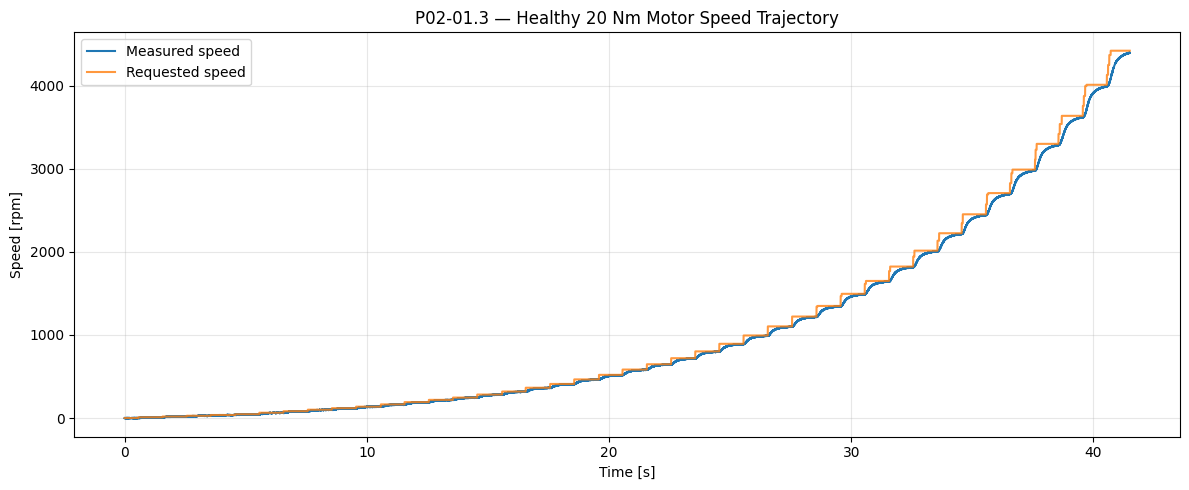


Quasi-steady audit points: 72603

Quasi-steady candidate segments:


,start_idx,end_idx,start_time_s,end_time_s,duration_s,mean_speed_rpm,speed_std_rpm,speed_range_rpm
0,208774,215964,20.8774,21.5964,0.7191,575.472452,5.089507,23.766357
1,198957,205876,19.8957,20.5876,0.6920,512.420413,4.375792,19.615356
2,218868,225486,21.8868,22.5486,0.6619,638.897982,4.856959,21.139893
3,229207,235063,22.9207,23.5063,0.5857,710.802375,4.797223,19.734924
4,239486,244618,23.9486,24.4618,0.5133,791.965474,4.622106,19.633850
5,249559,254605,24.9559,25.4605,0.5047,882.245119,4.937961,21.611511



Selected engineering-audit interval:
  Start [s]       : 20.8774
  End [s]         : 21.5964
  Duration [s]    : 0.719
  Mean speed [rpm]: 575.47
  Speed range rpm : 23.77


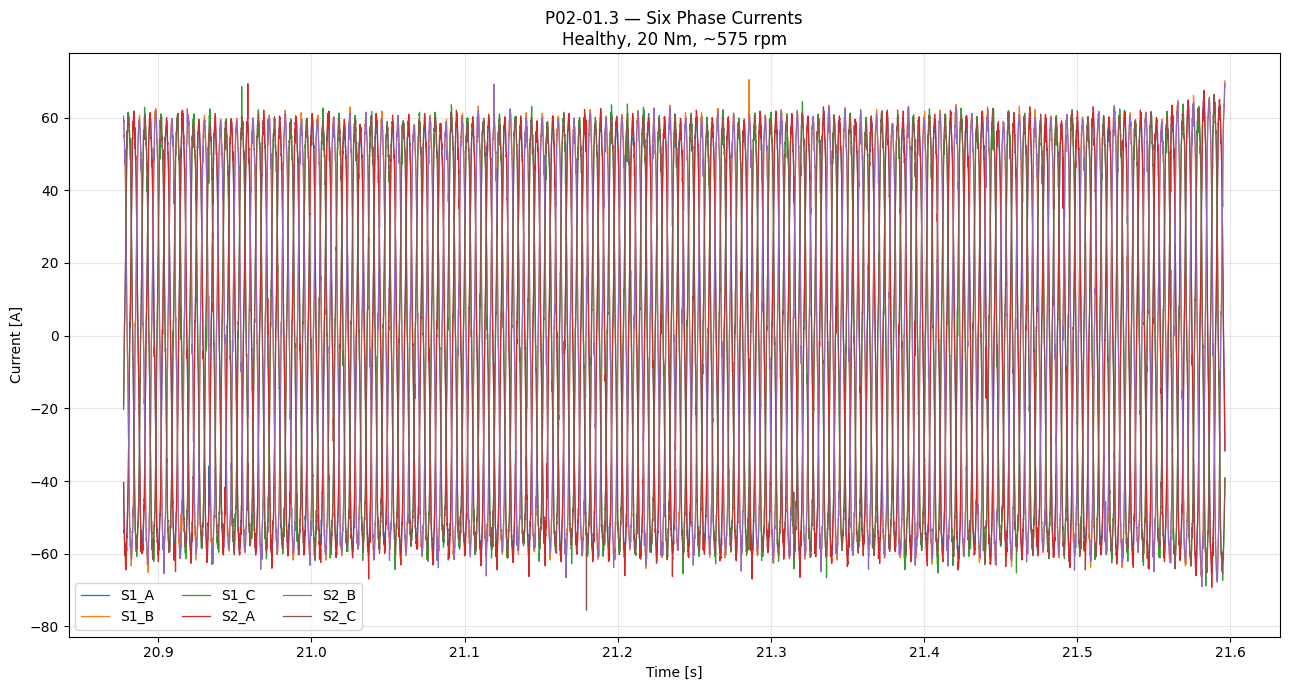


Phase-current statistics:


,channel,mean_a,rms_a,std_a,min_a,max_a,peak_abs_a,peak_to_peak_a
0,S1_A,-0.051009,42.331745,42.331714,-65.382599,65.884827,65.884827,131.267426
1,S1_B,0.053480,43.110351,43.110317,-67.872192,70.435516,70.435516,138.307709
2,S1_C,0.116595,42.892932,42.892773,-68.885559,68.513733,68.885559,137.399292
3,S2_A,-0.321211,43.003574,43.002374,-69.216217,69.318573,69.318573,138.534790
4,S2_B,0.199076,42.882035,42.881573,-69.068298,69.466492,69.466492,138.534790
5,S2_C,0.213326,42.450229,42.449693,-75.523376,66.418030,75.523376,141.941406



Three-phase balance audit:


,subsystem,rms_phase_a,rms_phase_b,rms_phase_c,mean_phase_rms,rms_spread_a,relative_rms_spread,abc_sum_rms_a,abc_sum_mean_a
0,Subsystem_1,42.331745,43.110351,42.892932,42.778342,0.778606,0.018201,1.954605,0.119066
1,Subsystem_2,43.003574,42.882035,42.450229,42.778613,0.553344,0.012935,2.532778,0.091190



Subsystem comparison:


,phase,subsys1_rms_a,subsys2_rms_a,rms_difference_a,samplewise_correlation
0,A,42.331745,43.003574,0.671829,0.999406
1,B,43.110351,42.882035,0.228316,0.999292
2,C,42.892932,42.450229,0.442703,0.999032



Spectral summary:


,channel,dominant_frequency_hz,welch_nperseg,frequency_resolution_hz
0,S1_A,95.214844,4096,2.441406
1,S1_B,95.214844,4096,2.441406
2,S1_C,95.214844,4096,2.441406
3,S2_A,95.214844,4096,2.441406
4,S2_B,95.214844,4096,2.441406
5,S2_C,95.214844,4096,2.441406


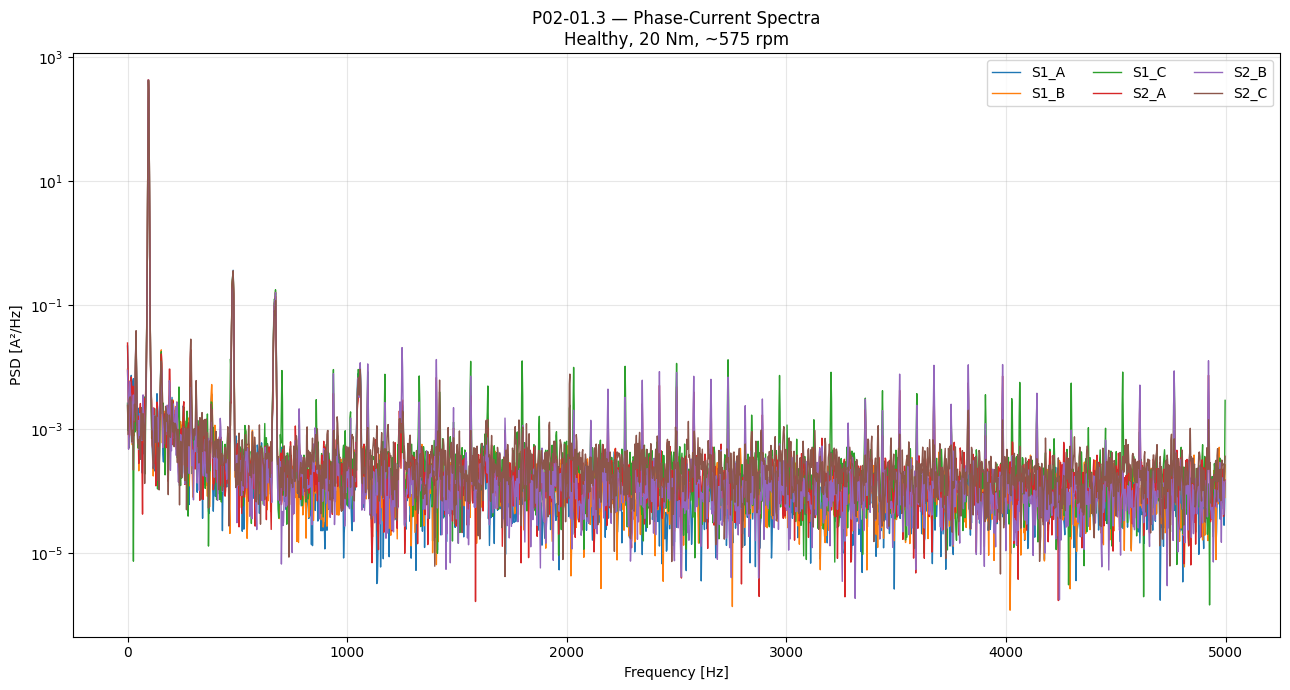


dq-current audit:


,channel,mean_a,std_a,rms_a,min_a,max_a
0,S1_d,-4.195530,2.962119,5.135817,-18.412132,7.055356
1,S1_q,60.242917,1.768689,60.268876,44.693493,74.762527
2,S2_d,-4.195260,2.795874,5.041540,-18.677227,8.199537
3,S2_q,60.243779,1.830595,60.271586,46.409317,78.694130



Artifact validation: PASS

P02-01.3 : PASS

Measured source:
  spd10-5000rpm_flt0z_20NM.mat

Verified sampling:
 10000.0 Hz, 41.500 s

Selected engineering-audit interval:
 20.877 → 21.596 s
 Mean speed: 575.5 rpm
 Speed range: 23.8 rpm

Quasi-steady candidate segments:
  6

Predictor channels frozen : NO
Windowing frozen          : NO
Features frozen           : NO
Split frozen              : NO
Training started          : NO

NEXT:
P02-01.4 — Simulated-data schema audit

SAFE STOPPING POINT


In [ ]:
# P02-01.3 — Measured signal content and engineering audit

# P02-01.3 will perform the measured-signal engineering audit on the one
# healthy 20 Nm run already downloaded.

# ============================================================
# P02-01.3 — Measured signal content and engineering audit
#
# PURPOSE:
#   1. Restore the persisted P02 state
#   2. Reload the ONE measured healthy sample already downloaded
#   3. Audit speed trajectory
#   4. Identify a representative quasi-steady operating interval
#   5. Inspect six phase-current signals
#   6. Inspect phase balance and subsystem differences
#   7. Inspect current spectra
#   8. Persist figures, tables, report, and updated project state
#
# NEW DATA DOWNLOAD: NO
# MODEL TRAINING: NO
# PREPROCESSING SPECIFICATION: NOT FROZEN
# PREDICTOR SELECTION: NOT FROZEN
# ============================================================

from pathlib import Path
import csv
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from scipy.io import loadmat
from scipy.signal import welch


# ============================================================
# 1. Restore authoritative project state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SAMPLE_DIR = (
    PROJECT_DRIVE /
    "data/raw/measured/schema_audit_sample"
)

MANIFEST_PATH = (
    PROJECT_DRIVE /
    "data/manifests/measured_file_manifest_v001.csv"
)

assert PROJECT_DRIVE.exists(), (
    f"Project root missing:\n{PROJECT_DRIVE}"
)

assert STATE_PATH.exists(), (
    f"Project state missing:\n{STATE_PATH}"
)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.2", (
    "Expected persistent state at P02-01.2.\n"
    f"Found: {state['last_completed_step']}"
)

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ============================================================
# 2. Restore canonical measured file selection
# ============================================================

manifest = pd.read_csv(MANIFEST_PATH)

sample_row = manifest[
    (manifest["shorted_turns"] == 0) &
    (manifest["load_torque_nm"] == 20)
].copy()

assert len(sample_row) == 1

sample_row = sample_row.iloc[0]

SAMPLE_FILENAME = str(sample_row["filename"])
SAMPLE_PATH = SAMPLE_DIR / SAMPLE_FILENAME

assert SAMPLE_PATH.exists(), (
    f"Previously downloaded sample missing:\n{SAMPLE_PATH}"
)

print("\nMeasured sample restored:")
print(" ", SAMPLE_FILENAME)
print(" ", round(SAMPLE_PATH.stat().st_size / 1024**2, 2), "MB")


# ============================================================
# 3. Load raw MATLAB signals
# ============================================================

mat = loadmat(
    SAMPLE_PATH,
    squeeze_me=True,
    struct_as_record=False
)

required_signals = [
    "Currents_SubSys1_A",
    "Currents_SubSys1_B",
    "Currents_SubSys1_C",

    "Currents_SubSys2_A",
    "Currents_SubSys2_B",
    "Currents_SubSys2_C",

    "Currents_SubSys1_d",
    "Currents_SubSys1_q",

    "Currents_SubSys2_d",
    "Currents_SubSys2_q",

    "Speed_rpm",
    "Speed_requred_rpm",

    "Time",
]

for signal in required_signals:
    assert signal in mat, (
        f"Required signal missing: {signal}"
    )

time = np.asarray(mat["Time"], dtype=np.float64)

speed_rpm = np.asarray(
    mat["Speed_rpm"],
    dtype=np.float64
)

speed_required_rpm = np.asarray(
    mat["Speed_requred_rpm"],
    dtype=np.float64
)

currents = {
    "S1_A": np.asarray(mat["Currents_SubSys1_A"], dtype=np.float64),
    "S1_B": np.asarray(mat["Currents_SubSys1_B"], dtype=np.float64),
    "S1_C": np.asarray(mat["Currents_SubSys1_C"], dtype=np.float64),

    "S2_A": np.asarray(mat["Currents_SubSys2_A"], dtype=np.float64),
    "S2_B": np.asarray(mat["Currents_SubSys2_B"], dtype=np.float64),
    "S2_C": np.asarray(mat["Currents_SubSys2_C"], dtype=np.float64),
}

dq = {
    "S1_d": np.asarray(mat["Currents_SubSys1_d"], dtype=np.float64),
    "S1_q": np.asarray(mat["Currents_SubSys1_q"], dtype=np.float64),
    "S2_d": np.asarray(mat["Currents_SubSys2_d"], dtype=np.float64),
    "S2_q": np.asarray(mat["Currents_SubSys2_q"], dtype=np.float64),
}

n = len(time)

assert len(speed_rpm) == n

for x in currents.values():
    assert len(x) == n

for x in dq.values():
    assert len(x) == n

dt = np.median(np.diff(time))
FS_HZ = 1.0 / dt

assert np.isclose(FS_HZ, 10000.0, rtol=1e-4), (
    f"Unexpected sample rate: {FS_HZ}"
)

print("\nRaw signal loading: PASS")
print("Samples        :", n)
print("Duration [s]   :", round(time[-1] - time[0], 3))
print("Sample rate Hz :", round(FS_HZ, 3))


# ============================================================
# 4. Create persistent audit directories
# ============================================================

FIG_DIR = (
    PROJECT_DRIVE /
    "results/figures/measured_signal_audit_v001"
)

TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/measured_signal_audit_v001"
)

REPORT_DIR = PROJECT_DRIVE / "reports"

for path in [
    FIG_DIR,
    TABLE_DIR,
    REPORT_DIR,
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 5. Audit the complete speed trajectory
# ============================================================

speed_error = (
    speed_rpm -
    speed_required_rpm
)

speed_summary = {
    "duration_s":
        float(time[-1] - time[0]),

    "speed_min_rpm":
        float(np.min(speed_rpm)),

    "speed_max_rpm":
        float(np.max(speed_rpm)),

    "speed_mean_rpm":
        float(np.mean(speed_rpm)),

    "requested_speed_max_rpm":
        float(np.max(speed_required_rpm)),

    "speed_tracking_rmse_rpm":
        float(
            np.sqrt(
                np.mean(speed_error ** 2)
            )
        ),
}

SPEED_SUMMARY_PATH = (
    TABLE_DIR /
    "speed_summary_v001.csv"
)

pd.DataFrame(
    [speed_summary]
).to_csv(
    SPEED_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 5.1 Full speed trajectory figure
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    speed_rpm,
    label="Measured speed"
)

plt.plot(
    time,
    speed_required_rpm,
    label="Requested speed",
    alpha=0.8
)

plt.xlabel("Time [s]")
plt.ylabel("Speed [rpm]")
plt.title(
    "P02-01.3 — Healthy 20 Nm Motor Speed Trajectory"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

SPEED_FIG_PATH = (
    FIG_DIR /
    "speed_trajectory_v001.png"
)

plt.savefig(
    SPEED_FIG_PATH,
    dpi=160
)

plt.show()
plt.close()


# ============================================================
# 6. Detect quasi-steady candidate regions
#
# IMPORTANT:
# This is an AUDIT heuristic only.
# It is NOT PREP-001.
#
# We use a 0.5-second rolling speed range and identify regions
# with:
#
#     measured speed >= 500 rpm
#     rolling speed range <= 50 rpm
#
# The threshold is intentionally only for exploratory inspection.
# ============================================================

AUDIT_WINDOW_S = 0.5

AUDIT_WINDOW_N = int(
    round(AUDIT_WINDOW_S * FS_HZ)
)

speed_series = pd.Series(speed_rpm)

rolling_max = (
    speed_series
    .rolling(
        AUDIT_WINDOW_N,
        center=True,
        min_periods=AUDIT_WINDOW_N
    )
    .max()
)

rolling_min = (
    speed_series
    .rolling(
        AUDIT_WINDOW_N,
        center=True,
        min_periods=AUDIT_WINDOW_N
    )
    .min()
)

rolling_range = (
    rolling_max -
    rolling_min
).to_numpy()

steady_mask = (
    np.isfinite(rolling_range) &
    (speed_rpm >= 500.0) &
    (rolling_range <= 50.0)
)

steady_indices = np.where(
    steady_mask
)[0]

print("\nQuasi-steady audit points:", len(steady_indices))

if len(steady_indices) == 0:
    raise RuntimeError(
        "No quasi-steady region found using the audit heuristic.\n"
        "Do not manually alter thresholds yet."
    )


# ============================================================
# 7. Find contiguous quasi-steady segments
# ============================================================

breaks = np.where(
    np.diff(steady_indices) > 1
)[0]

segment_starts = np.insert(
    steady_indices[breaks + 1],
    0,
    steady_indices[0]
)

segment_ends = np.append(
    steady_indices[breaks],
    steady_indices[-1]
)

segments = []

for start_idx, end_idx in zip(
    segment_starts,
    segment_ends
):

    length_samples = (
        end_idx -
        start_idx +
        1
    )

    duration_s = (
        length_samples /
        FS_HZ
    )

    segment_speed = speed_rpm[
        start_idx:end_idx + 1
    ]

    if duration_s >= 0.5:

        segments.append({
            "start_idx":
                int(start_idx),

            "end_idx":
                int(end_idx),

            "start_time_s":
                float(time[start_idx]),

            "end_time_s":
                float(time[end_idx]),

            "duration_s":
                float(duration_s),

            "mean_speed_rpm":
                float(
                    np.mean(segment_speed)
                ),

            "speed_std_rpm":
                float(
                    np.std(segment_speed)
                ),

            "speed_range_rpm":
                float(
                    np.max(segment_speed) -
                    np.min(segment_speed)
                ),
        })

segment_df = pd.DataFrame(
    segments
)

assert len(segment_df) > 0, (
    "No usable >=0.5-second quasi-steady "
    "segments found."
)

segment_df = (
    segment_df
    .sort_values(
        [
            "duration_s",
            "mean_speed_rpm"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

SEGMENTS_PATH = (
    TABLE_DIR /
    "quasi_steady_segments_v001.csv"
)

segment_df.to_csv(
    SEGMENTS_PATH,
    index=False
)

print("\nQuasi-steady candidate segments:")
display(segment_df)


# ============================================================
# 8. Select one representative segment for engineering audit
#
# Preference:
#   longest quasi-steady segment
#
# We will inspect at most 1.0 second from its middle.
#
# Again: this does NOT freeze P02 window length.
# ============================================================

selected_segment = segment_df.iloc[0]

segment_start = int(
    selected_segment["start_idx"]
)

segment_end = int(
    selected_segment["end_idx"]
)

segment_length = (
    segment_end -
    segment_start +
    1
)

AUDIT_DISPLAY_S = min(
    1.0,
    segment_length / FS_HZ
)

AUDIT_DISPLAY_N = int(
    round(
        AUDIT_DISPLAY_S *
        FS_HZ
    )
)

segment_mid = (
    segment_start +
    segment_length // 2
)

audit_start = max(
    segment_start,
    segment_mid -
    AUDIT_DISPLAY_N // 2
)

audit_end = min(
    audit_start +
    AUDIT_DISPLAY_N,
    segment_end + 1
)

# If clipped on right edge, shift left
audit_start = max(
    segment_start,
    audit_end -
    AUDIT_DISPLAY_N
)

assert audit_end > audit_start

t_audit = time[
    audit_start:audit_end
]

speed_audit = speed_rpm[
    audit_start:audit_end
]

audit_mean_speed_rpm = float(
    np.mean(speed_audit)
)

audit_speed_range_rpm = float(
    np.max(speed_audit) -
    np.min(speed_audit)
)

print("\nSelected engineering-audit interval:")
print(
    "  Start [s]       :",
    round(float(t_audit[0]), 4)
)
print(
    "  End [s]         :",
    round(float(t_audit[-1]), 4)
)
print(
    "  Duration [s]    :",
    round(float(t_audit[-1] - t_audit[0]), 4)
)
print(
    "  Mean speed [rpm]:",
    round(audit_mean_speed_rpm, 2)
)
print(
    "  Speed range rpm :",
    round(audit_speed_range_rpm, 2)
)


# ============================================================
# 9. Plot six phase-current time histories
# ============================================================

plt.figure(figsize=(13, 7))

for name, signal in currents.items():

    plt.plot(
        t_audit,
        signal[audit_start:audit_end],
        label=name,
        linewidth=0.9
    )

plt.xlabel("Time [s]")
plt.ylabel("Current [A]")
plt.title(
    "P02-01.3 — Six Phase Currents\n"
    f"Healthy, 20 Nm, ~{audit_mean_speed_rpm:.0f} rpm"
)
plt.legend(
    ncol=3
)
plt.grid(
    True,
    alpha=0.3
)
plt.tight_layout()

CURRENT_TIME_FIG_PATH = (
    FIG_DIR /
    "six_phase_currents_quasi_steady_v001.png"
)

plt.savefig(
    CURRENT_TIME_FIG_PATH,
    dpi=160
)

plt.show()
plt.close()


# ============================================================
# 10. Current time-domain statistics
# ============================================================

def rms(x):
    return float(
        np.sqrt(
            np.mean(
                np.asarray(x) ** 2
            )
        )
    )


current_stats = []

for name, signal in currents.items():

    x = signal[
        audit_start:audit_end
    ]

    current_stats.append({
        "channel": name,

        "mean_a":
            float(np.mean(x)),

        "rms_a":
            rms(x),

        "std_a":
            float(np.std(x)),

        "min_a":
            float(np.min(x)),

        "max_a":
            float(np.max(x)),

        "peak_abs_a":
            float(
                np.max(
                    np.abs(x)
                )
            ),

        "peak_to_peak_a":
            float(
                np.ptp(x)
            ),
    })

current_stats_df = pd.DataFrame(
    current_stats
)

CURRENT_STATS_PATH = (
    TABLE_DIR /
    "phase_current_statistics_v001.csv"
)

current_stats_df.to_csv(
    CURRENT_STATS_PATH,
    index=False
)

print("\nPhase-current statistics:")
display(current_stats_df)


# ============================================================
# 11. Three-phase subsystem balance metrics
#
# These are engineering audit metrics only.
# They are NOT frozen ML features.
# ============================================================

def three_phase_balance_metrics(
    a,
    b,
    c,
    label
):

    rms_values = np.array([
        rms(a),
        rms(b),
        rms(c)
    ])

    mean_rms = float(
        np.mean(rms_values)
    )

    rms_spread = float(
        np.max(rms_values) -
        np.min(rms_values)
    )

    relative_rms_spread = (
        rms_spread /
        mean_rms
        if mean_rms != 0
        else np.nan
    )

    instantaneous_sum = (
        a + b + c
    )

    return {
        "subsystem":
            label,

        "rms_phase_a":
            float(rms_values[0]),

        "rms_phase_b":
            float(rms_values[1]),

        "rms_phase_c":
            float(rms_values[2]),

        "mean_phase_rms":
            mean_rms,

        "rms_spread_a":
            rms_spread,

        "relative_rms_spread":
            float(relative_rms_spread),

        "abc_sum_rms_a":
            rms(instantaneous_sum),

        "abc_sum_mean_a":
            float(
                np.mean(
                    instantaneous_sum
                )
            ),
    }


s1_slice = [
    currents["S1_A"][audit_start:audit_end],
    currents["S1_B"][audit_start:audit_end],
    currents["S1_C"][audit_start:audit_end],
]

s2_slice = [
    currents["S2_A"][audit_start:audit_end],
    currents["S2_B"][audit_start:audit_end],
    currents["S2_C"][audit_start:audit_end],
]

balance_df = pd.DataFrame([
    three_phase_balance_metrics(
        *s1_slice,
        label="Subsystem_1"
    ),

    three_phase_balance_metrics(
        *s2_slice,
        label="Subsystem_2"
    ),
])

BALANCE_PATH = (
    TABLE_DIR /
    "three_phase_balance_v001.csv"
)

balance_df.to_csv(
    BALANCE_PATH,
    index=False
)

print("\nThree-phase balance audit:")
display(balance_df)


# ============================================================
# 12. Compare corresponding phases across the two subsystems
#
# Important:
# Direct sample-wise differences may depend on the machine's
# electrical phase arrangement.
#
# We record both correlation and RMS magnitude differences
# without interpreting them yet as fault features.
# ============================================================

cross_rows = []

for phase in ["A", "B", "C"]:

    x1 = currents[
        f"S1_{phase}"
    ][audit_start:audit_end]

    x2 = currents[
        f"S2_{phase}"
    ][audit_start:audit_end]

    corr = float(
        np.corrcoef(
            x1,
            x2
        )[0, 1]
    )

    cross_rows.append({
        "phase":
            phase,

        "subsys1_rms_a":
            rms(x1),

        "subsys2_rms_a":
            rms(x2),

        "rms_difference_a":
            float(
                abs(
                    rms(x1) -
                    rms(x2)
                )
            ),

        "samplewise_correlation":
            corr,
    })

cross_df = pd.DataFrame(
    cross_rows
)

CROSS_PATH = (
    TABLE_DIR /
    "subsystem_phase_comparison_v001.csv"
)

cross_df.to_csv(
    CROSS_PATH,
    index=False
)

print("\nSubsystem comparison:")
display(cross_df)


# ============================================================
# 13. Spectral audit using Welch PSD
#
# This is descriptive only.
# No FFT parameters are frozen for ML.
# ============================================================

N_PER_SEG = min(
    4096,
    len(t_audit)
)

spectral_rows = []

spectra = {}

for name, signal in currents.items():

    x = signal[
        audit_start:audit_end
    ]

    x = (
        x -
        np.mean(x)
    )

    f_hz, psd = welch(
        x,
        fs=FS_HZ,
        nperseg=N_PER_SEG,
        noverlap=N_PER_SEG // 2,
        scaling="density"
    )

    spectra[name] = (
        f_hz,
        psd
    )

    # Ignore DC for dominant-frequency audit
    valid = (
        f_hz > 1.0
    )

    dominant_idx = np.argmax(
        psd[valid]
    )

    dominant_freq = (
        f_hz[valid][
            dominant_idx
        ]
    )

    spectral_rows.append({
        "channel":
            name,

        "dominant_frequency_hz":
            float(
                dominant_freq
            ),

        "welch_nperseg":
            int(N_PER_SEG),

        "frequency_resolution_hz":
            float(
                FS_HZ /
                N_PER_SEG
            ),
    })


spectral_df = pd.DataFrame(
    spectral_rows
)

SPECTRAL_PATH = (
    TABLE_DIR /
    "phase_current_spectral_summary_v001.csv"
)

spectral_df.to_csv(
    SPECTRAL_PATH,
    index=False
)

print("\nSpectral summary:")
display(spectral_df)


# ============================================================
# 14. Plot six current PSDs
# ============================================================

plt.figure(figsize=(13, 7))

# Show only physically useful audit band initially.
AUDIT_FREQ_MAX_HZ = min(
    5000,
    FS_HZ / 2
)

for name, (
    f_hz,
    psd
) in spectra.items():

    mask = (
        (f_hz >= 0) &
        (f_hz <= AUDIT_FREQ_MAX_HZ)
    )

    plt.semilogy(
        f_hz[mask],
        psd[mask],
        label=name,
        linewidth=1.0
    )

plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [A²/Hz]")
plt.title(
    "P02-01.3 — Phase-Current Spectra\n"
    f"Healthy, 20 Nm, ~{audit_mean_speed_rpm:.0f} rpm"
)
plt.legend(
    ncol=3
)
plt.grid(
    True,
    alpha=0.3
)
plt.tight_layout()

PSD_FIG_PATH = (
    FIG_DIR /
    "six_phase_current_psd_v001.png"
)

plt.savefig(
    PSD_FIG_PATH,
    dpi=160
)

plt.show()
plt.close()


# ============================================================
# 15. Inspect dq-current behavior
#
# This gives engineering context only.
# dq signals are NOT selected as model predictors.
# ============================================================

dq_stats = []

for name, signal in dq.items():

    x = signal[
        audit_start:audit_end
    ]

    dq_stats.append({
        "channel":
            name,

        "mean_a":
            float(
                np.mean(x)
            ),

        "std_a":
            float(
                np.std(x)
            ),

        "rms_a":
            rms(x),

        "min_a":
            float(
                np.min(x)
            ),

        "max_a":
            float(
                np.max(x)
            ),
    })

dq_stats_df = pd.DataFrame(
    dq_stats
)

DQ_STATS_PATH = (
    TABLE_DIR /
    "dq_current_statistics_v001.csv"
)

dq_stats_df.to_csv(
    DQ_STATS_PATH,
    index=False
)

print("\ndq-current audit:")
display(dq_stats_df)


# ============================================================
# 16. Save selected audit-interval record
# ============================================================

interval_record = {
    "audit_id":
        "P02-MEASURED-SIGNAL-CONTENT-001",

    "source_file":
        SAMPLE_FILENAME,

    "condition":
        "healthy",

    "shorted_turns":
        0,

    "load_torque_nm":
        20,

    "sample_rate_hz":
        float(FS_HZ),

    "audit_interval_selection":
        "Longest >=0.5 s region satisfying exploratory "
        "speed >=500 rpm and 0.5 s rolling speed "
        "range <=50 rpm; inspect up to 1 s from segment center.",

    "audit_interval_start_s":
        float(
            t_audit[0]
        ),

    "audit_interval_end_s":
        float(
            t_audit[-1]
        ),

    "audit_interval_duration_s":
        float(
            t_audit[-1] -
            t_audit[0]
        ),

    "audit_mean_speed_rpm":
        audit_mean_speed_rpm,

    "audit_speed_range_rpm":
        audit_speed_range_rpm,

    "important_status": {
        "predictor_channels_frozen":
            False,

        "window_length_frozen":
            False,

        "fft_parameters_frozen":
            False,

        "features_frozen":
            False,

        "target_frozen":
            False,
    },
}

INTERVAL_JSON_PATH = (
    TABLE_DIR /
    "selected_audit_interval_v001.json"
)

with open(
    INTERVAL_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        interval_record,
        f,
        indent=2
    )

# Immediate reload
with open(
    INTERVAL_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    interval_reload = json.load(f)

assert (
    interval_reload[
        "important_status"
    ][
        "predictor_channels_frozen"
    ]
    is False
)


# ============================================================
# 17. Create human-readable engineering audit report
# ============================================================

REPORT_PATH = (
    REPORT_DIR /
    "measured_signal_engineering_audit_v001.md"
)

report = f"""# P02 — Measured Signal Engineering Audit v001

## 1. Audit Identity

Audit ID:

P02-MEASURED-SIGNAL-CONTENT-001

Status:

COMPLETE

## 2. Source Run

File:

`{SAMPLE_FILENAME}`

Condition:

- Healthy
- 0 shorted turns
- 20 Nm load

Measured duration:

{time[-1] - time[0]:.3f} s

Verified sample rate:

{FS_HZ:.3f} Hz

Maximum measured speed:

{np.max(speed_rpm):.2f} rpm

## 3. Available Dynamic Signal Families

The raw file contains:

- six phase currents across two three-phase subsystems
- four dq current channels
- measured and requested speed
- electrical angle sine/cosine channels
- four dq voltage/control channels

P02 predictor channels remain UNFROZEN.

## 4. Exploratory Quasi-Steady Audit Interval

An exploratory interval was identified solely for
engineering visualization.

Start:

{t_audit[0]:.6f} s

End:

{t_audit[-1]:.6f} s

Mean speed:

{audit_mean_speed_rpm:.2f} rpm

Speed range:

{audit_speed_range_rpm:.2f} rpm

This selection logic is NOT PREP-001 and must not be
treated as a frozen modeling rule.

## 5. Phase-Current Audit

Six synchronized phase-current channels were inspected.

Artifacts include:

- time histories
- RMS / peak statistics
- subsystem three-phase balance
- corresponding-phase subsystem comparison
- Welch spectral estimates

These descriptors are diagnostic observations only and
are not frozen ML predictors.

## 6. dq-Current Audit

The four dq-current channels were summarized for
engineering context.

No decision has been made to include or exclude dq
signals from the eventual model.

## 7. Important Modeling Implication

The measured signal population contains rich
multichannel temporal structure together with substantial
speed variation.

The eventual sim-to-real predictor space should therefore
be chosen only after verifying which equivalent signals
exist in the public simulated training population.

## 8. Frozen Status After P02-01.3

Predictor channels:

UNFROZEN

Prediction target:

UNFROZEN

Window length:

UNFROZEN

Overlap:

UNFROZEN

Spectral representation:

UNFROZEN

Normalization:

UNFROZEN

Split:

UNFROZEN

Metrics:

UNFROZEN

Model families:

UNFROZEN

## 9. Next Step

P02-01.4 — Simulated-data schema audit.

The purpose of P02-01.4 is to identify the common
measured/simulated signal universe before any modeling
specification is created.
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ============================================================
# 18. Persist machine-readable audit summary
# ============================================================

AUDIT_JSON_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_signal_engineering_audit_v001.json"
)

audit_summary = {
    "audit_id":
        "P02-MEASURED-SIGNAL-CONTENT-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "source_file":
        SAMPLE_FILENAME,

    "sample_rate_hz":
        float(FS_HZ),

    "source_duration_s":
        float(
            time[-1] -
            time[0]
        ),

    "source_max_speed_rpm":
        float(
            np.max(
                speed_rpm
            )
        ),

    "phase_current_channels":
        list(
            currents.keys()
        ),

    "dq_current_channels":
        list(
            dq.keys()
        ),

    "quasi_steady_candidate_segment_count":
        int(
            len(
                segment_df
            )
        ),

    "selected_audit_mean_speed_rpm":
        float(
            audit_mean_speed_rpm
        ),

    "next_step":
        "P02-01.4_SIMULATED_DATA_SCHEMA_AUDIT",

    "frozen_status": {
        "predictors":
            False,

        "target":
            False,

        "windowing":
            False,

        "spectral_representation":
            False,

        "normalization":
            False,

        "split":
            False,

        "metrics":
            False,

        "models":
            False,
    },
}

with open(
    AUDIT_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=2
    )

# Immediate reload validation
with open(
    AUDIT_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    audit_reload = json.load(f)

assert audit_reload["status"] == "COMPLETE"
assert audit_reload["frozen_status"]["predictors"] is False


# ============================================================
# 19. Update persistent project state
# ============================================================

state["last_completed_step"] = "P02-01.3"

state["next_step"] = (
    "P02-01.4_SIMULATED_DATA_SCHEMA_AUDIT"
)

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

# Reload immediately
with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_reload = yaml.safe_load(f)

assert (
    state_reload[
        "last_completed_step"
    ]
    == "P02-01.3"
)

assert (
    state_reload[
        "model_training_started"
    ]
    is False
)


# ============================================================
# 20. Validate all important P02-01.3 artifacts
# ============================================================

required_artifacts = [
    SPEED_SUMMARY_PATH,
    SPEED_FIG_PATH,
    SEGMENTS_PATH,

    CURRENT_TIME_FIG_PATH,
    CURRENT_STATS_PATH,

    BALANCE_PATH,
    CROSS_PATH,

    SPECTRAL_PATH,
    PSD_FIG_PATH,

    DQ_STATS_PATH,

    INTERVAL_JSON_PATH,

    REPORT_PATH,
    AUDIT_JSON_PATH,

    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("\nArtifact validation: PASS")


# ============================================================
# 21. Fingerprint P02-01.3 artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(block)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "measured_signal_engineering_audit_fingerprints_v001.csv"
)

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

            sha256_file(
                path
            ),

            path.stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ============================================================
# 22. Final audit summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.3 : PASS")
print("=" * 72)

print("\nMeasured source:")
print(" ", SAMPLE_FILENAME)

print("\nVerified sampling:")
print(
    f" {FS_HZ:.1f} Hz, "
    f"{time[-1] - time[0]:.3f} s"
)

print("\nSelected engineering-audit interval:")
print(
    f" {t_audit[0]:.3f} → "
    f"{t_audit[-1]:.3f} s"
)

print(
    " Mean speed:",
    f"{audit_mean_speed_rpm:.1f} rpm"
)

print(
    " Speed range:",
    f"{audit_speed_range_rpm:.1f} rpm"
)

print("\nQuasi-steady candidate segments:")
print(
    " ",
    len(segment_df)
)

print("\nPredictor channels frozen : NO")
print("Windowing frozen          : NO")
print("Features frozen           : NO")
print("Split frozen              : NO")
print("Training started          : NO")

print("\nNEXT:")
print(
    "P02-01.4 — Simulated-data schema audit"
)

print("\nSAFE STOPPING POINT")

In [ ]:
# Colab Session Close-Out Cell

# ============================================================
# P02 — SESSION CLOSEOUT
# Date: 2026-09-01
#
# PURPOSE:
#   1. Verify authoritative persistent state
#   2. Verify P02-01.3 artifacts
#   3. Persist a fresh-session restore manifest
#   4. Persist today's session closeout report
#   5. Mark project safe for Colab restart
#
# TRAINING: NO
# LARGE DOWNLOAD: NO
# ============================================================

from pathlib import Path
import hashlib
import json
import yaml

# ------------------------------------------------------------
# 1. Authoritative paths
# ------------------------------------------------------------

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

assert PROJECT_DRIVE.exists(), (
    f"Missing project root:\n{PROJECT_DRIVE}"
)

assert STATE_PATH.exists(), (
    f"Missing project state:\n{STATE_PATH}"
)

# ------------------------------------------------------------
# 2. Verify persistent project state
# ------------------------------------------------------------

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.3", (
    "Expected P02-01.3 to be complete.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False
assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False

print("Persistent project state: PASS")

# ------------------------------------------------------------
# 3. Define critical completed artifacts
# ------------------------------------------------------------

critical_artifacts = [
    # Project specifications
    PROJECT_DRIVE / "configs/project_scope_v001.yaml",
    PROJECT_DRIVE / "configs/data_policy_v001.yaml",
    PROJECT_DRIVE / "configs/deployment_v002.yaml",

    # Canonical metadata/manifests
    PROJECT_DRIVE / "data/manifests/measured_file_manifest_v001.csv",
    PROJECT_DRIVE / "data/manifests/sim_package_manifest_v001.csv",
    PROJECT_DRIVE / "data/manifests/sim_zip_high_value_inventory_v001.csv",

    # Dataset audits
    PROJECT_DRIVE / "data/registries/dataset_metadata_audit_v001.json",
    PROJECT_DRIVE / "data/registries/measured_signal_schema_audit_v001.json",
    PROJECT_DRIVE / "data/registries/measured_signal_engineering_audit_v001.json",

    # Human-readable reports
    PROJECT_DRIVE / "reports/dataset_metadata_audit_v001.md",
    PROJECT_DRIVE / "reports/measured_signal_schema_audit_v001.md",
    PROJECT_DRIVE / "reports/measured_signal_engineering_audit_v001.md",

    # One intentionally retained raw measured audit file
    (
        PROJECT_DRIVE /
        "data/raw/measured/schema_audit_sample/"
        "spd10-5000rpm_flt0z_20NM.mat"
    ),

    # P02-01.3 key tables
    (
        PROJECT_DRIVE /
        "results/tables/measured_signal_audit_v001/"
        "quasi_steady_segments_v001.csv"
    ),
    (
        PROJECT_DRIVE /
        "results/tables/measured_signal_audit_v001/"
        "phase_current_statistics_v001.csv"
    ),
    (
        PROJECT_DRIVE /
        "results/tables/measured_signal_audit_v001/"
        "three_phase_balance_v001.csv"
    ),
    (
        PROJECT_DRIVE /
        "results/tables/measured_signal_audit_v001/"
        "subsystem_phase_comparison_v001.csv"
    ),
    (
        PROJECT_DRIVE /
        "results/tables/measured_signal_audit_v001/"
        "phase_current_spectral_summary_v001.csv"
    ),
    (
        PROJECT_DRIVE /
        "results/tables/measured_signal_audit_v001/"
        "dq_current_statistics_v001.csv"
    ),

    # P02-01.3 figures
    (
        PROJECT_DRIVE /
        "results/figures/measured_signal_audit_v001/"
        "speed_trajectory_v001.png"
    ),
    (
        PROJECT_DRIVE /
        "results/figures/measured_signal_audit_v001/"
        "six_phase_currents_quasi_steady_v001.png"
    ),
    (
        PROJECT_DRIVE /
        "results/figures/measured_signal_audit_v001/"
        "six_phase_current_psd_v001.png"
    ),

    STATE_PATH,
]

missing = []

for path in critical_artifacts:
    if not path.exists() or path.stat().st_size == 0:
        missing.append(str(path))

assert not missing, (
    "Critical persistent artifacts are missing:\n"
    + "\n".join(missing)
)

print(
    f"Critical artifact verification: PASS "
    f"({len(critical_artifacts)} artifacts)"
)

# ------------------------------------------------------------
# 4. Verify latest engineering-audit record
# ------------------------------------------------------------

AUDIT_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_signal_engineering_audit_v001.json"
)

with open(AUDIT_PATH, "r", encoding="utf-8") as f:
    audit = json.load(f)

assert audit["status"] == "COMPLETE"
assert audit["audit_id"] == "P02-MEASURED-SIGNAL-CONTENT-001"

assert audit["frozen_status"]["predictors"] is False
assert audit["frozen_status"]["windowing"] is False
assert audit["frozen_status"]["split"] is False
assert audit["frozen_status"]["models"] is False

print("P02-01.3 audit record: PASS")

# ------------------------------------------------------------
# 5. Create fresh-session restore manifest
# ------------------------------------------------------------

RESTORE_PATH = (
    PROJECT_DRIVE /
    "project_admin/fresh_session_restore_v001.yaml"
)

restore_record = {
    "restore_specification_id": "P02-RESTORE-001",
    "version": "v001",
    "status": "ACTIVE",

    "project_id": "P02",

    "project_name":
        "Sim-to-Real PMSM Fault Diagnosis from Dynamic Signals",

    "persistent_root":
        str(PROJECT_DRIVE),

    "last_completed_step":
        "P02-01.3",

    "next_step":
        "P02-01.4_SIMULATED_DATA_SCHEMA_AUDIT",

    "completed_steps_do_not_rerun": [
        "P02-00.1",
        "P02-01.1",
        "P02-01.1R",
        "P02-01.2",
        "P02-01.3",
    ],

    "modeling_state": {
        "predictor_channels_frozen": False,
        "target_frozen": False,
        "windowing_frozen": False,
        "representation_frozen": False,
        "normalization_frozen": False,
        "split_frozen": False,
        "metrics_frozen": False,
        "model_training_started": False,
        "selected_model": None,
    },

    "data_state": {
        "measured_metadata_audited": True,
        "measured_signal_schema_audited": True,
        "measured_engineering_signal_audited": True,
        "single_raw_measured_file_downloaded": True,
        "full_measured_dataset_downloaded": False,
        "large_sim_package_downloaded": False,
        "new_simulation_generation_required": False,
    },

    "tomorrow_goal": [
        "Complete P02-01.4 simulated-data schema audit.",
        "If evidence is sufficient, complete P02-01.5 common sim-to-real "
        "signal universe and modeling-target decision.",
        "Do not begin model training.",
    ],

    "important_rule":
        "Do not rerun expensive or completed work after restart. "
        "Drive artifacts are authoritative.",
}

with open(RESTORE_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        restore_record,
        f,
        sort_keys=False
    )

# Immediate reload
with open(RESTORE_PATH, "r", encoding="utf-8") as f:
    restore_check = yaml.safe_load(f)

assert restore_check["last_completed_step"] == "P02-01.3"
assert restore_check["modeling_state"]["model_training_started"] is False

print("Fresh-session restore manifest: PASS")

# ------------------------------------------------------------
# 6. Persist today's session closeout report
# ------------------------------------------------------------

CLOSEOUT_PATH = (
    PROJECT_DRIVE /
    "reports/session_closeout_2026-09-01_v001.md"
)

closeout_text = """# P02 — Session Closeout — 2026-09-01

## 1. Session Final State

Last completed step:

P02-01.3 — Measured signal content and engineering audit

Next step:

P02-01.4 — Simulated-data schema audit

## 2. Completed Today

- P02-00.1 project initialization
- P02-01.1 public dataset metadata audit
- P02-01.1R JSON serialization repair
- P02-01.2 measured raw-signal schema audit
- P02-01.3 measured engineering-signal audit

## 3. Important Measured-Data Findings

The inspected source file was:

`spd10-5000rpm_flt0z_20NM.mat`

Condition:

- healthy
- 0 shorted turns
- 20 Nm load

Verified properties:

- 10,000 Hz sample rate
- 41.5 s measured duration
- six raw phase-current channels
- four dq-current channels
- actual and requested speed
- dq voltage/control channels
- electrical sine/cosine position channels

The healthy quasi-steady audit interval showed:

- approximately 42–43 A phase-current RMS
- low three-phase RMS imbalance
- near-identical corresponding current behavior across the two subsystems
- approximately 95.2 Hz dominant current component

These are engineering observations only.

No ML predictor or preprocessing rule is frozen.

## 4. Modeling Status

Predictors: UNFROZEN

Target: UNFROZEN

Windowing: UNFROZEN

Representation: UNFROZEN

Normalization: UNFROZEN

Split: UNFROZEN

Metrics: UNFROZEN

Models: UNFROZEN

Training started: NO

## 5. Dataset Status

One measured raw file retained for audit.

Full measured dataset: NOT DOWNLOADED

Large simulation/diagnosis package: NOT DOWNLOADED

New simulation generation: NOT REQUIRED

## 6. Next Session

Start from the persistent P02 state.

Do not rerun completed steps.

First milestone:

P02-01.4 — inspect the already-generated public simulated-data schema.

Second milestone, conditional on sufficient evidence:

P02-01.5 — freeze the common measured/simulated signal universe and
the initial modeling target.

## 7. Git Status

GitHub repository has not yet been created.

Git synchronization is therefore NOT APPLICABLE for this session.

Repository initialization will occur after the dataset/problem definition
is sufficiently stable rather than creating an empty shell prematurely.
"""

CLOSEOUT_PATH.write_text(
    closeout_text,
    encoding="utf-8"
)

assert CLOSEOUT_PATH.exists()
assert CLOSEOUT_PATH.stat().st_size > 0

print("Session closeout report: PASS")

# ------------------------------------------------------------
# 7. Update project state with clean restart marker
# ------------------------------------------------------------

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

state["last_completed_step"] = "P02-01.3"
state["next_step"] = "P02-01.4_SIMULATED_DATA_SCHEMA_AUDIT"

state["safe_to_restart"] = True
state["last_session_closeout"] = "2026-09-01"
state["last_session_closeout_record"] = str(CLOSEOUT_PATH)

state["large_dataset_download_started"] = False
state["model_training_started"] = False

with open(STATE_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

# Final reload
with open(STATE_PATH, "r", encoding="utf-8") as f:
    state_check = yaml.safe_load(f)

assert state_check["last_completed_step"] == "P02-01.3"
assert state_check["safe_to_restart"] is True
assert state_check["model_training_started"] is False

# ------------------------------------------------------------
# 8. Final closeout verification
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("P02 SESSION CLOSEOUT : PASS")
print("=" * 72)

print("\nLast completed step:")
print("  P02-01.3")

print("\nNext step:")
print("  P02-01.4 — Simulated-data schema audit")

print("\nPersistent storage:")
print(" ", PROJECT_DRIVE)

print("\nSafe to restart Colab : YES")
print("Training started       : NO")
print("Large download active  : NO")
print("Git repository exists  : NO — synchronization N/A")

print("\nRestore manifest:")
print(" ", RESTORE_PATH)

print("\nCloseout report:")
print(" ", CLOSEOUT_PATH)

print("\nCLEAN SAFE STOPPING POINT")

Persistent project state: PASS
Critical artifact verification: PASS (23 artifacts)
P02-01.3 audit record: PASS
Fresh-session restore manifest: PASS
Session closeout report: PASS

P02 SESSION CLOSEOUT : PASS

Last completed step:
  P02-01.3

Next step:
  P02-01.4 — Simulated-data schema audit

Persistent storage:
  /content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis

Safe to restart Colab : YES
Training started       : NO
Large download active  : NO
Git repository exists  : NO — synchronization N/A

Restore manifest:
  /content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis/project_admin/fresh_session_restore_v001.yaml

Closeout report:
  /content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis/reports/session_closeout_2026-09-01_v001.md

CLEAN SAFE STOPPING POINT


In [ ]:
# P02-01.4 — Simulated-data schema audit
# The key goal is very specific:
# Inspect one existing preprocessed simulated-training object from the public
# archive without downloading the full ~16 GB ZIP.

# ============================================================
# P02-01.4 — Simulated-data schema audit
#
# PURPOSE:
#   1. Restore persistent P02 state
#   2. Inspect the remote public ZIP directory WITHOUT
#      downloading the complete ~16 GB archive
#   3. Locate the preprocessed simulated TRAINING dataset
#      using the "none" scaling variant if available
#   4. Download ONLY that ZIP member (~120 MB expected)
#   5. Validate ZIP-member CRC
#   6. Deserialize the trusted public pickle
#   7. Audit its object/schema structure
#   8. Identify candidate common sim-to-real signal names
#   9. Persist all useful audit artifacts
#
# FULL 16 GB DOWNLOAD: NO
# NEW SIMULATION GENERATION: NO
# MODEL TRAINING: NO
# PREPROCESSING FROZEN: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import os
import pickle
import shutil
import subprocess
import sys
import zlib

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Restore authoritative P02 state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SIM_METADATA_PATH = (
    PROJECT_DRIVE /
    "data/raw/public/metadata/"
    "zenodo_14026570_metadata_v001.json"
)

assert PROJECT_DRIVE.exists(), (
    f"Project root missing:\n{PROJECT_DRIVE}"
)

assert STATE_PATH.exists(), (
    f"Project state missing:\n{STATE_PATH}"
)

assert SIM_METADATA_PATH.exists(), (
    f"Simulated-dataset metadata missing:\n{SIM_METADATA_PATH}"
)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.3", (
    "Expected project at P02-01.3.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ============================================================
# 2. Install / verify frozen RemoteZip dependency
# ============================================================

REMOTEZIP_VERSION = "0.12.6"

try:
    import remotezip

    installed_version = getattr(
        remotezip,
        "__version__",
        None
    )

except ImportError:

    print(
        "\nInstalling frozen dependency "
        f"remotezip=={REMOTEZIP_VERSION} ..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"remotezip=={REMOTEZIP_VERSION}",
    ])

    import remotezip


from remotezip import RemoteZip

print("RemoteZip import: PASS")


# ============================================================
# 3. Resolve public Zenodo ZIP URL from persisted metadata
# ============================================================

with open(
    SIM_METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:
    sim_metadata = json.load(f)

zenodo_files = sim_metadata.get("files", [])

assert len(zenodo_files) >= 1, (
    "No files found in persisted Zenodo metadata."
)

zip_records = [
    item
    for item in zenodo_files
    if str(item.get("key", "")).lower().endswith(".zip")
]

assert len(zip_records) == 1, (
    "Expected exactly one ZIP in Zenodo record 14026570.\n"
    f"Found {len(zip_records)}."
)

zip_record = zip_records[0]

ZIP_FILENAME = str(
    zip_record["key"]
)

zip_links = zip_record.get(
    "links",
    {}
)

ZIP_URL = (
    zip_links.get("self")
    or zip_links.get("download")
    or zip_links.get("content")
)

assert ZIP_URL is not None, (
    "Could not resolve public ZIP download URL."
)

ZIP_SIZE_BYTES = int(
    zip_record.get("size", 0)
)

print("\nPublic archive:")
print(" ", ZIP_FILENAME)
print(
    " Reported size [GB]:",
    round(
        ZIP_SIZE_BYTES / (1024**3),
        2
    )
)

print("\nFull archive will NOT be downloaded.")


# ============================================================
# 4. Read remote ZIP central directory only
#
# RemoteZip uses byte-range requests so that the archive
# directory can be inspected without retrieving the whole ZIP.
# ============================================================

print(
    "\nReading remote ZIP directory "
    "(no full archive download)..."
)

with RemoteZip(
    ZIP_URL,
    timeout=180
) as rz:

    zip_infos = rz.infolist()

assert len(zip_infos) > 0, (
    "Remote ZIP directory could not be read."
)

print("Remote ZIP directory access: PASS")
print("ZIP members discovered:", len(zip_infos))


# ============================================================
# 5. Persist complete remote ZIP-member inventory
# ============================================================

inventory_rows = []

for info in zip_infos:

    inventory_rows.append({
        "member_name":
            str(info.filename),

        "uncompressed_size_bytes":
            int(info.file_size),

        "compressed_size_bytes":
            int(info.compress_size),

        "crc32_hex":
            f"{int(info.CRC):08x}",

        "compression_type":
            int(info.compress_type),

        "is_directory":
            bool(info.is_dir()),
    })

inventory_df = pd.DataFrame(
    inventory_rows
)

INVENTORY_PATH = (
    PROJECT_DRIVE /
    "data/manifests/"
    "sim_remote_zip_inventory_v001.csv"
)

inventory_df.to_csv(
    INVENTORY_PATH,
    index=False
)

assert INVENTORY_PATH.exists()
assert INVENTORY_PATH.stat().st_size > 0

print("Remote ZIP inventory persisted: PASS")


# ============================================================
# 6. Identify high-value simulated TRAINING pickle candidates
#
# Priority:
#   - preprocessed
#   - training
#   - all_faults
#   - "none" scaling
#   - pickle
#
# We deliberately do NOT use a normalized version yet because
# P02 preprocessing has not been frozen.
# ============================================================

def norm_name(x):
    return str(x).replace("\\", "/").lower()


candidate_rows = []

for info in zip_infos:

    name = norm_name(
        info.filename
    )

    if not (
        name.endswith(".pickle")
        or name.endswith(".pkl")
    ):
        continue

    score = 0

    if "preprocessed" in name:
        score += 10

    if "training" in name:
        score += 10

    if "all_faults" in name:
        score += 5

    if "none" in name:
        score += 20

    if "simulated" in name:
        score += 3

    # Penalize clearly measured test datasets.
    if "measured" in name:
        score -= 20

    if "test" in name:
        score -= 5

    candidate_rows.append({
        "member_name":
            str(info.filename),

        "score":
            int(score),

        "uncompressed_mb":
            float(
                info.file_size /
                (1024**2)
            ),

        "compressed_mb":
            float(
                info.compress_size /
                (1024**2)
            ),

        "crc32_hex":
            f"{int(info.CRC):08x}",
    })


candidate_df = pd.DataFrame(
    candidate_rows
)

assert len(candidate_df) > 0, (
    "No pickle candidates found in remote archive."
)

candidate_df = (
    candidate_df
    .sort_values(
        [
            "score",
            "uncompressed_mb"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

print(
    "\nHighest-ranked simulated-data candidates:"
)

display(
    candidate_df.head(20)
)


CANDIDATE_TABLE_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_pickle_candidates_v001.csv"
)

candidate_df.to_csv(
    CANDIDATE_TABLE_PATH,
    index=False
)


# ============================================================
# 7. Select the preferred unscaled preprocessed training object
# ============================================================

preferred_mask = (
    candidate_df["member_name"]
    .str.lower()
    .str.contains("preprocessed")
    &
    candidate_df["member_name"]
    .str.lower()
    .str.contains("training")
    &
    candidate_df["member_name"]
    .str.lower()
    .str.contains("none")
    &
    ~candidate_df["member_name"]
    .str.lower()
    .str.contains("measured")
)

preferred = candidate_df[
    preferred_mask
].copy()

assert len(preferred) >= 1, (
    "No unscaled ('none') preprocessed training pickle "
    "was found.\n"
    "STOP here rather than automatically substituting "
    "a scaled dataset."
)

preferred = preferred.sort_values(
    [
        "score",
        "uncompressed_mb"
    ],
    ascending=[
        False,
        True
    ]
)

selected = preferred.iloc[0]

SELECTED_MEMBER = str(
    selected["member_name"]
)

SELECTED_EXPECTED_CRC = str(
    selected["crc32_hex"]
).lower()

print("\nSelected simulated training member:")
print(" ", SELECTED_MEMBER)
print(
    " Uncompressed size [MB]:",
    round(
        float(
            selected[
                "uncompressed_mb"
            ]
        ),
        2
    )
)

print(
    "\nIMPORTANT:"
    "\nOnly this ZIP member will be downloaded."
)


# ============================================================
# 8. Define local runtime cache + persistent authoritative copy
# ============================================================

LOCAL_CACHE_DIR = Path(
    "/content/p02_sim_schema_cache"
)

LOCAL_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

safe_name = Path(
    SELECTED_MEMBER
    .replace("\\", "/")
).name

LOCAL_PICKLE_PATH = (
    LOCAL_CACHE_DIR /
    safe_name
)

PERSISTENT_SIM_DIR = (
    PROJECT_DRIVE /
    "data/raw/simulated/"
    "schema_audit_sample"
)

PERSISTENT_SIM_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PERSISTENT_PICKLE_PATH = (
    PERSISTENT_SIM_DIR /
    safe_name
)


# ============================================================
# 9. Download ONLY selected ZIP member
#
# Prefer existing persistent copy if already present.
# Otherwise retrieve remote member to local /content first.
# ============================================================

if (
    PERSISTENT_PICKLE_PATH.exists()
    and
    PERSISTENT_PICKLE_PATH.stat().st_size > 0
):

    print(
        "\nPersistent simulated audit object "
        "already exists."
    )

    print("Remote member download skipped.")

    if not LOCAL_PICKLE_PATH.exists():

        shutil.copy2(
            PERSISTENT_PICKLE_PATH,
            LOCAL_PICKLE_PATH
        )

else:

    print(
        "\nDownloading selected simulated "
        "training member only..."
    )

    with RemoteZip(
        ZIP_URL,
        timeout=300
    ) as rz:

        with rz.open(
            SELECTED_MEMBER
        ) as src:

            with open(
                LOCAL_PICKLE_PATH,
                "wb"
            ) as dst:

                shutil.copyfileobj(
                    src,
                    dst,
                    length=1024 * 1024
                )

    assert LOCAL_PICKLE_PATH.exists()
    assert LOCAL_PICKLE_PATH.stat().st_size > 0

    print(
        "Selective member download: PASS"
    )

    print(
        "Local size [MB]:",
        round(
            LOCAL_PICKLE_PATH.stat().st_size /
            (1024**2),
            2
        )
    )


# ============================================================
# 10. Validate selected member against ZIP central-directory CRC
# ============================================================

def crc32_file(path):

    crc = 0

    with open(path, "rb") as f:

        for block in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            crc = zlib.crc32(
                block,
                crc
            )

    return (
        f"{crc & 0xffffffff:08x}"
    )


actual_crc = crc32_file(
    LOCAL_PICKLE_PATH
).lower()

assert actual_crc == SELECTED_EXPECTED_CRC, (
    "ZIP member CRC validation failed.\n"
    f"Expected: {SELECTED_EXPECTED_CRC}\n"
    f"Actual:   {actual_crc}"
)

print("ZIP-member CRC validation: PASS")


# ============================================================
# 11. Persist selected public simulated audit object
#
# Avoid repeating this ~120 MB transfer after a restart.
# ============================================================

if not (
    PERSISTENT_PICKLE_PATH.exists()
    and
    PERSISTENT_PICKLE_PATH.stat().st_size
    ==
    LOCAL_PICKLE_PATH.stat().st_size
):

    print(
        "\nPersisting selected simulated "
        "audit object to Drive..."
    )

    shutil.copy2(
        LOCAL_PICKLE_PATH,
        PERSISTENT_PICKLE_PATH
    )

assert PERSISTENT_PICKLE_PATH.exists()
assert PERSISTENT_PICKLE_PATH.stat().st_size > 0

print("Persistent simulated audit object: PASS")


# ============================================================
# 12. SHA256 fingerprint selected member
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            h.update(block)

    return h.hexdigest()


SELECTED_SHA256 = sha256_file(
    PERSISTENT_PICKLE_PATH
)

print(
    "Selected member SHA256:",
    SELECTED_SHA256
)


# ============================================================
# 13. Load trusted public pickle
#
# SECURITY NOTE:
# Python pickle can execute code during deserialization.
# We therefore load ONLY the CRC-validated object obtained
# directly from the persisted public Zenodo archive.
# ============================================================

print(
    "\nLoading selected public pickle "
    "for schema inspection..."
)

with open(
    LOCAL_PICKLE_PATH,
    "rb"
) as f:

    sim_object = pickle.load(f)

print("Pickle deserialization: PASS")
print(
    "Top-level Python type:",
    type(sim_object)
)


# ============================================================
# 14. Recursive schema summarizer
#
# This inspects structure without assuming whether the object
# is a DataFrame, dict, list, tuple, ndarray, etc.
# ============================================================

schema_rows = []

MAX_DEPTH = 4
MAX_CHILDREN = 12


def safe_scalar(v):

    if isinstance(
        v,
        (
            np.integer,
            np.floating,
            np.bool_
        )
    ):
        return v.item()

    return v


def summarize_array(
    arr,
    path,
    depth
):

    arr = np.asarray(arr)

    row = {
        "path":
            path,

        "depth":
            int(depth),

        "object_type":
            "numpy.ndarray",

        "shape":
            str(
                tuple(
                    arr.shape
                )
            ),

        "length":
            int(
                arr.shape[0]
            )
            if arr.ndim >= 1
            else 1,

        "dtype":
            str(
                arr.dtype
            ),

        "columns_or_keys":
            "",

        "numeric":
            bool(
                np.issubdtype(
                    arr.dtype,
                    np.number
                )
            ),

        "min":
            None,

        "max":
            None,

        "mean":
            None,

        "std":
            None,

        "notes":
            "",
    }

    # Compute descriptive statistics only for reasonably
    # sized numeric arrays/samples.
    if (
        row["numeric"]
        and
        arr.size > 0
    ):

        # Sample at most 1e6 values for audit statistics.
        flat = arr.ravel()

        if len(flat) > 1_000_000:

            idx = np.linspace(
                0,
                len(flat) - 1,
                1_000_000,
                dtype=int
            )

            flat = flat[idx]

            row["notes"] = (
                "Stats from deterministic "
                "1,000,000-value sample."
            )

        finite = np.isfinite(
            flat
        )

        if finite.any():

            vals = (
                flat[finite]
                .astype(
                    np.float64
                )
            )

            row["min"] = float(
                np.min(vals)
            )

            row["max"] = float(
                np.max(vals)
            )

            row["mean"] = float(
                np.mean(vals)
            )

            row["std"] = float(
                np.std(vals)
            )

    schema_rows.append(row)


def inspect_object(
    obj,
    path="root",
    depth=0
):

    if depth > MAX_DEPTH:
        return

    # --------------------------
    # pandas DataFrame
    # --------------------------
    if isinstance(
        obj,
        pd.DataFrame
    ):

        columns = [
            str(c)
            for c in obj.columns
        ]

        schema_rows.append({
            "path":
                path,

            "depth":
                int(depth),

            "object_type":
                "pandas.DataFrame",

            "shape":
                str(
                    tuple(
                        obj.shape
                    )
                ),

            "length":
                int(
                    len(obj)
                ),

            "dtype":
                "",

            "columns_or_keys":
                " | ".join(
                    columns
                ),

            "numeric":
                False,

            "min":
                None,

            "max":
                None,

            "mean":
                None,

            "std":
                None,

            "notes":
                f"{len(columns)} columns",
        })

        # Audit individual columns.
        for col in columns[:100]:

            series = obj[col]

            if pd.api.types.is_numeric_dtype(
                series
            ):

                vals = (
                    series
                    .to_numpy()
                )

                summarize_array(
                    vals,
                    f"{path}.{col}",
                    depth + 1
                )

            else:

                schema_rows.append({
                    "path":
                        f"{path}.{col}",

                    "depth":
                        int(depth + 1),

                    "object_type":
                        "pandas.Series",

                    "shape":
                        str(
                            tuple(
                                series.shape
                            )
                        ),

                    "length":
                        int(
                            len(series)
                        ),

                    "dtype":
                        str(
                            series.dtype
                        ),

                    "columns_or_keys":
                        "",

                    "numeric":
                        False,

                    "min":
                        None,

                    "max":
                        None,

                    "mean":
                        None,

                    "std":
                        None,

                    "notes":
                        "non-numeric column",
                })

        return

    # --------------------------
    # pandas Series
    # --------------------------
    if isinstance(
        obj,
        pd.Series
    ):

        schema_rows.append({
            "path":
                path,

            "depth":
                int(depth),

            "object_type":
                "pandas.Series",

            "shape":
                str(
                    tuple(
                        obj.shape
                    )
                ),

            "length":
                int(
                    len(obj)
                ),

            "dtype":
                str(
                    obj.dtype
                ),

            "columns_or_keys":
                "",

            "numeric":
                bool(
                    pd.api.types
                    .is_numeric_dtype(
                        obj
                    )
                ),

            "min":
                None,

            "max":
                None,

            "mean":
                None,

            "std":
                None,

            "notes":
                "",
        })

        return

    # --------------------------
    # NumPy array
    # --------------------------
    if isinstance(
        obj,
        np.ndarray
    ):

        summarize_array(
            obj,
            path,
            depth
        )

        # If object array, inspect a few children.
        if (
            obj.dtype == object
            and
            obj.size > 0
        ):

            for i, child in enumerate(
                obj.flat
            ):

                if i >= MAX_CHILDREN:
                    break

                inspect_object(
                    child,
                    path=f"{path}[{i}]",
                    depth=depth + 1
                )

        return

    # --------------------------
    # dict
    # --------------------------
    if isinstance(
        obj,
        dict
    ):

        keys = [
            str(k)
            for k in obj.keys()
        ]

        schema_rows.append({
            "path":
                path,

            "depth":
                int(depth),

            "object_type":
                "dict",

            "shape":
                "",

            "length":
                int(
                    len(obj)
                ),

            "dtype":
                "",

            "columns_or_keys":
                " | ".join(
                    keys[:100]
                ),

            "numeric":
                False,

            "min":
                None,

            "max":
                None,

            "mean":
                None,

            "std":
                None,

            "notes":
                f"{len(keys)} keys",
        })

        for i, (
            key,
            child
        ) in enumerate(
            obj.items()
        ):

            if i >= MAX_CHILDREN:
                break

            inspect_object(
                child,
                path=f"{path}.{key}",
                depth=depth + 1
            )

        return

    # --------------------------
    # list / tuple
    # --------------------------
    if isinstance(
        obj,
        (
            list,
            tuple
        )
    ):

        schema_rows.append({
            "path":
                path,

            "depth":
                int(depth),

            "object_type":
                type(obj).__name__,

            "shape":
                "",

            "length":
                int(
                    len(obj)
                ),

            "dtype":
                "",

            "columns_or_keys":
                "",

            "numeric":
                False,

            "min":
                None,

            "max":
                None,

            "mean":
                None,

            "std":
                None,

            "notes":
                "First children inspected only.",
        })

        for i, child in enumerate(
            obj[:MAX_CHILDREN]
        ):

            inspect_object(
                child,
                path=f"{path}[{i}]",
                depth=depth + 1
            )

        return

    # --------------------------
    # scalar / string / other
    # --------------------------
    scalar_value = safe_scalar(
        obj
    )

    schema_rows.append({
        "path":
            path,

        "depth":
            int(depth),

        "object_type":
            type(obj).__name__,

        "shape":
            "",

        "length":
            None,

        "dtype":
            "",

        "columns_or_keys":
            "",

        "numeric":
            isinstance(
                scalar_value,
                (
                    int,
                    float
                )
            ),

        "min":
            float(
                scalar_value
            )
            if isinstance(
                scalar_value,
                (
                    int,
                    float
                )
            )
            else None,

        "max":
            float(
                scalar_value
            )
            if isinstance(
                scalar_value,
                (
                    int,
                    float
                )
            )
            else None,

        "mean":
            float(
                scalar_value
            )
            if isinstance(
                scalar_value,
                (
                    int,
                    float
                )
            )
            else None,

        "std":
            0.0
            if isinstance(
                scalar_value,
                (
                    int,
                    float
                )
            )
            else None,

        "notes":
            (
                str(
                    scalar_value
                )[:200]
                if isinstance(
                    scalar_value,
                    str
                )
                else ""
            ),
    })


inspect_object(
    sim_object
)

schema_df = pd.DataFrame(
    schema_rows
)

assert len(schema_df) > 0

SCHEMA_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "simulated_data_schema_v001.csv"
)

schema_df.to_csv(
    SCHEMA_PATH,
    index=False
)

print("\nSimulated-object schema:")
display(
    schema_df
)

print(
    "\nSchema entries:",
    len(schema_df)
)


# ============================================================
# 15. Extract candidate names relevant to common signal space
#
# This does NOT select predictors.
# It searches schema paths/columns for physically relevant
# signal concepts.
# ============================================================

search_terms = [
    "current",
    "currents",
    "subsys",
    "phase",
    "speed",
    "rpm",
    "omega",
    "fault",
    "turn",
    "label",
    "target",
    "class",
    "load",
    "torque",
    "time",
    "voltage",
    "dq",
]

candidate_signal_rows = []

for row in schema_df.itertuples():

    searchable = (
        str(row.path)
        + " "
        + str(row.columns_or_keys)
    ).lower()

    matched_terms = [
        term
        for term in search_terms
        if term in searchable
    ]

    if matched_terms:

        candidate_signal_rows.append({
            "path":
                str(row.path),

            "object_type":
                str(row.object_type),

            "shape":
                str(row.shape),

            "dtype":
                str(row.dtype),

            "matched_terms":
                " | ".join(
                    matched_terms
                ),

            "columns_or_keys":
                str(
                    row.columns_or_keys
                ),
        })


candidate_signal_df = pd.DataFrame(
    candidate_signal_rows
)

CANDIDATE_SIGNAL_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "simulated_candidate_signal_schema_v001.csv"
)

candidate_signal_df.to_csv(
    CANDIDATE_SIGNAL_PATH,
    index=False
)

print(
    "\nPotential signal / target / operating-state "
    "schema matches:"
)

display(
    candidate_signal_df
)


# ============================================================
# 16. Record selected-member provenance
# ============================================================

SOURCE_RECORD_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "simulated_schema_source_v001.json"
)

source_record = {
    "audit_id":
        "P02-SIM-SCHEMA-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "zenodo_record_id":
        "14026570",

    "outer_archive":
        ZIP_FILENAME,

    "outer_archive_full_downloaded":
        False,

    "selected_zip_member":
        SELECTED_MEMBER,

    "selected_member_persistent_path":
        str(
            PERSISTENT_PICKLE_PATH
        ),

    "selected_member_size_bytes":
        int(
            PERSISTENT_PICKLE_PATH
            .stat()
            .st_size
        ),

    "selected_member_crc32":
        actual_crc,

    "selected_member_sha256":
        SELECTED_SHA256,

    "selection_reason":
        "Unscaled ('none') preprocessed simulated training "
        "dataset preferred so that P02 preprocessing remains "
        "unfrozen and can be independently designed.",

    "top_level_python_type":
        type(
            sim_object
        ).__name__,

    "schema_entry_count":
        int(
            len(
                schema_df
            )
        ),

    "full_simulation_archive_downloaded":
        False,

    "new_simulation_generation_performed":
        False,

    "model_training_started":
        False,
}

with open(
    SOURCE_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        source_record,
        f,
        indent=2
    )

# Immediate reload
with open(
    SOURCE_RECORD_PATH,
    "r",
    encoding="utf-8"
) as f:

    source_check = json.load(f)

assert source_check["status"] == "COMPLETE"
assert source_check[
    "outer_archive_full_downloaded"
] is False


# ============================================================
# 17. Create human-readable simulated schema audit report
# ============================================================

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "simulated_data_schema_audit_v001.md"
)

schema_preview_lines = []

for row in schema_df.head(50).itertuples():

    schema_preview_lines.append(
        f"- `{row.path}` — "
        f"type={row.object_type}, "
        f"shape={row.shape}, "
        f"dtype={row.dtype}"
    )

schema_preview_text = "\n".join(
    schema_preview_lines
)

candidate_preview_lines = []

for row in candidate_signal_df.head(50).itertuples():

    candidate_preview_lines.append(
        f"- `{row.path}` — "
        f"matches={row.matched_terms}, "
        f"shape={row.shape}"
    )

candidate_preview_text = (
    "\n".join(
        candidate_preview_lines
    )
    if len(
        candidate_preview_lines
    ) > 0
    else
    "- No text-name matches found; manual structural "
    "interpretation required."
)

report = f"""# P02 — Simulated Data Schema Audit v001

## 1. Audit Identity

P02-SIM-SCHEMA-001

Status: COMPLETE

## 2. Public Source

Zenodo record:

14026570

Outer archive:

`{ZIP_FILENAME}`

Full archive downloaded:

NO

## 3. Selectively Retrieved Dataset

ZIP member:

`{SELECTED_MEMBER}`

Reason for selection:

The unscaled / `none` preprocessed simulated-training
variant was intentionally selected so that the P02
preprocessing specification remains independent and
unfrozen.

Persistent audit copy:

`{PERSISTENT_PICKLE_PATH}`

CRC32:

{actual_crc}

SHA256:

{SELECTED_SHA256}

## 4. Top-Level Object

Python type:

{type(sim_object).__name__}

Schema entries discovered:

{len(schema_df)}

## 5. Schema Preview

{schema_preview_text}

## 6. Candidate Signal / Target Matches

{candidate_preview_text}

## 7. Important Status

Predictor channels:

UNFROZEN

Target:

UNFROZEN

Windowing:

UNFROZEN

Normalization:

UNFROZEN

Representation:

UNFROZEN

Split:

UNFROZEN

Metrics:

UNFROZEN

Models:

UNFROZEN

## 8. Physics-Guided Feature Watch

During P02, physically motivated transformations will
be considered when justified by the common simulated /
measured signal space.

Examples to evaluate later include:

- three-phase imbalance
- symmetrical components
- Clarke transformation
- Park / dq quantities
- electrical-order normalization
- current-harmonic structure
- cross-subsystem residual / imbalance descriptors

None are frozen as predictors by this audit.

## 9. Next Step

P02-01.5 — Common sim-to-real signal universe and
initial modeling-target decision.

This step should compare the simulated schema audited
here with the measured schema already established in
P02-01.2 / P02-01.3.
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ============================================================
# 18. Update persistent project state
# ============================================================

state["last_completed_step"] = "P02-01.4"

state["next_step"] = (
    "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION"
)

state["large_dataset_download_started"] = False

state[
    "selective_simulated_schema_object_downloaded"
] = True

state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

# Immediate reload
with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_reload = yaml.safe_load(f)

assert (
    state_reload[
        "last_completed_step"
    ]
    == "P02-01.4"
)

assert (
    state_reload[
        "model_training_started"
    ]
    is False
)


# ============================================================
# 19. Validate all important artifacts immediately
# ============================================================

required_artifacts = [
    INVENTORY_PATH,
    CANDIDATE_TABLE_PATH,
    PERSISTENT_PICKLE_PATH,
    SCHEMA_PATH,
    CANDIDATE_SIGNAL_PATH,
    SOURCE_RECORD_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("\nArtifact validation: PASS")


# ============================================================
# 20. Fingerprint compact P02-01.4 artifacts
#
# The large selected pickle already has its own SHA256 in
# simulated_schema_source_v001.json, so we do not need to
# hash it repeatedly here.
# ============================================================

def sha256_compact(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            h.update(block)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "simulated_data_schema_audit_fingerprints_v001.csv"
)

compact_artifacts = [
    INVENTORY_PATH,
    CANDIDATE_TABLE_PATH,
    SCHEMA_PATH,
    CANDIDATE_SIGNAL_PATH,
    SOURCE_RECORD_PATH,
    REPORT_PATH,
    STATE_PATH,
]

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in compact_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),
            sha256_compact(
                path
            ),
            path.stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ============================================================
# 21. Final P02-01.4 summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.4 : PASS")
print("=" * 72)

print("\nSelected simulated training object:")
print(" ", SELECTED_MEMBER)

print(
    "\nPersistent selected-object size [MB]:",
    round(
        PERSISTENT_PICKLE_PATH.stat().st_size /
        (1024**2),
        2
    )
)

print("\nTop-level object type:")
print(
    " ",
    type(sim_object).__name__
)

print("\nSchema entries discovered:")
print(
    " ",
    len(schema_df)
)

print("\nCandidate schema matches:")
print(
    " ",
    len(candidate_signal_df)
)

print("\nFull ~16 GB archive downloaded : NO")
print("New simulations generated       : NO")
print("Predictor channels frozen       : NO")
print("Target frozen                   : NO")
print("Preprocessing frozen            : NO")
print("Split frozen                    : NO")
print("Training started                : NO")

print("\nNEXT:")
print(
    "P02-01.5 — Common sim-to-real signal universe "
    "and initial modeling-target decision"
)

print("\nSAFE STOPPING POINT")

Persistent P02 state restored: PASS
Last completed step: P02-01.3

Installing frozen dependency remotezip==0.12.6 ...
RemoteZip import: PASS

Public archive:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment.zip
 Reported size [GB]: 14.87

Full archive will NOT be downloaded.

Reading remote ZIP directory (no full archive download)...
Remote ZIP directory access: PASS
ZIP members discovered: 149
Remote ZIP inventory persisted: PASS

Highest-ranked simulated-data candidates:


,member_name,score,uncompressed_mb,compressed_mb,crc32_hex
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,48,0.000005,0.000007,58bfbf36
1,Simulation-Based-Diagnosis_The Dual Three-Phas...,48,115.949090,64.509682,b64780a8
2,Simulation-Based-Diagnosis_The Dual Three-Phas...,28,0.000728,0.000485,b1e0e8b4
3,Simulation-Based-Diagnosis_The Dual Three-Phas...,28,0.000815,0.000546,84c1ef3f
4,Simulation-Based-Diagnosis_The Dual Three-Phas...,28,0.000987,0.000533,7a155175
5,Simulation-Based-Diagnosis_The Dual Three-Phas...,28,115.949090,64.770730,8561f0cb
6,Simulation-Based-Diagnosis_The Dual Three-Phas...,28,115.949090,66.101054,bcf143e1
7,Simulation-Based-Diagnosis_The Dual Three-Phas...,28,115.949090,66.183951,e07e5e54
8,Simulation-Based-Diagnosis_The Dual Three-Phas...,18,18554.689140,7488.617919,807005b7
9,Simulation-Based-Diagnosis_The Dual Three-Phas...,10,27.786279,16.379373,f2ff0d4b



Selected simulated training member:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/simulated_training/tmp_preprocessed_100_100_5000_none_training_scaler_all_faults_v5.pickle
 Uncompressed size [MB]: 0.0

IMPORTANT:
Only this ZIP member will be downloaded.

Selective member download: PASS
Local size [MB]: 0.0
ZIP-member CRC validation: PASS

Persisting selected simulated audit object to Drive...
Persistent simulated audit object: PASS
Selected member SHA256: ac57d54dcc34f2ebf6f410f6d7fab436eb84f8f6b640782134b3d8062ebf71d0

Loading selected public pickle for schema inspection...
Pickle deserialization: PASS
Top-level Python type: <class 'int'>

Simulated-object schema:


,path,depth,object_type,shape,length,dtype,columns_or_keys,numeric,min,max,mean,std,notes
0,root,0,int,,None,,,True,0.0,0.0,0.0,0.0,



Schema entries: 1

Potential signal / target / operating-state schema matches:


""



Artifact validation: PASS

P02-01.4 : PASS

Selected simulated training object:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/simulated_training/tmp_preprocessed_100_100_5000_none_training_scaler_all_faults_v5.pickle

Persistent selected-object size [MB]: 0.0

Top-level object type:
  int

Schema entries discovered:
  1

Candidate schema matches:
  0

Full ~16 GB archive downloaded : NO
New simulations generated       : NO
Predictor channels frozen       : NO
Target frozen                   : NO
Preprocessing frozen            : NO
Split frozen                    : NO
Training started                : NO

NEXT:
P02-01.5 — Common sim-to-real signal universe and initial modeling-target decision

SAFE STOPPING POINT


In [ ]:
# P02-01.4R — Repair simulated-data schema audit
# output shows selection-logic bug: ..none_training_scaler_all_faults_v5.pickle
# was selected instead of the actual training dataset.

# ============================================================
# P02-01.4R — Repair simulated-data schema audit
#
# REASON:
#   P02-01.4 accidentally selected:
#       ...training_scaler...pickle
#   rather than the actual ~116 MB training dataset.
#
# THIS REPAIR:
#   1. Restores persistent P02 state
#   2. Uses the already-persisted remote ZIP inventory
#   3. Explicitly EXCLUDES scaler objects
#   4. Requires a substantial training-data object (>1 MB)
#   5. Downloads ONLY the correct ZIP member
#   6. Validates CRC
#   7. Persists it so it never needs downloading again
#   8. Audits its actual schema
#   9. Writes corrected v002 audit artifacts
#
# FULL 16 GB DOWNLOAD: NO
# SIMULATION GENERATION: NO
# TRAINING: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import pickle
import shutil
import subprocess
import sys
import zlib

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Restore authoritative paths/state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SIM_METADATA_PATH = (
    PROJECT_DRIVE /
    "data/raw/public/metadata/"
    "zenodo_14026570_metadata_v001.json"
)

REMOTE_INVENTORY_PATH = (
    PROJECT_DRIVE /
    "data/manifests/"
    "sim_remote_zip_inventory_v001.csv"
)

FAILED_SOURCE_RECORD_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "simulated_schema_source_v001.json"
)

for path in [
    STATE_PATH,
    SIM_METADATA_PATH,
    REMOTE_INVENTORY_PATH,
]:
    assert path.exists(), f"Missing required artifact:\n{path}"

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.4", (
    "Repair expects the interrupted semantic state at P02-01.4.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False

print("Persistent P02 state restored: PASS")
print("Current state:", state["last_completed_step"])


# ============================================================
# 2. Install/import frozen RemoteZip dependency
# ============================================================

REMOTEZIP_VERSION = "0.12.6"

try:
    from remotezip import RemoteZip
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"remotezip=={REMOTEZIP_VERSION}",
    ])
    from remotezip import RemoteZip

print("RemoteZip availability: PASS")


# ============================================================
# 3. Resolve outer ZIP URL from persisted Zenodo metadata
# ============================================================

with open(SIM_METADATA_PATH, "r", encoding="utf-8") as f:
    sim_metadata = json.load(f)

zip_records = [
    item for item in sim_metadata.get("files", [])
    if str(item.get("key", "")).lower().endswith(".zip")
]

assert len(zip_records) == 1

zip_record = zip_records[0]

ZIP_FILENAME = str(zip_record["key"])

links = zip_record.get("links", {})

ZIP_URL = (
    links.get("self")
    or links.get("download")
    or links.get("content")
)

assert ZIP_URL is not None

print("\nOuter public archive:")
print(" ", ZIP_FILENAME)
print("Full archive download: NO")


# ============================================================
# 4. Load the ALREADY-PERSISTED ZIP-member inventory
# ============================================================

inventory = pd.read_csv(
    REMOTE_INVENTORY_PATH
)

assert len(inventory) > 0

inventory["name_lower"] = (
    inventory["member_name"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
    .str.lower()
)

print("\nPersisted ZIP inventory restored:", len(inventory), "members")


# ============================================================
# 5. Strictly identify the actual unscaled training dataset
#
# Required:
#   preprocessed
#   training
#   all_faults
#   none
#   pickle/pkl
#
# Forbidden:
#   scaler
#   measured
#   test
#
# Must also be > 1 MB uncompressed.
# ============================================================

mask = (
    inventory["name_lower"].str.contains("preprocessed", na=False)
    &
    inventory["name_lower"].str.contains("training", na=False)
    &
    inventory["name_lower"].str.contains("all_faults", na=False)
    &
    inventory["name_lower"].str.contains("none", na=False)
    &
    (
        inventory["name_lower"].str.endswith(".pickle")
        |
        inventory["name_lower"].str.endswith(".pkl")
    )
    &
    ~inventory["name_lower"].str.contains("scaler", na=False)
    &
    ~inventory["name_lower"].str.contains("measured", na=False)
    &
    ~inventory["name_lower"].str.contains("test", na=False)
    &
    (inventory["uncompressed_size_bytes"] > 1_000_000)
)

valid_candidates = inventory[
    mask
].copy()

valid_candidates["uncompressed_mb"] = (
    valid_candidates["uncompressed_size_bytes"] /
    (1024**2)
)

valid_candidates["compressed_mb"] = (
    valid_candidates["compressed_size_bytes"] /
    (1024**2)
)

valid_candidates = (
    valid_candidates
    .sort_values(
        "uncompressed_size_bytes"
    )
    .reset_index(drop=True)
)

print("\nVALID training-data candidates after excluding scaler objects:")
display(
    valid_candidates[
        [
            "member_name",
            "uncompressed_mb",
            "compressed_mb",
            "crc32_hex",
        ]
    ]
)

assert len(valid_candidates) == 1, (
    "Expected exactly one unscaled preprocessed "
    "training dataset after strict filtering.\n"
    f"Found: {len(valid_candidates)}\n"
    "Do not select automatically if this assertion fails."
)

selected = valid_candidates.iloc[0]

SELECTED_MEMBER = str(
    selected["member_name"]
)

EXPECTED_CRC = str(
    selected["crc32_hex"]
).lower()

print("\nCorrected selected member:")
print(" ", SELECTED_MEMBER)

print(
    " Uncompressed [MB]:",
    round(float(selected["uncompressed_mb"]), 2)
)

print(
    " Compressed [MB]  :",
    round(float(selected["compressed_mb"]), 2)
)

assert "scaler" not in SELECTED_MEMBER.lower()


# ============================================================
# 6. Record the incorrectly selected scaler artifact
# ============================================================

rejected_member = None

if FAILED_SOURCE_RECORD_PATH.exists():

    with open(
        FAILED_SOURCE_RECORD_PATH,
        "r",
        encoding="utf-8"
    ) as f:
        failed_record = json.load(f)

    rejected_member = failed_record.get(
        "selected_zip_member"
    )

print("\nPreviously selected object:")
print(" ", rejected_member)

print("Disposition:")
print("  REJECTED — scaler metadata/object, not training data")


# ============================================================
# 7. Define local cache + persistent authoritative path
# ============================================================

LOCAL_CACHE_DIR = Path(
    "/content/p02_sim_schema_cache"
)

LOCAL_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAFE_NAME = Path(
    SELECTED_MEMBER.replace("\\", "/")
).name

LOCAL_PICKLE_PATH = (
    LOCAL_CACHE_DIR /
    SAFE_NAME
)

PERSISTENT_SIM_DIR = (
    PROJECT_DRIVE /
    "data/raw/simulated/schema_audit_sample"
)

PERSISTENT_SIM_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PERSISTENT_PICKLE_PATH = (
    PERSISTENT_SIM_DIR /
    SAFE_NAME
)


# ============================================================
# 8. Selectively download ONLY the correct training object
# ============================================================

if (
    PERSISTENT_PICKLE_PATH.exists()
    and
    PERSISTENT_PICKLE_PATH.stat().st_size > 1_000_000
):

    print("\nCorrect simulated training object already persisted.")
    print("Download skipped.")

    if not LOCAL_PICKLE_PATH.exists():

        shutil.copy2(
            PERSISTENT_PICKLE_PATH,
            LOCAL_PICKLE_PATH
        )

else:

    print(
        "\nDownloading ONLY corrected simulated "
        "training member..."
    )

    with RemoteZip(
        ZIP_URL,
        timeout=300
    ) as rz:

        with rz.open(
            SELECTED_MEMBER
        ) as src:

            with open(
                LOCAL_PICKLE_PATH,
                "wb"
            ) as dst:

                shutil.copyfileobj(
                    src,
                    dst,
                    length=1024 * 1024
                )

    assert LOCAL_PICKLE_PATH.exists()
    assert LOCAL_PICKLE_PATH.stat().st_size > 1_000_000

    print("Selective download: PASS")
    print(
        "Local file size [MB]:",
        round(
            LOCAL_PICKLE_PATH.stat().st_size /
            (1024**2),
            2
        )
    )


# ============================================================
# 9. Validate ZIP-member CRC
# ============================================================

def crc32_file(path):

    crc = 0

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            crc = zlib.crc32(
                block,
                crc
            )

    return f"{crc & 0xffffffff:08x}"


ACTUAL_CRC = crc32_file(
    LOCAL_PICKLE_PATH
).lower()

assert ACTUAL_CRC == EXPECTED_CRC, (
    "CRC mismatch.\n"
    f"Expected: {EXPECTED_CRC}\n"
    f"Actual:   {ACTUAL_CRC}"
)

print("Correct training-object CRC: PASS")


# ============================================================
# 10. Persist correct object to Drive
#
# This prevents repeating the transfer after Colab restart.
# ============================================================

if not (
    PERSISTENT_PICKLE_PATH.exists()
    and
    PERSISTENT_PICKLE_PATH.stat().st_size
    ==
    LOCAL_PICKLE_PATH.stat().st_size
):

    print("\nPersisting corrected object to Drive...")

    shutil.copy2(
        LOCAL_PICKLE_PATH,
        PERSISTENT_PICKLE_PATH
    )

assert PERSISTENT_PICKLE_PATH.exists()
assert PERSISTENT_PICKLE_PATH.stat().st_size > 1_000_000

print("Persistent correct training object: PASS")


# ============================================================
# 11. SHA256 fingerprint
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(block)

    return h.hexdigest()


SELECTED_SHA256 = sha256_file(
    PERSISTENT_PICKLE_PATH
)

print("SHA256:", SELECTED_SHA256)


# ============================================================
# 12. Deserialize trusted public object
#
# NOTE:
# Pickle should only be loaded from trusted sources.
# This object came directly from the public Zenodo archive
# and was CRC-validated against its ZIP directory.
# ============================================================

print("\nLoading corrected simulated training object...")

with open(
    LOCAL_PICKLE_PATH,
    "rb"
) as f:

    sim_object = pickle.load(f)

print("Deserialization: PASS")
print("Top-level Python type:", type(sim_object).__name__)


# ============================================================
# 13. Robust recursive schema inspection
# ============================================================

schema_rows = []

MAX_DEPTH = 6
MAX_CHILDREN = 30


def add_row(
    path,
    depth,
    object_type,
    shape="",
    length=None,
    dtype="",
    names="",
    notes=""
):

    schema_rows.append({
        "path": str(path),
        "depth": int(depth),
        "object_type": str(object_type),
        "shape": str(shape),
        "length": (
            int(length)
            if length is not None
            else None
        ),
        "dtype": str(dtype),
        "names_or_keys": str(names),
        "notes": str(notes),
    })


def inspect_object(
    obj,
    path="root",
    depth=0
):

    if depth > MAX_DEPTH:
        return

    # --------------------------------------------------------
    # DataFrame
    # --------------------------------------------------------
    if isinstance(obj, pd.DataFrame):

        original_columns = list(obj.columns)

        add_row(
            path=path,
            depth=depth,
            object_type="pandas.DataFrame",
            shape=tuple(obj.shape),
            length=len(obj),
            names=" | ".join(
                str(c)
                for c in original_columns
            ),
            notes=f"{len(original_columns)} columns"
        )

        for col in original_columns[:100]:

            series = obj[col]

            add_row(
                path=f"{path}.{col}",
                depth=depth + 1,
                object_type="pandas.Series",
                shape=tuple(series.shape),
                length=len(series),
                dtype=str(series.dtype),
                notes=(
                    "numeric"
                    if pd.api.types.is_numeric_dtype(series)
                    else "non-numeric"
                )
            )

            # If object-valued column, inspect first useful item.
            if (
                series.dtype == object
                and
                len(series) > 0
            ):

                for item in series.iloc[:5]:

                    if item is not None:

                        inspect_object(
                            item,
                            path=f"{path}.{col}[sample]",
                            depth=depth + 2
                        )
                        break

        return

    # --------------------------------------------------------
    # Series
    # --------------------------------------------------------
    if isinstance(obj, pd.Series):

        add_row(
            path,
            depth,
            "pandas.Series",
            shape=tuple(obj.shape),
            length=len(obj),
            dtype=str(obj.dtype)
        )
        return

    # --------------------------------------------------------
    # ndarray
    # --------------------------------------------------------
    if isinstance(obj, np.ndarray):

        add_row(
            path,
            depth,
            "numpy.ndarray",
            shape=tuple(obj.shape),
            length=(
                obj.shape[0]
                if obj.ndim >= 1
                else 1
            ),
            dtype=str(obj.dtype),
            notes=(
                "object array"
                if obj.dtype == object
                else "numeric/typed array"
            )
        )

        if (
            obj.dtype == object
            and
            obj.size > 0
        ):

            for i, child in enumerate(obj.flat):

                if i >= MAX_CHILDREN:
                    break

                inspect_object(
                    child,
                    path=f"{path}[{i}]",
                    depth=depth + 1
                )

        return

    # --------------------------------------------------------
    # dictionary
    # --------------------------------------------------------
    if isinstance(obj, dict):

        keys = list(obj.keys())

        add_row(
            path,
            depth,
            "dict",
            length=len(keys),
            names=" | ".join(
                str(k)
                for k in keys[:100]
            ),
            notes=f"{len(keys)} keys"
        )

        for i, (key, child) in enumerate(obj.items()):

            if i >= MAX_CHILDREN:
                break

            inspect_object(
                child,
                path=f"{path}.{key}",
                depth=depth + 1
            )

        return

    # --------------------------------------------------------
    # list / tuple
    # --------------------------------------------------------
    if isinstance(obj, (list, tuple)):

        add_row(
            path,
            depth,
            type(obj).__name__,
            length=len(obj),
            notes="Children inspected."
        )

        for i, child in enumerate(obj[:MAX_CHILDREN]):

            inspect_object(
                child,
                path=f"{path}[{i}]",
                depth=depth + 1
            )

        return

    # --------------------------------------------------------
    # scalar / other
    # --------------------------------------------------------
    add_row(
        path,
        depth,
        type(obj).__name__,
        notes=repr(obj)[:200]
    )


inspect_object(
    sim_object
)

schema_df = pd.DataFrame(
    schema_rows
)

assert len(schema_df) > 1, (
    "Corrected training object still yielded "
    "no meaningful nested schema."
)

SCHEMA_V002_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "simulated_data_schema_v002.csv"
)

schema_df.to_csv(
    SCHEMA_V002_PATH,
    index=False
)

print("\nCorrected simulated-object schema:")
display(schema_df)

print("\nSchema entries:", len(schema_df))


# ============================================================
# 14. Search schema for physically/modeling-relevant terms
# ============================================================

search_terms = [
    "current",
    "currents",
    "subsys",
    "phase",
    "speed",
    "rpm",
    "omega",
    "fault",
    "turn",
    "label",
    "target",
    "class",
    "load",
    "torque",
    "time",
    "voltage",
    "input",
    "output",
    "x",
    "y",
]

candidate_rows = []

for row in schema_df.itertuples():

    searchable = (
        str(row.path)
        + " "
        + str(row.names_or_keys)
        + " "
        + str(row.notes)
    ).lower()

    matched = [
        term
        for term in search_terms
        if term in searchable
    ]

    if matched:

        candidate_rows.append({
            "path": str(row.path),
            "object_type": str(row.object_type),
            "shape": str(row.shape),
            "dtype": str(row.dtype),
            "matched_terms": " | ".join(matched),
            "names_or_keys": str(row.names_or_keys),
            "notes": str(row.notes),
        })


candidate_signal_df = pd.DataFrame(
    candidate_rows
)

CANDIDATE_V002_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "simulated_candidate_signal_schema_v002.csv"
)

candidate_signal_df.to_csv(
    CANDIDATE_V002_PATH,
    index=False
)

print(
    "\nPotential signal / target / operating-state matches:"
)

display(candidate_signal_df)


# ============================================================
# 15. Persist corrected source/provenance record
# ============================================================

SOURCE_V002_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "simulated_schema_source_v002.json"
)

source_record_v002 = {
    "audit_id":
        "P02-SIM-SCHEMA-001R",

    "version":
        "v002",

    "status":
        "COMPLETE",

    "repair_reason":
        "P02-01.4 v001 mistakenly selected a tiny "
        "training_scaler object instead of the training dataset.",

    "rejected_v001_member":
        rejected_member,

    "rejected_v001_reason":
        "Scaler object; deserialized as integer 0; "
        "contains no training signals.",

    "zenodo_record_id":
        "14026570",

    "outer_archive":
        ZIP_FILENAME,

    "outer_archive_full_downloaded":
        False,

    "selected_zip_member":
        SELECTED_MEMBER,

    "selected_member_size_bytes":
        int(
            PERSISTENT_PICKLE_PATH.stat().st_size
        ),

    "selected_member_crc32":
        ACTUAL_CRC,

    "selected_member_sha256":
        SELECTED_SHA256,

    "selected_member_persistent_path":
        str(PERSISTENT_PICKLE_PATH),

    "top_level_python_type":
        type(sim_object).__name__,

    "schema_entry_count":
        int(len(schema_df)),

    "new_simulation_generation_performed":
        False,

    "model_training_started":
        False,
}

with open(
    SOURCE_V002_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        source_record_v002,
        f,
        indent=2
    )

with open(
    SOURCE_V002_PATH,
    "r",
    encoding="utf-8"
) as f:

    source_check = json.load(f)

assert source_check["status"] == "COMPLETE"
assert source_check["selected_member_size_bytes"] > 1_000_000


# ============================================================
# 16. Persist corrected audit report
# ============================================================

REPORT_V002_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "simulated_data_schema_audit_v002.md"
)

report = f"""# P02 — Simulated Data Schema Audit v002

## 1. Audit

P02-SIM-SCHEMA-001R

Status: COMPLETE

## 2. Repair

The original v001 audit incorrectly selected:

`{rejected_member}`

That object was a scaler-related artifact and
deserialized as integer `0`.

It is not a simulated training dataset.

## 3. Corrected Training Object

`{SELECTED_MEMBER}`

Persistent path:

`{PERSISTENT_PICKLE_PATH}`

Size:

{PERSISTENT_PICKLE_PATH.stat().st_size / (1024**2):.2f} MB

CRC32:

{ACTUAL_CRC}

SHA256:

{SELECTED_SHA256}

Top-level Python type:

{type(sim_object).__name__}

Schema entries:

{len(schema_df)}

## 4. Archive Status

Full ~16 GB archive downloaded:

NO

New simulation generation:

NO

## 5. Modeling Status

Predictors:

UNFROZEN

Target:

UNFROZEN

Windowing:

UNFROZEN

Representation:

UNFROZEN

Normalization:

UNFROZEN

Split:

UNFROZEN

Metrics:

UNFROZEN

Models:

UNFROZEN

## 6. Next Step

P02-01.5 — compare this corrected simulated-data
schema with the measured-data schema and decide the
common sim-to-real signal universe and initial target.
"""

REPORT_V002_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_V002_PATH.exists()
assert REPORT_V002_PATH.stat().st_size > 0


# ============================================================
# 17. Update persistent state
# ============================================================

state["last_completed_step"] = "P02-01.4R"

state["next_step"] = (
    "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION"
)

state["simulated_schema_audit_version"] = "v002"

state[
    "selective_simulated_schema_object_downloaded"
] = True

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)

assert state_check["last_completed_step"] == "P02-01.4R"
assert state_check["simulated_schema_audit_version"] == "v002"
assert state_check["model_training_started"] is False

print("Persistent project-state repair: PASS")


# ============================================================
# 18. Validate and fingerprint corrected artifacts
# ============================================================

required_artifacts = [
    PERSISTENT_PICKLE_PATH,
    SCHEMA_V002_PATH,
    CANDIDATE_V002_PATH,
    SOURCE_V002_PATH,
    REPORT_V002_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "simulated_data_schema_audit_fingerprints_v002.csv"
)

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    # Do not repeatedly hash the ~116 MB pickle here;
    # its SHA256 is already frozen in source_v002.
    for path in [
        SCHEMA_V002_PATH,
        CANDIDATE_V002_PATH,
        SOURCE_V002_PATH,
        REPORT_V002_PATH,
        STATE_PATH,
    ]:

        writer.writerow([
            str(
                Path(path).relative_to(
                    PROJECT_DRIVE
                )
            ),
            sha256_file(path),
            Path(path).stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0

print("Corrected artifact validation: PASS")


# ============================================================
# 19. Final summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.4R : PASS")
print("=" * 72)

print("\nRejected v001 object:")
print(" ", rejected_member)

print("\nCorrect training object:")
print(" ", SELECTED_MEMBER)

print(
    "\nPersistent object size [MB]:",
    round(
        PERSISTENT_PICKLE_PATH.stat().st_size /
        (1024**2),
        2
    )
)

print("\nTop-level object type:")
print(" ", type(sim_object).__name__)

print("\nSchema entries:")
print(" ", len(schema_df))

print("\nCandidate schema matches:")
print(" ", len(candidate_signal_df))

print("\nFull ~16 GB archive downloaded : NO")
print("New simulations generated       : NO")
print("Predictor channels frozen       : NO")
print("Target frozen                   : NO")
print("Preprocessing frozen            : NO")
print("Split frozen                    : NO")
print("Training started                : NO")

print("\nPersistent state:")
print(" Last completed : P02-01.4R")

print("\nNEXT:")
print(
    "P02-01.5 — Common sim-to-real signal universe "
    "and initial modeling-target decision"
)

print("\nSAFE STOPPING POINT")


Persistent P02 state restored: PASS
Current state: P02-01.4
RemoteZip availability: PASS

Outer public archive:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment.zip
Full archive download: NO

Persisted ZIP inventory restored: 149 members

VALID training-data candidates after excluding scaler objects:


,member_name,uncompressed_mb,compressed_mb,crc32_hex
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,115.94909,64.509682,b64780a8



Corrected selected member:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/simulated_training/tmp_preprocessed_100_100_5000_none_training_all_faults_v5.pickle
 Uncompressed [MB]: 115.95
 Compressed [MB]  : 64.51

Previously selected object:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/simulated_training/tmp_preprocessed_100_100_5000_none_training_scaler_all_faults_v5.pickle
Disposition:
  REJECTED — scaler metadata/object, not training data

Selective download: PASS
Local file size [MB]: 115.95
Correct training-object CRC: PASS

Persisting corrected object to Drive...
Persistent correct training object: PASS
SHA256: af67d91322cca52d82e5e975997f0e6b7ae8b2dfe2f68c25e053c2c1df20bd08

Loading corrected simulated training object...
Deserialization: PASS
Top-level Python type: DataFrame

Corrected simulated-object schema:


,path,depth,object_type,shape,length,dtype,names_or_keys,notes
0,root,0,pandas.DataFrame,"(1381594, 11)",1381594,,Currents_Sub1[1].rms | Currents_Sub1[2].rms | ...,11 columns
1,root.Currents_Sub1[1].rms,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
2,root.Currents_Sub1[2].rms,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
3,root.Currents_Sub1[3].rms,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
4,root.Currents_Sub2[1].rms,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
5,root.Currents_Sub2[2].rms,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
6,root.Currents_Sub2[3].rms,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
7,root.Speed_mech,1,pandas.Series,"(1381594,)",1381594,float64,,numeric
8,root.FaultCode,1,pandas.Series,"(1381594,)",1381594,int64,,numeric
9,root.Load,1,pandas.Series,"(1381594,)",1381594,int64,,numeric



Schema entries: 12

Potential signal / target / operating-state matches:


,path,object_type,shape,dtype,matched_terms,names_or_keys,notes
0,root,pandas.DataFrame,"(1381594, 11)",,current | currents | speed | fault | load,Currents_Sub1[1].rms | Currents_Sub1[2].rms | ...,11 columns
1,root.Currents_Sub1[1].rms,pandas.Series,"(1381594,)",float64,current | currents,,numeric
2,root.Currents_Sub1[2].rms,pandas.Series,"(1381594,)",float64,current | currents,,numeric
3,root.Currents_Sub1[3].rms,pandas.Series,"(1381594,)",float64,current | currents,,numeric
4,root.Currents_Sub2[1].rms,pandas.Series,"(1381594,)",float64,current | currents,,numeric
5,root.Currents_Sub2[2].rms,pandas.Series,"(1381594,)",float64,current | currents,,numeric
6,root.Currents_Sub2[3].rms,pandas.Series,"(1381594,)",float64,current | currents,,numeric
7,root.Speed_mech,pandas.Series,"(1381594,)",float64,speed,,numeric
8,root.FaultCode,pandas.Series,"(1381594,)",int64,fault,,numeric
9,root.Load,pandas.Series,"(1381594,)",int64,load,,numeric


Persistent project-state repair: PASS
Corrected artifact validation: PASS

P02-01.4R : PASS

Rejected v001 object:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/simulated_training/tmp_preprocessed_100_100_5000_none_training_scaler_all_faults_v5.pickle

Correct training object:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/simulated_training/tmp_preprocessed_100_100_5000_none_training_all_faults_v5.pickle

Persistent object size [MB]: 115.95

Top-level object type:
  DataFrame

Schema entries:
  12

Candidate schema matches:
  11

Full ~16 GB archive downloaded : NO
New simulations generated       : NO
Predictor channels frozen       : NO
Target frozen                   : NO
Preprocessing frozen            : NO
Split frozen                    : NO
Training started                : NO

Persistent state:
 Last completed : P02-01.4R

NEXT:
P02-01.5 — Common sim-to-real signal universe and initial modeling-target decision

SAFE STOPPIN

In [ ]:
# ============================================================
# P02-01.4S — Raw simulated-data availability audit
#
# PURPOSE:
#   1. Restore P02-01.4R persistent state
#   2. Inspect the already-persisted 149-member ZIP inventory
#   3. Identify raw/intermediate simulated-data objects
#   4. Determine whether individual simulations/scenarios are
#      separately retrievable or bundled into large objects
#   5. Identify preprocessing / diagnosis Python scripts
#   6. Identify compact measured/simulated processed datasets
#   7. Persist an evidence-based recommendation for P02-01.5
#
# NEW LARGE DOWNLOAD: NO
# NEW SIMULATION GENERATION: NO
# MODEL TRAINING: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json

import pandas as pd
import yaml


# ============================================================
# 1. Restore authoritative P02 state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

INVENTORY_PATH = (
    PROJECT_DRIVE /
    "data/manifests/"
    "sim_remote_zip_inventory_v001.csv"
)

SOURCE_V002_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "simulated_schema_source_v002.json"
)

for path in [
    STATE_PATH,
    INVENTORY_PATH,
    SOURCE_V002_PATH,
]:
    assert path.exists(), (
        f"Required persistent artifact missing:\n{path}"
    )

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.4R", (
    "Expected project state at P02-01.4R.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ============================================================
# 2. Restore remote ZIP-member inventory
# ============================================================

inventory = pd.read_csv(
    INVENTORY_PATH
)

assert len(inventory) == 149, (
    f"Expected 149 ZIP members; found {len(inventory)}."
)

inventory["name"] = (
    inventory["member_name"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

inventory["name_lower"] = (
    inventory["name"]
    .str.lower()
)

inventory["uncompressed_mb"] = (
    inventory["uncompressed_size_bytes"] /
    (1024**2)
)

inventory["compressed_mb"] = (
    inventory["compressed_size_bytes"] /
    (1024**2)
)

print("\nZIP inventory restored:", len(inventory), "members")


# ============================================================
# 3. Categorize every relevant archive member
# ============================================================

def classify_member(name_lower):

    # ----------------------------------------
    # Simulated data
    # ----------------------------------------

    if (
        "simulated_training" in name_lower
        and
        (
            name_lower.endswith(".pickle")
            or name_lower.endswith(".pkl")
        )
    ):
        if "preprocessed" in name_lower:
            if "scaler" in name_lower:
                return "simulated_preprocessed_scaler"
            return "simulated_preprocessed_training"

        return "simulated_raw_or_intermediate_training"

    if (
        "simulated_test" in name_lower
        or
        "simulated_all_faults" in name_lower
    ):
        if (
            name_lower.endswith(".pickle")
            or name_lower.endswith(".pkl")
        ):
            return "simulated_raw_or_intermediate_test"

    # ----------------------------------------
    # Measured data
    # ----------------------------------------

    if (
        "measured" in name_lower
        and
        (
            name_lower.endswith(".pickle")
            or name_lower.endswith(".pkl")
        )
    ):
        if "preprocessed" in name_lower:
            if "scaler" in name_lower:
                return "measured_preprocessed_scaler"
            return "measured_preprocessed"

        return "measured_raw_or_intermediate"

    # ----------------------------------------
    # Python / notebook / scripts
    # ----------------------------------------

    if name_lower.endswith(".py"):
        return "python_script"

    if name_lower.endswith(".ipynb"):
        return "notebook"

    # ----------------------------------------
    # Simulation models
    # ----------------------------------------

    if name_lower.endswith(".fmu"):
        return "simulation_model"

    # ----------------------------------------
    # Documentation
    # ----------------------------------------

    if (
        name_lower.endswith(".md")
        or
        name_lower.endswith(".txt")
        or
        name_lower.endswith(".pdf")
    ):
        return "documentation"

    return "other"


inventory["category"] = inventory[
    "name_lower"
].apply(
    classify_member
)


# ============================================================
# 4. Display category summary
# ============================================================

category_summary = (
    inventory
    .groupby("category")
    .agg(
        member_count=("name", "count"),
        total_uncompressed_mb=(
            "uncompressed_mb",
            "sum"
        ),
        total_compressed_mb=(
            "compressed_mb",
            "sum"
        ),
    )
    .reset_index()
    .sort_values(
        "total_uncompressed_mb",
        ascending=False
    )
)

print("\nArchive category summary:")
display(category_summary)


CATEGORY_SUMMARY_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_archive_category_summary_v001.csv"
)

category_summary.to_csv(
    CATEGORY_SUMMARY_PATH,
    index=False
)


# ============================================================
# 5. Inspect all simulated raw/intermediate candidates
# ============================================================

sim_raw_categories = [
    "simulated_raw_or_intermediate_training",
    "simulated_raw_or_intermediate_test",
]

sim_raw = inventory[
    inventory["category"].isin(
        sim_raw_categories
    )
].copy()

sim_raw = (
    sim_raw
    .sort_values(
        "uncompressed_size_bytes",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\nRAW / INTERMEDIATE simulated-data members:")
display(
    sim_raw[
        [
            "name",
            "category",
            "uncompressed_mb",
            "compressed_mb",
            "crc32_hex",
        ]
    ]
)

SIM_RAW_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_raw_intermediate_members_v001.csv"
)

sim_raw.to_csv(
    SIM_RAW_PATH,
    index=False
)


# ============================================================
# 6. Determine whether individual scenarios appear separately
#
# Evidence logic:
#   individual scenario files would usually appear as many
#   similarly-sized files with fault/load identifiers.
#
# We inspect file count and filename diversity.
# ============================================================

scenario_keywords = [
    "fault",
    "flt",
    "load",
    "nm",
    "scenario",
    "case",
    "run",
    "speed",
]

scenario_like = inventory[
    inventory["name_lower"].apply(
        lambda x:
        any(
            keyword in x
            for keyword in scenario_keywords
        )
    )
].copy()

# Exclude documentation and obvious scripts for this test.
scenario_data_like = scenario_like[
    scenario_like["category"].isin(
        [
            "simulated_raw_or_intermediate_training",
            "simulated_raw_or_intermediate_test",
            "simulated_preprocessed_training",
        ]
    )
].copy()

print(
    "\nPotential individually identified "
    "simulated scenario/data members:"
)

display(
    scenario_data_like[
        [
            "name",
            "category",
            "uncompressed_mb",
        ]
    ]
)

INDIVIDUAL_SCENARIO_FILE_COUNT = int(
    len(
        scenario_data_like[
            scenario_data_like[
                "uncompressed_size_bytes"
            ] < 1_000_000_000
        ]
    )
)


# ============================================================
# 7. Inspect all compact preprocessed simulated datasets
# ============================================================

sim_preprocessed = inventory[
    inventory["category"]
    ==
    "simulated_preprocessed_training"
].copy()

sim_preprocessed = (
    sim_preprocessed
    .sort_values("name")
    .reset_index(drop=True)
)

print("\nPreprocessed simulated training datasets:")
display(
    sim_preprocessed[
        [
            "name",
            "uncompressed_mb",
            "compressed_mb",
        ]
    ]
)

SIM_PREPROCESSED_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_preprocessed_training_members_v001.csv"
)

sim_preprocessed.to_csv(
    SIM_PREPROCESSED_PATH,
    index=False
)


# ============================================================
# 8. Inspect Python scripts / notebooks
#
# We want to know whether preprocessing logic can be studied
# without reverse engineering large pickles.
# ============================================================

code_members = inventory[
    inventory["category"].isin(
        [
            "python_script",
            "notebook",
        ]
    )
].copy()

code_members = (
    code_members
    .sort_values("name")
    .reset_index(drop=True)
)

print("\nPython / notebook members:")
display(
    code_members[
        [
            "name",
            "category",
            "uncompressed_mb",
        ]
    ]
)

CODE_MEMBERS_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_package_code_members_v001.csv"
)

code_members.to_csv(
    CODE_MEMBERS_PATH,
    index=False
)


# ============================================================
# 9. Search code filenames for preprocessing / feature hints
# ============================================================

code_search_terms = [
    "preprocess",
    "preprocessing",
    "feature",
    "window",
    "rms",
    "data",
    "dataset",
    "diagnosis",
    "fault",
    "simulation",
]

relevant_code_rows = []

for row in code_members.itertuples():

    name_lower = str(
        row.name
    ).lower()

    matches = [
        term
        for term in code_search_terms
        if term in name_lower
    ]

    if matches:

        relevant_code_rows.append({
            "name":
                row.name,

            "category":
                row.category,

            "uncompressed_mb":
                float(
                    row.uncompressed_mb
                ),

            "matched_terms":
                " | ".join(
                    matches
                ),
        })


relevant_code_df = pd.DataFrame(
    relevant_code_rows
)

print("\nPotentially relevant preprocessing / diagnosis code:")
display(relevant_code_df)

RELEVANT_CODE_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_package_relevant_code_v001.csv"
)

relevant_code_df.to_csv(
    RELEVANT_CODE_PATH,
    index=False
)


# ============================================================
# 10. Assess raw-time-series accessibility
#
# This is an evidence-based audit conclusion.
# ============================================================

RAW_SIM_MEMBER_COUNT = int(
    len(sim_raw)
)

RAW_SIM_TOTAL_GB = float(
    sim_raw[
        "uncompressed_size_bytes"
    ].sum()
    /
    (1024**3)
)

SMALL_RAW_MEMBER_COUNT = int(
    (
        sim_raw[
            "uncompressed_size_bytes"
        ]
        <
        1_000_000_000
    ).sum()
)

LARGE_RAW_MEMBER_COUNT = int(
    (
        sim_raw[
            "uncompressed_size_bytes"
        ]
        >=
        1_000_000_000
    ).sum()
)


if (
    RAW_SIM_MEMBER_COUNT >= 20
    and
    SMALL_RAW_MEMBER_COUNT >= 20
):

    RAW_ACCESS_ASSESSMENT = (
        "LIKELY_INDIVIDUAL_SCENARIOS_AVAILABLE"
    )

    RECOMMENDED_DATA_PATH = (
        "RAW_TIME_SERIES_FEASIBLE"
    )

elif (
    RAW_SIM_MEMBER_COUNT <= 10
    and
    LARGE_RAW_MEMBER_COUNT >= 1
):

    RAW_ACCESS_ASSESSMENT = (
        "RAW_DATA_APPEAR_BUNDLED_IN_LARGE_OBJECTS"
    )

    RECOMMENDED_DATA_PATH = (
        "USE_COMPACT_PREPROCESSED_DATA_UNLESS_CODE_AUDIT_"
        "REVEALS_SELECTIVE_EXTRACTION_ROUTE"
    )

else:

    RAW_ACCESS_ASSESSMENT = (
        "MIXED_OR_UNCLEAR"
    )

    RECOMMENDED_DATA_PATH = (
        "REQUIRES_TARGETED_CODE_OR_MEMBER_INSPECTION"
    )


print("\nRaw simulated-data availability assessment:")
print(" ", RAW_ACCESS_ASSESSMENT)

print(
    "Raw/intermediate member count:",
    RAW_SIM_MEMBER_COUNT
)

print(
    "Raw/intermediate total size [GB]:",
    round(
        RAW_SIM_TOTAL_GB,
        2
    )
)

print(
    "Raw members < 1 GB:",
    SMALL_RAW_MEMBER_COUNT
)

print(
    "Raw members >= 1 GB:",
    LARGE_RAW_MEMBER_COUNT
)

print(
    "\nProvisional data-path recommendation:"
)

print(
    " ",
    RECOMMENDED_DATA_PATH
)


# ============================================================
# 11. Create machine-readable availability audit
# ============================================================

AUDIT_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "simulated_raw_availability_audit_v001.json"
)

audit_record = {
    "audit_id":
        "P02-SIM-RAW-AVAILABILITY-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "zip_member_count":
        int(
            len(inventory)
        ),

    "raw_simulated_member_count":
        RAW_SIM_MEMBER_COUNT,

    "raw_simulated_total_gb":
        RAW_SIM_TOTAL_GB,

    "raw_members_under_1gb":
        SMALL_RAW_MEMBER_COUNT,

    "raw_members_at_least_1gb":
        LARGE_RAW_MEMBER_COUNT,

    "scenario_like_data_member_count":
        int(
            len(
                scenario_data_like
            )
        ),

    "individual_scenario_small_file_count":
        INDIVIDUAL_SCENARIO_FILE_COUNT,

    "preprocessed_simulated_dataset_count":
        int(
            len(
                sim_preprocessed
            )
        ),

    "python_or_notebook_member_count":
        int(
            len(
                code_members
            )
        ),

    "relevant_code_member_count":
        int(
            len(
                relevant_code_df
            )
        ),

    "raw_access_assessment":
        RAW_ACCESS_ASSESSMENT,

    "provisional_data_path":
        RECOMMENDED_DATA_PATH,

    "important_constraint":
        "No full archive or raw/intermediate simulated "
        "object was downloaded during this audit.",

    "physics_guided_feature_watch": [
        "phase RMS",
        "three-phase imbalance",
        "cross-subsystem imbalance",
        "symmetrical components",
        "Clarke transformation",
        "Park/dq quantities where common data permit",
        "electrical-order harmonic descriptors",
    ],

    "next_step":
        "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION",
}

with open(
    AUDIT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit_record,
        f,
        indent=2
    )

with open(
    AUDIT_PATH,
    "r",
    encoding="utf-8"
) as f:

    audit_check = json.load(f)

assert audit_check["status"] == "COMPLETE"


# ============================================================
# 12. Create human-readable audit report
# ============================================================

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "simulated_raw_availability_audit_v001.md"
)

raw_listing = "\n".join(
    [
        (
            f"- `{row.name}` — "
            f"{row.uncompressed_mb:.2f} MB "
            f"uncompressed"
        )
        for row in sim_raw.itertuples()
    ]
) if len(sim_raw) else "- None identified."

code_listing = "\n".join(
    [
        (
            f"- `{row.name}` — "
            f"{row.matched_terms}"
        )
        for row in relevant_code_df.itertuples()
    ]
) if len(relevant_code_df) else "- None identified by filename."


report = f"""# P02 — Raw Simulated-Data Availability Audit v001

## 1. Audit Identity

P02-SIM-RAW-AVAILABILITY-001

Status:

COMPLETE

## 2. Purpose

Determine whether the public diagnosis archive exposes
raw simulated scenarios individually, so that P02 can
use richer time-series data without downloading or
generating an unnecessarily large simulation population.

## 3. Archive Summary

Total ZIP members:

{len(inventory)}

Raw/intermediate simulated members:

{RAW_SIM_MEMBER_COUNT}

Approximate uncompressed raw/intermediate volume:

{RAW_SIM_TOTAL_GB:.2f} GB

Raw members below 1 GB:

{SMALL_RAW_MEMBER_COUNT}

Raw members at or above 1 GB:

{LARGE_RAW_MEMBER_COUNT}

## 4. Raw / Intermediate Simulated Members

{raw_listing}

## 5. Individual Scenario Assessment

Scenario-like simulated data members detected:

{len(scenario_data_like)}

Small individually addressable scenario-like members:

{INDIVIDUAL_SCENARIO_FILE_COUNT}

Assessment:

**{RAW_ACCESS_ASSESSMENT}**

## 6. Compact Preprocessed Training Data

Preprocessed simulated training objects:

{len(sim_preprocessed)}

The previously audited unscaled object contains:

- six current RMS features
- mechanical speed
- FaultCode
- Load
- Window
- SpeedRef

## 7. Public Code / Preprocessing Support

Python or notebook files:

{len(code_members)}

Potentially relevant code members:

{len(relevant_code_df)}

{code_listing}

## 8. Provisional Data-Path Recommendation

**{RECOMMENDED_DATA_PATH}**

This is not yet a frozen modeling decision.

## 9. Physics-Guided Feature Watch

Candidate physically motivated features remain:

- phase RMS
- three-phase RMS imbalance
- cross-subsystem imbalance
- symmetrical components
- Clarke transformation
- Park / dq quantities when common data permit
- electrical-order-normalized current harmonics

No feature has been frozen.

## 10. Important Status

No full archive downloaded.

No raw multi-GB simulated object downloaded.

No simulations generated.

No predictor space frozen.

No target frozen.

No preprocessing frozen.

No model training started.

## 11. Next Step

P02-01.5 — freeze the common simulated/measured signal
universe and initial diagnostic target based on all
audited evidence.
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ============================================================
# 13. Update persistent project state
# ============================================================

state["last_completed_step"] = "P02-01.4S"

state["next_step"] = (
    "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION"
)

state[
    "simulated_raw_availability_assessment"
] = RAW_ACCESS_ASSESSMENT

state[
    "simulated_provisional_data_path"
] = RECOMMENDED_DATA_PATH

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False

with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)

assert (
    state_check["last_completed_step"]
    ==
    "P02-01.4S"
)

assert (
    state_check["model_training_started"]
    is False
)


# ============================================================
# 14. Validate artifacts immediately
# ============================================================

required_artifacts = [
    CATEGORY_SUMMARY_PATH,
    SIM_RAW_PATH,
    SIM_PREPROCESSED_PATH,
    CODE_MEMBERS_PATH,
    RELEVANT_CODE_PATH,
    AUDIT_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("\nArtifact validation: PASS")


# ============================================================
# 15. Fingerprint compact audit artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "simulated_raw_availability_audit_fingerprints_v001.csv"
)

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),
            sha256_file(path),
            path.stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ============================================================
# 16. Final summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.4S : PASS")
print("=" * 72)

print("\nZIP members audited:")
print(" ", len(inventory))

print("\nRaw/intermediate simulated members:")
print(" ", RAW_SIM_MEMBER_COUNT)

print("\nRaw/intermediate total [GB]:")
print(" ", round(RAW_SIM_TOTAL_GB, 2))

print("\nRaw accessibility assessment:")
print(" ", RAW_ACCESS_ASSESSMENT)

print("\nProvisional data-path recommendation:")
print(" ", RECOMMENDED_DATA_PATH)

print("\nPreprocessed simulated datasets:")
print(" ", len(sim_preprocessed))

print("\nRelevant Python/notebook files:")
print(" ", len(relevant_code_df))

print("\nNew large download        : NO")
print("Simulation generation     : NO")
print("Predictor channels frozen : NO")
print("Target frozen             : NO")
print("Preprocessing frozen      : NO")
print("Training started          : NO")

print("\nPersistent state:")
print(" Last completed : P02-01.4S")

print("\nNEXT:")
print(
    "P02-01.5 — Common sim-to-real signal universe "
    "and initial modeling-target decision"
)

print("\nSAFE STOPPING POINT")

Persistent P02 state restored: PASS
Last completed step: P02-01.4R

ZIP inventory restored: 149 members

Archive category summary:


,category,member_count,total_uncompressed_mb,total_compressed_mb
8,simulated_raw_or_intermediate_training,1,18554.689140,7488.617919
7,simulated_raw_or_intermediate_test,2,13524.824645,6087.120492
2,measured_raw_or_intermediate,2,5715.836925,1317.445059
6,simulated_preprocessed_training,4,463.796360,261.565417
3,other,110,291.633764,9.133925
1,measured_preprocessed,4,111.145115,65.915063
9,simulation_model,2,0.898270,0.888341
4,python_script,18,0.492391,0.072518
0,documentation,2,0.004338,0.001594
5,simulated_preprocessed_scaler,4,0.002535,0.001572



RAW / INTERMEDIATE simulated-data members:


,name,category,uncompressed_mb,compressed_mb,crc32_hex
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,simulated_raw_or_intermediate_test,2879.071049,1829.960138,af640eac
1,Simulation-Based-Diagnosis_The Dual Three-Phas...,simulated_raw_or_intermediate_test,10645.753596,4257.160354,cd5594cc
2,Simulation-Based-Diagnosis_The Dual Three-Phas...,simulated_raw_or_intermediate_training,18554.689140,7488.617919,807005b7



Potential individually identified simulated scenario/data members:


...


Python / notebook members:


,name,category,uncompressed_mb
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.005168
1,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.173678
2,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.193702
3,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.000000
4,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.015780
5,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.008758
6,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.012770
7,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.027087
8,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.000146
9,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.012542



Potentially relevant preprocessing / diagnosis code:


,name,category,uncompressed_mb,matched_terms
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.005168,data | diagnosis | simulation
1,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.173678,diagnosis | simulation
2,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.193702,diagnosis | simulation
3,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.000000,diagnosis | simulation
4,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.015780,diagnosis | simulation
5,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.008758,data | diagnosis | simulation
6,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.012770,diagnosis | simulation
7,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.027087,data | diagnosis | simulation
8,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.000146,diagnosis | simulation
9,Simulation-Based-Diagnosis_The Dual Three-Phas...,python_script,0.012542,diagnosis | simulation



Raw simulated-data availability assessment:
  RAW_DATA_APPEAR_BUNDLED_IN_LARGE_OBJECTS
Raw/intermediate member count: 3
Raw/intermediate total size [GB]: 31.33
Raw members < 1 GB: 0
Raw members >= 1 GB: 3

Provisional data-path recommendation:
  USE_COMPACT_PREPROCESSED_DATA_UNLESS_CODE_AUDIT_REVEALS_SELECTIVE_EXTRACTION_ROUTE

Artifact validation: PASS

P02-01.4S : PASS

ZIP members audited:
  149

Raw/intermediate simulated members:
  3

Raw/intermediate total [GB]:
  31.33

Raw accessibility assessment:
  RAW_DATA_APPEAR_BUNDLED_IN_LARGE_OBJECTS

Provisional data-path recommendation:
  USE_COMPACT_PREPROCESSED_DATA_UNLESS_CODE_AUDIT_REVEALS_SELECTIVE_EXTRACTION_ROUTE

Preprocessed simulated datasets:
  4

Relevant Python/notebook files:
  18

New large download        : NO
Simulation generation     : NO
Predictor channels frozen : NO
Target frozen             : NO
Preprocessing frozen      : NO
Training started          : NO

Persistent state:
 Last completed : P02-01.4S

NEXT:
P02

In [ ]:
# ============================================================
# P02-01.4C — Public preprocessing-code + RMS sequence audit
#
# PURPOSE:
#   1. Restore P02-01.4S
#   2. Retrieve ONLY small public Python source files
#   3. Inspect preprocessing/windowing/grouping logic
#   4. Reload the existing ~116 MB RMS training DataFrame
#   5. Determine whether it preserves usable temporal /
#      operating-speed sequence structure
#   6. Persist evidence for the P02-01.5 decision
#
# RAW MULTI-GB DATA DOWNLOAD: NO
# NEW SIMULATION GENERATION: NO
# MODEL TRAINING: NO
# ============================================================

from pathlib import Path
import ast
import csv
import hashlib
import json
import pickle
import re
import subprocess
import sys
import zlib

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Restore authoritative P02 state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SIM_METADATA_PATH = (
    PROJECT_DRIVE /
    "data/raw/public/metadata/"
    "zenodo_14026570_metadata_v001.json"
)

REMOTE_INVENTORY_PATH = (
    PROJECT_DRIVE /
    "data/manifests/sim_remote_zip_inventory_v001.csv"
)

CODE_MEMBERS_PATH = (
    PROJECT_DRIVE /
    "results/tables/"
    "sim_package_code_members_v001.csv"
)

SIM_SOURCE_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "simulated_schema_source_v002.json"
)

required_startup_files = [
    STATE_PATH,
    SIM_METADATA_PATH,
    REMOTE_INVENTORY_PATH,
    CODE_MEMBERS_PATH,
    SIM_SOURCE_PATH,
]

for path in required_startup_files:
    assert path.exists(), (
        f"Required artifact missing:\n{path}"
    )

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.4S", (
    "Expected P02-01.4S.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ============================================================
# 2. Restore selected compact simulated training dataset
# ============================================================

with open(SIM_SOURCE_PATH, "r", encoding="utf-8") as f:
    sim_source = json.load(f)

SIM_PICKLE_PATH = Path(
    sim_source["selected_member_persistent_path"]
)

assert SIM_PICKLE_PATH.exists(), (
    f"Persisted simulated dataset missing:\n{SIM_PICKLE_PATH}"
)

assert SIM_PICKLE_PATH.stat().st_size > 1_000_000

print("\nPersisted compact simulated dataset:")
print(" ", SIM_PICKLE_PATH.name)

print(
    " Size [MB]:",
    round(
        SIM_PICKLE_PATH.stat().st_size / (1024**2),
        2
    )
)


# ============================================================
# 3. Load compact simulated DataFrame
# ============================================================

print("\nLoading persisted simulated RMS dataset...")

with open(SIM_PICKLE_PATH, "rb") as f:
    sim_df = pickle.load(f)

assert isinstance(sim_df, pd.DataFrame)

assert len(sim_df) == 1_381_594, (
    f"Unexpected row count: {len(sim_df)}"
)

print("Simulated DataFrame restore: PASS")
print("Rows   :", len(sim_df))
print("Columns:", len(sim_df.columns))

print("\nColumns:")
for col in sim_df.columns:
    print(" ", col)


# ============================================================
# 4. Verify core expected columns
# ============================================================

CURRENT_COLUMNS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]

META_COLUMNS = [
    "Speed_mech",
    "FaultCode",
    "Load",
    "Window",
    "SpeedRef",
]

for col in CURRENT_COLUMNS + META_COLUMNS:
    assert col in sim_df.columns, (
        f"Expected column missing: {col}"
    )

print("\nExpected RMS + operating metadata schema: PASS")


# ============================================================
# 5. Basic population audit
# ============================================================

population_rows = []

for col in META_COLUMNS:

    series = sim_df[col]

    unique_count = int(
        series.nunique(
            dropna=False
        )
    )

    row = {
        "column": col,
        "dtype": str(series.dtype),
        "unique_count": unique_count,
        "min": (
            float(series.min())
            if pd.api.types.is_numeric_dtype(series)
            else None
        ),
        "max": (
            float(series.max())
            if pd.api.types.is_numeric_dtype(series)
            else None
        ),
        "values_if_100_or_fewer": "",
    }

    if unique_count <= 100:

        values = sorted(
            series.dropna()
            .unique()
            .tolist()
        )

        values = [
            (
                v.item()
                if isinstance(v, np.generic)
                else v
            )
            for v in values
        ]

        row["values_if_100_or_fewer"] = str(values)

    population_rows.append(row)


population_df = pd.DataFrame(
    population_rows
)

print("\nOperating / label metadata summary:")
display(population_df)


TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/p02_01_4c"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

POPULATION_PATH = (
    TABLE_DIR /
    "sim_rms_metadata_summary_v001.csv"
)

population_df.to_csv(
    POPULATION_PATH,
    index=False
)


# ============================================================
# 6. FaultCode × Load population
#
# This tests whether the expected physical simulation
# configuration structure survives preprocessing.
# ============================================================

fault_load_counts = (
    sim_df
    .groupby(
        [
            "FaultCode",
            "Load",
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="row_count"
    )
    .sort_values(
        [
            "FaultCode",
            "Load",
        ]
    )
    .reset_index(drop=True)
)

print("\nFaultCode × Load population:")
display(fault_load_counts)

FAULT_LOAD_PATH = (
    TABLE_DIR /
    "faultcode_load_population_v001.csv"
)

fault_load_counts.to_csv(
    FAULT_LOAD_PATH,
    index=False
)


# ============================================================
# 7. Test possible sequence/grouping keys
#
# We don't assume what Window means.
# Instead we examine several nested grouping levels.
# ============================================================

group_definitions = [
    (
        "FaultCode_Load",
        [
            "FaultCode",
            "Load",
        ]
    ),
    (
        "FaultCode_Load_SpeedRef",
        [
            "FaultCode",
            "Load",
            "SpeedRef",
        ]
    ),
    (
        "FaultCode_Load_SpeedRef_Window",
        [
            "FaultCode",
            "Load",
            "SpeedRef",
            "Window",
        ]
    ),
]

group_summary_rows = []

for name, group_cols in group_definitions:

    sizes = (
        sim_df
        .groupby(
            group_cols,
            dropna=False
        )
        .size()
    )

    group_summary_rows.append({
        "group_definition": name,
        "group_columns": " | ".join(group_cols),
        "number_of_groups": int(len(sizes)),
        "min_rows_per_group": int(sizes.min()),
        "median_rows_per_group": float(sizes.median()),
        "mean_rows_per_group": float(sizes.mean()),
        "max_rows_per_group": int(sizes.max()),
        "singleton_fraction": float(
            (sizes == 1).mean()
        ),
    })


group_summary_df = pd.DataFrame(
    group_summary_rows
)

print("\nCandidate grouping-key audit:")
display(group_summary_df)


GROUP_SUMMARY_PATH = (
    TABLE_DIR /
    "candidate_grouping_keys_v001.csv"
)

group_summary_df.to_csv(
    GROUP_SUMMARY_PATH,
    index=False
)


# ============================================================
# 8. Inspect SpeedRef population within each FaultCode × Load
# ============================================================

speedref_group = (
    sim_df
    .groupby(
        [
            "FaultCode",
            "Load",
        ]
    )
    .agg(
        speedref_count=(
            "SpeedRef",
            "nunique"
        ),
        speedref_min=(
            "SpeedRef",
            "min"
        ),
        speedref_max=(
            "SpeedRef",
            "max"
        ),
        window_count=(
            "Window",
            "nunique"
        ),
        rows=(
            "Window",
            "size"
        ),
    )
    .reset_index()
)

print("\nSpeedRef / Window structure by FaultCode × Load:")
display(speedref_group)


SPEEDREF_GROUP_PATH = (
    TABLE_DIR /
    "speedref_window_structure_v001.csv"
)

speedref_group.to_csv(
    SPEEDREF_GROUP_PATH,
    index=False
)


# ============================================================
# 9. Inspect Window values within FaultCode × Load × SpeedRef
#
# We summarize:
#   number of window IDs
#   min/max window
#   row count
#   whether window IDs are contiguous
# ============================================================

window_structure_rows = []

for (
    fault_code,
    load,
    speed_ref
), group in sim_df.groupby(
    [
        "FaultCode",
        "Load",
        "SpeedRef",
    ],
    sort=False
):

    windows = np.sort(
        group["Window"]
        .dropna()
        .unique()
    )

    if len(windows) > 1:

        diffs = np.diff(
            windows.astype(
                np.float64
            )
        )

        median_increment = float(
            np.median(diffs)
        )

        constant_increment = bool(
            np.allclose(
                diffs,
                diffs[0]
            )
        )

    else:

        median_increment = None
        constant_increment = True

    window_structure_rows.append({
        "FaultCode":
            int(fault_code),

        "Load":
            int(load),

        "SpeedRef":
            int(speed_ref),

        "row_count":
            int(len(group)),

        "unique_window_count":
            int(len(windows)),

        "window_min":
            (
                int(windows.min())
                if len(windows)
                else None
            ),

        "window_max":
            (
                int(windows.max())
                if len(windows)
                else None
            ),

        "median_window_increment":
            median_increment,

        "constant_window_increment":
            constant_increment,
    })


window_structure_df = pd.DataFrame(
    window_structure_rows
)

print("\nWindow structure sample:")
display(
    window_structure_df.head(30)
)


WINDOW_STRUCTURE_PATH = (
    TABLE_DIR /
    "window_structure_by_condition_v001.csv"
)

window_structure_df.to_csv(
    WINDOW_STRUCTURE_PATH,
    index=False
)


# ============================================================
# 10. Determine whether ordered RMS sequences appear feasible
# ============================================================

groups_with_multiple_rows = float(
    (
        window_structure_df[
            "row_count"
        ] > 1
    ).mean()
)

groups_with_multiple_windows = float(
    (
        window_structure_df[
            "unique_window_count"
        ] > 1
    ).mean()
)

groups_with_constant_window_increment = float(
    window_structure_df[
        "constant_window_increment"
    ].mean()
)


if (
    groups_with_multiple_rows >= 0.95
    and
    groups_with_multiple_windows >= 0.95
):

    SEQUENCE_ASSESSMENT = (
        "ORDERED_RMS_SEQUENCE_STRUCTURE_LIKELY_AVAILABLE"
    )

elif (
    groups_with_multiple_rows >= 0.50
):

    SEQUENCE_ASSESSMENT = (
        "PARTIAL_SEQUENCE_STRUCTURE_AVAILABLE"
    )

else:

    SEQUENCE_ASSESSMENT = (
        "RMS_ROWS_APPEAR_PRIMARILY_TABULAR"
    )


print("\nRMS sequence-structure assessment:")
print(" ", SEQUENCE_ASSESSMENT)

print(
    "Groups with >1 row:",
    round(
        groups_with_multiple_rows,
        4
    )
)

print(
    "Groups with >1 Window:",
    round(
        groups_with_multiple_windows,
        4
    )
)

print(
    "Groups with constant Window increments:",
    round(
        groups_with_constant_window_increment,
        4
    )
)


# ============================================================
# 11. Resolve public ZIP URL for tiny-code audit
# ============================================================

with open(
    SIM_METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:
    sim_metadata = json.load(f)

zip_records = [
    item
    for item in sim_metadata.get(
        "files",
        []
    )
    if str(
        item.get(
            "key",
            ""
        )
    ).lower().endswith(".zip")
]

assert len(zip_records) == 1

zip_record = zip_records[0]

zip_links = zip_record.get(
    "links",
    {}
)

ZIP_URL = (
    zip_links.get("self")
    or
    zip_links.get("download")
    or
    zip_links.get("content")
)

assert ZIP_URL is not None


# ============================================================
# 12. Import/install frozen RemoteZip
# ============================================================

REMOTEZIP_VERSION = "0.12.6"

try:
    from remotezip import RemoteZip

except ImportError:

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"remotezip=={REMOTEZIP_VERSION}",
    ])

    from remotezip import RemoteZip


# ============================================================
# 13. Restore public-code member names
#
# Exclude __MACOSX duplicate metadata files.
# ============================================================

code_members_df = pd.read_csv(
    CODE_MEMBERS_PATH
)

code_names = (
    code_members_df["name"]
    .astype(str)
    .tolist()
)

code_names = [
    name
    for name in code_names
    if (
        name.lower().endswith(".py")
        and
        not name.startswith("__MACOSX/")
        and
        "/__MACOSX/" not in name
    )
]

assert len(code_names) > 0

print("\nPublic Python source members to audit:")
for name in code_names:
    print(" ", name)

print("\nPython scripts selected:", len(code_names))


# ============================================================
# 14. Restore CRCs from persisted ZIP inventory
# ============================================================

remote_inventory = pd.read_csv(
    REMOTE_INVENTORY_PATH
)

crc_lookup = dict(
    zip(
        remote_inventory[
            "member_name"
        ].astype(str),

        remote_inventory[
            "crc32_hex"
        ].astype(str)
        .str.lower()
    )
)


# ============================================================
# 15. Download ONLY tiny public Python scripts to /content
#
# Third-party source is intentionally NOT copied to our
# persistent project tree at this point.
# Only hashes and audit evidence are persisted.
# ============================================================

CODE_CACHE = Path(
    "/content/p02_public_code_audit"
)

CODE_CACHE.mkdir(
    parents=True,
    exist_ok=True
)


def crc32_bytes(data):

    crc = zlib.crc32(
        data
    )

    return (
        f"{crc & 0xffffffff:08x}"
    )


script_records = []
script_texts = {}


print("\nRetrieving tiny public Python scripts...")

with RemoteZip(
    ZIP_URL,
    timeout=180
) as rz:

    for member_name in code_names:

        with rz.open(
            member_name
        ) as src:

            data = src.read()

        actual_crc = crc32_bytes(
            data
        )

        expected_crc = crc_lookup.get(
            member_name
        )

        if expected_crc:
            assert actual_crc == expected_crc.lower(), (
                "CRC mismatch for:\n"
                f"{member_name}"
            )

        text = data.decode(
            "utf-8",
            errors="replace"
        )

        script_texts[
            member_name
        ] = text

        local_path = (
            CODE_CACHE /
            Path(
                member_name.replace(
                    "\\",
                    "/"
                )
            ).name
        )

        local_path.write_bytes(
            data
        )

        sha = hashlib.sha256(
            data
        ).hexdigest()

        script_records.append({
            "member_name":
                member_name,

            "size_bytes":
                int(len(data)),

            "crc32":
                actual_crc,

            "sha256":
                sha,

            "line_count":
                int(
                    len(
                        text.splitlines()
                    )
                ),
        })


script_inventory_df = pd.DataFrame(
    script_records
)

print(
    "Public Python script retrieval: PASS"
)

print(
    "Total source size [MB]:",
    round(
        script_inventory_df[
            "size_bytes"
        ].sum()
        /
        (1024**2),
        3
    )
)


SCRIPT_INVENTORY_PATH = (
    TABLE_DIR /
    "public_python_script_inventory_v001.csv"
)

script_inventory_df.to_csv(
    SCRIPT_INVENTORY_PATH,
    index=False
)


# ============================================================
# 16. Extract Python function/class names
# ============================================================

definition_rows = []

for member_name, text in script_texts.items():

    try:

        tree = ast.parse(
            text
        )

        for node in ast.walk(
            tree
        ):

            if isinstance(
                node,
                (
                    ast.FunctionDef,
                    ast.AsyncFunctionDef,
                )
            ):

                definition_rows.append({
                    "script":
                        member_name,

                    "definition_type":
                        "function",

                    "name":
                        node.name,

                    "line":
                        int(
                            node.lineno
                        ),
                })

            elif isinstance(
                node,
                ast.ClassDef
            ):

                definition_rows.append({
                    "script":
                        member_name,

                    "definition_type":
                        "class",

                    "name":
                        node.name,

                    "line":
                        int(
                            node.lineno
                        ),
                })

    except SyntaxError:

        definition_rows.append({
            "script":
                member_name,

            "definition_type":
                "parse_error",

            "name":
                "",

            "line":
                None,
        })


definitions_df = pd.DataFrame(
    definition_rows
)

DEFINITIONS_PATH = (
    TABLE_DIR /
    "public_code_definitions_v001.csv"
)

definitions_df.to_csv(
    DEFINITIONS_PATH,
    index=False
)

print("\nPublic-code functions/classes:")
display(
    definitions_df
)


# ============================================================
# 17. Search code for preprocessing / grouping evidence
#
# We intentionally persist only short evidence lines, not
# complete third-party source files.
# ============================================================

SEARCH_PATTERNS = {
    "rms":
        r"\brms\b",

    "window":
        r"window",

    "rolling":
        r"rolling",

    "speed_ref":
        r"speedref|speed_ref",

    "fault_code":
        r"faultcode|fault_code",

    "load":
        r"\bload\b",

    "current":
        r"current",

    "5000":
        r"\b5000\b",

    "100":
        r"\b100\b",

    "groupby":
        r"groupby",

    "pickle":
        r"pickle",

    "training_all_faults":
        r"training_all_faults",

    "preprocess":
        r"preprocess",

    "scaler":
        r"scaler",
}

compiled_patterns = {
    name:
        re.compile(
            pattern,
            flags=re.IGNORECASE
        )

    for name, pattern
    in SEARCH_PATTERNS.items()
}


evidence_rows = []

MAX_EVIDENCE_PER_TERM_PER_SCRIPT = 8

for member_name, text in script_texts.items():

    term_counts = {
        term: 0
        for term
        in compiled_patterns
    }

    for line_number, line in enumerate(
        text.splitlines(),
        start=1
    ):

        cleaned_line = line.strip()

        if not cleaned_line:
            continue

        for term, pattern in compiled_patterns.items():

            if (
                pattern.search(
                    cleaned_line
                )
                and
                term_counts[term]
                <
                MAX_EVIDENCE_PER_TERM_PER_SCRIPT
            ):

                evidence_rows.append({
                    "script":
                        member_name,

                    "line":
                        int(
                            line_number
                        ),

                    "matched_term":
                        term,

                    "evidence":
                        cleaned_line[:240],
                })

                term_counts[
                    term
                ] += 1


evidence_df = pd.DataFrame(
    evidence_rows
)

EVIDENCE_PATH = (
    TABLE_DIR /
    "public_code_preprocessing_evidence_v001.csv"
)

evidence_df.to_csv(
    EVIDENCE_PATH,
    index=False
)


print(
    "\nPreprocessing / windowing / grouping code evidence:"
)

display(
    evidence_df.head(120)
)


# ============================================================
# 18. Rank scripts by relevance
# ============================================================

if len(evidence_df) > 0:

    script_relevance = (
        evidence_df
        .groupby("script")
        .agg(
            evidence_hits=(
                "matched_term",
                "size"
            ),

            distinct_terms=(
                "matched_term",
                "nunique"
            ),
        )
        .reset_index()
        .sort_values(
            [
                "distinct_terms",
                "evidence_hits",
            ],
            ascending=[
                False,
                False,
            ]
        )
        .reset_index(
            drop=True
        )
    )

else:

    script_relevance = pd.DataFrame(
        columns=[
            "script",
            "evidence_hits",
            "distinct_terms",
        ]
    )


SCRIPT_RELEVANCE_PATH = (
    TABLE_DIR /
    "public_code_relevance_ranking_v001.csv"
)

script_relevance.to_csv(
    SCRIPT_RELEVANCE_PATH,
    index=False
)

print("\nMost relevant public scripts:")
display(
    script_relevance.head(15)
)


# ============================================================
# 19. Determine whether code/data support sequence modeling
#
# This is a conservative AUDIT classification only.
# P02-01.5 will make the actual modeling decision.
# ============================================================

code_mentions_window = bool(
    (
        evidence_df[
            "matched_term"
        ] == "window"
    ).any()
) if len(evidence_df) else False

code_mentions_rms = bool(
    (
        evidence_df[
            "matched_term"
        ] == "rms"
    ).any()
) if len(evidence_df) else False

code_mentions_speedref = bool(
    (
        evidence_df[
            "matched_term"
        ] == "speed_ref"
    ).any()
) if len(evidence_df) else False


if (
    SEQUENCE_ASSESSMENT
    ==
    "ORDERED_RMS_SEQUENCE_STRUCTURE_LIKELY_AVAILABLE"
    and
    code_mentions_window
    and
    code_mentions_rms
):

    FINAL_SEQUENCE_EVIDENCE = (
        "STRONG_EVIDENCE_FOR_ORDERED_RMS_SEQUENCE_MODELING"
    )

elif (
    SEQUENCE_ASSESSMENT
    in [
        "ORDERED_RMS_SEQUENCE_STRUCTURE_LIKELY_AVAILABLE",
        "PARTIAL_SEQUENCE_STRUCTURE_AVAILABLE",
    ]
):

    FINAL_SEQUENCE_EVIDENCE = (
        "DATA_SUPPORT_SEQUENCE_MODELING_BUT_CODE_EVIDENCE_PARTIAL"
    )

else:

    FINAL_SEQUENCE_EVIDENCE = (
        "NO_STRONG_SEQUENCE_MODELING_EVIDENCE"
    )


print("\n" + "-" * 72)
print("P02 sequence-data evidence")
print("-" * 72)

print(
    "Data structure:",
    SEQUENCE_ASSESSMENT
)

print(
    "Code mentions RMS:",
    code_mentions_rms
)

print(
    "Code mentions Window:",
    code_mentions_window
)

print(
    "Code mentions SpeedRef:",
    code_mentions_speedref
)

print(
    "\nCombined assessment:",
    FINAL_SEQUENCE_EVIDENCE
)


# ============================================================
# 20. Persist machine-readable audit decision
# ============================================================

AUDIT_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "preprocessing_code_sequence_audit_v001.json"
)

audit = {
    "audit_id":
        "P02-PREPROCESS-CODE-SEQUENCE-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "simulated_dataframe_rows":
        int(
            len(sim_df)
        ),

    "simulated_dataframe_columns":
        int(
            len(sim_df.columns)
        ),

    "faultcode_unique_count":
        int(
            sim_df[
                "FaultCode"
            ].nunique()
        ),

    "load_unique_count":
        int(
            sim_df[
                "Load"
            ].nunique()
        ),

    "speedref_unique_count":
        int(
            sim_df[
                "SpeedRef"
            ].nunique()
        ),

    "window_unique_count":
        int(
            sim_df[
                "Window"
            ].nunique()
        ),

    "sequence_structure_assessment":
        SEQUENCE_ASSESSMENT,

    "groups_with_multiple_rows_fraction":
        groups_with_multiple_rows,

    "groups_with_multiple_windows_fraction":
        groups_with_multiple_windows,

    "public_python_scripts_audited":
        int(
            len(
                script_inventory_df
            )
        ),

    "public_python_total_mb":
        float(
            script_inventory_df[
                "size_bytes"
            ].sum()
            /
            (1024**2)
        ),

    "code_mentions_rms":
        code_mentions_rms,

    "code_mentions_window":
        code_mentions_window,

    "code_mentions_speedref":
        code_mentions_speedref,

    "combined_sequence_evidence":
        FINAL_SEQUENCE_EVIDENCE,

    "raw_simulated_time_history_policy":
        "Do not download the bundled multi-GB raw population "
        "for the core P02 workflow unless later evidence makes "
        "it essential.",

    "third_party_source_policy":
        "Public Python scripts were downloaded only to ephemeral "
        "Colab storage for audit. Full third-party source was not "
        "persisted into the P02 project tree.",

    "next_step":
        "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION",
}


with open(
    AUDIT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit,
        f,
        indent=2
    )


with open(
    AUDIT_PATH,
    "r",
    encoding="utf-8"
) as f:

    audit_check = json.load(f)

assert audit_check["status"] == "COMPLETE"


# ============================================================
# 21. Human-readable report
# ============================================================

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "preprocessing_code_sequence_audit_v001.md"
)

report = f"""# P02 — Preprocessing-Code and RMS-Sequence Audit v001

## 1. Audit

P02-PREPROCESS-CODE-SEQUENCE-001

Status: COMPLETE

## 2. Compact Simulated Dataset

Rows:

{len(sim_df):,}

Columns:

{len(sim_df.columns)}

Available predictors / metadata:

{chr(10).join("- " + str(c) for c in sim_df.columns)}

## 3. Operating / Sequence Metadata

Unique FaultCode values:

{sim_df["FaultCode"].nunique()}

Unique Load values:

{sim_df["Load"].nunique()}

Unique SpeedRef values:

{sim_df["SpeedRef"].nunique()}

Unique Window values:

{sim_df["Window"].nunique()}

Data-structure sequence assessment:

**{SEQUENCE_ASSESSMENT}**

## 4. Public Preprocessing Code

Python scripts audited:

{len(script_inventory_df)}

Approximate total source size:

{script_inventory_df["size_bytes"].sum() / (1024**2):.3f} MB

Code mentions RMS:

{code_mentions_rms}

Code mentions Window:

{code_mentions_window}

Code mentions SpeedRef:

{code_mentions_speedref}

## 5. Combined Assessment

**{FINAL_SEQUENCE_EVIDENCE}**

## 6. Raw-Data Decision

The raw simulated time histories remain bundled in
multi-GB objects.

P02 will not download those objects merely to obtain a
more complex neural-network input.

The compact public dataset remains the preferred core
population unless the final modeling decision identifies
a specific reason that requires raw signals.

## 7. Physics-Guided Feature Implications

The six phase-current RMS channels support several
physically motivated derived descriptors without
requiring raw waveforms:

- within-subsystem phase RMS imbalance
- corresponding-phase cross-subsystem differences
- corresponding-phase cross-subsystem ratios
- subsystem average current level
- maximum/minimum phase-current spread

Features requiring instantaneous phase information,
including true Clarke/Park transforms and symmetrical
components, cannot be reconstructed faithfully from
RMS magnitudes alone.

## 8. Next Step

P02-01.5 — freeze the common simulated/measured signal
universe and initial diagnostic target.
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ============================================================
# 22. Update persistent project state
# ============================================================

state["last_completed_step"] = "P02-01.4C"

state["next_step"] = (
    "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION"
)

state[
    "compact_rms_sequence_assessment"
] = FINAL_SEQUENCE_EVIDENCE

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)

assert (
    state_check[
        "last_completed_step"
    ]
    ==
    "P02-01.4C"
)

assert (
    state_check[
        "model_training_started"
    ]
    is False
)


# ============================================================
# 23. Immediate artifact validation
# ============================================================

required_artifacts = [
    POPULATION_PATH,
    FAULT_LOAD_PATH,
    GROUP_SUMMARY_PATH,
    SPEEDREF_GROUP_PATH,
    WINDOW_STRUCTURE_PATH,
    SCRIPT_INVENTORY_PATH,
    DEFINITIONS_PATH,
    EVIDENCE_PATH,
    SCRIPT_RELEVANCE_PATH,
    AUDIT_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("\nArtifact validation: PASS")


# ============================================================
# 24. Fingerprint audit artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "preprocessing_code_sequence_audit_fingerprints_v001.csv"
)


with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

            sha256_file(
                path
            ),

            path.stat().st_size,
        ])


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ============================================================
# 25. Final summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.4C : PASS")
print("=" * 72)

print("\nCompact simulated dataset:")
print(
    f" {len(sim_df):,} rows × "
    f"{len(sim_df.columns)} columns"
)

print("\nSequence structure:")
print(" ", SEQUENCE_ASSESSMENT)

print("\nCombined data + code evidence:")
print(" ", FINAL_SEQUENCE_EVIDENCE)

print("\nPublic Python scripts audited:")
print(" ", len(script_inventory_df))

print("\nRaw multi-GB data downloaded : NO")
print("New simulations generated     : NO")
print("Predictor channels frozen     : NO")
print("Target frozen                 : NO")
print("Preprocessing frozen          : NO")
print("Split frozen                  : NO")
print("Training started              : NO")

print("\nPersistent state:")
print(" Last completed : P02-01.4C")

print("\nNEXT:")
print(
    "P02-01.5 — Common sim-to-real signal universe "
    "and initial modeling-target decision"
)

print("\nSAFE STOPPING POINT")

Persistent P02 state restored: PASS
Last completed step: P02-01.4S

Persisted compact simulated dataset:
  tmp_preprocessed_100_100_5000_none_training_all_faults_v5.pickle
 Size [MB]: 115.95

Loading persisted simulated RMS dataset...
Simulated DataFrame restore: PASS
Rows   : 1381594
Columns: 11

Columns:
  Currents_Sub1[1].rms
  Currents_Sub1[2].rms
  Currents_Sub1[3].rms
  Currents_Sub2[1].rms
  Currents_Sub2[2].rms
  Currents_Sub2[3].rms
  Speed_mech
  FaultCode
  Load
  Window
  SpeedRef

Expected RMS + operating metadata schema: PASS

Operating / label metadata summary:


,column,dtype,unique_count,min,max,values_if_100_or_fewer
0,Speed_mech,float64,508998,457.331036,4999.139893,
1,FaultCode,int64,19,0.000000,36.000000,"[0, 11, 12, 13, 14, 15, 16, 21, 22, 23, 24, 25..."
2,Load,int64,8,0.000000,35.000000,"[0, 5, 10, 15, 20, 25, 30, 35]"
3,Window,int64,46,72.000000,720.000000,"[72, 73, 75, 76, 78, 80, 81, 83, 85, 87, 90, 9..."
4,SpeedRef,int64,46,500.000000,5000.000000,"[500, 600, 700, 800, 900, 1000, 1100, 1200, 13..."



FaultCode × Load population:


,FaultCode,Load,row_count
0,0,0,9089
1,0,5,9086
2,0,10,9088
3,0,15,9087
4,0,20,9087
...,...,...,...
147,36,15,9092
148,36,20,9094
149,36,25,9090
150,36,30,9096



Candidate grouping-key audit:


...


Preprocessing / windowing / grouping code evidence:


,script,line,matched_term,evidence
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,11,preprocess,from sklearn.preprocessing import StandardScaler
1,Simulation-Based-Diagnosis_The Dual Three-Phas...,11,scaler,from sklearn.preprocessing import StandardScaler
2,Simulation-Based-Diagnosis_The Dual Three-Phas...,18,pickle,import pickle
3,Simulation-Based-Diagnosis_The Dual Three-Phas...,19,preprocess,from sklearn.preprocessing import (
4,Simulation-Based-Diagnosis_The Dual Three-Phas...,20,scaler,"MaxAbsScaler,"
...,...,...,...,...
115,Simulation-Based-Diagnosis_The Dual Three-Phas...,198,fault_code,"# df_test_data[[""Currents_Sub1[1]"", ""Speed_mec..."
116,Simulation-Based-Diagnosis_The Dual Three-Phas...,198,load,"# df_test_data[[""Currents_Sub1[1]"", ""Speed_mec..."
117,Simulation-Based-Diagnosis_The Dual Three-Phas...,198,current,"# df_test_data[[""Currents_Sub1[1]"", ""Speed_mec..."
118,Simulation-Based-Diagnosis_The Dual Three-Phas...,200,fault_code,"# df_training_data[[""Currents_Sub1[1]"", ""Speed..."



Most relevant public scripts:


,script,evidence_hits,distinct_terms
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,94,12
1,Simulation-Based-Diagnosis_The Dual Three-Phas...,84,12
2,Simulation-Based-Diagnosis_The Dual Three-Phas...,29,7
3,Simulation-Based-Diagnosis_The Dual Three-Phas...,24,7
4,Simulation-Based-Diagnosis_The Dual Three-Phas...,31,5
5,Simulation-Based-Diagnosis_The Dual Three-Phas...,19,4
6,Simulation-Based-Diagnosis_The Dual Three-Phas...,14,3
7,Simulation-Based-Diagnosis_The Dual Three-Phas...,10,2
8,Simulation-Based-Diagnosis_The Dual Three-Phas...,6,1
9,Simulation-Based-Diagnosis_The Dual Three-Phas...,2,1



------------------------------------------------------------------------
P02 sequence-data evidence
------------------------------------------------------------------------
Data structure: PARTIAL_SEQUENCE_STRUCTURE_AVAILABLE
Code mentions RMS: True
Code mentions Window: True
Code mentions SpeedRef: True

Combined assessment: DATA_SUPPORT_SEQUENCE_MODELING_BUT_CODE_EVIDENCE_PARTIAL

Artifact validation: PASS

P02-01.4C : PASS

Compact simulated dataset:
 1,381,594 rows × 11 columns

Sequence structure:
  PARTIAL_SEQUENCE_STRUCTURE_AVAILABLE

Combined data + code evidence:
  DATA_SUPPORT_SEQUENCE_MODELING_BUT_CODE_EVIDENCE_PARTIAL

Public Python scripts audited:
  17

Raw multi-GB data downloaded : NO
New simulations generated     : NO
Predictor channels frozen     : NO
Target frozen                 : NO
Preprocessing frozen          : NO
Split frozen                  : NO
Training started              : NO

Persistent state:
 Last completed : P02-01.4C

NEXT:
P02-01.5 — Common sim-to-

In [ ]:
# ============================================================
# P02-01.4M — Compact measured-data schema + domain-gap audit
#
# PURPOSE:
#   1. Restore P02-01.4C state
#   2. Select the unscaled / "none" compact MEASURED dataset
#   3. Download ONLY that ZIP member (~28 MB expected)
#   4. Validate CRC and persist it
#   5. Inspect measured compact-data schema
#   6. Compare measured vs simulated predictor universes
#   7. Audit FaultCode / Load / SpeedRef / Window structure
#   8. Quantify first descriptive sim-to-real distribution gap
#   9. Persist all evidence for P02-01.5
#
# RAW MULTI-GB DOWNLOAD: NO
# SIMULATION GENERATION: NO
# MODEL TRAINING: NO
# PREPROCESSING FROZEN: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import pickle
import shutil
import subprocess
import sys
import zlib

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Restore authoritative project state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SIM_METADATA_PATH = (
    PROJECT_DRIVE /
    "data/raw/public/metadata/"
    "zenodo_14026570_metadata_v001.json"
)

REMOTE_INVENTORY_PATH = (
    PROJECT_DRIVE /
    "data/manifests/sim_remote_zip_inventory_v001.csv"
)

SIM_SOURCE_PATH = (
    PROJECT_DRIVE /
    "data/registries/simulated_schema_source_v002.json"
)

for path in [
    STATE_PATH,
    SIM_METADATA_PATH,
    REMOTE_INVENTORY_PATH,
    SIM_SOURCE_PATH,
]:
    assert path.exists(), (
        f"Required persistent artifact missing:\n{path}"
    )

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.4C", (
    "Expected P02-01.4C.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ============================================================
# 2. Restore ZIP inventory
# ============================================================

inventory = pd.read_csv(
    REMOTE_INVENTORY_PATH
)

assert len(inventory) == 149

inventory["name"] = (
    inventory["member_name"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

inventory["name_lower"] = (
    inventory["name"].str.lower()
)

inventory["uncompressed_mb"] = (
    inventory["uncompressed_size_bytes"] /
    (1024**2)
)

inventory["compressed_mb"] = (
    inventory["compressed_size_bytes"] /
    (1024**2)
)

print("\nRemote ZIP inventory restored:", len(inventory), "members")


# ============================================================
# 3. Strictly select unscaled compact MEASURED dataset
#
# Required:
#   measured
#   preprocessed
#   none
#   pickle
#   >1 MB
#
# Exclude:
#   scaler
#   simulated
# ============================================================

measured_mask = (
    inventory["name_lower"].str.contains(
        "measured",
        na=False
    )
    &
    inventory["name_lower"].str.contains(
        "preprocessed",
        na=False
    )
    &
    inventory["name_lower"].str.contains(
        "none",
        na=False
    )
    &
    (
        inventory["name_lower"].str.endswith(".pickle")
        |
        inventory["name_lower"].str.endswith(".pkl")
    )
    &
    ~inventory["name_lower"].str.contains(
        "scaler",
        na=False
    )
    &
    ~inventory["name_lower"].str.contains(
        "simulated",
        na=False
    )
    &
    (
        inventory["uncompressed_size_bytes"]
        >
        1_000_000
    )
)

measured_candidates = (
    inventory[
        measured_mask
    ]
    .copy()
    .sort_values(
        "uncompressed_size_bytes"
    )
    .reset_index(drop=True)
)

print("\nVALID compact unscaled measured-data candidates:")

display(
    measured_candidates[
        [
            "name",
            "uncompressed_mb",
            "compressed_mb",
            "crc32_hex",
        ]
    ]
)

assert len(measured_candidates) == 1, (
    "Expected exactly one compact unscaled measured dataset.\n"
    f"Found: {len(measured_candidates)}\n"
    "Do not select automatically if this assertion fails."
)

selected = measured_candidates.iloc[0]

SELECTED_MEMBER = str(
    selected["name"]
)

EXPECTED_CRC = str(
    selected["crc32_hex"]
).lower()

print("\nSelected measured compact dataset:")
print(" ", SELECTED_MEMBER)

print(
    " Uncompressed [MB]:",
    round(
        float(
            selected["uncompressed_mb"]
        ),
        2
    )
)

print(
    " Compressed [MB]  :",
    round(
        float(
            selected["compressed_mb"]
        ),
        2
    )
)


# ============================================================
# 4. Resolve public ZIP URL
# ============================================================

with open(
    SIM_METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:
    metadata = json.load(f)

zip_records = [
    item
    for item in metadata.get(
        "files",
        []
    )
    if str(
        item.get(
            "key",
            ""
        )
    ).lower().endswith(".zip")
]

assert len(zip_records) == 1

zip_record = zip_records[0]

links = zip_record.get(
    "links",
    {}
)

ZIP_URL = (
    links.get("self")
    or links.get("download")
    or links.get("content")
)

assert ZIP_URL is not None


# ============================================================
# 5. Import frozen RemoteZip
# ============================================================

REMOTEZIP_VERSION = "0.12.6"

try:
    from remotezip import RemoteZip

except ImportError:

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"remotezip=={REMOTEZIP_VERSION}",
    ])

    from remotezip import RemoteZip

print("\nRemoteZip availability: PASS")


# ============================================================
# 6. Define local cache + persistent authoritative copy
# ============================================================

LOCAL_CACHE_DIR = Path(
    "/content/p02_measured_compact_cache"
)

LOCAL_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAFE_NAME = Path(
    SELECTED_MEMBER
).name

LOCAL_PICKLE_PATH = (
    LOCAL_CACHE_DIR /
    SAFE_NAME
)

PERSISTENT_MEASURED_DIR = (
    PROJECT_DRIVE /
    "data/raw/measured/compact_audit_sample"
)

PERSISTENT_MEASURED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PERSISTENT_PICKLE_PATH = (
    PERSISTENT_MEASURED_DIR /
    SAFE_NAME
)


# ============================================================
# 7. Selectively download ONLY compact measured object
# ============================================================

if (
    PERSISTENT_PICKLE_PATH.exists()
    and
    PERSISTENT_PICKLE_PATH.stat().st_size
    >
    1_000_000
):

    print(
        "\nCompact measured dataset already persisted."
    )

    print("Download skipped.")

    if not LOCAL_PICKLE_PATH.exists():

        shutil.copy2(
            PERSISTENT_PICKLE_PATH,
            LOCAL_PICKLE_PATH
        )

else:

    print(
        "\nDownloading ONLY compact measured dataset..."
    )

    with RemoteZip(
        ZIP_URL,
        timeout=300
    ) as rz:

        with rz.open(
            SELECTED_MEMBER
        ) as src:

            with open(
                LOCAL_PICKLE_PATH,
                "wb"
            ) as dst:

                shutil.copyfileobj(
                    src,
                    dst,
                    length=1024 * 1024
                )

    assert LOCAL_PICKLE_PATH.exists()
    assert LOCAL_PICKLE_PATH.stat().st_size > 1_000_000

    print("Selective measured-data download: PASS")

    print(
        "Local size [MB]:",
        round(
            LOCAL_PICKLE_PATH.stat().st_size /
            (1024**2),
            2
        )
    )


# ============================================================
# 8. Validate ZIP-member CRC
# ============================================================

def crc32_file(path):

    crc = 0

    with open(path, "rb") as f:

        for block in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            crc = zlib.crc32(
                block,
                crc
            )

    return (
        f"{crc & 0xffffffff:08x}"
    )


ACTUAL_CRC = crc32_file(
    LOCAL_PICKLE_PATH
).lower()

assert ACTUAL_CRC == EXPECTED_CRC, (
    "Measured ZIP-member CRC mismatch.\n"
    f"Expected: {EXPECTED_CRC}\n"
    f"Actual:   {ACTUAL_CRC}"
)

print("Measured dataset CRC validation: PASS")


# ============================================================
# 9. Persist measured compact dataset
#
# Prevents repeating this download after restart.
# ============================================================

if not (
    PERSISTENT_PICKLE_PATH.exists()
    and
    PERSISTENT_PICKLE_PATH.stat().st_size
    ==
    LOCAL_PICKLE_PATH.stat().st_size
):

    print(
        "\nPersisting compact measured dataset to Drive..."
    )

    shutil.copy2(
        LOCAL_PICKLE_PATH,
        PERSISTENT_PICKLE_PATH
    )

assert PERSISTENT_PICKLE_PATH.exists()
assert PERSISTENT_PICKLE_PATH.stat().st_size > 1_000_000

print("Persistent compact measured dataset: PASS")


# ============================================================
# 10. SHA256 fingerprint
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            h.update(block)

    return h.hexdigest()


MEASURED_SHA256 = sha256_file(
    PERSISTENT_PICKLE_PATH
)

print("Measured SHA256:", MEASURED_SHA256)


# ============================================================
# 11. Load trusted public measured pickle
#
# Only load the CRC-validated public Zenodo object.
# ============================================================

print("\nLoading compact measured dataset...")

with open(
    LOCAL_PICKLE_PATH,
    "rb"
) as f:

    measured_df = pickle.load(f)

assert isinstance(
    measured_df,
    pd.DataFrame
), (
    "Expected measured compact object to be a DataFrame."
)

print("Measured DataFrame loading: PASS")
print("Rows   :", f"{len(measured_df):,}")
print("Columns:", len(measured_df.columns))

print("\nMeasured columns:")

for col in measured_df.columns:
    print(" ", col)


# ============================================================
# 12. Restore simulated compact DataFrame
# ============================================================

with open(
    SIM_SOURCE_PATH,
    "r",
    encoding="utf-8"
) as f:

    sim_source = json.load(f)

SIM_PICKLE_PATH = Path(
    sim_source[
        "selected_member_persistent_path"
    ]
)

assert SIM_PICKLE_PATH.exists()

print("\nLoading persisted simulated compact dataset...")

with open(
    SIM_PICKLE_PATH,
    "rb"
) as f:

    simulated_df = pickle.load(f)

assert isinstance(
    simulated_df,
    pd.DataFrame
)

print("Simulated DataFrame loading: PASS")
print("Rows:", f"{len(simulated_df):,}")


# ============================================================
# 13. Persist measured schema table
# ============================================================

schema_rows = []

for col in measured_df.columns:

    series = measured_df[col]

    schema_rows.append({
        "column":
            str(col),

        "dtype":
            str(
                series.dtype
            ),

        "row_count":
            int(
                len(series)
            ),

        "non_null_count":
            int(
                series.notna()
                .sum()
            ),

        "unique_count":
            int(
                series.nunique(
                    dropna=False
                )
            ),

        "numeric":
            bool(
                pd.api.types
                .is_numeric_dtype(
                    series
                )
            ),
    })


measured_schema_df = pd.DataFrame(
    schema_rows
)

TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/p02_01_4m"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MEASURED_SCHEMA_PATH = (
    TABLE_DIR /
    "measured_compact_schema_v001.csv"
)

measured_schema_df.to_csv(
    MEASURED_SCHEMA_PATH,
    index=False
)

print("\nMeasured compact-data schema:")
display(measured_schema_df)


# ============================================================
# 14. Compare exact simulated / measured columns
# ============================================================

sim_columns = [
    str(x)
    for x in simulated_df.columns
]

meas_columns = [
    str(x)
    for x in measured_df.columns
]

common_columns = [
    col
    for col in sim_columns
    if col in meas_columns
]

sim_only_columns = [
    col
    for col in sim_columns
    if col not in meas_columns
]

meas_only_columns = [
    col
    for col in meas_columns
    if col not in sim_columns
]


column_comparison = pd.DataFrame([
    {
        "comparison":
            "common_columns",

        "count":
            len(
                common_columns
            ),

        "columns":
            " | ".join(
                common_columns
            ),
    },
    {
        "comparison":
            "simulated_only",

        "count":
            len(
                sim_only_columns
            ),

        "columns":
            " | ".join(
                sim_only_columns
            ),
    },
    {
        "comparison":
            "measured_only",

        "count":
            len(
                meas_only_columns
            ),

        "columns":
            " | ".join(
                meas_only_columns
            ),
    },
])


COLUMN_COMPARISON_PATH = (
    TABLE_DIR /
    "sim_measured_column_comparison_v001.csv"
)

column_comparison.to_csv(
    COLUMN_COMPARISON_PATH,
    index=False
)

print("\nSimulated vs measured column comparison:")
display(column_comparison)


# ============================================================
# 15. Audit measured operating / target metadata
# ============================================================

candidate_metadata_columns = [
    "FaultCode",
    "Load",
    "Window",
    "SpeedRef",
    "Speed_mech",
]

metadata_rows = []

for col in candidate_metadata_columns:

    if col not in measured_df.columns:
        continue

    series = measured_df[col]

    unique_count = int(
        series.nunique(
            dropna=False
        )
    )

    values_text = ""

    if unique_count <= 100:

        values = (
            series
            .dropna()
            .unique()
            .tolist()
        )

        values = [
            (
                x.item()
                if isinstance(
                    x,
                    np.generic
                )
                else x
            )
            for x in values
        ]

        try:
            values = sorted(
                values
            )
        except Exception:
            pass

        values_text = str(
            values
        )

    metadata_rows.append({
        "column":
            col,

        "dtype":
            str(
                series.dtype
            ),

        "unique_count":
            unique_count,

        "min":
            (
                float(
                    series.min()
                )
                if pd.api.types
                .is_numeric_dtype(
                    series
                )
                else None
            ),

        "max":
            (
                float(
                    series.max()
                )
                if pd.api.types
                .is_numeric_dtype(
                    series
                )
                else None
            ),

        "values_if_100_or_fewer":
            values_text,
    })


measured_metadata_df = pd.DataFrame(
    metadata_rows
)

MEASURED_METADATA_TABLE_PATH = (
    TABLE_DIR /
    "measured_operating_label_metadata_v001.csv"
)

measured_metadata_df.to_csv(
    MEASURED_METADATA_TABLE_PATH,
    index=False
)

print("\nMeasured operating / label metadata summary:")
display(measured_metadata_df)


# ============================================================
# 16. FaultCode population comparison
# ============================================================

assert "FaultCode" in simulated_df.columns
assert "FaultCode" in measured_df.columns

sim_fault_counts = (
    simulated_df[
        "FaultCode"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "simulated_rows"
    )
)

meas_fault_counts = (
    measured_df[
        "FaultCode"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "measured_rows"
    )
)

fault_comparison = (
    pd.concat(
        [
            sim_fault_counts,
            meas_fault_counts,
        ],
        axis=1
    )
    .fillna(0)
    .reset_index()
    .rename(
        columns={
            "index":
                "FaultCode"
        }
    )
)

fault_comparison[
    "simulated_rows"
] = (
    fault_comparison[
        "simulated_rows"
    ]
    .astype(int)
)

fault_comparison[
    "measured_rows"
] = (
    fault_comparison[
        "measured_rows"
    ]
    .astype(int)
)

fault_comparison[
    "present_in_both"
] = (
    (
        fault_comparison[
            "simulated_rows"
        ] > 0
    )
    &
    (
        fault_comparison[
            "measured_rows"
        ] > 0
    )
)


FAULT_COMPARISON_PATH = (
    TABLE_DIR /
    "faultcode_sim_measured_population_v001.csv"
)

fault_comparison.to_csv(
    FAULT_COMPARISON_PATH,
    index=False
)

print("\nFaultCode population — simulated vs measured:")
display(fault_comparison)


# ============================================================
# 17. Measured FaultCode × Load population
# ============================================================

assert "Load" in measured_df.columns

measured_fault_load = (
    measured_df
    .groupby(
        [
            "FaultCode",
            "Load",
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="row_count"
    )
    .sort_values(
        [
            "FaultCode",
            "Load",
        ]
    )
    .reset_index(drop=True)
)

MEASURED_FAULT_LOAD_PATH = (
    TABLE_DIR /
    "measured_faultcode_load_population_v001.csv"
)

measured_fault_load.to_csv(
    MEASURED_FAULT_LOAD_PATH,
    index=False
)

print("\nMeasured FaultCode × Load population:")
display(measured_fault_load)


# ============================================================
# 18. Audit measured SpeedRef / Window grouping structure
# ============================================================

required_group_cols = [
    "FaultCode",
    "Load",
    "SpeedRef",
    "Window",
]

if all(
    col in measured_df.columns
    for col in required_group_cols
):

    measured_group_summary = (
        measured_df
        .groupby(
            [
                "FaultCode",
                "Load",
            ]
        )
        .agg(
            speedref_count=(
                "SpeedRef",
                "nunique"
            ),

            speedref_min=(
                "SpeedRef",
                "min"
            ),

            speedref_max=(
                "SpeedRef",
                "max"
            ),

            window_count=(
                "Window",
                "nunique"
            ),

            rows=(
                "Window",
                "size"
            ),
        )
        .reset_index()
    )

else:

    measured_group_summary = pd.DataFrame()


MEASURED_GROUP_PATH = (
    TABLE_DIR /
    "measured_speedref_window_structure_v001.csv"
)

measured_group_summary.to_csv(
    MEASURED_GROUP_PATH,
    index=False
)

print("\nMeasured SpeedRef / Window structure:")

display(
    measured_group_summary
)


# ============================================================
# 19. Identify common operating-point combinations
# ============================================================

operating_keys = [
    col
    for col in [
        "FaultCode",
        "Load",
        "SpeedRef",
    ]
    if (
        col in simulated_df.columns
        and
        col in measured_df.columns
    )
]

assert len(operating_keys) >= 2


sim_operating_points = (
    simulated_df[
        operating_keys
    ]
    .drop_duplicates()
)

meas_operating_points = (
    measured_df[
        operating_keys
    ]
    .drop_duplicates()
)

common_operating_points = (
    sim_operating_points
    .merge(
        meas_operating_points,
        on=operating_keys,
        how="inner"
    )
)

operating_summary = pd.DataFrame([
    {
        "population":
            "simulated",

        "unique_operating_points":
            int(
                len(
                    sim_operating_points
                )
            ),
    },
    {
        "population":
            "measured",

        "unique_operating_points":
            int(
                len(
                    meas_operating_points
                )
            ),
    },
    {
        "population":
            "common",

        "unique_operating_points":
            int(
                len(
                    common_operating_points
                )
            ),
    },
])


OPERATING_SUMMARY_PATH = (
    TABLE_DIR /
    "common_operating_point_summary_v001.csv"
)

operating_summary.to_csv(
    OPERATING_SUMMARY_PATH,
    index=False
)

COMMON_OPERATING_PATH = (
    TABLE_DIR /
    "common_operating_points_v001.csv"
)

common_operating_points.to_csv(
    COMMON_OPERATING_PATH,
    index=False
)

print("\nSimulated / measured operating-point overlap:")
display(operating_summary)


# ============================================================
# 20. Define common PRIMARY signal candidates
#
# Still an AUDIT candidate list only.
# P02-01.5 will freeze the actual common input universe.
# ============================================================

expected_current_columns = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]

common_current_columns = [
    col
    for col in expected_current_columns
    if (
        col in simulated_df.columns
        and
        col in measured_df.columns
    )
]

COMMON_SPEED_COLUMN = (
    "Speed_mech"
    if (
        "Speed_mech" in simulated_df.columns
        and
        "Speed_mech" in measured_df.columns
    )
    else None
)

candidate_common_predictors = (
    common_current_columns
    +
    (
        [COMMON_SPEED_COLUMN]
        if COMMON_SPEED_COLUMN
        else []
    )
)

print("\nCandidate common primary predictors:")

for col in candidate_common_predictors:
    print(" ", col)

print(
    "\nCommon current RMS channels:",
    len(
        common_current_columns
    )
)

print(
    "Common mechanical speed:",
    COMMON_SPEED_COLUMN is not None
)


# ============================================================
# 21. First descriptive sim-to-real domain-gap audit
#
# IMPORTANT:
# These are descriptive statistics only.
# They are NOT frozen normalization parameters and
# NOT model-performance metrics.
# ============================================================

domain_gap_rows = []


def numeric_summary(series):

    values = (
        pd.to_numeric(
            series,
            errors="coerce"
        )
        .dropna()
        .to_numpy(
            dtype=np.float64
        )
    )

    assert len(values) > 0

    return {
        "n":
            int(
                len(values)
            ),

        "mean":
            float(
                np.mean(values)
            ),

        "std":
            float(
                np.std(values)
            ),

        "median":
            float(
                np.median(values)
            ),

        "q05":
            float(
                np.quantile(
                    values,
                    0.05
                )
            ),

        "q25":
            float(
                np.quantile(
                    values,
                    0.25
                )
            ),

        "q75":
            float(
                np.quantile(
                    values,
                    0.75
                )
            ),

        "q95":
            float(
                np.quantile(
                    values,
                    0.95
                )
            ),
    }


for col in candidate_common_predictors:

    sim_stats = numeric_summary(
        simulated_df[col]
    )

    meas_stats = numeric_summary(
        measured_df[col]
    )

    pooled_std = np.sqrt(
        (
            sim_stats["std"] ** 2
            +
            meas_stats["std"] ** 2
        )
        /
        2.0
    )

    standardized_mean_shift = (
        abs(
            meas_stats["mean"]
            -
            sim_stats["mean"]
        )
        /
        pooled_std
        if pooled_std > 0
        else np.nan
    )

    sim_iqr = (
        sim_stats["q75"]
        -
        sim_stats["q25"]
    )

    meas_iqr = (
        meas_stats["q75"]
        -
        meas_stats["q25"]
    )

    domain_gap_rows.append({
        "feature":
            col,

        "sim_n":
            sim_stats["n"],

        "measured_n":
            meas_stats["n"],

        "sim_mean":
            sim_stats["mean"],

        "measured_mean":
            meas_stats["mean"],

        "sim_std":
            sim_stats["std"],

        "measured_std":
            meas_stats["std"],

        "sim_median":
            sim_stats["median"],

        "measured_median":
            meas_stats["median"],

        "sim_q05":
            sim_stats["q05"],

        "measured_q05":
            meas_stats["q05"],

        "sim_q95":
            sim_stats["q95"],

        "measured_q95":
            meas_stats["q95"],

        "sim_iqr":
            sim_iqr,

        "measured_iqr":
            meas_iqr,

        "standardized_mean_shift":
            float(
                standardized_mean_shift
            ),
    })


domain_gap_df = pd.DataFrame(
    domain_gap_rows
)

DOMAIN_GAP_PATH = (
    TABLE_DIR /
    "sim_to_real_global_domain_gap_v001.csv"
)

domain_gap_df.to_csv(
    DOMAIN_GAP_PATH,
    index=False
)

print("\nFirst descriptive sim-to-real domain-gap summary:")

display(
    domain_gap_df
)


# ============================================================
# 22. Audit RMS physics-guided feature feasibility
#
# We record only what can actually be computed from BOTH
# compact populations.
# ============================================================

physics_feature_rows = []


def add_physics_feature(
    feature_family,
    required_columns,
    rationale
):

    available = all(
        col in simulated_df.columns
        and
        col in measured_df.columns
        for col in required_columns
    )

    physics_feature_rows.append({
        "feature_family":
            feature_family,

        "available_in_both":
            bool(
                available
            ),

        "required_columns":
            " | ".join(
                required_columns
            ),

        "engineering_rationale":
            rationale,
    })


add_physics_feature(
    "subsystem_1_phase_rms_imbalance",
    expected_current_columns[:3],
    "ITSC can disturb the relative RMS balance among "
    "three phases of subsystem 1."
)

add_physics_feature(
    "subsystem_2_phase_rms_imbalance",
    expected_current_columns[3:],
    "ITSC can disturb the relative RMS balance among "
    "three phases of subsystem 2."
)

for i, phase in enumerate(
    ["1", "2", "3"]
):

    add_physics_feature(
        f"cross_subsystem_phase_{phase}_difference",
        [
            expected_current_columns[i],
            expected_current_columns[i + 3],
        ],
        "Corresponding winding subsystems provide a "
        "natural differential reference for phase-current magnitude."
    )

    add_physics_feature(
        f"cross_subsystem_phase_{phase}_ratio",
        [
            expected_current_columns[i],
            expected_current_columns[i + 3],
        ],
        "A corresponding-phase RMS ratio near unity may "
        "represent healthy subsystem symmetry."
    )


physics_feature_df = pd.DataFrame(
    physics_feature_rows
)

PHYSICS_FEATURE_PATH = (
    TABLE_DIR /
    "physics_guided_feature_feasibility_v001.csv"
)

physics_feature_df.to_csv(
    PHYSICS_FEATURE_PATH,
    index=False
)

print("\nPhysics-guided feature feasibility:")
display(physics_feature_df)


# ============================================================
# 23. Machine-readable audit record
# ============================================================

AUDIT_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_compact_domain_gap_audit_v001.json"
)

audit_record = {
    "audit_id":
        "P02-MEASURED-COMPACT-DOMAIN-GAP-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "selected_measured_member":
        SELECTED_MEMBER,

    "selected_measured_persistent_path":
        str(
            PERSISTENT_PICKLE_PATH
        ),

    "selected_measured_size_bytes":
        int(
            PERSISTENT_PICKLE_PATH
            .stat()
            .st_size
        ),

    "selected_measured_crc32":
        ACTUAL_CRC,

    "selected_measured_sha256":
        MEASURED_SHA256,

    "measured_rows":
        int(
            len(
                measured_df
            )
        ),

    "measured_columns":
        [
            str(c)
            for c in measured_df.columns
        ],

    "simulated_rows":
        int(
            len(
                simulated_df
            )
        ),

    "common_columns":
        common_columns,

    "candidate_common_predictors":
        candidate_common_predictors,

    "common_current_rms_channel_count":
        int(
            len(
                common_current_columns
            )
        ),

    "common_mechanical_speed_available":
        bool(
            COMMON_SPEED_COLUMN
        ),

    "measured_faultcode_values":
        [
            (
                x.item()
                if isinstance(
                    x,
                    np.generic
                )
                else x
            )
            for x in sorted(
                measured_df[
                    "FaultCode"
                ]
                .dropna()
                .unique()
                .tolist()
            )
        ],

    "simulated_faultcode_values":
        [
            (
                x.item()
                if isinstance(
                    x,
                    np.generic
                )
                else x
            )
            for x in sorted(
                simulated_df[
                    "FaultCode"
                ]
                .dropna()
                .unique()
                .tolist()
            )
        ],

    "common_operating_point_count":
        int(
            len(
                common_operating_points
            )
        ),

    "physics_guided_feature_families_feasible":
        physics_feature_df[
            physics_feature_df[
                "available_in_both"
            ]
        ][
            "feature_family"
        ].tolist(),

    "important_status": {
        "predictor_space_frozen":
            False,

        "target_frozen":
            False,

        "preprocessing_frozen":
            False,

        "split_frozen":
            False,

        "training_started":
            False,
    },

    "next_step":
        "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION",
}


with open(
    AUDIT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit_record,
        f,
        indent=2
    )


with open(
    AUDIT_PATH,
    "r",
    encoding="utf-8"
) as f:

    audit_check = json.load(f)

assert audit_check["status"] == "COMPLETE"
assert audit_check[
    "important_status"
][
    "training_started"
] is False


# ============================================================
# 24. Human-readable audit report
# ============================================================

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "measured_compact_domain_gap_audit_v001.md"
)

report = f"""# P02 — Compact Measured-Data and Domain-Gap Audit v001

## 1. Audit

P02-MEASURED-COMPACT-DOMAIN-GAP-001

Status: COMPLETE

## 2. Selected Measured Dataset

ZIP member:

`{SELECTED_MEMBER}`

Persistent copy:

`{PERSISTENT_PICKLE_PATH}`

Rows:

{len(measured_df):,}

Columns:

{len(measured_df.columns)}

## 3. Common Simulated / Measured Columns

{chr(10).join("- " + x for x in common_columns)}

## 4. Candidate Common Primary Predictors

{chr(10).join("- " + x for x in candidate_common_predictors)}

Current RMS channels common to both domains:

{len(common_current_columns)}

Mechanical speed common to both domains:

{COMMON_SPEED_COLUMN is not None}

## 5. FaultCode Coverage

Simulated FaultCodes:

{sorted(simulated_df["FaultCode"].dropna().unique().tolist())}

Measured FaultCodes:

{sorted(measured_df["FaultCode"].dropna().unique().tolist())}

## 6. Operating-Point Coverage

Simulated unique operating points:

{len(sim_operating_points)}

Measured unique operating points:

{len(meas_operating_points)}

Common operating points:

{len(common_operating_points)}

## 7. Physics-Guided Feature Families

The following RMS-based physics-guided feature families
are feasible in both domains:

{chr(10).join(
    "- " + x
    for x in physics_feature_df[
        physics_feature_df["available_in_both"]
    ]["feature_family"].tolist()
)}

Features requiring instantaneous phase information,
including true Clarke/Park transformations, symmetrical
components, phase-angle relationships, harmonics, and
electrical-order spectra, remain unavailable from the
compact RMS populations.

## 8. Sim-to-Real Domain Gap

A descriptive feature-by-feature comparison has been
persisted at:

`{DOMAIN_GAP_PATH}`

These statistics are exploratory only.

They are NOT:

- frozen normalization parameters
- model metrics
- data-selection thresholds
- acceptance criteria

## 9. Modeling Status

Common predictor space:

UNFROZEN

Target:

UNFROZEN

Physics-guided feature definitions:

UNFROZEN

Preprocessing:

UNFROZEN

Split:

UNFROZEN

Metrics:

UNFROZEN

Models:

UNFROZEN

Training:

NOT STARTED

## 10. Next Step

P02-01.5 — freeze the common simulated/measured
signal universe and initial diagnostic target.
"""

REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ============================================================
# 25. Update persistent state
# ============================================================

state["last_completed_step"] = "P02-01.4M"

state["next_step"] = (
    "P02-01.5_COMMON_SIM_TO_REAL_SIGNAL_AND_TARGET_DECISION"
)

state[
    "compact_measured_dataset_downloaded"
] = True

state[
    "common_signal_universe_audited"
] = True

state["large_dataset_download_started"] = False
state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)

assert state_check["last_completed_step"] == "P02-01.4M"
assert state_check["model_training_started"] is False

print("\nPersistent project-state update: PASS")


# ============================================================
# 26. Validate artifacts immediately
# ============================================================

required_artifacts = [
    PERSISTENT_PICKLE_PATH,
    MEASURED_SCHEMA_PATH,
    COLUMN_COMPARISON_PATH,
    MEASURED_METADATA_TABLE_PATH,
    FAULT_COMPARISON_PATH,
    MEASURED_FAULT_LOAD_PATH,
    MEASURED_GROUP_PATH,
    OPERATING_SUMMARY_PATH,
    COMMON_OPERATING_PATH,
    DOMAIN_GAP_PATH,
    PHYSICS_FEATURE_PATH,
    AUDIT_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("Artifact validation: PASS")


# ============================================================
# 27. Fingerprint compact audit artifacts
#
# Measured pickle SHA256 is already frozen in the audit record.
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "measured_compact_domain_gap_audit_fingerprints_v001.csv"
)

compact_artifacts = [
    MEASURED_SCHEMA_PATH,
    COLUMN_COMPARISON_PATH,
    MEASURED_METADATA_TABLE_PATH,
    FAULT_COMPARISON_PATH,
    MEASURED_FAULT_LOAD_PATH,
    MEASURED_GROUP_PATH,
    OPERATING_SUMMARY_PATH,
    COMMON_OPERATING_PATH,
    DOMAIN_GAP_PATH,
    PHYSICS_FEATURE_PATH,
    AUDIT_PATH,
    REPORT_PATH,
    STATE_PATH,
]

with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in compact_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

            sha256_file(
                path
            ),

            path.stat().st_size,
        ])

assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ============================================================
# 28. Final summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.4M : PASS")
print("=" * 72)

print("\nMeasured compact dataset:")
print(" ", SAFE_NAME)

print(
    "\nMeasured persistent size [MB]:",
    round(
        PERSISTENT_PICKLE_PATH.stat().st_size /
        (1024**2),
        2
    )
)

print("\nMeasured population:")
print(
    f" {len(measured_df):,} rows × "
    f"{len(measured_df.columns)} columns"
)

print("\nCommon columns:")
print(" ", len(common_columns))

print("\nCommon current RMS channels:")
print(" ", len(common_current_columns))

print("\nCommon mechanical speed:")
print(
    " ",
    COMMON_SPEED_COLUMN is not None
)

print("\nMeasured FaultCodes:")
print(
    " ",
    sorted(
        measured_df[
            "FaultCode"
        ]
        .dropna()
        .unique()
        .tolist()
    )
)

print("\nSimulated FaultCodes:")
print(
    " ",
    sorted(
        simulated_df[
            "FaultCode"
        ]
        .dropna()
        .unique()
        .tolist()
    )
)

print("\nCommon operating points:")
print(
    " ",
    len(common_operating_points)
)

print("\nPhysics-guided RMS feature families feasible:")
print(
    " ",
    int(
        physics_feature_df[
            "available_in_both"
        ].sum()
    )
)

print("\nRaw multi-GB data downloaded : NO")
print("New simulations generated     : NO")
print("Predictor space frozen        : NO")
print("Target frozen                 : NO")
print("Preprocessing frozen          : NO")
print("Split frozen                  : NO")
print("Training started              : NO")

print("\nPersistent state:")
print(" Last completed : P02-01.4M")

print("\nNEXT:")
print(
    "P02-01.5 — Common sim-to-real signal universe "
    "and initial modeling-target decision"
)

print("\nSAFE STOPPING POINT")

Persistent P02 state restored: PASS
Last completed step: P02-01.4C

Remote ZIP inventory restored: 149 members

VALID compact unscaled measured-data candidates:


,name,uncompressed_mb,compressed_mb,crc32_hex
0,Simulation-Based-Diagnosis_The Dual Three-Phas...,27.786279,16.379373,f2ff0d4b



Selected measured compact dataset:
  Simulation-Based-Diagnosis_The Dual Three-Phase E-Motor_Experiment/data/measured/pkl/tmp_preprocessed_100_100_5000_none_test_all_faults_measured.pickle
 Uncompressed [MB]: 27.79
 Compressed [MB]  : 16.38

RemoteZip availability: PASS

Selective measured-data download: PASS
Local size [MB]: 27.79
Measured dataset CRC validation: PASS

Persisting compact measured dataset to Drive...
Persistent compact measured dataset: PASS
Measured SHA256: 594efaa30f659d5f47b1f09069ad66096b84a8ad1d65fcffab33d8d9b003d457

Loading compact measured dataset...
Measured DataFrame loading: PASS
Rows   : 331,078
Columns: 11

Measured columns:
  Currents_Sub1[1].rms
  Currents_Sub1[2].rms
  Currents_Sub1[3].rms
  Currents_Sub2[1].rms
  Currents_Sub2[2].rms
  Currents_Sub2[3].rms
  Speed_mech
  FaultCode
  Load
  Window
  SpeedRef

Loading persisted simulated compact dataset...
Simulated DataFrame loading: PASS
Rows: 1,381,594

Measured compact-data schema:


,column,dtype,row_count,non_null_count,unique_count,numeric
0,Currents_Sub1[1].rms,float64,331078,331078,331078,True
1,Currents_Sub1[2].rms,float64,331078,331078,331078,True
2,Currents_Sub1[3].rms,float64,331078,331078,331078,True
3,Currents_Sub2[1].rms,float64,331078,331078,331078,True
4,Currents_Sub2[2].rms,float64,331078,331078,331078,True
5,Currents_Sub2[3].rms,float64,331078,331078,331078,True
6,Speed_mech,float64,331078,331078,121966,True
7,FaultCode,float64,331078,331078,19,True
8,Load,float64,331078,331078,8,True
9,Window,float64,331078,331078,41,True



Simulated vs measured column comparison:


...


Candidate common primary predictors:
  Currents_Sub1[1].rms
  Currents_Sub1[2].rms
  Currents_Sub1[3].rms
  Currents_Sub2[1].rms
  Currents_Sub2[2].rms
  Currents_Sub2[3].rms
  Speed_mech

Common current RMS channels: 6
Common mechanical speed: True

First descriptive sim-to-real domain-gap summary:


,feature,sim_n,measured_n,sim_mean,measured_mean,sim_std,measured_std,sim_median,measured_median,sim_q05,measured_q05,sim_q95,measured_q95,sim_iqr,measured_iqr,standardized_mean_shift
0,Currents_Sub1[1].rms,1381594,331078,44.626121,44.747257,24.782977,25.874837,45.029769,45.857695,6.769569,3.669775,82.668155,83.487513,41.312499,42.797646,0.004781
1,Currents_Sub1[2].rms,1381594,331078,44.626112,44.827842,24.782965,25.889059,45.031830,45.903672,6.769243,3.672557,82.668443,83.522706,41.310209,42.831287,0.007960
2,Currents_Sub1[3].rms,1381594,331078,44.626123,44.797912,24.782986,25.884006,45.031901,45.881227,6.769526,3.671040,82.668355,83.507996,41.312782,42.818581,0.006779
3,Currents_Sub2[1].rms,1381594,331078,45.674472,45.604850,25.467803,26.841540,44.835049,44.607518,7.073712,4.882217,86.978343,88.720324,41.062252,42.894791,0.002661
4,Currents_Sub2[2].rms,1381594,331078,45.674464,45.571241,25.467792,26.833367,44.830041,44.583174,7.073877,4.881657,86.977194,88.701035,41.058630,42.901459,0.003946
5,Currents_Sub2[3].rms,1381594,331078,45.674475,45.555462,25.467812,26.829233,44.833678,44.572684,7.073826,4.881657,86.977889,88.701035,41.062263,42.899688,0.004550
6,Speed_mech,1381594,331078,2747.974693,1788.158650,1322.608509,1121.400739,2768.193729,1479.431359,695.653470,509.544536,4798.096928,3982.874076,2298.482986,1813.524559,0.782796



Physics-guided feature feasibility:


,feature_family,available_in_both,required_columns,engineering_rationale
0,subsystem_1_phase_rms_imbalance,True,Currents_Sub1[1].rms | Currents_Sub1[2].rms | ...,ITSC can disturb the relative RMS balance amon...
1,subsystem_2_phase_rms_imbalance,True,Currents_Sub2[1].rms | Currents_Sub2[2].rms | ...,ITSC can disturb the relative RMS balance amon...
2,cross_subsystem_phase_1_difference,True,Currents_Sub1[1].rms | Currents_Sub2[1].rms,Corresponding winding subsystems provide a nat...
3,cross_subsystem_phase_1_ratio,True,Currents_Sub1[1].rms | Currents_Sub2[1].rms,A corresponding-phase RMS ratio near unity may...
4,cross_subsystem_phase_2_difference,True,Currents_Sub1[2].rms | Currents_Sub2[2].rms,Corresponding winding subsystems provide a nat...
5,cross_subsystem_phase_2_ratio,True,Currents_Sub1[2].rms | Currents_Sub2[2].rms,A corresponding-phase RMS ratio near unity may...
6,cross_subsystem_phase_3_difference,True,Currents_Sub1[3].rms | Currents_Sub2[3].rms,Corresponding winding subsystems provide a nat...
7,cross_subsystem_phase_3_ratio,True,Currents_Sub1[3].rms | Currents_Sub2[3].rms,A corresponding-phase RMS ratio near unity may...



Persistent project-state update: PASS
Artifact validation: PASS

P02-01.4M : PASS

Measured compact dataset:
  tmp_preprocessed_100_100_5000_none_test_all_faults_measured.pickle

Measured persistent size [MB]: 27.79

Measured population:
 331,078 rows × 11 columns

Common columns:
  11

Common current RMS channels:
  6

Common mechanical speed:
  True

Measured FaultCodes:
  [0.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0]

Simulated FaultCodes:
  [0, 11, 12, 13, 14, 15, 16, 21, 22, 23, 24, 25, 26, 31, 32, 33, 34, 35, 36]

Common operating points:
  6086

Physics-guided RMS feature families feasible:
  8

Raw multi-GB data downloaded : NO
New simulations generated     : NO
Predictor space frozen        : NO
Target frozen                 : NO
Preprocessing frozen          : NO
Split frozen                  : NO
Training started              : NO

Persistent state:
 Last completed : P02-01.4M

NEXT:
P02-01.5 — Common sim-t

In [ ]:
# ============================================================
# P02-01.5 — Freeze common sim-to-real signal universe
#             and initial diagnostic target
#
# PURPOSE:
#   1. Restore P02-01.4M
#   2. Validate common simulated/measured schema
#   3. Freeze seven base predictors
#   4. Freeze hierarchical diagnostic target
#   5. Retain severity as evaluation metadata
#   6. Freeze physics-guided FEATURE FAMILIES
#      (not the final FEAT-001 feature list)
#   7. Persist and validate frozen versioned specifications
#
# DOWNLOAD: NO
# TRAINING: NO
# PREPROCESSING: NOT YET FROZEN
# SPLIT: NOT YET FROZEN
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import pickle

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Restore authoritative P02 state
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SIM_SOURCE_PATH = (
    PROJECT_DRIVE /
    "data/registries/simulated_schema_source_v002.json"
)

MEASURED_AUDIT_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_compact_domain_gap_audit_v001.json"
)

for path in [
    STATE_PATH,
    SIM_SOURCE_PATH,
    MEASURED_AUDIT_PATH,
]:
    assert path.exists(), (
        f"Missing required persistent artifact:\n{path}"
    )

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.4M", (
    "Expected P02-01.4M.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["model_training_started"] is False

print("Persistent P02 state restored: PASS")
print("Last completed step:", state["last_completed_step"])


# ============================================================
# 2. Restore compact simulated + measured populations
# ============================================================

with open(SIM_SOURCE_PATH, "r", encoding="utf-8") as f:
    sim_source = json.load(f)

SIM_PATH = Path(
    sim_source["selected_member_persistent_path"]
)

with open(MEASURED_AUDIT_PATH, "r", encoding="utf-8") as f:
    measured_audit = json.load(f)

MEASURED_PATH = Path(
    measured_audit[
        "selected_measured_persistent_path"
    ]
)

assert SIM_PATH.exists()
assert MEASURED_PATH.exists()

print("\nLoading compact domains...")

with open(SIM_PATH, "rb") as f:
    simulated_df = pickle.load(f)

with open(MEASURED_PATH, "rb") as f:
    measured_df = pickle.load(f)

assert isinstance(simulated_df, pd.DataFrame)
assert isinstance(measured_df, pd.DataFrame)

print("Compact-domain restore: PASS")
print(
    " Simulated:",
    f"{len(simulated_df):,} rows"
)
print(
    " Measured :",
    f"{len(measured_df):,} rows"
)


# ============================================================
# 3. Freeze common base signal universe
# ============================================================

BASE_PREDICTORS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
    "Speed_mech",
]

OPERATING_METADATA = [
    "Load",
    "SpeedRef",
    "Window",
]

TARGET_SOURCE = "FaultCode"

EXPECTED_COLUMNS = (
    BASE_PREDICTORS
    +
    [TARGET_SOURCE]
    +
    OPERATING_METADATA
)

assert set(simulated_df.columns) == set(EXPECTED_COLUMNS), (
    "Unexpected simulated schema."
)

assert set(measured_df.columns) == set(EXPECTED_COLUMNS), (
    "Unexpected measured schema."
)

for col in BASE_PREDICTORS:

    assert col in simulated_df.columns
    assert col in measured_df.columns

    assert pd.api.types.is_numeric_dtype(
        simulated_df[col]
    )

    assert pd.api.types.is_numeric_dtype(
        measured_df[col]
    )

print("\nCommon seven-signal predictor universe: PASS")

for col in BASE_PREDICTORS:
    print(" ", col)


# ============================================================
# 4. Validate FaultCode is integer-valued in both domains
# ============================================================

def integer_fault_codes(df, domain_name):

    values = pd.to_numeric(
        df["FaultCode"],
        errors="raise"
    ).to_numpy(
        dtype=np.float64
    )

    assert np.all(
        np.isfinite(values)
    )

    assert np.allclose(
        values,
        np.round(values)
    ), (
        f"{domain_name} FaultCode contains "
        "non-integer values."
    )

    return values.astype(
        np.int64
    )


sim_fault_codes = integer_fault_codes(
    simulated_df,
    "simulated"
)

meas_fault_codes = integer_fault_codes(
    measured_df,
    "measured"
)


EXPECTED_FAULT_CODES = (
    [0]
    +
    list(range(11, 17))
    +
    list(range(21, 27))
    +
    list(range(31, 37))
)

assert sorted(
    np.unique(sim_fault_codes).tolist()
) == EXPECTED_FAULT_CODES

assert sorted(
    np.unique(meas_fault_codes).tolist()
) == EXPECTED_FAULT_CODES

print("\nFaultCode population validation: PASS")


# ============================================================
# 5. Define FROZEN hierarchical target mapping
#
# IMPORTANT:
#   The 1x / 2x / 3x groups are retained as abstract
#   FAULT_GROUP labels.
#
#   We DO NOT attach U/V/W physical names until the public
#   preprocessing-code mapping has been explicitly verified.
#
# Target hierarchy:
#
# Stage A:
#   HEALTHY vs FAULT
#
# Stage B:
#   FAULT_GROUP_1 / 2 / 3
#
# Ones digit:
#   severity index 1..6
#   retained as metadata, NOT primary target
# ============================================================

def decode_fault_code(code):

    code = int(code)

    if code == 0:

        return {
            "binary_target":
                "HEALTHY",

            "location_target":
                "HEALTHY",

            "fault_group":
                0,

            "severity_index":
                0,
        }

    group = (
        code //
        10
    )

    severity = (
        code %
        10
    )

    assert group in [1, 2, 3], (
        f"Unexpected fault group: {code}"
    )

    assert severity in [1, 2, 3, 4, 5, 6], (
        f"Unexpected severity index: {code}"
    )

    return {
        "binary_target":
            "FAULT",

        "location_target":
            f"FAULT_GROUP_{group}",

        "fault_group":
            int(group),

        "severity_index":
            int(severity),
    }


mapping_rows = []

for code in EXPECTED_FAULT_CODES:

    decoded = decode_fault_code(
        code
    )

    mapping_rows.append({
        "FaultCode":
            int(code),

        "binary_target":
            decoded[
                "binary_target"
            ],

        "location_target":
            decoded[
                "location_target"
            ],

        "fault_group":
            int(
                decoded[
                    "fault_group"
                ]
            ),

        "severity_index":
            int(
                decoded[
                    "severity_index"
                ]
            ),

        "physical_phase_name":
            (
                "HEALTHY"
                if code == 0
                else "UNRESOLVED"
            ),
    })


target_mapping_df = pd.DataFrame(
    mapping_rows
)

print("\nFrozen FaultCode target mapping:")
display(target_mapping_df)


# ============================================================
# 6. Validate mapped target populations in both domains
#
# Do this efficiently using FaultCode counts rather than
# adding large duplicate string columns to full DataFrames.
# ============================================================

mapping_lookup = (
    target_mapping_df
    .set_index("FaultCode")
    .to_dict(
        orient="index"
    )
)


def mapped_population(
    fault_codes,
    domain
):

    counts = (
        pd.Series(
            fault_codes
        )
        .value_counts()
        .sort_index()
    )

    rows = []

    for code, count in counts.items():

        info = mapping_lookup[
            int(code)
        ]

        rows.append({
            "domain":
                domain,

            "FaultCode":
                int(code),

            "binary_target":
                info[
                    "binary_target"
                ],

            "location_target":
                info[
                    "location_target"
                ],

            "severity_index":
                int(
                    info[
                        "severity_index"
                    ]
                ),

            "row_count":
                int(count),
        })

    return pd.DataFrame(
        rows
    )


sim_target_population = mapped_population(
    sim_fault_codes,
    "simulated"
)

meas_target_population = mapped_population(
    meas_fault_codes,
    "measured"
)

target_population = pd.concat(
    [
        sim_target_population,
        meas_target_population,
    ],
    ignore_index=True
)


location_population = (
    target_population
    .groupby(
        [
            "domain",
            "location_target",
        ],
        as_index=False
    )[
        "row_count"
    ]
    .sum()
)


binary_population = (
    target_population
    .groupby(
        [
            "domain",
            "binary_target",
        ],
        as_index=False
    )[
        "row_count"
    ]
    .sum()
)


print("\nFrozen location-target population:")
display(location_population)

print("\nFrozen binary-target population:")
display(binary_population)


# ============================================================
# 7. Freeze target-policy decisions
# ============================================================

TARGET_POLICY = {
    "primary_diagnostic_formulation":
        "hierarchical",

    "stage_a":
        {
            "task":
                "binary_fault_detection",

            "classes":
                [
                    "HEALTHY",
                    "FAULT",
                ],

            "source":
                "FaultCode",
        },

    "stage_b":
        {
            "task":
                "fault_location_group_identification",

            "classes":
                [
                    "FAULT_GROUP_1",
                    "FAULT_GROUP_2",
                    "FAULT_GROUP_3",
                ],

            "applies_when":
                "Stage A = FAULT",

            "physical_phase_name_mapping":
                "UNRESOLVED_PENDING_SOURCE_CODE_VERIFICATION",
        },

    "severity":
        {
            "source":
                "FaultCode ones digit",

            "values":
                [
                    1,
                    2,
                    3,
                    4,
                    5,
                    6,
                ],

            "role":
                "evaluation_and_stratification_metadata",

            "core_prediction_target":
                False,
        },
}


# ============================================================
# 8. Freeze physics-guided FEATURE FAMILY policy
#
# These families are approved for FEAT-001.
# Exact formulas / final retained feature list will be
# version-frozen in FEAT-001.
# ============================================================

PHYSICS_GUIDED_FAMILIES = {
    "subsystem_phase_rms_imbalance":
        {
            "status":
                "APPROVED_FOR_FEAT_001",

            "rationale":
                "Inter-turn faults may disturb three-phase "
                "current-magnitude balance within a subsystem.",
        },

    "subsystem_mean_rms":
        {
            "status":
                "APPROVED_FOR_FEAT_001",

            "rationale":
                "Separates overall current/load level from "
                "relative phase imbalance.",
        },

    "cross_subsystem_phase_difference":
        {
            "status":
                "APPROVED_FOR_FEAT_001",

            "rationale":
                "Dual three-phase topology provides a natural "
                "corresponding-phase differential reference.",
        },

    "cross_subsystem_phase_ratio":
        {
            "status":
                "APPROVED_FOR_FEAT_001",

            "rationale":
                "Corresponding subsystem symmetry can be expressed "
                "independently of absolute current magnitude.",
        },
}


UNSUPPORTED_FROM_RMS_ONLY = [
    "Clarke_alpha_beta",
    "Park_dq_from_instantaneous_phase_currents",
    "symmetrical_component_phasors",
    "phase_angle_features",
    "current_harmonic_features",
    "electrical_order_spectrum_features",
]


# ============================================================
# 9. Freeze role of non-predictor columns
# ============================================================

COLUMN_ROLE_ROWS = []

for col in BASE_PREDICTORS:

    COLUMN_ROLE_ROWS.append({
        "column":
            col,

        "role":
            "BASE_PREDICTOR",

        "frozen":
            True,

        "reason":
            "Available with identical semantic schema "
            "in simulated and measured compact domains.",
    })


COLUMN_ROLE_ROWS.extend([
    {
        "column":
            "FaultCode",

        "role":
            "TARGET_SOURCE",

        "frozen":
            True,

        "reason":
            "Source for hierarchical diagnostic labels.",
    },
    {
        "column":
            "Load",

        "role":
            "OPERATING_METADATA",

        "frozen":
            True,

        "reason":
            "Retained for stratification and robustness "
            "evaluation; excluded from base predictor space.",
    },
    {
        "column":
            "SpeedRef",

        "role":
            "OPERATING_METADATA",

        "frozen":
            True,

        "reason":
            "Control/setpoint metadata; retained for operating-"
            "condition grouping rather than base prediction.",
    },
    {
        "column":
            "Window",

        "role":
            "PREPROCESSING_METADATA",

        "frozen":
            True,

        "reason":
            "Speed-dependent RMS preprocessing metadata; "
            "not treated as an independent predictor.",
    },
])


column_roles_df = pd.DataFrame(
    COLUMN_ROLE_ROWS
)

print("\nFrozen column roles:")
display(column_roles_df)


# ============================================================
# 10. Freeze domain-gap handling principles
#
# PREP-001 and SPLIT-001 will implement the details.
# ============================================================

DOMAIN_POLICY = {
    "measured_domain":
        "real_system_domain",

    "simulated_domain":
        "simulation_domain",

    "known_audit_observation":
        "Global current-RMS aggregate statistics are similar, "
        "while Speed_mech distributions differ substantially.",

    "important_warning":
        "Aggregate similarity does not prove condition-wise "
        "sim-to-real equivalence.",

    "normalization_rule":
        "Any learned normalization parameters must be fitted "
        "using training data only.",

    "speed_handling_rule":
        "Operating-speed coverage and balance must be handled "
        "explicitly in SPLIT-001 and evaluation.",

    "measured_test_protection":
        "Exact train/validation/test roles remain unfrozen until "
        "SPLIT-001; after split freeze, protected measured-test "
        "labels must not be used for model tuning.",
}


# ============================================================
# 11. Persist frozen specification
# ============================================================

CONFIG_DIR = (
    PROJECT_DRIVE /
    "configs"
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SPEC_PATH = (
    CONFIG_DIR /
    "signal_target_v001.yaml"
)


signal_target_spec = {
    "specification_id":
        "P02-SIGNAL-TARGET-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "frozen_after_step":
        "P02-01.5",

    "core_data_representation":
        "compact_speed_adaptive_current_RMS",

    "base_predictors":
        BASE_PREDICTORS,

    "target_source":
        TARGET_SOURCE,

    "operating_metadata":
        OPERATING_METADATA,

    "target_policy":
        TARGET_POLICY,

    "physics_guided_feature_families":
        PHYSICS_GUIDED_FAMILIES,

    "not_reconstructable_from_compact_rms":
        UNSUPPORTED_FROM_RMS_ONLY,

    "domain_policy":
        DOMAIN_POLICY,

    "still_unfrozen":
        [
            "exact physics-guided feature formulas",
            "final conventional feature set",
            "normalization parameters",
            "train/validation/test split",
            "metrics",
            "conventional model families",
            "deep-learning model families",
            "model hyperparameters",
            "deployment model format",
        ],
}


with open(
    SPEC_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        signal_target_spec,
        f,
        sort_keys=False
    )


# Immediate reload validation
with open(
    SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:

    spec_check = yaml.safe_load(f)

assert spec_check["status"] == "FROZEN"

assert (
    spec_check["base_predictors"]
    ==
    BASE_PREDICTORS
)

assert (
    spec_check[
        "target_policy"
    ][
        "severity"
    ][
        "core_prediction_target"
    ]
    is False
)

print("\nFrozen signal/target specification: PASS")


# ============================================================
# 12. Persist target mapping + role tables
# ============================================================

TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/p02_01_5"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


TARGET_MAPPING_PATH = (
    TABLE_DIR /
    "faultcode_target_mapping_v001.csv"
)

TARGET_POPULATION_PATH = (
    TABLE_DIR /
    "target_population_by_domain_v001.csv"
)

LOCATION_POPULATION_PATH = (
    TABLE_DIR /
    "location_target_population_v001.csv"
)

BINARY_POPULATION_PATH = (
    TABLE_DIR /
    "binary_target_population_v001.csv"
)

COLUMN_ROLES_PATH = (
    TABLE_DIR /
    "column_roles_v001.csv"
)


target_mapping_df.to_csv(
    TARGET_MAPPING_PATH,
    index=False
)

target_population.to_csv(
    TARGET_POPULATION_PATH,
    index=False
)

location_population.to_csv(
    LOCATION_POPULATION_PATH,
    index=False
)

binary_population.to_csv(
    BINARY_POPULATION_PATH,
    index=False
)

column_roles_df.to_csv(
    COLUMN_ROLES_PATH,
    index=False
)


# ============================================================
# 13. Human-readable decision report
# ============================================================

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "signal_target_decision_v001.md"
)


report = """# P02 — Common Signal Universe and Target Decision v001

## 1. Decision Identity

P02-SIGNAL-TARGET-001

Status: FROZEN

Frozen after:

P02-01.5

## 2. Core P02 Data Representation

P02 will use the existing compact public
speed-adaptive RMS datasets as its core simulated
and measured populations.

The bundled multi-GB raw simulated population is
not required for the core project.

## 3. Frozen Base Predictor Universe

1. Currents_Sub1[1].rms
2. Currents_Sub1[2].rms
3. Currents_Sub1[3].rms
4. Currents_Sub2[1].rms
5. Currents_Sub2[2].rms
6. Currents_Sub2[3].rms
7. Speed_mech

These seven variables exist with matching semantics
in both simulated and measured compact datasets.

## 4. Non-Predictor Columns

FaultCode:

Target source.

Load:

Operating-condition metadata used for grouping,
stratification, and robustness analysis.

SpeedRef:

Operating/control metadata used for grouping and
coverage analysis.

Window:

Preprocessing metadata. It is not treated as an
independent model predictor.

## 5. Frozen Diagnostic Target

The core diagnostic task is hierarchical.

### Stage A — Fault Detection

Classes:

- HEALTHY
- FAULT

### Stage B — Fault Location Group

Conditional on a detected fault:

- FAULT_GROUP_1
- FAULT_GROUP_2
- FAULT_GROUP_3

The compact FaultCode structure is:

- 0 = healthy
- 11–16 = fault group 1
- 21–26 = fault group 2
- 31–36 = fault group 3

Physical U/V/W names are intentionally not attached
to these groups until the exact public preprocessing
mapping is explicitly verified.

## 6. Fault Severity

The ones digit of FaultCode provides severity levels
1–6.

Severity is retained as:

- stratification metadata
- robustness metadata
- diagnostic difficulty metadata

Exact severity prediction is NOT a core P02 target.

## 7. Physics-Guided Feature Families

The following feature families are approved for
development in FEAT-001:

- within-subsystem phase RMS imbalance
- subsystem mean RMS current
- corresponding-phase cross-subsystem difference
- corresponding-phase cross-subsystem ratio

These exploit physical structure of the dual
three-phase machine.

## 8. Features Not Supported by Compact RMS Data

The core compact dataset cannot faithfully support:

- Clarke alpha-beta transforms
- Park dq transforms from instantaneous phase current
- symmetrical-component phasors
- phase-angle features
- current harmonic features
- electrical-order spectra

These require instantaneous waveform information.

## 9. Domain-Gap Policy

The measured and simulated compact tables have the
same schema.

Global current-RMS summary statistics are similar,
but the measured and simulated speed distributions
differ substantially.

This does NOT establish condition-wise domain
equivalence.

Any normalization parameters must therefore be fit
using training data only.

Operating speed and load must be explicitly considered
during split design and evaluation.

## 10. Still Unfrozen

- exact feature formulas
- final conventional feature set
- normalization
- train/validation/test split
- metrics
- model families
- DL architecture
- hyperparameters
- deployment format

## 11. Next Step

PREP-001 — freeze preprocessing specification.

After PREP-001:

SPLIT-001 — freeze leakage-safe experimental design
before any model training.
"""


REPORT_PATH.write_text(
    report,
    encoding="utf-8"
)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 0


# ============================================================
# 14. Update persistent project state
# ============================================================

state["last_completed_step"] = "P02-01.5"

state["next_step"] = (
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)

state[
    "common_predictor_space_frozen"
] = True

state[
    "diagnostic_target_frozen"
] = True

state[
    "signal_target_specification"
] = "P02-SIGNAL-TARGET-001"

state[
    "signal_target_specification_version"
] = "v001"

state[
    "physics_guided_feature_families_approved"
] = True

state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)

assert state_check["last_completed_step"] == "P02-01.5"

assert (
    state_check[
        "common_predictor_space_frozen"
    ]
    is True
)

assert (
    state_check[
        "diagnostic_target_frozen"
    ]
    is True
)

assert state_check["preprocessing_frozen"] is False
assert state_check["split_frozen"] is False
assert state_check["model_training_started"] is False

print("Persistent project-state update: PASS")


# ============================================================
# 15. Validate all P02-01.5 artifacts
# ============================================================

required_artifacts = [
    SPEC_PATH,
    TARGET_MAPPING_PATH,
    TARGET_POPULATION_PATH,
    LOCATION_POPULATION_PATH,
    BINARY_POPULATION_PATH,
    COLUMN_ROLES_PATH,
    REPORT_PATH,
    STATE_PATH,
]

for path in required_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )

print("P02-01.5 artifact validation: PASS")


# ============================================================
# 16. Fingerprint frozen artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(block)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "signal_target_decision_fingerprints_v001.csv"
)


with open(
    FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in required_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

            sha256_file(
                path
            ),

            path.stat().st_size,
        ])


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


# ============================================================
# 17. Final frozen-state summary
# ============================================================

print("\n" + "=" * 72)
print("P02-01.5 : PASS")
print("=" * 72)

print("\nFROZEN:")
print(" Common base predictors : YES — 7")
print(" Hierarchical target     : YES")
print(" Severity as core target : NO")
print(" Physics feature families: YES — approved for FEAT-001")

print("\nPrimary diagnostic formulation:")
print(" Stage A : HEALTHY vs FAULT")
print(
    " Stage B : FAULT_GROUP_1 / "
    "FAULT_GROUP_2 / FAULT_GROUP_3"
)

print("\nPhysical phase names:")
print(" UNRESOLVED — intentionally not guessed")

print("\nSTILL UNFROZEN:")
print(" Exact feature formulas")
print(" Preprocessing")
print(" Split")
print(" Metrics")
print(" Model families")
print(" DL architecture")
print(" Hyperparameters")

print("\nLarge raw download : NO")
print("Training started   : NO")

print("\nPersistent state:")
print(" Last completed : P02-01.5")

print("\nNEXT:")
print(
    "PREP-001 — Freeze preprocessing specification"
)

print("\nSAFE STOPPING POINT")

Persistent P02 state restored: PASS
Last completed step: P02-01.4M

Loading compact domains...
Compact-domain restore: PASS
 Simulated: 1,381,594 rows
 Measured : 331,078 rows

Common seven-signal predictor universe: PASS
  Currents_Sub1[1].rms
  Currents_Sub1[2].rms
  Currents_Sub1[3].rms
  Currents_Sub2[1].rms
  Currents_Sub2[2].rms
  Currents_Sub2[3].rms
  Speed_mech

FaultCode population validation: PASS

Frozen FaultCode target mapping:


,FaultCode,binary_target,location_target,fault_group,severity_index,physical_phase_name
0,0,HEALTHY,HEALTHY,0,0,HEALTHY
1,11,FAULT,FAULT_GROUP_1,1,1,UNRESOLVED
2,12,FAULT,FAULT_GROUP_1,1,2,UNRESOLVED
3,13,FAULT,FAULT_GROUP_1,1,3,UNRESOLVED
4,14,FAULT,FAULT_GROUP_1,1,4,UNRESOLVED
5,15,FAULT,FAULT_GROUP_1,1,5,UNRESOLVED
6,16,FAULT,FAULT_GROUP_1,1,6,UNRESOLVED
7,21,FAULT,FAULT_GROUP_2,2,1,UNRESOLVED
8,22,FAULT,FAULT_GROUP_2,2,2,UNRESOLVED
9,23,FAULT,FAULT_GROUP_2,2,3,UNRESOLVED



Frozen location-target population:


,domain,location_target,row_count
0,measured,FAULT_GROUP_1,104556
1,measured,FAULT_GROUP_2,104556
2,measured,FAULT_GROUP_3,104556
3,measured,HEALTHY,17410
4,simulated,FAULT_GROUP_1,436298
5,simulated,FAULT_GROUP_2,436298
6,simulated,FAULT_GROUP_3,436298
7,simulated,HEALTHY,72700



Frozen binary-target population:


,domain,binary_target,row_count
0,measured,FAULT,313668
1,measured,HEALTHY,17410
2,simulated,FAULT,1308894
3,simulated,HEALTHY,72700



Frozen column roles:


,column,role,frozen,reason
0,Currents_Sub1[1].rms,BASE_PREDICTOR,True,Available with identical semantic schema in si...
1,Currents_Sub1[2].rms,BASE_PREDICTOR,True,Available with identical semantic schema in si...
2,Currents_Sub1[3].rms,BASE_PREDICTOR,True,Available with identical semantic schema in si...
3,Currents_Sub2[1].rms,BASE_PREDICTOR,True,Available with identical semantic schema in si...
4,Currents_Sub2[2].rms,BASE_PREDICTOR,True,Available with identical semantic schema in si...
5,Currents_Sub2[3].rms,BASE_PREDICTOR,True,Available with identical semantic schema in si...
6,Speed_mech,BASE_PREDICTOR,True,Available with identical semantic schema in si...
7,FaultCode,TARGET_SOURCE,True,Source for hierarchical diagnostic labels.
8,Load,OPERATING_METADATA,True,Retained for stratification and robustness eva...
9,SpeedRef,OPERATING_METADATA,True,Control/setpoint metadata; retained for operat...



Frozen signal/target specification: PASS
Persistent project-state update: PASS
P02-01.5 artifact validation: PASS

P02-01.5 : PASS

FROZEN:
 Common base predictors : YES — 7
 Hierarchical target     : YES
 Severity as core target : NO
 Physics feature families: YES — approved for FEAT-001

Primary diagnostic formulation:
 Stage A : HEALTHY vs FAULT
 Stage B : FAULT_GROUP_1 / FAULT_GROUP_2 / FAULT_GROUP_3

Physical phase names:
 UNRESOLVED — intentionally not guessed

STILL UNFROZEN:
 Exact feature formulas
 Preprocessing
 Split
 Metrics
 Model families
 DL architecture
 Hyperparameters

Large raw download : NO
Training started   : NO

Persistent state:
 Last completed : P02-01.5

NEXT:
PREP-001 — Freeze preprocessing specification

SAFE STOPPING POINT


In [4]:
# ============================================================
# P02 — SESSION CLOSEOUT
# Date: 2026-09-03
#
# FINAL COMPLETED MILESTONE:
#   P02-01.5
#
# NEXT:
#   PREP-001 — Freeze preprocessing specification
#
# TRAINING: NO
# LARGE DOWNLOAD: NO
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import os

import yaml


# ============================================================
# 1. Authoritative P02 paths
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/NVH_DeepLearning/"
    "02_PMSM_SimToReal_Diagnosis"
)

STATE_PATH = (
    PROJECT_DRIVE /
    "project_admin/project_state_v001.yaml"
)

SIGNAL_TARGET_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/signal_target_v001.yaml"
)

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/signal_target_decision_v001.md"
)

TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/p02_01_5"
)

P02_015_FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "signal_target_decision_fingerprints_v001.csv"
)

assert PROJECT_DRIVE.exists()

print("Persistent P02 root: PASS")


# ============================================================
# 2. Verify authoritative state
# ============================================================

assert STATE_PATH.exists()

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


assert state["last_completed_step"] == "P02-01.5", (
    "Expected P02-01.5.\n"
    f"Found: {state['last_completed_step']}"
)

assert state["common_predictor_space_frozen"] is True
assert state["diagnostic_target_frozen"] is True

assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False
assert state["model_training_started"] is False

print("Persistent project state: PASS")


# ============================================================
# 3. Verify frozen signal/target specification
# ============================================================

assert SIGNAL_TARGET_SPEC_PATH.exists()

with open(
    SIGNAL_TARGET_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:

    signal_spec = yaml.safe_load(f)


assert (
    signal_spec["specification_id"]
    ==
    "P02-SIGNAL-TARGET-001"
)

assert signal_spec["version"] == "v001"
assert signal_spec["status"] == "FROZEN"

assert len(
    signal_spec["base_predictors"]
) == 7


expected_predictors = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
    "Speed_mech",
]

assert (
    signal_spec["base_predictors"]
    ==
    expected_predictors
)

assert (
    signal_spec[
        "target_policy"
    ][
        "severity"
    ][
        "core_prediction_target"
    ]
    is False
)

print("Frozen signal/target specification: PASS")


# ============================================================
# 4. Verify all important P02-01.5 artifacts
# ============================================================

critical_artifacts = [
    SIGNAL_TARGET_SPEC_PATH,

    TABLE_DIR /
    "faultcode_target_mapping_v001.csv",

    TABLE_DIR /
    "target_population_by_domain_v001.csv",

    TABLE_DIR /
    "location_target_population_v001.csv",

    TABLE_DIR /
    "binary_target_population_v001.csv",

    TABLE_DIR /
    "column_roles_v001.csv",

    REPORT_PATH,

    P02_015_FP_PATH,

    STATE_PATH,
]


for path in critical_artifacts:

    path = Path(path)

    assert path.exists(), (
        f"Missing artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty artifact:\n{path}"
    )


print(
    "P02-01.5 artifact verification: PASS",
    f"({len(critical_artifacts)} artifacts)"
)


# ============================================================
# 5. Verify compact simulated/measured source records still exist
# ============================================================

SIM_SOURCE_PATH = (
    PROJECT_DRIVE /
    "data/registries/simulated_schema_source_v002.json"
)

MEASURED_SOURCE_PATH = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_compact_domain_gap_audit_v001.json"
)

assert SIM_SOURCE_PATH.exists()
assert MEASURED_SOURCE_PATH.exists()


with open(
    SIM_SOURCE_PATH,
    "r",
    encoding="utf-8"
) as f:

    sim_source = json.load(f)


with open(
    MEASURED_SOURCE_PATH,
    "r",
    encoding="utf-8"
) as f:

    measured_source = json.load(f)


SIM_DATA_PATH = Path(
    sim_source[
        "selected_member_persistent_path"
    ]
)

MEASURED_DATA_PATH = Path(
    measured_source[
        "selected_measured_persistent_path"
    ]
)


assert SIM_DATA_PATH.exists()
assert SIM_DATA_PATH.stat().st_size > 1_000_000

assert MEASURED_DATA_PATH.exists()
assert MEASURED_DATA_PATH.stat().st_size > 1_000_000


print("Compact simulated dataset persistence: PASS")
print("Compact measured dataset persistence : PASS")


# ============================================================
# 6. Persist fresh-session restore specification v002
#
# v001 is retained as historical evidence from the earlier
# checkpoint. We do NOT overwrite it.
# ============================================================

RESTORE_PATH = (
    PROJECT_DRIVE /
    "project_admin/fresh_session_restore_v002.yaml"
)


restore_record = {
    "restore_specification_id":
        "P02-RESTORE-002",

    "version":
        "v002",

    "status":
        "ACTIVE",

    "project_id":
        "P02",

    "project_name":
        "Sim-to-Real PMSM Fault Diagnosis from Dynamic Signals",

    "persistent_root":
        str(PROJECT_DRIVE),

    "last_completed_step":
        "P02-01.5",

    "next_step":
        "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION",

    "completed_steps_do_not_rerun": [
        "P02-00.1",
        "P02-01.1",
        "P02-01.1R",
        "P02-01.2",
        "P02-01.3",
        "P02-01.4",
        "P02-01.4R",
        "P02-01.4S",
        "P02-01.4C",
        "P02-01.4M",
        "P02-01.5",
    ],

    "frozen_specifications": {
        "project_scope":
            "P02-PROJECT-SCOPE-001",

        "data_policy":
            "P02-DATA-POLICY-001",

        "deployment":
            "P02-DEPLOY-001 v002",

        "signal_target":
            "P02-SIGNAL-TARGET-001 v001",
    },

    "frozen_modeling_state": {
        "base_predictors":
            expected_predictors,

        "primary_target_structure":
            "hierarchical",

        "stage_a":
            [
                "HEALTHY",
                "FAULT",
            ],

        "stage_b":
            [
                "FAULT_GROUP_1",
                "FAULT_GROUP_2",
                "FAULT_GROUP_3",
            ],

        "severity_core_target":
            False,

        "physics_guided_feature_families_approved":
            True,
    },

    "still_unfrozen": [
        "exact physics-guided feature formulas",
        "preprocessing specification",
        "normalization",
        "train_validation_test split",
        "metrics",
        "conventional model families",
        "deep-learning hypothesis and architecture",
        "hyperparameters",
    ],

    "data_state": {
        "compact_simulated_dataset_persisted":
            True,

        "compact_measured_dataset_persisted":
            True,

        "raw_multi_gb_simulation_population_downloaded":
            False,

        "new_simulation_generation_required":
            False,
    },

    "runtime_state": {
        "preprocessing_frozen":
            False,

        "split_frozen":
            False,

        "training_started":
            False,
    },

    "next_session_goal": [
        "Freeze PREP-001 preprocessing specification.",
        "Do not train a model.",
        "If PREP-001 closes cleanly and session time permits, "
        "begin SPLIT-001 design only.",
    ],

    "restart_rule":
        "Persistent Google Drive artifacts are authoritative. "
        "Do not rerun completed downloads, audits, or prior steps.",
}


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore_record,
        f,
        sort_keys=False
    )


with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore_check = yaml.safe_load(f)


assert restore_check["last_completed_step"] == "P02-01.5"

assert (
    restore_check[
        "runtime_state"
    ][
        "training_started"
    ]
    is False
)


print("Fresh-session restore v002: PASS")


# ============================================================
# 7. Persist today's session closeout report
# ============================================================

CLOSEOUT_PATH = (
    PROJECT_DRIVE /
    "reports/session_closeout_2026-09-03_v001.md"
)


closeout_text = """# P02 — Session Closeout — 2026-09-03

## 1. Final Project State

Last completed step:

P02-01.5 — Common sim-to-real signal universe and
initial diagnostic target decision.

Next step:

PREP-001 — Freeze preprocessing specification.

## 2. Dataset Discovery Phase

Status:

COMPLETE

The simulated and measured compact public datasets were
audited and found to have an identical 11-column schema.

The core project will use the compact public RMS datasets
rather than downloading the bundled multi-GB raw simulated
population.

## 3. Frozen Base Predictor Universe

1. Currents_Sub1[1].rms
2. Currents_Sub1[2].rms
3. Currents_Sub1[3].rms
4. Currents_Sub2[1].rms
5. Currents_Sub2[2].rms
6. Currents_Sub2[3].rms
7. Speed_mech

## 4. Frozen Target

Hierarchical diagnostic formulation.

Stage A:

- HEALTHY
- FAULT

Stage B, conditional on fault:

- FAULT_GROUP_1
- FAULT_GROUP_2
- FAULT_GROUP_3

Fault severity levels 1–6 remain evaluation /
stratification metadata and are not the core prediction
target.

Physical U/V/W names remain intentionally unresolved
until the exact public FaultCode mapping is verified.

## 5. Physics-Guided Feature Engineering

Approved for later FEAT-001:

- within-subsystem phase RMS imbalance
- subsystem mean RMS current
- corresponding-phase cross-subsystem differences
- corresponding-phase cross-subsystem ratios

Exact formulas are not yet frozen.

## 6. Domain-Gap Observation

Global phase-current RMS statistics are broadly similar
between simulation and measurement.

Mechanical-speed population differs substantially between
the two domains.

This observation is exploratory and is not a frozen
normalization or acceptance criterion.

## 7. Still Unfrozen

- preprocessing specification
- normalization
- exact engineered-feature formulas
- train / validation / test split
- primary metrics
- conventional model families
- DL hypothesis / architecture
- hyperparameters

## 8. Training Status

Model training started:

NO

## 9. Next Session

Start from P02-01.5.

Do not rerun dataset audits.

First milestone:

PREP-001 — freeze preprocessing.

If PREP-001 closes cleanly and sufficient session time
remains, SPLIT-001 design may begin.

No model training should start before PREP-001 and
SPLIT-001 are frozen.

## 10. Git Status

A P02 Git repository has not yet been created.

Git synchronization:

NOT APPLICABLE for this session.
"""


CLOSEOUT_PATH.write_text(
    closeout_text,
    encoding="utf-8"
)

assert CLOSEOUT_PATH.exists()
assert CLOSEOUT_PATH.stat().st_size > 0

print("Session closeout report: PASS")


# ============================================================
# 8. Update authoritative project state for safe restart
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state["last_completed_step"] = "P02-01.5"

state["next_step"] = (
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)

state["safe_to_restart"] = True

state[
    "active_restore_manifest"
] = str(
    RESTORE_PATH
)

state[
    "last_session_closeout"
] = "2026-09-03"

state[
    "last_session_closeout_record"
] = str(
    CLOSEOUT_PATH
)

state["preprocessing_frozen"] = False
state["split_frozen"] = False
state["model_training_started"] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)


assert state_check["last_completed_step"] == "P02-01.5"

assert state_check["safe_to_restart"] is True

assert state_check["model_training_started"] is False

print("Safe-restart project-state update: PASS")


# ============================================================
# 9. Fingerprint today's closeout artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(block)

    return h.hexdigest()


CLOSEOUT_FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "session_closeout_2026-09-03_fingerprints_v001.csv"
)


closeout_artifacts = [
    SIGNAL_TARGET_SPEC_PATH,
    RESTORE_PATH,
    CLOSEOUT_PATH,
    STATE_PATH,
]


with open(
    CLOSEOUT_FP_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "artifact",
        "sha256",
        "size_bytes",
    ])

    for path in closeout_artifacts:

        path = Path(path)

        writer.writerow([
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

            sha256_file(
                path
            ),

            path.stat().st_size,
        ])


assert CLOSEOUT_FP_PATH.exists()
assert CLOSEOUT_FP_PATH.stat().st_size > 0

print("Closeout fingerprinting: PASS")


# ============================================================
# 10. Request filesystem flush + final reread
# ============================================================

os.sync()


with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    final_state = yaml.safe_load(f)


with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    final_restore = yaml.safe_load(f)


assert final_state["safe_to_restart"] is True
assert final_state["last_completed_step"] == "P02-01.5"

assert final_restore["last_completed_step"] == "P02-01.5"

assert (
    final_restore[
        "next_step"
    ]
    ==
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)


# ============================================================
# 11. Final session status
# ============================================================

print("\n" + "=" * 72)
print("P02 SESSION CLOSEOUT : PASS")
print("=" * 72)

print("\nLast completed:")
print(
    " P02-01.5 — Common signal universe "
    "and target decision"
)

print("\nNext:")
print(
    " PREP-001 — Freeze preprocessing specification"
)

print("\nFrozen:")
print(" Base predictors               : YES")
print(" Hierarchical diagnostic target: YES")
print(" Physics feature families      : YES")

print("\nStill unfrozen:")
print(" Preprocessing")
print(" Split")
print(" Metrics")
print(" Models")

print("\nTraining started : NO")
print("Safe to restart : YES")

print("\nGit repository:")
print(" NOT CREATED — synchronization N/A")

print("\nRestore manifest:")
print(" ", RESTORE_PATH)

print("\nCloseout report:")
print(" ", CLOSEOUT_PATH)

print("\nCLEAN SAFE STOPPING POINT")

Persistent P02 root: PASS
Persistent project state: PASS
Frozen signal/target specification: PASS
P02-01.5 artifact verification: PASS (9 artifacts)
Compact simulated dataset persistence: PASS
Compact measured dataset persistence : PASS
Fresh-session restore v002: PASS
Session closeout report: PASS
Safe-restart project-state update: PASS
Closeout fingerprinting: PASS

P02 SESSION CLOSEOUT : PASS

Last completed:
 P02-01.5 — Common signal universe and target decision

Next:
 PREP-001 — Freeze preprocessing specification

Frozen:
 Base predictors               : YES
 Hierarchical diagnostic target: YES
 Physics feature families      : YES

Still unfrozen:
 Preprocessing
 Split
 Metrics
 Models

Training started : NO
Safe to restart : YES

Git repository:
 NOT CREATED — synchronization N/A

Restore manifest:
  /content/drive/MyDrive/NVH_DeepLearning/02_PMSM_SimToReal_Diagnosis/project_admin/fresh_session_restore_v002.yaml

Closeout report:
  /content/drive/MyDrive/NVH_DeepLearning/02_PMSM

In [5]:
# ============================================================
# P02 — FINAL GIT SYNC AFTER NOTEBOOK SAVE
#
# Purpose:
#   Pull the notebook commit created through Colab's
#   "Save a copy in GitHub" and verify a clean synchronized repo.
#
# TRAINING: NO
# ============================================================

from pathlib import Path
import yaml

REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

assert (REPO_DIR / ".git").exists()

# ------------------------------------------------------------
# 1. Protect against local uncommitted work
# ------------------------------------------------------------

status_before = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert status_before == "", (
    "Local Git working tree is not clean:\n"
    f"{status_before}\n\n"
    "Do not pull until this is reviewed."
)

print("Local working tree before sync: CLEAN")


# ------------------------------------------------------------
# 2. Fetch + fast-forward from GitHub
# ------------------------------------------------------------

run_git(
    [
        "fetch",
        "--prune",
        "origin",
    ],
    cwd=REPO_DIR
)

run_git(
    [
        "pull",
        "--ff-only",
        "origin",
        "main",
    ],
    cwd=REPO_DIR
)

print("GitHub fast-forward pull: PASS")


# ------------------------------------------------------------
# 3. Verify local ↔ remote HEAD
# ------------------------------------------------------------

local_head = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()

remote_head_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()

assert remote_head_text

remote_head = (
    remote_head_text.split()[0]
)

assert local_head == remote_head, (
    "Local and remote HEAD differ.\n"
    f"Local : {local_head}\n"
    f"Remote: {remote_head}"
)

print("Local ↔ GitHub synchronization: PASS")


# ------------------------------------------------------------
# 4. Verify repo is clean
# ------------------------------------------------------------

final_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert final_status == ""

print("Final Git working tree: CLEAN")


# ------------------------------------------------------------
# 5. Update persistent Drive state with latest verified commit
# ------------------------------------------------------------

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)

state[
    "github_last_verified_sync_commit"
] = local_head

state["safe_to_restart"] = True

state["last_completed_step"] = "P02-01.5"

state["next_step"] = (
    "PREP-001_FREEZE_PREPROCESSING_SPECIFICATION"
)

state["model_training_started"] = False

with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )

print("Persistent project state updated: PASS")


# ------------------------------------------------------------
# 6. Final session status
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("P02 FINAL SESSION CLOSEOUT : PASS")
print("=" * 72)

print("\nGitHub HEAD:")
print(" ", local_head)

print("\nRepository:")
print(" SYNCHRONIZED")

print("\nWorking tree:")
print(" CLEAN")

print("\nNotebook:")
print(" SAVED TO GITHUB — verify under notebooks/")

print("\nProject checkpoint:")
print(" Last completed : P02-01.5")

print("\nNext session:")
print(" PREP-001 — Freeze preprocessing specification")

print("\nTraining started:")
print(" NO")

print("\nSafe to close Colab:")
print(" YES")

Local working tree before sync: CLEAN
GitHub fast-forward pull: PASS
Local ↔ GitHub synchronization: PASS
Final Git working tree: CLEAN
Persistent project state updated: PASS

P02 FINAL SESSION CLOSEOUT : PASS

GitHub HEAD:
  c3cb6fe53e01d7f8011d860be214caedfa7bfe59

Repository:
 SYNCHRONIZED

Working tree:
 CLEAN

Notebook:
 SAVED TO GITHUB — verify under notebooks/

Project checkpoint:
 Last completed : P02-01.5

Next session:
 PREP-001 — Freeze preprocessing specification

Training started:
 NO

Safe to close Colab:
 YES


New Session started.
Session restoration, verification, GitHub setup etc. has been performed before starting with PREP-001A

In [3]:
# ============================================================
# PREP-001A — Freeze P02 preprocessing specification
#
# PREREQUISITE:
#   P02-STARTUP-004
#   New-session checkpoint verification
#
# EXPECTED START:
#   Last completed : P02-01.5
#
# PURPOSE:
#   1. Validate compact simulated + measured populations
#   2. Freeze canonical preprocessing policy
#   3. Freeze canonical dtypes
#   4. Freeze invalid-data handling
#   5. Freeze scaling policy
#   6. Explicitly prohibit sequence assumptions
#   7. Implement reusable preprocessing module
#   8. Persist artifacts to Git working tree + Drive
#   9. Validate byte-identical persistence
#
# DOES NOT:
#   - create train/validation/test split
#   - fit a scaler
#   - compute physics-guided feature formulas
#   - train a model
#   - commit/push yet
# ============================================================

from pathlib import Path
import hashlib
import importlib.util
import json
import pickle
import shutil

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify session/runtime state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

assert PROJECT_DRIVE.exists()
assert REPO_DIR.exists()
assert (REPO_DIR / ".git").exists()

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "P02-01.5"
assert state["preprocessing_frozen"] is False
assert state["split_frozen"] is False
assert state["model_training_started"] is False


git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert git_status == "", (
    "Git working tree must be clean before PREP-001.\n"
    f"{git_status}"
)

print("PREP-001 starting-state verification: PASS")


# ============================================================
# 2. Restore compact dataset pointers
# ============================================================

SIM_SOURCE_RECORD = (
    PROJECT_DRIVE /
    "data/registries/simulated_schema_source_v002.json"
)

MEASURED_SOURCE_RECORD = (
    PROJECT_DRIVE /
    "data/registries/"
    "measured_compact_domain_gap_audit_v001.json"
)

assert SIM_SOURCE_RECORD.exists()
assert MEASURED_SOURCE_RECORD.exists()


with open(
    SIM_SOURCE_RECORD,
    "r",
    encoding="utf-8"
) as f:
    sim_source = json.load(f)


with open(
    MEASURED_SOURCE_RECORD,
    "r",
    encoding="utf-8"
) as f:
    measured_source = json.load(f)


SIM_DATA_PATH = Path(
    sim_source["selected_member_persistent_path"]
)

MEASURED_DATA_PATH = Path(
    measured_source["selected_measured_persistent_path"]
)

assert SIM_DATA_PATH.exists()
assert MEASURED_DATA_PATH.exists()

print("Compact-data source restore: PASS")


# ============================================================
# 3. Load compact public populations
# ============================================================

print("\nLoading compact simulated population...")

with open(
    SIM_DATA_PATH,
    "rb"
) as f:
    simulated_df = pickle.load(f)

print("Loading compact measured population...")

with open(
    MEASURED_DATA_PATH,
    "rb"
) as f:
    measured_df = pickle.load(f)


assert isinstance(simulated_df, pd.DataFrame)
assert isinstance(measured_df, pd.DataFrame)

print(
    "\nSimulated:",
    f"{len(simulated_df):,} × {len(simulated_df.columns)}"
)

print(
    "Measured :",
    f"{len(measured_df):,} × {len(measured_df.columns)}"
)


# ============================================================
# 4. Frozen column universe
# ============================================================

BASE_PREDICTORS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
    "Speed_mech",
]

TARGET_SOURCE = "FaultCode"

OPERATING_METADATA = [
    "Load",
    "SpeedRef",
    "Window",
]

EXPECTED_SOURCE_COLUMNS = (
    BASE_PREDICTORS
    +
    [TARGET_SOURCE]
    +
    OPERATING_METADATA
)

assert set(simulated_df.columns) == set(
    EXPECTED_SOURCE_COLUMNS
)

assert set(measured_df.columns) == set(
    EXPECTED_SOURCE_COLUMNS
)

print("\nFrozen source-column universe: PASS")


# ============================================================
# 5. Frozen valid metadata values
# ============================================================

VALID_FAULT_CODES = (
    [0]
    +
    list(range(11, 17))
    +
    list(range(21, 27))
    +
    list(range(31, 37))
)

VALID_LOADS = [
    0,
    5,
    10,
    15,
    20,
    25,
    30,
    35,
]


# ============================================================
# 6. Full-domain validation function
#
# IMPORTANT:
# No rows are silently removed.
# ============================================================

def validate_source_frame(
    df,
    domain_name,
):

    result = {
        "domain":
            domain_name,

        "row_count":
            int(len(df)),

        "column_count":
            int(len(df.columns)),
    }

    # --------------------------------------------------------
    # Schema
    # --------------------------------------------------------

    assert set(df.columns) == set(
        EXPECTED_SOURCE_COLUMNS
    )

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    missing_count = int(
        df[
            EXPECTED_SOURCE_COLUMNS
        ]
        .isna()
        .sum()
        .sum()
    )

    result[
        "missing_value_count"
    ] = missing_count

    assert missing_count == 0, (
        f"{domain_name}: missing values detected."
    )

    # --------------------------------------------------------
    # Predictor numeric / finite validation
    # --------------------------------------------------------

    nonfinite_predictors = 0

    for col in BASE_PREDICTORS:

        assert pd.api.types.is_numeric_dtype(
            df[col]
        )

        values = pd.to_numeric(
            df[col],
            errors="raise"
        ).to_numpy(
            dtype=np.float64
        )

        count = int(
            (~np.isfinite(values))
            .sum()
        )

        nonfinite_predictors += count

    result[
        "nonfinite_predictor_count"
    ] = nonfinite_predictors

    assert nonfinite_predictors == 0, (
        f"{domain_name}: non-finite predictor values detected."
    )

    # --------------------------------------------------------
    # Integer-valued metadata validation
    # --------------------------------------------------------

    integer_metadata = [
        "FaultCode",
        "Load",
        "SpeedRef",
        "Window",
    ]

    for col in integer_metadata:

        values = pd.to_numeric(
            df[col],
            errors="raise"
        ).to_numpy(
            dtype=np.float64
        )

        assert np.all(
            np.isfinite(values)
        )

        assert np.allclose(
            values,
            np.round(values)
        ), (
            f"{domain_name}: {col} is not integer-valued."
        )

    # --------------------------------------------------------
    # Fault codes
    # --------------------------------------------------------

    observed_faults = sorted(
        df["FaultCode"]
        .astype(int)
        .unique()
        .tolist()
    )

    assert observed_faults == VALID_FAULT_CODES

    result[
        "faultcode_count"
    ] = len(
        observed_faults
    )

    # --------------------------------------------------------
    # Loads
    # --------------------------------------------------------

    observed_loads = sorted(
        df["Load"]
        .astype(int)
        .unique()
        .tolist()
    )

    assert observed_loads == VALID_LOADS

    result[
        "load_count"
    ] = len(
        observed_loads
    )

    # --------------------------------------------------------
    # Physical range sanity checks
    # --------------------------------------------------------

    assert (
        df["Speed_mech"] > 0
    ).all()

    assert (
        df["SpeedRef"] > 0
    ).all()

    assert (
        df["Window"] > 0
    ).all()

    result[
        "speed_mech_min"
    ] = float(
        df["Speed_mech"].min()
    )

    result[
        "speed_mech_max"
    ] = float(
        df["Speed_mech"].max()
    )

    result[
        "speedref_min"
    ] = int(
        df["SpeedRef"].min()
    )

    result[
        "speedref_max"
    ] = int(
        df["SpeedRef"].max()
    )

    result[
        "window_min"
    ] = int(
        df["Window"].min()
    )

    result[
        "window_max"
    ] = int(
        df["Window"].max()
    )

    # --------------------------------------------------------
    # Important:
    # We deliberately do NOT remove duplicate rows here.
    #
    # Repeated windows may be legitimate observations.
    # --------------------------------------------------------

    result[
        "automatic_deduplication"
    ] = False

    return result


sim_validation = validate_source_frame(
    simulated_df,
    "simulated"
)

meas_validation = validate_source_frame(
    measured_df,
    "measured"
)


validation_df = pd.DataFrame([
    sim_validation,
    meas_validation,
])

print("\nFull-domain preprocessing validation:")
display(validation_df)


# ============================================================
# 7. Frozen canonical data types
#
# Source files remain untouched.
#
# These apply only when constructing modeling tables.
# ============================================================

CANONICAL_DTYPES = {
    "Currents_Sub1[1].rms":
        "float32",

    "Currents_Sub1[2].rms":
        "float32",

    "Currents_Sub1[3].rms":
        "float32",

    "Currents_Sub2[1].rms":
        "float32",

    "Currents_Sub2[2].rms":
        "float32",

    "Currents_Sub2[3].rms":
        "float32",

    "Speed_mech":
        "float32",

    "FaultCode":
        "int16",

    "Load":
        "int16",

    "SpeedRef":
        "int16",

    "Window":
        "int16",
}


# ============================================================
# 8. Frozen preprocessing policy
# ============================================================

PREPROCESSING_SPEC = {
    "specification_id":
        "P02-PREP-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "source_representation":
        "compact_speed_adaptive_current_RMS",

    "modeling_representation": {
        "mode":
            "tabular_row",

        "row_order_interpreted_as_time":
            False,

        "sequence_modeling_enabled":
            False,

        "reason":
            "Compact public data contain repeated RMS "
            "observations but no explicit time, sample-index, "
            "or sequence-index variable. Row order therefore "
            "must not be treated as temporal evidence.",

        "grouping_metadata_preserved_for_split":
            [
                "source_domain",
                "FaultCode",
                "Load",
                "SpeedRef",
            ],
    },

    "base_predictors":
        BASE_PREDICTORS,

    "target_source":
        TARGET_SOURCE,

    "operating_metadata":
        OPERATING_METADATA,

    "canonical_dtypes":
        CANONICAL_DTYPES,

    "validity_policy": {
        "missing_values":
            "FAIL_FAST",

        "nonfinite_predictors":
            "FAIL_FAST",

        "invalid_fault_code":
            "FAIL_FAST",

        "non_integer_metadata":
            "FAIL_FAST",

        "automatic_row_drop":
            False,

        "automatic_deduplication":
            False,

        "outlier_clipping":
            False,

        "winsorization":
            False,
    },

    "target_decoding": {
        "stage_a": {
            "healthy":
                [0],

            "fault":
                list(range(11, 17))
                +
                list(range(21, 27))
                +
                list(range(31, 37)),
        },

        "stage_b": {
            "FAULT_GROUP_1":
                list(range(11, 17)),

            "FAULT_GROUP_2":
                list(range(21, 27)),

            "FAULT_GROUP_3":
                list(range(31, 37)),
        },

        "severity_source":
            "FaultCode ones digit",

        "severity_role":
            "evaluation_and_stratification_metadata",

        "physical_phase_names":
            "UNRESOLVED",
    },

    "scaling_policy": {
        "tree_based_models":
            "NO_SCALING",

        "scale_sensitive_models":
            "STANDARD_SCALER",

        "scaler_fit_scope":
            "TRAIN_ONLY",

        "validation_application":
            "APPLY_TRAIN_FITTED_SCALER",

        "test_application":
            "APPLY_TRAIN_FITTED_SCALER",

        "domain_specific_scalers":
            False,

        "measured_test_statistics_used_for_fit":
            False,

        "scaler_fitted_during_PREP_001":
            False,
    },

    "physics_guided_features": {
        "calculation_stage":
            "FEAT-001",

        "calculated_from":
            "UNSCALED_RMS_VALUES",

        "approved_families": [
            "subsystem_phase_rms_imbalance",
            "subsystem_mean_rms",
            "cross_subsystem_phase_difference",
            "cross_subsystem_phase_ratio",
        ],

        "exact_formulas_frozen":
            False,
    },

    "operating_condition_policy": {
        "Load":
            "METADATA_ONLY",

        "SpeedRef":
            "METADATA_ONLY",

        "Window":
            "PREPROCESSING_METADATA_ONLY",

        "Speed_mech":
            "BASE_PREDICTOR",

        "common_speed_support_filter":
            "DEFER_TO_SPLIT-001",

        "automatic_speed_clipping":
            False,
    },

    "class_balance_policy": {
        "resampling_during_preprocessing":
            False,

        "class_weights_during_preprocessing":
            False,

        "handling":
            "DEFER_TO_MODELING_AFTER_SPLIT",
    },

    "source_integrity_policy": {
        "modify_public_source_pickles":
            False,

        "source_data_are_read_only":
            True,

        "preserve_source_row_ordinal":
            True,

        "source_row_ordinal_is_time":
            False,
    },

    "still_unfrozen": [
        "train_validation_test_split",
        "exact_physics_feature_formulas",
        "final_engineered_feature_set",
        "fitted_scaler_parameters",
        "evaluation_metrics",
        "model_families",
        "deep_learning_hypothesis",
        "model_hyperparameters",
    ],
}


# ============================================================
# 9. Freeze column-role table
# ============================================================

column_role_rows = []

for col in BASE_PREDICTORS:

    column_role_rows.append({
        "column":
            col,

        "source_role":
            "BASE_PREDICTOR",

        "canonical_dtype":
            CANONICAL_DTYPES[col],

        "scaled_for_tree_models":
            False,

        "scaled_for_scale_sensitive_models":
            True,

        "available_to_model":
            True,
    })


column_role_rows.extend([
    {
        "column":
            "FaultCode",

        "source_role":
            "TARGET_SOURCE",

        "canonical_dtype":
            "int16",

        "scaled_for_tree_models":
            False,

        "scaled_for_scale_sensitive_models":
            False,

        "available_to_model":
            False,
    },

    {
        "column":
            "Load",

        "source_role":
            "OPERATING_METADATA",

        "canonical_dtype":
            "int16",

        "scaled_for_tree_models":
            False,

        "scaled_for_scale_sensitive_models":
            False,

        "available_to_model":
            False,
    },

    {
        "column":
            "SpeedRef",

        "source_role":
            "OPERATING_METADATA",

        "canonical_dtype":
            "int16",

        "scaled_for_tree_models":
            False,

        "scaled_for_scale_sensitive_models":
            False,

        "available_to_model":
            False,
    },

    {
        "column":
            "Window",

        "source_role":
            "PREPROCESSING_METADATA",

        "canonical_dtype":
            "int16",

        "scaled_for_tree_models":
            False,

        "scaled_for_scale_sensitive_models":
            False,

        "available_to_model":
            False,
    },
])


column_roles_df = pd.DataFrame(
    column_role_rows
)

print("\nFrozen preprocessing column roles:")
display(column_roles_df)


# ============================================================
# 10. Create reusable preprocessing implementation
#
# This module implements only PREP-001.
# It does NOT implement FEAT-001 or SPLIT-001.
# ============================================================

PREPROCESSING_MODULE_TEXT = r'''"""
P02 preprocessing implementation.

Specification:
    P02-PREP-001 v001

Important:
    - compact RMS rows are tabular samples
    - source row order is NOT interpreted as time
    - no scaler is fitted here
    - no row is silently removed
    - no engineered physics feature is created here
"""

import numpy as np
import pandas as pd


BASE_PREDICTORS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
    "Speed_mech",
]

EXPECTED_SOURCE_COLUMNS = (
    BASE_PREDICTORS
    +
    [
        "FaultCode",
        "Load",
        "Window",
        "SpeedRef",
    ]
)

VALID_FAULT_CODES = (
    [0]
    +
    list(range(11, 17))
    +
    list(range(21, 27))
    +
    list(range(31, 37))
)

VALID_LOADS = [
    0, 5, 10, 15,
    20, 25, 30, 35,
]


def _require_integer_valued(series, name):
    values = pd.to_numeric(
        series,
        errors="raise"
    ).to_numpy(dtype=np.float64)

    if not np.all(np.isfinite(values)):
        raise ValueError(
            f"{name} contains non-finite values."
        )

    if not np.allclose(
        values,
        np.round(values)
    ):
        raise ValueError(
            f"{name} is not integer-valued."
        )


def decode_fault_code(code):
    code = int(code)

    if code == 0:
        return (
            "HEALTHY",
            "HEALTHY",
            0,
            0,
        )

    group = code // 10
    severity = code % 10

    if group not in (1, 2, 3):
        raise ValueError(
            f"Invalid fault group: {code}"
        )

    if severity not in (1, 2, 3, 4, 5, 6):
        raise ValueError(
            f"Invalid severity: {code}"
        )

    return (
        "FAULT",
        f"FAULT_GROUP_{group}",
        group,
        severity,
    )


def prepare_compact_frame(
    df,
    source_domain,
):
    """
    Canonicalize one compact P02 source frame.

    Parameters
    ----------
    df
        Public compact RMS dataframe.

    source_domain
        'simulated' or 'measured'.

    Returns
    -------
    pandas.DataFrame

    Notes
    -----
    source_row_ordinal is traceability metadata only.
    It MUST NOT be interpreted as time.
    """

    if source_domain not in {
        "simulated",
        "measured",
    }:
        raise ValueError(
            "source_domain must be simulated or measured."
        )

    if set(df.columns) != set(
        EXPECTED_SOURCE_COLUMNS
    ):
        raise ValueError(
            "Unexpected source schema."
        )

    if df[
        EXPECTED_SOURCE_COLUMNS
    ].isna().any().any():
        raise ValueError(
            "Missing values detected."
        )

    out = df[
        EXPECTED_SOURCE_COLUMNS
    ].copy()

    # --------------------------------------------------------
    # Base predictors
    # --------------------------------------------------------

    for col in BASE_PREDICTORS:

        values = pd.to_numeric(
            out[col],
            errors="raise"
        ).to_numpy(
            dtype=np.float64
        )

        if not np.all(
            np.isfinite(values)
        ):
            raise ValueError(
                f"{col} contains non-finite values."
            )

        out[col] = out[col].astype(
            np.float32
        )

    # --------------------------------------------------------
    # Integer-valued source metadata
    # --------------------------------------------------------

    for col in [
        "FaultCode",
        "Load",
        "SpeedRef",
        "Window",
    ]:

        _require_integer_valued(
            out[col],
            col,
        )

        out[col] = (
            out[col]
            .astype(np.int16)
        )

    # --------------------------------------------------------
    # Allowed values
    # --------------------------------------------------------

    observed_faults = sorted(
        out["FaultCode"]
        .unique()
        .tolist()
    )

    if observed_faults != VALID_FAULT_CODES:
        raise ValueError(
            "Unexpected FaultCode universe."
        )

    observed_loads = sorted(
        out["Load"]
        .unique()
        .tolist()
    )

    if observed_loads != VALID_LOADS:
        raise ValueError(
            "Unexpected Load universe."
        )

    if not (
        out["Speed_mech"] > 0
    ).all():
        raise ValueError(
            "Speed_mech must be positive."
        )

    if not (
        out["SpeedRef"] > 0
    ).all():
        raise ValueError(
            "SpeedRef must be positive."
        )

    if not (
        out["Window"] > 0
    ).all():
        raise ValueError(
            "Window must be positive."
        )

    # --------------------------------------------------------
    # Deterministic target decoding
    # --------------------------------------------------------

    decoded = [
        decode_fault_code(x)
        for x in out[
            "FaultCode"
        ].tolist()
    ]

    out[
        "binary_target"
    ] = [
        x[0]
        for x in decoded
    ]

    out[
        "location_target"
    ] = [
        x[1]
        for x in decoded
    ]

    out[
        "fault_group"
    ] = np.asarray(
        [
            x[2]
            for x in decoded
        ],
        dtype=np.int8
    )

    out[
        "severity_index"
    ] = np.asarray(
        [
            x[3]
            for x in decoded
        ],
        dtype=np.int8
    )

    # --------------------------------------------------------
    # Traceability metadata
    # --------------------------------------------------------

    out[
        "source_domain"
    ] = source_domain

    out[
        "source_row_ordinal"
    ] = np.arange(
        len(out),
        dtype=np.int64
    )

    # Condition grouping key.
    #
    # This does NOT freeze SPLIT-001.
    # It simply preserves a conservative grouping candidate.
    out[
        "condition_group_id"
    ] = (
        source_domain
        +
        "__FC"
        +
        out[
            "FaultCode"
        ].astype(str)
        +
        "__L"
        +
        out[
            "Load"
        ].astype(str)
        +
        "__SR"
        +
        out[
            "SpeedRef"
        ].astype(str)
    )

    return out
'''


# ============================================================
# 11. Define repository + Drive artifact locations
# ============================================================

REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/preprocessing_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/preprocessing_v001.yaml"
)


REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/preprocessing_decision_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/preprocessing_decision_v001.md"
)


REPO_TABLE_DIR = (
    REPO_DIR /
    "results/tables/prep_001"
)

DRIVE_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/prep_001"
)

REPO_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPO_VALIDATION_PATH = (
    REPO_TABLE_DIR /
    "preprocessing_validation_v001.csv"
)

DRIVE_VALIDATION_PATH = (
    DRIVE_TABLE_DIR /
    "preprocessing_validation_v001.csv"
)


REPO_COLUMN_ROLES_PATH = (
    REPO_TABLE_DIR /
    "preprocessing_column_roles_v001.csv"
)

DRIVE_COLUMN_ROLES_PATH = (
    DRIVE_TABLE_DIR /
    "preprocessing_column_roles_v001.csv"
)


REPO_SRC_PATH = (
    REPO_DIR /
    "src/preprocessing.py"
)

DRIVE_SRC_DIR = (
    PROJECT_DRIVE /
    "src"
)

DRIVE_SRC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_SRC_PATH = (
    DRIVE_SRC_DIR /
    "preprocessing.py"
)


# ============================================================
# 12. Persist frozen YAML specification
# ============================================================

for path in [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        yaml.safe_dump(
            PREPROCESSING_SPEC,
            f,
            sort_keys=False
        )


# ============================================================
# 13. Persist validation / role tables
# ============================================================

validation_df.to_csv(
    REPO_VALIDATION_PATH,
    index=False
)

validation_df.to_csv(
    DRIVE_VALIDATION_PATH,
    index=False
)


column_roles_df.to_csv(
    REPO_COLUMN_ROLES_PATH,
    index=False
)

column_roles_df.to_csv(
    DRIVE_COLUMN_ROLES_PATH,
    index=False
)


# ============================================================
# 14. Persist reusable preprocessing module
# ============================================================

REPO_SRC_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

REPO_SRC_PATH.write_text(
    PREPROCESSING_MODULE_TEXT,
    encoding="utf-8"
)

DRIVE_SRC_PATH.write_text(
    PREPROCESSING_MODULE_TEXT,
    encoding="utf-8"
)


# ============================================================
# 15. Human-readable PREP-001 decision record
# ============================================================

PREP_REPORT = """# P02 — PREP-001 Preprocessing Decision v001

## 1. Specification

Specification ID:

P02-PREP-001

Version:

v001

Status:

FROZEN

## 2. Source Representation

The core P02 public datasets contain compact,
speed-adaptive RMS current observations.

The public source pickles remain read-only.

No raw-waveform reconstruction is performed.

## 3. Modeling Representation

Each compact RMS row is represented as a tabular
observation.

Row order is NOT interpreted as:

- time
- sequence position
- chronological order
- independent physical experiment identity

The compact datasets do not provide an explicit
time/sample/sequence index sufficient to justify that
interpretation.

Sequence modeling is therefore NOT enabled by PREP-001.

Repeated observations are preserved and grouping metadata
is carried forward to SPLIT-001.

## 4. Frozen Base Predictors

1. Currents_Sub1[1].rms
2. Currents_Sub1[2].rms
3. Currents_Sub1[3].rms
4. Currents_Sub2[1].rms
5. Currents_Sub2[2].rms
6. Currents_Sub2[3].rms
7. Speed_mech

## 5. Source Metadata

FaultCode:

Target source.

Load:

Operating-condition metadata.

SpeedRef:

Operating-condition metadata.

Window:

Speed-dependent preprocessing metadata.

None of Load, SpeedRef, or Window is added to the frozen
base predictor space.

## 6. Data Integrity Policy

PREP-001 uses fail-fast validation.

The pipeline does not silently:

- remove missing rows
- remove non-finite rows
- deduplicate observations
- clip outliers
- winsorize values
- repair invalid FaultCodes

Source-data inconsistencies require an explicit versioned
decision rather than silent modification.

## 7. Canonical Modeling Dtypes

Seven base predictors:

float32

FaultCode:

int16

Load:

int16

SpeedRef:

int16

Window:

int16

Derived group/severity integer metadata:

int8 where appropriate.

## 8. Target Decoding

Stage A:

HEALTHY / FAULT

Stage B:

FAULT_GROUP_1 /
FAULT_GROUP_2 /
FAULT_GROUP_3

Severity levels 1–6 remain evaluation and stratification
metadata.

Physical U/V/W names remain unresolved.

## 9. Scaling Policy

Tree-based models:

No feature scaling required.

Scale-sensitive models, including linear models, SVMs,
neural networks, and autoencoders:

StandardScaler.

IMPORTANT:

Scaler parameters must be fitted using TRAINING DATA ONLY
after SPLIT-001 is frozen.

The same train-fitted transformation must be applied to
validation and test data.

Independent simulated-domain and measured-domain scalers
are prohibited for the core sim-to-real experiment.

No scaler is fitted during PREP-001.

## 10. Physics-Guided Features

Approved physics-guided feature families will be
calculated from unscaled RMS values.

Exact formulas remain deferred to FEAT-001.

Approved families:

- subsystem phase RMS imbalance
- subsystem mean RMS current
- cross-subsystem corresponding-phase difference
- cross-subsystem corresponding-phase ratio

## 11. Speed / Domain Policy

Speed_mech remains a base predictor.

No automatic restriction to common simulated/measured
speed support is applied during preprocessing.

Operating-range split and evaluation policy is deferred
to SPLIT-001.

## 12. Class-Balance Policy

No oversampling, undersampling, SMOTE, or class weighting
occurs during preprocessing.

Any class-balance treatment must occur only after
SPLIT-001 and only using training data.

## 13. Traceability

Modeling tables will preserve:

- source domain
- original source-row ordinal
- condition grouping metadata

source-row ordinal is traceability metadata only and
MUST NOT be treated as time.

## 14. Still Unfrozen

- train / validation / test split
- exact physics-guided feature formulas
- final engineered feature set
- fitted scaler parameters
- evaluation metrics
- conventional model families
- deep-learning hypothesis
- hyperparameters

## 15. Next Step

SPLIT-001 — freeze leakage-safe experimental design.
"""


for path in [
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    path.write_text(
        PREP_REPORT,
        encoding="utf-8"
    )


# ============================================================
# 16. Reload and validate frozen specification
# ============================================================

with open(
    REPO_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    prep_check = yaml.safe_load(f)


assert (
    prep_check["specification_id"]
    ==
    "P02-PREP-001"
)

assert prep_check["version"] == "v001"
assert prep_check["status"] == "FROZEN"

assert (
    prep_check[
        "modeling_representation"
    ][
        "sequence_modeling_enabled"
    ]
    is False
)

assert (
    prep_check[
        "scaling_policy"
    ][
        "scaler_fit_scope"
    ]
    ==
    "TRAIN_ONLY"
)

assert (
    prep_check[
        "scaling_policy"
    ][
        "domain_specific_scalers"
    ]
    is False
)

print("\nFrozen PREP-001 YAML validation: PASS")


# ============================================================
# 17. Import preprocessing module and smoke-test it
#
# Use controlled subsets only.
# No full transformed dataset is materialized today.
# ============================================================

spec = importlib.util.spec_from_file_location(
    "p02_preprocessing",
    REPO_SRC_PATH
)

prep_module = importlib.util.module_from_spec(
    spec
)

spec.loader.exec_module(
    prep_module
)


# Include all fault codes in smoke test.
sim_sample = (
    simulated_df
    .groupby(
        "FaultCode",
        group_keys=False
    )
    .head(10)
    .reset_index(drop=True)
)

meas_sample = (
    measured_df
    .groupby(
        "FaultCode",
        group_keys=False
    )
    .head(10)
    .reset_index(drop=True)
)


prepared_sim_sample = (
    prep_module.prepare_compact_frame(
        sim_sample,
        "simulated"
    )
)

prepared_meas_sample = (
    prep_module.prepare_compact_frame(
        meas_sample,
        "measured"
    )
)


assert len(
    prepared_sim_sample
) == len(
    sim_sample
)

assert len(
    prepared_meas_sample
) == len(
    meas_sample
)


assert set(
    prepared_sim_sample[
        "binary_target"
    ].unique()
) == {
    "HEALTHY",
    "FAULT",
}


assert set(
    prepared_sim_sample[
        "location_target"
    ].unique()
) == {
    "HEALTHY",
    "FAULT_GROUP_1",
    "FAULT_GROUP_2",
    "FAULT_GROUP_3",
}


assert (
    prepared_sim_sample[
        "source_row_ordinal"
    ].dtype
    ==
    np.int64
)

print(
    "Reusable preprocessing implementation smoke test: PASS"
)


# ============================================================
# 18. Validate Drive ↔ Git artifact equality
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH,
    ),
    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH,
    ),
    (
        REPO_VALIDATION_PATH,
        DRIVE_VALIDATION_PATH,
    ),
    (
        REPO_COLUMN_ROLES_PATH,
        DRIVE_COLUMN_ROLES_PATH,
    ),
    (
        REPO_SRC_PATH,
        DRIVE_SRC_PATH,
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert repo_path.exists()
    assert drive_path.exists()

    assert (
        sha256_file(repo_path)
        ==
        sha256_file(drive_path)
    ), (
        "Drive ↔ Git artifact mismatch:\n"
        f"{repo_path.name}"
    )


print(
    "Drive ↔ Git PREP-001 artifact synchronization: PASS"
)


# ============================================================
# 19. Fingerprint PREP-001 artifacts to persistent Drive
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "preprocessing_fingerprints_v001.csv"
)


fingerprint_paths = [
    DRIVE_CONFIG_PATH,
    DRIVE_REPORT_PATH,
    DRIVE_VALIDATION_PATH,
    DRIVE_COLUMN_ROLES_PATH,
    DRIVE_SRC_PATH,
]


fingerprint_rows = []

for path in fingerprint_paths:

    fingerprint_rows.append({
        "artifact":
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(path),

        "size_bytes":
            path.stat().st_size,
    })


pd.DataFrame(
    fingerprint_rows
).to_csv(
    FP_PATH,
    index=False
)


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0

print("PREP-001 persistent fingerprinting: PASS")


# ============================================================
# 20. Record PREP-001 as frozen locally,
#     but Git publication is still pending.
#
# last_completed_step intentionally stays P02-01.5
# until PREP-001B verifies GitHub synchronization.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "prep001_artifacts_frozen"
] = True

state[
    "prep001_git_pending"
] = True

state[
    "preprocessing_specification"
] = "P02-PREP-001"

state[
    "preprocessing_specification_version"
] = "v001"

state[
    "preprocessing_frozen"
] = True

state[
    "last_completed_step"
] = "P02-01.5"

state[
    "next_step"
] = "PREP-001_GIT_FINALIZATION"

state[
    "split_frozen"
] = False

state[
    "model_training_started"
] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 21. Final PREP-001A summary
# ============================================================

print("\n" + "=" * 76)
print("PREP-001A — PREPROCESSING FREEZE / LOCAL VALIDATION : PASS")
print("=" * 76)

print("\nSource datasets validated:")
print(
    " Simulated:",
    f"{len(simulated_df):,} rows"
)
print(
    " Measured :",
    f"{len(measured_df):,} rows"
)

print("\nFrozen representation:")
print(" TABULAR RMS ROWS")

print("\nSequence modeling:")
print(" DISABLED — no explicit sequence/time index")

print("\nScaling:")
print(" Tree models          : NONE")
print(" Scale-sensitive      : StandardScaler")
print(" Scaler fit           : TRAIN ONLY")
print(" Scaler fitted today  : NO")

print("\nAutomatic row dropping:")
print(" NO")

print("\nAutomatic deduplication:")
print(" NO")

print("\nOutlier clipping:")
print(" NO")

print("\nPhysics feature formulas:")
print(" NOT YET FROZEN — FEAT-001")

print("\nGit publication:")
print(" PENDING — run PREP-001B next")

print("\nProject modeling checkpoint:")
print(" Still recorded as P02-01.5 until Git finalization")

print("\nTraining started:")
print(" NO")

print("\nNEXT:")
print(" PREP-001B — Commit + push frozen preprocessing artifacts")

PREP-001 starting-state verification: PASS
Compact-data source restore: PASS

Loading compact simulated population...
Loading compact measured population...

Simulated: 1,381,594 × 11
Measured : 331,078 × 11

Frozen source-column universe: PASS

Full-domain preprocessing validation:


,domain,row_count,column_count,missing_value_count,nonfinite_predictor_count,faultcode_count,load_count,speed_mech_min,speed_mech_max,speedref_min,speedref_max,window_min,window_max,automatic_deduplication
0,simulated,1381594,11,0,0,19,8,457.331036,4999.139893,500,5000,72,720,False
1,measured,331078,11,0,0,19,8,451.817363,4470.617611,500,4500,80,720,False



Frozen preprocessing column roles:


,column,source_role,canonical_dtype,scaled_for_tree_models,scaled_for_scale_sensitive_models,available_to_model
0,Currents_Sub1[1].rms,BASE_PREDICTOR,float32,False,True,True
1,Currents_Sub1[2].rms,BASE_PREDICTOR,float32,False,True,True
2,Currents_Sub1[3].rms,BASE_PREDICTOR,float32,False,True,True
3,Currents_Sub2[1].rms,BASE_PREDICTOR,float32,False,True,True
4,Currents_Sub2[2].rms,BASE_PREDICTOR,float32,False,True,True
5,Currents_Sub2[3].rms,BASE_PREDICTOR,float32,False,True,True
6,Speed_mech,BASE_PREDICTOR,float32,False,True,True
7,FaultCode,TARGET_SOURCE,int16,False,False,False
8,Load,OPERATING_METADATA,int16,False,False,False
9,SpeedRef,OPERATING_METADATA,int16,False,False,False



Frozen PREP-001 YAML validation: PASS


ValueError: Unexpected Load universe.

In [4]:
# ============================================================
# PREP-001A-R — Repair subset-validation logic and
#                complete PREP-001A
#
# ROOT CAUSE:
#   prepare_compact_frame() incorrectly required every
#   modeling subset to contain ALL valid FaultCodes and Loads.
#
# CORRECT POLICY:
#   Full-source audit:
#       exact expected universe
#
#   Modeling subset:
#       observed values must be a SUBSET of allowed values
#
# THIS CELL:
#   - does NOT rerun the full source audit
#   - does NOT redownload data
#   - does NOT train anything
#   - repairs src/preprocessing.py
#   - validates subset behavior
#   - updates Drive copy
#   - fingerprints PREP-001 artifacts
#   - leaves Git publication pending for PREP-001B
# ============================================================

from pathlib import Path
import hashlib
import importlib.util
import yaml
import numpy as np
import pandas as pd


# ============================================================
# 1. Restore authoritative paths
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/preprocessing_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/preprocessing_v001.yaml"
)

REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/preprocessing_decision_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/preprocessing_decision_v001.md"
)

REPO_VALIDATION_PATH = (
    REPO_DIR /
    "results/tables/prep_001/"
    "preprocessing_validation_v001.csv"
)

DRIVE_VALIDATION_PATH = (
    PROJECT_DRIVE /
    "results/tables/prep_001/"
    "preprocessing_validation_v001.csv"
)

REPO_COLUMN_ROLES_PATH = (
    REPO_DIR /
    "results/tables/prep_001/"
    "preprocessing_column_roles_v001.csv"
)

DRIVE_COLUMN_ROLES_PATH = (
    PROJECT_DRIVE /
    "results/tables/prep_001/"
    "preprocessing_column_roles_v001.csv"
)

REPO_SRC_PATH = (
    REPO_DIR /
    "src/preprocessing.py"
)

DRIVE_SRC_PATH = (
    PROJECT_DRIVE /
    "src/preprocessing.py"
)


required_existing = [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
    REPO_VALIDATION_PATH,
    DRIVE_VALIDATION_PATH,
    REPO_COLUMN_ROLES_PATH,
    DRIVE_COLUMN_ROLES_PATH,
    REPO_SRC_PATH,
    DRIVE_SRC_PATH,
]

for path in required_existing:

    assert path.exists(), (
        f"Expected PREP-001A artifact missing:\n{path}"
    )

print("Interrupted PREP-001A artifacts restored: PASS")


# ============================================================
# 2. Verify frozen YAML itself is valid
#
# The specification is NOT being changed.
# Only the reusable implementation is being repaired.
# ============================================================

with open(
    REPO_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    prep_spec = yaml.safe_load(f)


assert prep_spec["specification_id"] == "P02-PREP-001"
assert prep_spec["version"] == "v001"
assert prep_spec["status"] == "FROZEN"

assert (
    prep_spec[
        "validity_policy"
    ][
        "invalid_fault_code"
    ]
    ==
    "FAIL_FAST"
)

print("Frozen PREP-001 specification unchanged: PASS")


# ============================================================
# 3. Verify current Git changes are only expected PREP files
# ============================================================

git_status = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)

print("\nCurrent PREP-001 working-tree changes:")
print(git_status)


ALLOWED_PREP_PATHS = {
    "configs/preprocessing_v001.yaml",
    "reports/preprocessing_decision_v001.md",
    "results/tables/prep_001/preprocessing_validation_v001.csv",
    "results/tables/prep_001/preprocessing_column_roles_v001.csv",
    "src/preprocessing.py",
}


def porcelain_path(line):

    path_text = line[3:].strip()

    if " -> " in path_text:
        path_text = path_text.split(
            " -> ",
            1
        )[1]

    return path_text


changed_paths = [
    porcelain_path(line)
    for line in git_status.splitlines()
    if line.strip()
]


unexpected = [
    path
    for path in changed_paths
    if path not in ALLOWED_PREP_PATHS
]


assert not unexpected, (
    "Unexpected Git changes detected.\n"
    "Repair stopped without touching them:\n\n"
    +
    "\n".join(unexpected)
)

print("\nPREP-001 recovery safety gate: PASS")


# ============================================================
# 4. Repair FaultCode subset validation
# ============================================================

module_text = REPO_SRC_PATH.read_text(
    encoding="utf-8"
)


OLD_FAULT_BLOCK = '''    observed_faults = sorted(
        out["FaultCode"]
        .unique()
        .tolist()
    )

    if observed_faults != VALID_FAULT_CODES:
        raise ValueError(
            "Unexpected FaultCode universe."
        )
'''


NEW_FAULT_BLOCK = '''    observed_faults = sorted(
        out["FaultCode"]
        .unique()
        .tolist()
    )

    invalid_faults = sorted(
        set(observed_faults)
        -
        set(VALID_FAULT_CODES)
    )

    if invalid_faults:
        raise ValueError(
            "Unexpected FaultCode value(s): "
            + str(invalid_faults)
        )
'''


assert OLD_FAULT_BLOCK in module_text, (
    "Expected FaultCode validation block was not found.\n"
    "Do not patch blindly."
)

module_text = module_text.replace(
    OLD_FAULT_BLOCK,
    NEW_FAULT_BLOCK,
    1
)


# ============================================================
# 5. Repair Load subset validation
# ============================================================

OLD_LOAD_BLOCK = '''    observed_loads = sorted(
        out["Load"]
        .unique()
        .tolist()
    )

    if observed_loads != VALID_LOADS:
        raise ValueError(
            "Unexpected Load universe."
        )
'''


NEW_LOAD_BLOCK = '''    observed_loads = sorted(
        out["Load"]
        .unique()
        .tolist()
    )

    invalid_loads = sorted(
        set(observed_loads)
        -
        set(VALID_LOADS)
    )

    if invalid_loads:
        raise ValueError(
            "Unexpected Load value(s): "
            + str(invalid_loads)
        )
'''


assert OLD_LOAD_BLOCK in module_text, (
    "Expected Load validation block was not found.\n"
    "Do not patch blindly."
)

module_text = module_text.replace(
    OLD_LOAD_BLOCK,
    NEW_LOAD_BLOCK,
    1
)


# ============================================================
# 6. Persist repaired implementation
# ============================================================

REPO_SRC_PATH.write_text(
    module_text,
    encoding="utf-8"
)

DRIVE_SRC_PATH.write_text(
    module_text,
    encoding="utf-8"
)

print("Subset-validation implementation repair: PASS")


# ============================================================
# 7. Import repaired module
# ============================================================

spec = importlib.util.spec_from_file_location(
    "p02_preprocessing_repaired",
    REPO_SRC_PATH
)

prep_module = importlib.util.module_from_spec(
    spec
)

spec.loader.exec_module(
    prep_module
)

print("Repaired preprocessing module import: PASS")


# ============================================================
# 8. Restore compact DataFrames already loaded by PREP-001A
#
# We deliberately avoid re-reading them from Drive if they
# remain available in this runtime.
# ============================================================

assert "simulated_df" in globals(), (
    "simulated_df is no longer in memory.\n"
    "If the runtime was restarted, stop here and tell me."
)

assert "measured_df" in globals(), (
    "measured_df is no longer in memory.\n"
    "If the runtime was restarted, stop here and tell me."
)

print("Existing in-memory compact datasets reused: PASS")


# ============================================================
# 9. Recreate controlled smoke-test subsets
#
# These intentionally do NOT contain the full load universe.
# That is precisely what we need to verify.
# ============================================================

sim_sample = (
    simulated_df
    .groupby(
        "FaultCode",
        group_keys=False
    )
    .head(10)
    .reset_index(drop=True)
)

meas_sample = (
    measured_df
    .groupby(
        "FaultCode",
        group_keys=False
    )
    .head(10)
    .reset_index(drop=True)
)


print("\nSmoke-test observed loads:")

print(
    " Simulated:",
    sorted(
        sim_sample[
            "Load"
        ]
        .astype(int)
        .unique()
        .tolist()
    )
)

print(
    " Measured :",
    sorted(
        meas_sample[
            "Load"
        ]
        .astype(int)
        .unique()
        .tolist()
    )
)


# ============================================================
# 10. Positive subset smoke tests
# ============================================================

prepared_sim_sample = (
    prep_module.prepare_compact_frame(
        sim_sample,
        "simulated"
    )
)

prepared_meas_sample = (
    prep_module.prepare_compact_frame(
        meas_sample,
        "measured"
    )
)


assert len(prepared_sim_sample) == len(sim_sample)
assert len(prepared_meas_sample) == len(meas_sample)

assert set(
    prepared_sim_sample[
        "binary_target"
    ].unique()
) == {
    "HEALTHY",
    "FAULT",
}

assert set(
    prepared_sim_sample[
        "location_target"
    ].unique()
) == {
    "HEALTHY",
    "FAULT_GROUP_1",
    "FAULT_GROUP_2",
    "FAULT_GROUP_3",
}

assert (
    prepared_sim_sample[
        "source_row_ordinal"
    ].dtype
    ==
    np.int64
)

print(
    "\nValid-subset preprocessing smoke test: PASS"
)


# ============================================================
# 11. Negative FaultCode validation test
#
# Invalid values must STILL fail-fast.
# ============================================================

bad_fault_sample = (
    sim_sample
    .head(5)
    .copy()
)

bad_fault_sample.loc[
    bad_fault_sample.index[0],
    "FaultCode"
] = 99


fault_failure_seen = False

try:

    prep_module.prepare_compact_frame(
        bad_fault_sample,
        "simulated"
    )

except ValueError as exc:

    fault_failure_seen = (
        "Unexpected FaultCode"
        in str(exc)
    )


assert fault_failure_seen, (
    "Invalid FaultCode did not fail-fast."
)

print("Invalid-FaultCode fail-fast test: PASS")


# ============================================================
# 12. Negative Load validation test
# ============================================================

bad_load_sample = (
    sim_sample
    .head(5)
    .copy()
)

bad_load_sample.loc[
    bad_load_sample.index[0],
    "Load"
] = 999


load_failure_seen = False

try:

    prep_module.prepare_compact_frame(
        bad_load_sample,
        "simulated"
    )

except ValueError as exc:

    load_failure_seen = (
        "Unexpected Load"
        in str(exc)
    )


assert load_failure_seen, (
    "Invalid Load did not fail-fast."
)

print("Invalid-Load fail-fast test: PASS")


# ============================================================
# 13. Verify repo ↔ Drive source implementation identity
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


assert (
    sha256_file(REPO_SRC_PATH)
    ==
    sha256_file(DRIVE_SRC_PATH)
)

print("Git ↔ Drive preprocessing module synchronization: PASS")


# ============================================================
# 14. Revalidate ALL PREP-001 paired artifacts
# ============================================================

paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH,
    ),
    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH,
    ),
    (
        REPO_VALIDATION_PATH,
        DRIVE_VALIDATION_PATH,
    ),
    (
        REPO_COLUMN_ROLES_PATH,
        DRIVE_COLUMN_ROLES_PATH,
    ),
    (
        REPO_SRC_PATH,
        DRIVE_SRC_PATH,
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert repo_path.exists()
    assert drive_path.exists()

    assert (
        sha256_file(repo_path)
        ==
        sha256_file(drive_path)
    ), (
        "Git ↔ Drive artifact mismatch:\n"
        f"{repo_path.name}"
    )


print("All PREP-001 Git ↔ Drive artifacts: PASS")


# ============================================================
# 15. Rebuild persistent PREP-001 fingerprints
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "preprocessing_fingerprints_v001.csv"
)


fingerprint_paths = [
    DRIVE_CONFIG_PATH,
    DRIVE_REPORT_PATH,
    DRIVE_VALIDATION_PATH,
    DRIVE_COLUMN_ROLES_PATH,
    DRIVE_SRC_PATH,
]


fingerprint_rows = []

for path in fingerprint_paths:

    fingerprint_rows.append({
        "artifact":
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(path),

        "size_bytes":
            path.stat().st_size,
    })


pd.DataFrame(
    fingerprint_rows
).to_csv(
    FP_PATH,
    index=False
)


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0

print("PREP-001 fingerprint refresh: PASS")


# ============================================================
# 16. Persist repair record
# ============================================================

REPAIR_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "prep001_repair_v001.yaml"
)


repair_record = {
    "repair_id":
        "PREP-001A-R",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "reason":
        "Reusable preprocessing implementation incorrectly "
        "required each modeling subset to contain the entire "
        "FaultCode and Load universe.",

    "frozen_specification_changed":
        False,

    "implementation_changed":
        True,

    "correct_rule":
        "Observed subset values must belong to the frozen "
        "allowed universe; subsets are not required to contain "
        "every allowed value.",

    "full_source_audit_repeated":
        False,

    "training_started":
        False,
}


with open(
    REPAIR_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        repair_record,
        f,
        sort_keys=False
    )


assert REPAIR_RECORD_PATH.exists()

print("PREP-001 repair record persistence: PASS")


# ============================================================
# 17. Restore PREP-001 pending-publication project state
#
# Project checkpoint remains P02-01.5 until PREP-001B
# successfully commits + pushes.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "prep001_artifacts_frozen"
] = True

state[
    "prep001_git_pending"
] = True

state[
    "preprocessing_specification"
] = "P02-PREP-001"

state[
    "preprocessing_specification_version"
] = "v001"

state[
    "preprocessing_frozen"
] = True

state[
    "prep001_repair"
] = "PREP-001A-R"

state[
    "last_completed_step"
] = "P02-01.5"

state[
    "next_step"
] = "PREP-001_GIT_FINALIZATION"

state[
    "split_frozen"
] = False

state[
    "model_training_started"
] = False


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 18. Final repair summary
# ============================================================

print("\n" + "=" * 76)
print("PREP-001A-R — SUBSET VALIDATION REPAIR : PASS")
print("=" * 76)

print("\nFrozen PREP specification changed:")
print(" NO")

print("\nImplementation repaired:")
print(" YES")

print("\nCorrect subset rule:")
print(" observed FaultCodes ⊆ allowed FaultCodes")
print(" observed Loads      ⊆ allowed Loads")

print("\nFull 1.7M-row source audit repeated:")
print(" NO")

print("\nValid subset preprocessing:")
print(" PASS")

print("\nInvalid FaultCode fail-fast:")
print(" PASS")

print("\nInvalid Load fail-fast:")
print(" PASS")

print("\nGit ↔ Drive artifacts:")
print(" SYNCHRONIZED")

print("\nPreprocessing:")
print(" FROZEN — publication pending")

print("\nOfficial project checkpoint:")
print(" Still P02-01.5 until PREP-001B succeeds")

print("\nTraining:")
print(" NOT STARTED")

print("\nNEXT:")
print(" PREP-001B — Commit + push frozen preprocessing artifacts")

print("\nSAFE RECOVERY POINT")

Interrupted PREP-001A artifacts restored: PASS
Frozen PREP-001 specification unchanged: PASS

Current PREP-001 working-tree changes:
?? configs/preprocessing_v001.yaml
?? reports/preprocessing_decision_v001.md
?? results/tables/prep_001/preprocessing_column_roles_v001.csv
?? results/tables/prep_001/preprocessing_validation_v001.csv
?? src/preprocessing.py

PREP-001 recovery safety gate: PASS
Subset-validation implementation repair: PASS
Repaired preprocessing module import: PASS
Existing in-memory compact datasets reused: PASS

Smoke-test observed loads:
 Simulated: [0]
 Measured : [0]

Valid-subset preprocessing smoke test: PASS
Invalid-FaultCode fail-fast test: PASS
Invalid-Load fail-fast test: PASS
Git ↔ Drive preprocessing module synchronization: PASS
All PREP-001 Git ↔ Drive artifacts: PASS
PREP-001 fingerprint refresh: PASS
PREP-001 repair record persistence: PASS

PREP-001A-R — SUBSET VALIDATION REPAIR : PASS

Frozen PREP specification changed:
 NO

Implementation repaired:
 YES

In [5]:
# ============================================================
# PREP-001B — Publish PREP-001 to GitHub + finalize state
#
# PREREQUISITE:
#   PREP-001A-R : PASS
#
# EXPECTED START:
#   Last completed : P02-01.5
#   preprocessing_frozen : True
#   prep001_git_pending  : True
#
# PURPOSE:
#   1. Validate only expected PREP-001 Git changes
#   2. Stage frozen PREP-001 artifacts
#   3. Commit
#   4. Push to GitHub
#   5. Verify local ↔ remote synchronization
#   6. Advance authoritative checkpoint to PREP-001
#   7. Update fresh-session restore metadata
#
# TRAINING: NO
# ============================================================

from pathlib import Path
import yaml


# ============================================================
# 1. Restore authoritative runtime paths
# ============================================================

REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)
RESTORE_PATH = Path(RESTORE_PATH)

assert REPO_DIR.exists()
assert (REPO_DIR / ".git").exists()
assert STATE_PATH.exists()
assert RESTORE_PATH.exists()

print("PREP-001B runtime restore: PASS")


# ============================================================
# 2. Restore pending PREP-001 state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


assert state["prep001_artifacts_frozen"] is True

assert state["prep001_git_pending"] is True

assert state["preprocessing_frozen"] is True

assert state["last_completed_step"] == "P02-01.5"

assert state["split_frozen"] is False

assert state["model_training_started"] is False


print("PREP-001 pending-publication state: PASS")


# ============================================================
# 3. Inspect current Git working tree
# ============================================================

status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)

assert status_text, (
    "Expected PREP-001 Git changes, "
    "but working tree is clean."
)

print("\nPREP-001 Git changes:")
print(status_text)


# ============================================================
# 4. Freeze expected PREP-001 Git artifact set
# ============================================================

ALLOWED_PREP_PATHS = {
    "configs/preprocessing_v001.yaml",
    "reports/preprocessing_decision_v001.md",
    "results/tables/prep_001/preprocessing_validation_v001.csv",
    "results/tables/prep_001/preprocessing_column_roles_v001.csv",
    "src/preprocessing.py",
}


def porcelain_path(line):

    # Preserve Git porcelain XY status columns.
    path_text = line[3:].strip()

    if " -> " in path_text:
        path_text = (
            path_text
            .split(
                " -> ",
                1
            )[1]
        )

    if (
        path_text.startswith('"')
        and
        path_text.endswith('"')
    ):
        path_text = path_text[1:-1]

    return path_text


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


unexpected_paths = (
    changed_paths
    -
    ALLOWED_PREP_PATHS
)

missing_expected_paths = (
    ALLOWED_PREP_PATHS
    -
    changed_paths
)


assert not unexpected_paths, (
    "Unexpected Git changes detected.\n"
    "PREP-001B stopped before staging:\n\n"
    +
    "\n".join(
        sorted(
            unexpected_paths
        )
    )
)


assert not missing_expected_paths, (
    "Expected PREP-001 artifacts are missing "
    "from the working tree:\n\n"
    +
    "\n".join(
        sorted(
            missing_expected_paths
        )
    )
)


print("\nPREP-001 Git safety gate: PASS")
print("Expected changed files:", len(changed_paths))


# ============================================================
# 5. Verify all expected files physically exist
# ============================================================

for relative_path in sorted(
    ALLOWED_PREP_PATHS
):

    path = (
        REPO_DIR /
        relative_path
    )

    assert path.exists(), (
        f"Missing repo artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty repo artifact:\n{path}"
    )


print("PREP-001 artifact existence check: PASS")


# ============================================================
# 6. Stage ONLY PREP-001 artifacts
# ============================================================

for relative_path in sorted(
    ALLOWED_PREP_PATHS
):

    run_git(
        [
            "add",
            relative_path,
        ],
        cwd=REPO_DIR
    )


# ============================================================
# 7. Verify staged file set exactly
# ============================================================

staged_text = run_git(
    [
        "diff",
        "--cached",
        "--name-only",
    ],
    cwd=REPO_DIR
)


staged_files = {
    x.strip()
    for x in staged_text.splitlines()
    if x.strip()
}


assert staged_files == ALLOWED_PREP_PATHS, (
    "Staged PREP-001 file set differs "
    "from the frozen expectation.\n\n"
    f"Expected:\n{sorted(ALLOWED_PREP_PATHS)}\n\n"
    f"Found:\n{sorted(staged_files)}"
)


print(
    "PREP-001 staged-file validation: PASS",
    f"({len(staged_files)} files)"
)


# ============================================================
# 8. Commit PREP-001
# ============================================================

COMMIT_MESSAGE = (
    "Freeze PREP-001 preprocessing specification"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


PREP_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


COMMIT_SUBJECT = run_git(
    [
        "log",
        "-1",
        "--pretty=%s",
    ],
    cwd=REPO_DIR
).strip()


assert COMMIT_SUBJECT == COMMIT_MESSAGE


print("\nPREP-001 commit created: PASS")
print(" ", PREP_COMMIT)


# ============================================================
# 9. Push PREP-001 commit
# ============================================================

print("\nPushing PREP-001 to GitHub...")


run_git(
    [
        "push",
        "origin",
        "main",
    ],
    cwd=REPO_DIR
)


print("GitHub push: PASS")


# ============================================================
# 10. Verify local ↔ GitHub HEAD
# ============================================================

local_head = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


remote_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()


assert remote_text, (
    "Could not resolve GitHub main branch."
)


remote_head = (
    remote_text
    .split()[0]
)


assert local_head == remote_head, (
    "Local and GitHub commits do not match.\n"
    f"Local : {local_head}\n"
    f"Remote: {remote_head}"
)


assert local_head == PREP_COMMIT


print("Local ↔ GitHub synchronization: PASS")


# ============================================================
# 11. Verify working tree is clean
# ============================================================

final_git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)


assert final_git_status == "", (
    "Git working tree is not clean after push:\n"
    f"{final_git_status}"
)


print("Git working tree: CLEAN")


# ============================================================
# 12. Persist PREP-001 Git record to Drive
# ============================================================

PREP_GIT_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/prep001_git_record_v001.yaml"
)


prep_git_record = {
    "specification_id":
        "P02-PREP-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "implementation_repair":
        "PREP-001A-R",

    "git_commit":
        PREP_COMMIT,

    "git_branch":
        "main",

    "git_commit_message":
        COMMIT_MESSAGE,

    "github_repository":
        GITHUB_REPO_HTTPS,

    "local_remote_synchronized":
        True,

    "working_tree_clean":
        True,

    "training_started":
        False,
}


with open(
    PREP_GIT_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        prep_git_record,
        f,
        sort_keys=False
    )


with open(
    PREP_GIT_RECORD_PATH,
    "r",
    encoding="utf-8"
) as f:

    prep_git_check = yaml.safe_load(f)


assert prep_git_check["status"] == "COMPLETE"

assert (
    prep_git_check["git_commit"]
    ==
    PREP_COMMIT
)


print("PREP-001 Git record persistence: PASS")


# ============================================================
# 13. Advance authoritative project state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "prep001_artifacts_frozen"
] = True

state[
    "prep001_git_pending"
] = False

state[
    "preprocessing_frozen"
] = True

state[
    "preprocessing_specification"
] = "P02-PREP-001"

state[
    "preprocessing_specification_version"
] = "v001"

state[
    "prep001_repair"
] = "PREP-001A-R"

state[
    "preprocessing_git_commit"
] = PREP_COMMIT

state[
    "github_last_verified_sync_commit"
] = PREP_COMMIT

state[
    "last_completed_step"
] = "PREP-001"

state[
    "next_step"
] = (
    "SPLIT-001_FREEZE_EXPERIMENTAL_DESIGN"
)

state[
    "split_frozen"
] = False

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("Authoritative project-state update: PASS")


# ============================================================
# 14. Update fresh-session restore manifest
# ============================================================

with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore = yaml.safe_load(f)


completed_steps = list(
    restore.get(
        "completed_steps_do_not_rerun",
        []
    )
)


for step in [
    "PREP-001",
    "PREP-001A-R",
]:

    if step not in completed_steps:
        completed_steps.append(step)


restore[
    "completed_steps_do_not_rerun"
] = completed_steps

restore[
    "last_completed_step"
] = "PREP-001"

restore[
    "next_step"
] = (
    "SPLIT-001_FREEZE_EXPERIMENTAL_DESIGN"
)


runtime_state = restore.get(
    "runtime_state",
    {}
)

runtime_state[
    "preprocessing_frozen"
] = True

runtime_state[
    "split_frozen"
] = False

runtime_state[
    "training_started"
] = False

restore[
    "runtime_state"
] = runtime_state


restore[
    "preprocessing_specification"
] = (
    "P02-PREP-001 v001"
)

restore[
    "preprocessing_git_commit"
] = PREP_COMMIT


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore,
        f,
        sort_keys=False
    )


print("Fresh-session restore metadata update: PASS")


# ============================================================
# 15. Final authoritative validation
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state_check = yaml.safe_load(f)


with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore_check = yaml.safe_load(f)


assert (
    state_check[
        "last_completed_step"
    ]
    ==
    "PREP-001"
)

assert (
    state_check[
        "preprocessing_frozen"
    ]
    is True
)

assert (
    state_check[
        "split_frozen"
    ]
    is False
)

assert (
    state_check[
        "prep001_git_pending"
    ]
    is False
)

assert (
    state_check[
        "model_training_started"
    ]
    is False
)

assert (
    restore_check[
        "last_completed_step"
    ]
    ==
    "PREP-001"
)

assert (
    restore_check[
        "next_step"
    ]
    ==
    "SPLIT-001_FREEZE_EXPERIMENTAL_DESIGN"
)

assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


# ============================================================
# 16. Final PREP-001 completion summary
# ============================================================

print("\n" + "=" * 76)
print("PREP-001 — COMPLETE : PASS")
print("=" * 76)

print("\nFrozen preprocessing specification:")
print(" P02-PREP-001 v001")

print("\nImplementation repair:")
print(" PREP-001A-R — COMPLETE")

print("\nGitHub commit:")
print(" ", PREP_COMMIT)

print("\nLocal ↔ GitHub:")
print(" SYNCHRONIZED")

print("\nGit working tree:")
print(" CLEAN")

print("\nRepresentation:")
print(" TABULAR RMS ROWS")

print("\nSequence modeling:")
print(" DISABLED")

print("\nTrain-only fitted scaling:")
print(" FROZEN POLICY")

print("\nPreprocessing:")
print(" FROZEN")

print("\nSplit:")
print(" NOT YET FROZEN")

print("\nTraining:")
print(" NOT STARTED")

print("\nProject checkpoint:")
print(" Last completed : PREP-001")

print("\nNEXT:")
print(
    " SPLIT-001 — Freeze leakage-safe experimental design"
)

print("\nSAFE STOPPING POINT")

PREP-001B runtime restore: PASS
PREP-001 pending-publication state: PASS

PREP-001 Git changes:
?? configs/preprocessing_v001.yaml
?? reports/preprocessing_decision_v001.md
?? results/tables/prep_001/preprocessing_column_roles_v001.csv
?? results/tables/prep_001/preprocessing_validation_v001.csv
?? src/preprocessing.py

PREP-001 Git safety gate: PASS
Expected changed files: 5
PREP-001 artifact existence check: PASS
PREP-001 staged-file validation: PASS (5 files)

PREP-001 commit created: PASS
  fee0911c4c07682dc5fd356166d393b6e7311e6d

Pushing PREP-001 to GitHub...
GitHub push: PASS
Local ↔ GitHub synchronization: PASS
Git working tree: CLEAN
PREP-001 Git record persistence: PASS
Authoritative project-state update: PASS
Fresh-session restore metadata update: PASS

PREP-001 — COMPLETE : PASS

Frozen preprocessing specification:
 P02-PREP-001 v001

Implementation repair:
 PREP-001A-R — COMPLETE

GitHub commit:
  fee0911c4c07682dc5fd356166d393b6e7311e6d

Local ↔ GitHub:
 SYNCHRONIZED

Git

In [2]:
# ============================================================
# SPLIT-001A — Leakage-Safe Experimental Design Audit
#
# PREREQUISITES:
#   P02-STARTUP-005 : PASS
#   PREP-001        : COMPLETE
#
# PURPOSE:
#   1. Restore compact simulated + measured datasets
#   2. Quantify actual independent grouping structure
#   3. Audit simulated/measured operating-condition overlap
#   4. Compare three candidate simulation split strategies
#   5. Quantify condition leakage / speed leakage
#   6. Audit class preservation
#   7. Persist design-audit artifacts to Drive
#
# IMPORTANT:
#   - DOES NOT freeze SPLIT-001
#   - DOES NOT create final train/val/test manifests
#   - DOES NOT fit a scaler
#   - DOES NOT train any model
#   - DOES NOT use measured data for model tuning
#
# RUNTIME:
#   Loads ~1.38M simulated + ~331k measured rows.
#   Usually a few minutes and a few hundred MB RAM.
# ============================================================

from pathlib import Path
import hashlib
import json
import pickle

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify authoritative starting state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

assert PROJECT_DRIVE.exists()
assert REPO_DIR.exists()
assert STATE_PATH.exists()

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "PREP-001"
assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is False
assert state["model_training_started"] is False

git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert git_status == "", (
    "Git working tree must be clean before SPLIT-001A.\n"
    f"{git_status}"
)

print("SPLIT-001A starting-state verification: PASS")


# ============================================================
# 2. Restore compact dataset pointers
# ============================================================

assert SIM_COMPACT_PATH.exists()
assert MEASURED_COMPACT_PATH.exists()

print("Compact simulated-data pointer: PASS")
print("Compact measured-data pointer : PASS")


# ============================================================
# 3. Load compact datasets
#
# No preprocessing transformation is materialized here.
# We need source metadata + row counts only.
# ============================================================

print("\nLoading compact simulated dataset...")

with open(
    SIM_COMPACT_PATH,
    "rb"
) as f:
    simulated_df = pickle.load(f)

print("Loading compact measured dataset...")

with open(
    MEASURED_COMPACT_PATH,
    "rb"
) as f:
    measured_df = pickle.load(f)


assert isinstance(simulated_df, pd.DataFrame)
assert isinstance(measured_df, pd.DataFrame)

print(
    "\nSimulated:",
    f"{len(simulated_df):,} rows"
)

print(
    "Measured :",
    f"{len(measured_df):,} rows"
)


# ============================================================
# 4. Validate split-design metadata
# ============================================================

SPLIT_METADATA = [
    "FaultCode",
    "Load",
    "SpeedRef",
    "Window",
]

for frame, name in [
    (simulated_df, "simulated"),
    (measured_df, "measured"),
]:

    for col in SPLIT_METADATA:

        assert col in frame.columns, (
            f"{name}: missing {col}"
        )

        assert frame[col].notna().all()

    print(
        f"{name.capitalize()} split metadata: PASS"
    )


# ============================================================
# 5. Target-decoding helpers
# ============================================================

def binary_target_from_faultcode(code):

    return (
        "HEALTHY"
        if int(code) == 0
        else "FAULT"
    )


def location_target_from_faultcode(code):

    code = int(code)

    if code == 0:
        return "HEALTHY"

    return f"FAULT_GROUP_{code // 10}"


# ============================================================
# 6. Build FaultCode × Load × SpeedRef group tables
# ============================================================

def build_fault_condition_table(
    df,
    domain,
):

    table = (
        df
        .groupby(
            [
                "FaultCode",
                "Load",
                "SpeedRef",
            ],
            observed=True,
        )
        .size()
        .reset_index(
            name="row_count"
        )
    )

    table[
        "source_domain"
    ] = domain

    table[
        "binary_target"
    ] = table[
        "FaultCode"
    ].map(
        binary_target_from_faultcode
    )

    table[
        "location_target"
    ] = table[
        "FaultCode"
    ].map(
        location_target_from_faultcode
    )

    table[
        "condition_id"
    ] = (
        "L"
        +
        table[
            "Load"
        ].astype(int).astype(str)
        +
        "__SR"
        +
        table[
            "SpeedRef"
        ].astype(int).astype(str)
    )

    table[
        "fault_condition_id"
    ] = (
        "FC"
        +
        table[
            "FaultCode"
        ].astype(int).astype(str)
        +
        "__"
        +
        table[
            "condition_id"
        ]
    )

    return table


sim_fault_conditions = (
    build_fault_condition_table(
        simulated_df,
        "simulated",
    )
)

meas_fault_conditions = (
    build_fault_condition_table(
        measured_df,
        "measured",
    )
)


print("\nFault-condition group counts:")

print(
    " Simulated:",
    f"{len(sim_fault_conditions):,}"
)

print(
    " Measured :",
    f"{len(meas_fault_conditions):,}"
)


# ============================================================
# 7. Build Load × SpeedRef operating-condition tables
# ============================================================

def build_operating_condition_table(
    fault_table,
):

    result = (
        fault_table
        .groupby(
            [
                "Load",
                "SpeedRef",
                "condition_id",
            ],
            observed=True,
        )
        .agg(
            faultcode_count=(
                "FaultCode",
                "nunique",
            ),
            row_count=(
                "row_count",
                "sum",
            ),
            min_fault_group_rows=(
                "row_count",
                "min",
            ),
            max_fault_group_rows=(
                "row_count",
                "max",
            ),
        )
        .reset_index()
    )

    return result


sim_conditions = (
    build_operating_condition_table(
        sim_fault_conditions
    )
)

meas_conditions = (
    build_operating_condition_table(
        meas_fault_conditions
    )
)


print("\nOperating-condition counts:")

print(
    " Simulated Load × SpeedRef:",
    len(sim_conditions)
)

print(
    " Measured  Load × SpeedRef:",
    len(meas_conditions)
)


# ============================================================
# 8. Audit simulated condition completeness
# ============================================================

sim_fault_counts = (
    sim_conditions[
        "faultcode_count"
    ]
    .value_counts()
    .sort_index()
)

print(
    "\nSimulated number of FaultCodes "
    "per Load × SpeedRef condition:"
)

display(
    sim_fault_counts
    .rename_axis(
        "faultcodes_per_condition"
    )
    .reset_index(
        name="condition_count"
    )
)


assert (
    sim_conditions[
        "faultcode_count"
    ]
    ==
    19
).all(), (
    "Simulation does not contain all 19 FaultCodes "
    "at every Load × SpeedRef condition."
)

print(
    "Simulated operating-condition completeness: PASS"
)


# ============================================================
# 9. Audit measured condition completeness
# ============================================================

measured_fault_counts = (
    meas_conditions[
        "faultcode_count"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "faultcodes_per_condition"
    )
    .reset_index(
        name="condition_count"
    )
)


print(
    "\nMeasured number of FaultCodes "
    "per Load × SpeedRef condition:"
)

display(
    measured_fault_counts
)


# ============================================================
# 10. Audit domain operating-condition overlap
# ============================================================

sim_condition_set = set(
    sim_conditions[
        "condition_id"
    ]
)

meas_condition_set = set(
    meas_conditions[
        "condition_id"
    ]
)


common_conditions = (
    sim_condition_set
    &
    meas_condition_set
)

measured_only_conditions = (
    meas_condition_set
    -
    sim_condition_set
)

sim_only_conditions = (
    sim_condition_set
    -
    meas_condition_set
)


assert not measured_only_conditions, (
    "Measured operating conditions exist outside "
    "the simulation support."
)


print("\nDomain operating-condition support:")

print(
    " Simulated conditions:",
    len(sim_condition_set)
)

print(
    " Measured conditions :",
    len(meas_condition_set)
)

print(
    " Common conditions   :",
    len(common_conditions)
)

print(
    " Measured-only       :",
    len(measured_only_conditions)
)

print(
    " Simulation-only     :",
    len(sim_only_conditions)
)


print(
    "\nAll measured operating conditions "
    "are represented in simulation: PASS"
)


# ============================================================
# 11. Audit load + speed universes
# ============================================================

sim_loads = sorted(
    simulated_df[
        "Load"
    ].astype(int).unique()
)

meas_loads = sorted(
    measured_df[
        "Load"
    ].astype(int).unique()
)

sim_speeds = sorted(
    simulated_df[
        "SpeedRef"
    ].astype(int).unique()
)

meas_speeds = sorted(
    measured_df[
        "SpeedRef"
    ].astype(int).unique()
)


print("\nLoad universe:")
print(" Simulated:", sim_loads)
print(" Measured :", meas_loads)

print("\nSpeedRef universe:")
print(
    " Simulated:",
    len(sim_speeds),
    "values,",
    min(sim_speeds),
    "to",
    max(sim_speeds)
)

print(
    " Measured :",
    len(meas_speeds),
    "values,",
    min(meas_speeds),
    "to",
    max(meas_speeds)
)


# ============================================================
# 12. Candidate design constants
# ============================================================

SPLIT_AUDIT_SEED = 20260906
VALIDATION_FRACTION = 0.20


# ============================================================
# 13. Candidate A
#
# FaultCode × Load × SpeedRef random group holdout.
#
# This technically prevents identical fault-condition
# groups crossing partitions, BUT may allow the exact same
# Load × SpeedRef condition to occur in both train and val
# with different FaultCodes.
# ============================================================

candidate_a = (
    sim_fault_conditions
    .copy()
)

candidate_a[
    "split"
] = "train"


for fault_code, subset in (
    candidate_a
    .groupby(
        "FaultCode"
    )
):

    indices = subset.index.to_numpy()

    n_validation = int(
        round(
            len(indices)
            *
            VALIDATION_FRACTION
        )
    )

    rng = np.random.default_rng(
        SPLIT_AUDIT_SEED
        +
        int(fault_code)
    )

    selected = rng.choice(
        indices,
        size=n_validation,
        replace=False,
    )

    candidate_a.loc[
        selected,
        "split"
    ] = "validation"


# ============================================================
# 14. Candidate B
#
# Whole Load × SpeedRef operating-condition holdout.
#
# Every FaultCode at that operating condition follows the
# same partition.
#
# Selection is stratified independently within each Load.
# ============================================================

candidate_b_conditions = (
    sim_conditions[
        [
            "Load",
            "SpeedRef",
            "condition_id",
            "row_count",
        ]
    ]
    .copy()
)

candidate_b_conditions[
    "split"
] = "train"


for load, subset in (
    candidate_b_conditions
    .groupby(
        "Load"
    )
):

    indices = subset.index.to_numpy()

    n_validation = int(
        round(
            len(indices)
            *
            VALIDATION_FRACTION
        )
    )

    rng = np.random.default_rng(
        SPLIT_AUDIT_SEED
        +
        1000
        +
        int(load)
    )

    selected = rng.choice(
        indices,
        size=n_validation,
        replace=False,
    )

    candidate_b_conditions.loc[
        selected,
        "split"
    ] = "validation"


candidate_b = (
    sim_fault_conditions
    .merge(
        candidate_b_conditions[
            [
                "condition_id",
                "split",
            ]
        ],
        on="condition_id",
        how="left",
        validate="many_to_one",
    )
)


assert candidate_b[
    "split"
].notna().all()


# ============================================================
# 15. Candidate C
#
# Entire SpeedRef holdout across ALL loads and FaultCodes.
#
# Validation therefore contains speed references completely
# absent from training.
# ============================================================

n_validation_speeds = int(
    round(
        len(sim_speeds)
        *
        VALIDATION_FRACTION
    )
)


rng_speed = np.random.default_rng(
    SPLIT_AUDIT_SEED
    +
    2000
)


candidate_c_validation_speeds = sorted(
    rng_speed.choice(
        np.asarray(
            sim_speeds,
            dtype=int
        ),
        size=n_validation_speeds,
        replace=False,
    ).tolist()
)


candidate_c_conditions = (
    sim_conditions[
        [
            "Load",
            "SpeedRef",
            "condition_id",
            "row_count",
        ]
    ]
    .copy()
)


candidate_c_conditions[
    "split"
] = np.where(
    candidate_c_conditions[
        "SpeedRef"
    ].astype(int).isin(
        candidate_c_validation_speeds
    ),
    "validation",
    "train",
)


candidate_c = (
    sim_fault_conditions
    .merge(
        candidate_c_conditions[
            [
                "condition_id",
                "split",
            ]
        ],
        on="condition_id",
        how="left",
        validate="many_to_one",
    )
)


assert candidate_c[
    "split"
].notna().all()


# ============================================================
# 16. Candidate-summary helper
# ============================================================

def candidate_summary(
    candidate_name,
    table,
):

    train = table[
        table["split"] == "train"
    ]

    validation = table[
        table["split"] == "validation"
    ]

    train_conditions = set(
        train["condition_id"]
    )

    validation_conditions = set(
        validation["condition_id"]
    )

    train_speeds = set(
        train[
            "SpeedRef"
        ].astype(int)
    )

    validation_speeds = set(
        validation[
            "SpeedRef"
        ].astype(int)
    )

    train_loads = set(
        train[
            "Load"
        ].astype(int)
    )

    validation_loads = set(
        validation[
            "Load"
        ].astype(int)
    )

    total_rows = int(
        table[
            "row_count"
        ].sum()
    )

    validation_rows = int(
        validation[
            "row_count"
        ].sum()
    )

    return {
        "candidate":
            candidate_name,

        "train_rows":
            int(
                train[
                    "row_count"
                ].sum()
            ),

        "validation_rows":
            validation_rows,

        "validation_row_fraction":
            validation_rows
            /
            total_rows,

        "train_fault_condition_groups":
            int(
                train[
                    "fault_condition_id"
                ].nunique()
            ),

        "validation_fault_condition_groups":
            int(
                validation[
                    "fault_condition_id"
                ].nunique()
            ),

        "train_operating_conditions":
            len(
                train_conditions
            ),

        "validation_operating_conditions":
            len(
                validation_conditions
            ),

        "exact_operating_condition_overlap":
            len(
                train_conditions
                &
                validation_conditions
            ),

        "train_speedrefs":
            len(
                train_speeds
            ),

        "validation_speedrefs":
            len(
                validation_speeds
            ),

        "speedref_overlap":
            len(
                train_speeds
                &
                validation_speeds
            ),

        "load_overlap":
            len(
                train_loads
                &
                validation_loads
            ),
    }


candidate_summary_df = pd.DataFrame([
    candidate_summary(
        "A_fault_condition_random",
        candidate_a,
    ),
    candidate_summary(
        "B_operating_condition_holdout",
        candidate_b,
    ),
    candidate_summary(
        "C_complete_speedref_holdout",
        candidate_c,
    ),
])


print("\nCandidate split comparison:")

display(
    candidate_summary_df
)


# ============================================================
# 17. Class-distribution helper
# ============================================================

def class_distribution(
    candidate_name,
    table,
    target_column,
):

    out = (
        table
        .groupby(
            [
                "split",
                target_column,
            ],
            observed=True,
        )[
            "row_count"
        ]
        .sum()
        .reset_index()
    )

    out[
        "candidate"
    ] = candidate_name

    out[
        "target_type"
    ] = target_column

    out[
        "within_split_fraction"
    ] = (
        out[
            "row_count"
        ]
        /
        out
        .groupby(
            "split"
        )[
            "row_count"
        ]
        .transform(
            "sum"
        )
    )

    return out


class_distribution_df = pd.concat(
    [
        class_distribution(
            "A_fault_condition_random",
            candidate_a,
            "binary_target",
        ),
        class_distribution(
            "A_fault_condition_random",
            candidate_a,
            "location_target",
        ),
        class_distribution(
            "B_operating_condition_holdout",
            candidate_b,
            "binary_target",
        ),
        class_distribution(
            "B_operating_condition_holdout",
            candidate_b,
            "location_target",
        ),
        class_distribution(
            "C_complete_speedref_holdout",
            candidate_c,
            "binary_target",
        ),
        class_distribution(
            "C_complete_speedref_holdout",
            candidate_c,
            "location_target",
        ),
    ],
    ignore_index=True,
)


print("\nCandidate class-distribution audit:")

display(
    class_distribution_df
)


# ============================================================
# 18. Explicit leakage audit
# ============================================================

candidate_a_condition_overlap = int(
    candidate_summary_df.loc[
        candidate_summary_df[
            "candidate"
        ]
        ==
        "A_fault_condition_random",
        "exact_operating_condition_overlap",
    ].iloc[0]
)


candidate_b_condition_overlap = int(
    candidate_summary_df.loc[
        candidate_summary_df[
            "candidate"
        ]
        ==
        "B_operating_condition_holdout",
        "exact_operating_condition_overlap",
    ].iloc[0]
)


candidate_c_condition_overlap = int(
    candidate_summary_df.loc[
        candidate_summary_df[
            "candidate"
        ]
        ==
        "C_complete_speedref_holdout",
        "exact_operating_condition_overlap",
    ].iloc[0]
)


assert candidate_b_condition_overlap == 0
assert candidate_c_condition_overlap == 0


print("\nLeakage audit:")

print(
    " Candidate A exact operating-condition overlap:",
    candidate_a_condition_overlap
)

print(
    " Candidate B exact operating-condition overlap:",
    candidate_b_condition_overlap
)

print(
    " Candidate C exact operating-condition overlap:",
    candidate_c_condition_overlap
)


# ============================================================
# 19. Candidate-B measured-test support audit
#
# Measured data remain untouched.
# We only determine whether each measured operating condition
# corresponds to a simulation-training or sim-validation
# operating condition under Candidate B.
# ============================================================

candidate_b_train_conditions = set(
    candidate_b_conditions.loc[
        candidate_b_conditions[
            "split"
        ]
        ==
        "train",
        "condition_id",
    ]
)

candidate_b_validation_conditions = set(
    candidate_b_conditions.loc[
        candidate_b_conditions[
            "split"
        ]
        ==
        "validation",
        "condition_id",
    ]
)


measured_supported_by_sim_train = (
    meas_condition_set
    &
    candidate_b_train_conditions
)

measured_supported_by_sim_validation = (
    meas_condition_set
    &
    candidate_b_validation_conditions
)


assert (
    measured_supported_by_sim_train
    |
    measured_supported_by_sim_validation
) == meas_condition_set


measured_support_summary_df = pd.DataFrame([
    {
        "measured_operating_conditions":
            len(meas_condition_set),

        "mapped_to_sim_train_conditions":
            len(
                measured_supported_by_sim_train
            ),

        "mapped_to_sim_validation_conditions":
            len(
                measured_supported_by_sim_validation
            ),

        "outside_simulation_support":
            len(
                measured_only_conditions
            ),

        "proposed_role":
            "PROTECTED_EXTERNAL_TEST",
    }
])


print(
    "\nMeasured-domain support under Candidate B:"
)

display(
    measured_support_summary_df
)


# ============================================================
# 20. Summarize source structures
# ============================================================

source_summary_df = pd.DataFrame([
    {
        "domain":
            "simulated",

        "rows":
            len(simulated_df),

        "fault_condition_groups":
            len(
                sim_fault_conditions
            ),

        "operating_conditions":
            len(
                sim_conditions
            ),

        "faultcodes":
            simulated_df[
                "FaultCode"
            ].nunique(),

        "loads":
            simulated_df[
                "Load"
            ].nunique(),

        "speedrefs":
            simulated_df[
                "SpeedRef"
            ].nunique(),

        "speedref_min":
            int(
                simulated_df[
                    "SpeedRef"
                ].min()
            ),

        "speedref_max":
            int(
                simulated_df[
                    "SpeedRef"
                ].max()
            ),
    },
    {
        "domain":
            "measured",

        "rows":
            len(measured_df),

        "fault_condition_groups":
            len(
                meas_fault_conditions
            ),

        "operating_conditions":
            len(
                meas_conditions
            ),

        "faultcodes":
            measured_df[
                "FaultCode"
            ].nunique(),

        "loads":
            measured_df[
                "Load"
            ].nunique(),

        "speedrefs":
            measured_df[
                "SpeedRef"
            ].nunique(),

        "speedref_min":
            int(
                measured_df[
                    "SpeedRef"
                ].min()
            ),

        "speedref_max":
            int(
                measured_df[
                    "SpeedRef"
                ].max()
            ),
    },
])


print("\nSource split-design summary:")

display(
    source_summary_df
)


# ============================================================
# 21. Persist SPLIT-001A audit artifacts to DRIVE ONLY
#
# Split is not frozen yet, so do not dirty GitHub with
# provisional assignments.
# ============================================================

AUDIT_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/split_001_a"
)

AUDIT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SOURCE_SUMMARY_PATH = (
    AUDIT_TABLE_DIR /
    "split_source_summary_v001.csv"
)

CANDIDATE_SUMMARY_PATH = (
    AUDIT_TABLE_DIR /
    "split_candidate_summary_v001.csv"
)

CLASS_DISTRIBUTION_PATH = (
    AUDIT_TABLE_DIR /
    "split_candidate_class_distribution_v001.csv"
)

MEASURED_SUPPORT_PATH = (
    AUDIT_TABLE_DIR /
    "measured_external_test_support_v001.csv"
)

SIM_CONDITIONS_PATH = (
    AUDIT_TABLE_DIR /
    "simulated_operating_conditions_v001.csv"
)

MEASURED_CONDITIONS_PATH = (
    AUDIT_TABLE_DIR /
    "measured_operating_conditions_v001.csv"
)

CANDIDATE_B_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_b_operating_condition_assignment_v001.csv"
)

CANDIDATE_C_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_c_operating_condition_assignment_v001.csv"
)


source_summary_df.to_csv(
    SOURCE_SUMMARY_PATH,
    index=False
)

candidate_summary_df.to_csv(
    CANDIDATE_SUMMARY_PATH,
    index=False
)

class_distribution_df.to_csv(
    CLASS_DISTRIBUTION_PATH,
    index=False
)

measured_support_summary_df.to_csv(
    MEASURED_SUPPORT_PATH,
    index=False
)

sim_conditions.to_csv(
    SIM_CONDITIONS_PATH,
    index=False
)

meas_conditions.to_csv(
    MEASURED_CONDITIONS_PATH,
    index=False
)

candidate_b_conditions.to_csv(
    CANDIDATE_B_PATH,
    index=False
)

candidate_c_conditions.to_csv(
    CANDIDATE_C_PATH,
    index=False
)


print(
    "\nSPLIT-001A Drive audit-table persistence: PASS"
)


# ============================================================
# 22. Write human-readable audit report
# ============================================================

AUDIT_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "split_design_audit_v001.md"
)


candidate_a_row = (
    candidate_summary_df[
        candidate_summary_df[
            "candidate"
        ]
        ==
        "A_fault_condition_random"
    ]
    .iloc[0]
)

candidate_b_row = (
    candidate_summary_df[
        candidate_summary_df[
            "candidate"
        ]
        ==
        "B_operating_condition_holdout"
    ]
    .iloc[0]
)

candidate_c_row = (
    candidate_summary_df[
        candidate_summary_df[
            "candidate"
        ]
        ==
        "C_complete_speedref_holdout"
    ]
    .iloc[0]
)


report_text = f"""# P02 — SPLIT-001A Split Design Audit v001

## 1. Status

Audit only.

SPLIT-001 is NOT frozen.

No model training has started.

## 2. Source Populations

Simulated rows:

{len(simulated_df):,}

Measured rows:

{len(measured_df):,}

Simulated FaultCode × Load × SpeedRef groups:

{len(sim_fault_conditions):,}

Measured FaultCode × Load × SpeedRef groups:

{len(meas_fault_conditions):,}

Simulated Load × SpeedRef operating conditions:

{len(sim_conditions):,}

Measured Load × SpeedRef operating conditions:

{len(meas_conditions):,}

All measured operating conditions occur inside simulation
support:

YES

## 3. Candidate A — Fault-Condition Random Holdout

Grouping unit:

FaultCode × Load × SpeedRef

Exact Load × SpeedRef conditions appearing in BOTH train
and validation:

{int(candidate_a_row["exact_operating_condition_overlap"])}

Interpretation:

This candidate avoids identical fault-condition-group
duplication but permits the same operating condition to
appear in train and validation under different FaultCodes.

This can make simulated-domain validation easier than the
desired operating-condition generalization problem.

## 4. Candidate B — Whole Operating-Condition Holdout

Grouping unit:

Load × SpeedRef

Every FaultCode belonging to an operating condition follows
the same partition.

Exact operating-condition overlap between train and
validation:

{int(candidate_b_row["exact_operating_condition_overlap"])}

Validation row fraction:

{float(candidate_b_row["validation_row_fraction"]):.4f}

This is the leading candidate for primary simulated-domain
development validation.

## 5. Candidate C — Complete SpeedRef Holdout

Grouping unit:

SpeedRef across every Load and FaultCode.

Exact operating-condition overlap:

{int(candidate_c_row["exact_operating_condition_overlap"])}

SpeedRef overlap:

{int(candidate_c_row["speedref_overlap"])}

Held-out SpeedRefs:

{candidate_c_validation_speeds}

This is more stringent than Candidate B because validation
speed values are entirely absent from simulation training.

It is a strong candidate for an auxiliary unseen-speed
stress test rather than the sole model-selection validation
set.

## 6. Measured Domain

Proposed core role:

PROTECTED EXTERNAL TEST.

No measured rows are proposed for:

- scaler fitting
- feature fitting
- model fitting
- hyperparameter tuning
- threshold tuning
- model selection

This preserves a clean zero-shot sim-to-real evaluation.

A limited-measured calibration/domain-adaptation experiment,
if ever desired, should be a separate later experiment and
must not replace the protected core external test.

## 7. Preliminary Recommendation

Primary development split:

Candidate B — whole Load × SpeedRef operating-condition
holdout within the simulated domain.

External sim-to-real test:

All measured data, protected from development.

Potential auxiliary stress test:

Candidate C — complete SpeedRef holdout.

## 8. Still Unfrozen

- final split design
- exact deterministic assignment
- simulation training population
- simulation validation population
- auxiliary stress-test role
- final split manifests
- metrics
- class-imbalance treatment
- fitted preprocessing parameters

## 9. Next Decision

Review SPLIT-001A results before freezing SPLIT-001.
"""


AUDIT_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8"
)

assert AUDIT_REPORT_PATH.exists()
assert AUDIT_REPORT_PATH.stat().st_size > 0

print("SPLIT-001A audit report persistence: PASS")


# ============================================================
# 23. Fingerprint audit artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


AUDIT_FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "split_design_audit_fingerprints_v001.csv"
)


audit_artifacts = [
    SOURCE_SUMMARY_PATH,
    CANDIDATE_SUMMARY_PATH,
    CLASS_DISTRIBUTION_PATH,
    MEASURED_SUPPORT_PATH,
    SIM_CONDITIONS_PATH,
    MEASURED_CONDITIONS_PATH,
    CANDIDATE_B_PATH,
    CANDIDATE_C_PATH,
    AUDIT_REPORT_PATH,
]


fp_rows = []

for path in audit_artifacts:

    assert path.exists()

    fp_rows.append({
        "artifact":
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(path),

        "size_bytes":
            path.stat().st_size,
    })


pd.DataFrame(
    fp_rows
).to_csv(
    AUDIT_FP_PATH,
    index=False
)


assert AUDIT_FP_PATH.exists()

print("SPLIT-001A fingerprint persistence: PASS")


# ============================================================
# 24. Persist audit state
#
# SPLIT-001 remains explicitly UNFROZEN.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "split001a_design_audit_complete"
] = True

state[
    "split001a_audit_report"
] = str(
    AUDIT_REPORT_PATH
)

state[
    "split001a_preliminary_recommendation"
] = (
    "CANDIDATE_B_OPERATING_CONDITION_HOLDOUT"
)

state[
    "measured_core_role_proposed"
] = (
    "PROTECTED_EXTERNAL_TEST"
)

state[
    "last_completed_step"
] = "PREP-001"

state[
    "next_step"
] = "SPLIT-001_DECISION_REVIEW"

state[
    "split_frozen"
] = False

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("SPLIT-001A persistent project-state update: PASS")


# ============================================================
# 25. Confirm Git remained clean
#
# Provisional audit artifacts were intentionally persisted
# to Drive only.
# ============================================================

final_git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert final_git_status == ""

print("Git working tree remains CLEAN: PASS")


# ============================================================
# 26. Final summary
# ============================================================

print("\n" + "=" * 76)
print("SPLIT-001A — LEAKAGE-SAFE SPLIT DESIGN AUDIT : PASS")
print("=" * 76)

print("\nSimulated rows:")
print(
    f" {len(simulated_df):,}"
)

print("\nMeasured rows:")
print(
    f" {len(measured_df):,}"
)

print("\nSimulated fault-condition groups:")
print(
    f" {len(sim_fault_conditions):,}"
)

print("\nSimulated Load × SpeedRef conditions:")
print(
    f" {len(sim_conditions):,}"
)

print("\nMeasured Load × SpeedRef conditions:")
print(
    f" {len(meas_conditions):,}"
)

print("\nMeasured conditions outside simulation support:")
print(
    f" {len(measured_only_conditions)}"
)

print("\nCandidate A:")
print(
    " exact condition overlap =",
    candidate_a_condition_overlap
)

print("\nCandidate B:")
print(
    " exact condition overlap =",
    candidate_b_condition_overlap
)

print(
    " validation row fraction =",
    f"{candidate_b_row['validation_row_fraction']:.3f}"
)

print("\nCandidate C:")
print(
    " exact condition overlap =",
    candidate_c_condition_overlap
)

print(
    " held-out SpeedRefs =",
    candidate_c_validation_speeds
)

print("\nPreliminary recommendation:")
print(
    " PRIMARY SIM VALIDATION:"
    " Candidate B — whole Load × SpeedRef holdout"
)

print(
    " EXTERNAL TEST:"
    " all measured data, protected"
)

print(
    " AUXILIARY STRESS TEST:"
    " Candidate C — complete SpeedRef holdout"
)

print("\nSPLIT-001 frozen:")
print(" NO")

print("\nTraining started:")
print(" NO")

print("\nGit working tree:")
print(" CLEAN")

print("\nNEXT:")
print(" Review SPLIT-001 design before freezing")

print("\nSAFE STOPPING POINT")

SPLIT-001A starting-state verification: PASS
Compact simulated-data pointer: PASS
Compact measured-data pointer : PASS

Loading compact simulated dataset...
Loading compact measured dataset...

Simulated: 1,381,594 rows
Measured : 331,078 rows
Simulated split metadata: PASS
Measured split metadata: PASS

Fault-condition group counts:
 Simulated: 6,992
 Measured : 6,086

Operating-condition counts:
 Simulated Load × SpeedRef: 368
 Measured  Load × SpeedRef: 321

Simulated number of FaultCodes per Load × SpeedRef condition:


,faultcodes_per_condition,condition_count
0,19,368


Simulated operating-condition completeness: PASS

Measured number of FaultCodes per Load × SpeedRef condition:


,faultcodes_per_condition,condition_count
0,6,1
1,19,320



Domain operating-condition support:
 Simulated conditions: 368
 Measured conditions : 321
 Common conditions   : 321
 Measured-only       : 0
 Simulation-only     : 47

All measured operating conditions are represented in simulation: PASS

Load universe:
 Simulated: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35)]
 Measured : [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35)]

SpeedRef universe:
 Simulated: 46 values, 500 to 5000
 Measured : 41 values, 500 to 4500

Candidate split comparison:


...


Leakage audit:
 Candidate A exact operating-condition overlap: 357
 Candidate B exact operating-condition overlap: 0
 Candidate C exact operating-condition overlap: 0

Measured-domain support under Candidate B:


,measured_operating_conditions,mapped_to_sim_train_conditions,mapped_to_sim_validation_conditions,outside_simulation_support,proposed_role
0,321,258,63,0,PROTECTED_EXTERNAL_TEST



Source split-design summary:


,domain,rows,fault_condition_groups,operating_conditions,faultcodes,loads,speedrefs,speedref_min,speedref_max
0,simulated,1381594,6992,368,19,8,46,500,5000
1,measured,331078,6086,321,19,8,41,500,4500



SPLIT-001A Drive audit-table persistence: PASS
SPLIT-001A audit report persistence: PASS
SPLIT-001A fingerprint persistence: PASS
SPLIT-001A persistent project-state update: PASS
Git working tree remains CLEAN: PASS

SPLIT-001A — LEAKAGE-SAFE SPLIT DESIGN AUDIT : PASS

Simulated rows:
 1,381,594

Measured rows:
 331,078

Simulated fault-condition groups:
 6,992

Simulated Load × SpeedRef conditions:
 368

Measured Load × SpeedRef conditions:
 321

Measured conditions outside simulation support:
 0

Candidate A:
 exact condition overlap = 357

Candidate B:
 exact condition overlap = 0
 validation row fraction = 0.196

Candidate C:
 exact condition overlap = 0
 held-out SpeedRefs = [1000, 1100, 1300, 1900, 2200, 2500, 2800, 4200, 4400]

Preliminary recommendation:
 PRIMARY SIM VALIDATION: Candidate B — whole Load × SpeedRef holdout
 EXTERNAL TEST: all measured data, protected
 AUXILIARY STRESS TEST: Candidate C — complete SpeedRef holdout

SPLIT-001 frozen:
 NO

Training started:
 NO

G

In [3]:
# ============================================================
# SPLIT-001B1 — Freeze leakage-safe split specification
#
# APPROVED DESIGN:
#   Primary:
#       Whole Load × SpeedRef holdout in simulation
#       ~80% SIM_TRAIN
#       ~20% SIM_VALIDATION
#
#   External:
#       100% measured data = MEASURED_EXTERNAL_TEST
#
#   Auxiliary:
#       complete-SpeedRef holdout
#       post-primary-selection robustness protocol only
#
# DOES NOT:
#   - train models
#   - fit scalers
#   - tune thresholds
#   - use measured model performance
#
# RUNTIME:
#   Creates row-level compressed manifests for ~1.7M rows.
# ============================================================

from pathlib import Path
import hashlib
import os
import pickle
import shutil

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify authoritative starting state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

with open(STATE_PATH, "r", encoding="utf-8") as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "PREP-001"
assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is False
assert state["model_training_started"] is False

assert run_git(
    ["status", "--porcelain"],
    cwd=REPO_DIR
) == ""

print("SPLIT-001B1 starting-state verification: PASS")


# ============================================================
# 2. Restore SPLIT-001A audit artifacts
# ============================================================

AUDIT_DIR = (
    PROJECT_DRIVE /
    "results/tables/split_001_a"
)

AUDIT_CANDIDATE_SUMMARY = (
    AUDIT_DIR /
    "split_candidate_summary_v001.csv"
)

AUDIT_B_ASSIGNMENT = (
    AUDIT_DIR /
    "candidate_b_operating_condition_assignment_v001.csv"
)

AUDIT_C_ASSIGNMENT = (
    AUDIT_DIR /
    "candidate_c_operating_condition_assignment_v001.csv"
)

for path in [
    AUDIT_CANDIDATE_SUMMARY,
    AUDIT_B_ASSIGNMENT,
    AUDIT_C_ASSIGNMENT,
]:
    assert path.exists(), f"Missing SPLIT-001A artifact: {path}"

audit_candidate_summary = pd.read_csv(
    AUDIT_CANDIDATE_SUMMARY
)

audit_b_assignment = pd.read_csv(
    AUDIT_B_ASSIGNMENT
)

audit_c_assignment = pd.read_csv(
    AUDIT_C_ASSIGNMENT
)

candidate_a_overlap = int(
    audit_candidate_summary.loc[
        audit_candidate_summary["candidate"]
        == "A_fault_condition_random",
        "exact_operating_condition_overlap",
    ].iloc[0]
)

assert candidate_a_overlap == 357

print("SPLIT-001A audit restore: PASS")
print("Candidate A rejected overlap:", candidate_a_overlap)


# ============================================================
# 3. Reuse in-memory source data if available;
#    otherwise load only the frozen compact pickles
# ============================================================

if "simulated_df" not in globals():

    print("\nReloading compact simulated dataset...")

    with open(SIM_COMPACT_PATH, "rb") as f:
        simulated_df = pickle.load(f)

else:
    print("\nReusing simulated_df already in memory.")


if "measured_df" not in globals():

    print("Reloading compact measured dataset...")

    with open(MEASURED_COMPACT_PATH, "rb") as f:
        measured_df = pickle.load(f)

else:
    print("Reusing measured_df already in memory.")


assert len(simulated_df) == 1_381_594
assert len(measured_df) == 331_078

print("Frozen compact populations restored: PASS")


# ============================================================
# 4. Helpers
# ============================================================

SEED = 20260906
VALIDATION_FRACTION = 0.20

EXPECTED_FAULT_CODES = (
    [0]
    + list(range(11, 17))
    + list(range(21, 27))
    + list(range(31, 37))
)


def make_condition_id(load, speedref):

    return (
        "L"
        + load.astype(int).astype(str)
        + "__SR"
        + speedref.astype(int).astype(str)
    )


def location_target(code):

    code = int(code)

    if code == 0:
        return "HEALTHY"

    return f"FAULT_GROUP_{code // 10}"


def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(block)

    return h.hexdigest()


# ============================================================
# 5. Rebuild condition-level source structure
# ============================================================

def build_fault_condition_table(df, domain):

    t = (
        df
        .groupby(
            ["FaultCode", "Load", "SpeedRef"],
            observed=True
        )
        .size()
        .reset_index(name="row_count")
    )

    t["source_domain"] = domain

    t["condition_id"] = make_condition_id(
        t["Load"],
        t["SpeedRef"]
    )

    t["binary_target"] = np.where(
        t["FaultCode"].astype(int) == 0,
        "HEALTHY",
        "FAULT"
    )

    t["location_target"] = (
        t["FaultCode"]
        .map(location_target)
    )

    return t


sim_fault_conditions = build_fault_condition_table(
    simulated_df,
    "simulated"
)

meas_fault_conditions = build_fault_condition_table(
    measured_df,
    "measured"
)


sim_conditions = (
    sim_fault_conditions
    .groupby(
        ["Load", "SpeedRef", "condition_id"],
        observed=True
    )
    .agg(
        row_count=("row_count", "sum"),
        faultcode_count=("FaultCode", "nunique"),
    )
    .reset_index()
)


meas_conditions = (
    meas_fault_conditions
    .groupby(
        ["Load", "SpeedRef", "condition_id"],
        observed=True
    )
    .agg(
        row_count=("row_count", "sum"),
        faultcode_count=("FaultCode", "nunique"),
    )
    .reset_index()
)


assert len(sim_conditions) == 368
assert len(meas_conditions) == 321

assert (
    sim_conditions["faultcode_count"] == 19
).all()

print("Operating-condition reconstruction: PASS")


# ============================================================
# 6. Independently regenerate Candidate B
# ============================================================

primary_assignment = (
    sim_conditions[
        [
            "Load",
            "SpeedRef",
            "condition_id",
            "row_count",
            "faultcode_count",
        ]
    ]
    .copy()
)

primary_assignment["primary_split"] = "SIM_TRAIN"


for load, subset in primary_assignment.groupby("Load"):

    indices = subset.index.to_numpy()

    n_validation = int(
        round(
            len(indices)
            * VALIDATION_FRACTION
        )
    )

    rng = np.random.default_rng(
        SEED + 1000 + int(load)
    )

    selected = rng.choice(
        indices,
        size=n_validation,
        replace=False
    )

    primary_assignment.loc[
        selected,
        "primary_split"
    ] = "SIM_VALIDATION"


# ============================================================
# 7. Verify regenerated Candidate B == audit Candidate B
# ============================================================

audit_b_check = (
    audit_b_assignment[
        ["condition_id", "split"]
    ]
    .copy()
)

audit_b_check["expected_primary_split"] = (
    audit_b_check["split"]
    .map({
        "train": "SIM_TRAIN",
        "validation": "SIM_VALIDATION",
    })
)

regen_b_check = (
    primary_assignment[
        ["condition_id", "primary_split"]
    ]
    .copy()
)

comparison_b = (
    regen_b_check
    .merge(
        audit_b_check[
            [
                "condition_id",
                "expected_primary_split",
            ]
        ],
        on="condition_id",
        how="outer",
        validate="one_to_one"
    )
)

assert comparison_b["primary_split"].notna().all()
assert comparison_b["expected_primary_split"].notna().all()

assert (
    comparison_b["primary_split"]
    ==
    comparison_b["expected_primary_split"]
).all()

print("Candidate B deterministic regeneration: PASS")


# ============================================================
# 8. Primary split integrity
# ============================================================

train_conditions = set(
    primary_assignment.loc[
        primary_assignment["primary_split"] == "SIM_TRAIN",
        "condition_id"
    ]
)

validation_conditions = set(
    primary_assignment.loc[
        primary_assignment["primary_split"]
        == "SIM_VALIDATION",
        "condition_id"
    ]
)

assert train_conditions.isdisjoint(
    validation_conditions
)

assert (
    train_conditions
    | validation_conditions
) == set(
    primary_assignment["condition_id"]
)

assert len(train_conditions) == 296
assert len(validation_conditions) == 72

print("Primary condition separation: PASS")
print(" SIM_TRAIN conditions     :", len(train_conditions))
print(" SIM_VALIDATION conditions:", len(validation_conditions))


# ============================================================
# 9. Freeze auxiliary unseen-SpeedRef protocol
# ============================================================

sim_speeds = sorted(
    simulated_df[
        "SpeedRef"
    ].astype(int).unique()
)

n_aux_holdout = int(
    round(
        len(sim_speeds)
        * VALIDATION_FRACTION
    )
)

rng_aux = np.random.default_rng(
    SEED + 2000
)

AUX_HELDOUT_SPEEDREFS = sorted(
    rng_aux.choice(
        np.asarray(sim_speeds, dtype=int),
        size=n_aux_holdout,
        replace=False
    ).tolist()
)

EXPECTED_AUX_SPEEDS = [
    1000,
    1100,
    1300,
    1900,
    2200,
    2500,
    2800,
    4200,
    4400,
]

assert AUX_HELDOUT_SPEEDREFS == EXPECTED_AUX_SPEEDS


aux_assignment = (
    sim_conditions[
        [
            "Load",
            "SpeedRef",
            "condition_id",
            "row_count",
        ]
    ]
    .copy()
)

aux_assignment["auxiliary_role"] = np.where(
    aux_assignment["SpeedRef"]
    .astype(int)
    .isin(AUX_HELDOUT_SPEEDREFS),
    "AUX_UNSEEN_SPEED_STRESS",
    "AUX_UNSEEN_SPEED_TRAIN"
)


audit_c_check = (
    audit_c_assignment[
        ["condition_id", "split"]
    ]
    .copy()
)

audit_c_check["expected_auxiliary_role"] = (
    audit_c_check["split"]
    .map({
        "train": "AUX_UNSEEN_SPEED_TRAIN",
        "validation": "AUX_UNSEEN_SPEED_STRESS",
    })
)

comparison_c = (
    aux_assignment[
        ["condition_id", "auxiliary_role"]
    ]
    .merge(
        audit_c_check[
            [
                "condition_id",
                "expected_auxiliary_role",
            ]
        ],
        on="condition_id",
        how="outer",
        validate="one_to_one"
    )
)

assert (
    comparison_c["auxiliary_role"]
    ==
    comparison_c["expected_auxiliary_role"]
).all()

print("Auxiliary unseen-SpeedRef protocol: PASS")
print(" Held-out SpeedRefs:", AUX_HELDOUT_SPEEDREFS)


# ============================================================
# 10. Freeze measured-domain role
# ============================================================

measured_assignment = (
    meas_conditions[
        [
            "Load",
            "SpeedRef",
            "condition_id",
            "row_count",
            "faultcode_count",
        ]
    ]
    .copy()
)

measured_assignment[
    "primary_split"
] = "MEASURED_EXTERNAL_TEST"

measured_assignment[
    "development_access"
] = "PROHIBITED"

measured_assignment[
    "model_selection_access"
] = "PROHIBITED"


sim_condition_set = set(
    sim_conditions["condition_id"]
)

meas_condition_set = set(
    meas_conditions["condition_id"]
)

assert (
    meas_condition_set
    -
    sim_condition_set
) == set()

print("Measured external-test protection: PASS")
print(" Measured conditions:", len(measured_assignment))
print(" Outside simulation support: 0")


# ============================================================
# 11. Build row-level simulated manifest
#
# Predictor values are NOT duplicated into this manifest.
# ============================================================

sim_manifest = (
    simulated_df[
        [
            "FaultCode",
            "Load",
            "SpeedRef",
            "Window",
        ]
    ]
    .copy()
)

sim_manifest[
    "source_row_ordinal"
] = np.arange(
    len(sim_manifest),
    dtype=np.int64
)

for col in [
    "FaultCode",
    "Load",
    "SpeedRef",
    "Window",
]:

    sim_manifest[col] = (
        sim_manifest[col]
        .astype(np.int16)
    )


sim_manifest["condition_id"] = make_condition_id(
    sim_manifest["Load"],
    sim_manifest["SpeedRef"]
)


sim_manifest = (
    sim_manifest
    .merge(
        primary_assignment[
            [
                "condition_id",
                "primary_split",
            ]
        ],
        on="condition_id",
        how="left",
        validate="many_to_one"
    )
)


sim_manifest["auxiliary_role"] = np.where(
    sim_manifest["SpeedRef"]
    .astype(int)
    .isin(AUX_HELDOUT_SPEEDREFS),
    "AUX_UNSEEN_SPEED_STRESS",
    "AUX_UNSEEN_SPEED_TRAIN"
)


sim_manifest["binary_target_code"] = (
    sim_manifest["FaultCode"]
    .ne(0)
    .astype(np.int8)
)

sim_manifest["location_target_code"] = np.where(
    sim_manifest["FaultCode"].astype(int) == 0,
    0,
    sim_manifest["FaultCode"].astype(int) // 10
).astype(np.int8)

sim_manifest["severity_index"] = np.where(
    sim_manifest["FaultCode"].astype(int) == 0,
    0,
    sim_manifest["FaultCode"].astype(int) % 10
).astype(np.int8)


assert sim_manifest["primary_split"].notna().all()

assert set(
    sim_manifest["primary_split"].unique()
) == {
    "SIM_TRAIN",
    "SIM_VALIDATION",
}

print("Simulated row-level manifest construction: PASS")


# ============================================================
# 12. Verify row-level primary leakage = zero
# ============================================================

train_row_conditions = set(
    sim_manifest.loc[
        sim_manifest["primary_split"] == "SIM_TRAIN",
        "condition_id"
    ]
)

val_row_conditions = set(
    sim_manifest.loc[
        sim_manifest["primary_split"] == "SIM_VALIDATION",
        "condition_id"
    ]
)

assert train_row_conditions.isdisjoint(
    val_row_conditions
)

assert train_row_conditions == train_conditions
assert val_row_conditions == validation_conditions

print("Row-level primary condition leakage: ZERO")


# ============================================================
# 13. Build measured protected-test row manifest
# ============================================================

measured_manifest = (
    measured_df[
        [
            "FaultCode",
            "Load",
            "SpeedRef",
            "Window",
        ]
    ]
    .copy()
)

measured_manifest[
    "source_row_ordinal"
] = np.arange(
    len(measured_manifest),
    dtype=np.int64
)

for col in [
    "FaultCode",
    "Load",
    "SpeedRef",
    "Window",
]:

    measured_manifest[col] = (
        measured_manifest[col]
        .astype(np.int16)
    )


measured_manifest["condition_id"] = make_condition_id(
    measured_manifest["Load"],
    measured_manifest["SpeedRef"]
)

measured_manifest[
    "primary_split"
] = "MEASURED_EXTERNAL_TEST"

measured_manifest[
    "auxiliary_role"
] = "NOT_APPLICABLE"

measured_manifest[
    "binary_target_code"
] = (
    measured_manifest["FaultCode"]
    .ne(0)
    .astype(np.int8)
)

measured_manifest[
    "location_target_code"
] = np.where(
    measured_manifest["FaultCode"].astype(int) == 0,
    0,
    measured_manifest["FaultCode"].astype(int) // 10
).astype(np.int8)

measured_manifest[
    "severity_index"
] = np.where(
    measured_manifest["FaultCode"].astype(int) == 0,
    0,
    measured_manifest["FaultCode"].astype(int) % 10
).astype(np.int8)


assert (
    measured_manifest["primary_split"]
    ==
    "MEASURED_EXTERNAL_TEST"
).all()

print("Measured protected row-level manifest: PASS")


# ============================================================
# 14. Compute primary partition row counts
# ============================================================

sim_partition_counts = (
    sim_manifest[
        "primary_split"
    ]
    .value_counts()
)

SIM_TRAIN_ROWS = int(
    sim_partition_counts[
        "SIM_TRAIN"
    ]
)

SIM_VALIDATION_ROWS = int(
    sim_partition_counts[
        "SIM_VALIDATION"
    ]
)

MEASURED_TEST_ROWS = len(
    measured_manifest
)

SIM_VALIDATION_FRACTION = (
    SIM_VALIDATION_ROWS /
    len(sim_manifest)
)


assert (
    SIM_TRAIN_ROWS
    +
    SIM_VALIDATION_ROWS
) == len(simulated_df)

assert MEASURED_TEST_ROWS == len(measured_df)

print("\nPrimary row counts:")
print(" SIM_TRAIN            :", f"{SIM_TRAIN_ROWS:,}")
print(" SIM_VALIDATION       :", f"{SIM_VALIDATION_ROWS:,}")
print(" MEASURED_EXTERNAL_TEST:", f"{MEASURED_TEST_ROWS:,}")
print(
    " Validation fraction   :",
    f"{SIM_VALIDATION_FRACTION:.4f}"
)


# ============================================================
# 15. Verify every FaultCode occurs in each primary partition
# ============================================================

for split_name in [
    "SIM_TRAIN",
    "SIM_VALIDATION",
]:

    observed = sorted(
        sim_manifest.loc[
            sim_manifest["primary_split"]
            == split_name,
            "FaultCode"
        ]
        .astype(int)
        .unique()
        .tolist()
    )

    assert observed == EXPECTED_FAULT_CODES


measured_faultcodes = sorted(
    measured_manifest[
        "FaultCode"
    ]
    .astype(int)
    .unique()
    .tolist()
)

assert measured_faultcodes == EXPECTED_FAULT_CODES

print("FaultCode coverage across primary partitions: PASS")


# ============================================================
# 16. Build compact summary tables
# ============================================================

split_summary_df = pd.DataFrame([
    {
        "partition": "SIM_TRAIN",
        "domain": "simulated",
        "rows": SIM_TRAIN_ROWS,
        "operating_conditions": len(train_conditions),
        "used_for_training": True,
        "used_for_model_selection": True,
        "protected_external_test": False,
    },
    {
        "partition": "SIM_VALIDATION",
        "domain": "simulated",
        "rows": SIM_VALIDATION_ROWS,
        "operating_conditions": len(validation_conditions),
        "used_for_training": False,
        "used_for_model_selection": True,
        "protected_external_test": False,
    },
    {
        "partition": "MEASURED_EXTERNAL_TEST",
        "domain": "measured",
        "rows": MEASURED_TEST_ROWS,
        "operating_conditions": len(meas_conditions),
        "used_for_training": False,
        "used_for_model_selection": False,
        "protected_external_test": True,
    },
])


sim_fault_with_split = (
    sim_fault_conditions
    .merge(
        primary_assignment[
            [
                "condition_id",
                "primary_split",
            ]
        ],
        on="condition_id",
        how="left",
        validate="many_to_one"
    )
)

meas_fault_for_summary = (
    meas_fault_conditions.copy()
)

meas_fault_for_summary[
    "primary_split"
] = "MEASURED_EXTERNAL_TEST"


class_distribution_df = pd.concat(
    [
        sim_fault_with_split[
            [
                "primary_split",
                "binary_target",
                "location_target",
                "row_count",
            ]
        ],
        meas_fault_for_summary[
            [
                "primary_split",
                "binary_target",
                "location_target",
                "row_count",
            ]
        ],
    ],
    ignore_index=True
)


binary_distribution = (
    class_distribution_df
    .groupby(
        [
            "primary_split",
            "binary_target",
        ],
        observed=True
    )[
        "row_count"
    ]
    .sum()
    .reset_index()
)

binary_distribution[
    "target_type"
] = "binary_target"


location_distribution = (
    class_distribution_df
    .groupby(
        [
            "primary_split",
            "location_target",
        ],
        observed=True
    )[
        "row_count"
    ]
    .sum()
    .reset_index()
    .rename(
        columns={
            "location_target": "binary_target"
        }
    )
)

location_distribution[
    "target_type"
] = "location_target"


split_class_distribution_df = pd.concat(
    [
        binary_distribution,
        location_distribution,
    ],
    ignore_index=True
).rename(
    columns={
        "binary_target": "target_value"
    }
)


integrity_checks_df = pd.DataFrame([
    {
        "check": "candidate_a_rejected_overlap",
        "value": candidate_a_overlap,
        "expected": "357",
        "pass": candidate_a_overlap == 357,
    },
    {
        "check": "primary_condition_overlap",
        "value": len(
            train_conditions
            & validation_conditions
        ),
        "expected": "0",
        "pass": True,
    },
    {
        "check": "sim_condition_total",
        "value": (
            len(train_conditions)
            + len(validation_conditions)
        ),
        "expected": "368",
        "pass": (
            len(train_conditions)
            + len(validation_conditions)
        ) == 368,
    },
    {
        "check": "measured_outside_sim_support",
        "value": len(
            meas_condition_set
            -
            sim_condition_set
        ),
        "expected": "0",
        "pass": True,
    },
    {
        "check": "measured_rows_protected",
        "value": MEASURED_TEST_ROWS,
        "expected": str(len(measured_df)),
        "pass": (
            MEASURED_TEST_ROWS
            ==
            len(measured_df)
        ),
    },
])


assert integrity_checks_df["pass"].all()

print("Split-summary integrity validation: PASS")


# ============================================================
# 17. Define artifact paths
# ============================================================

REPO_SPLIT_TABLE_DIR = (
    REPO_DIR /
    "results/tables/split_001"
)

DRIVE_SPLIT_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/split_001"
)

REPO_SPLIT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_SPLIT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/split_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/split_v001.yaml"
)


REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/split_decision_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/split_decision_v001.md"
)


REPO_PRIMARY_ASSIGNMENT_PATH = (
    REPO_SPLIT_TABLE_DIR /
    "primary_sim_condition_assignment_v001.csv"
)

DRIVE_PRIMARY_ASSIGNMENT_PATH = (
    DRIVE_SPLIT_TABLE_DIR /
    "primary_sim_condition_assignment_v001.csv"
)


REPO_MEASURED_ASSIGNMENT_PATH = (
    REPO_SPLIT_TABLE_DIR /
    "measured_external_test_conditions_v001.csv"
)

DRIVE_MEASURED_ASSIGNMENT_PATH = (
    DRIVE_SPLIT_TABLE_DIR /
    "measured_external_test_conditions_v001.csv"
)


REPO_AUX_ASSIGNMENT_PATH = (
    REPO_SPLIT_TABLE_DIR /
    "aux_unseen_speed_conditions_v001.csv"
)

DRIVE_AUX_ASSIGNMENT_PATH = (
    DRIVE_SPLIT_TABLE_DIR /
    "aux_unseen_speed_conditions_v001.csv"
)


REPO_SUMMARY_PATH = (
    REPO_SPLIT_TABLE_DIR /
    "split_summary_v001.csv"
)

DRIVE_SUMMARY_PATH = (
    DRIVE_SPLIT_TABLE_DIR /
    "split_summary_v001.csv"
)


REPO_CLASS_PATH = (
    REPO_SPLIT_TABLE_DIR /
    "split_class_distribution_v001.csv"
)

DRIVE_CLASS_PATH = (
    DRIVE_SPLIT_TABLE_DIR /
    "split_class_distribution_v001.csv"
)


REPO_INTEGRITY_PATH = (
    REPO_SPLIT_TABLE_DIR /
    "split_integrity_checks_v001.csv"
)

DRIVE_INTEGRITY_PATH = (
    DRIVE_SPLIT_TABLE_DIR /
    "split_integrity_checks_v001.csv"
)


DRIVE_ROW_SPLIT_DIR = (
    PROJECT_DRIVE /
    "data/splits"
)

DRIVE_ROW_SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SIM_ROW_MANIFEST_PATH = (
    DRIVE_ROW_SPLIT_DIR /
    "sim_split_manifest_v001.csv.gz"
)

MEASURED_ROW_MANIFEST_PATH = (
    DRIVE_ROW_SPLIT_DIR /
    "measured_external_test_manifest_v001.csv.gz"
)


# ============================================================
# 18. Persist compact assignment tables
# ============================================================

primary_assignment.to_csv(
    REPO_PRIMARY_ASSIGNMENT_PATH,
    index=False
)

primary_assignment.to_csv(
    DRIVE_PRIMARY_ASSIGNMENT_PATH,
    index=False
)


measured_assignment.to_csv(
    REPO_MEASURED_ASSIGNMENT_PATH,
    index=False
)

measured_assignment.to_csv(
    DRIVE_MEASURED_ASSIGNMENT_PATH,
    index=False
)


aux_assignment.to_csv(
    REPO_AUX_ASSIGNMENT_PATH,
    index=False
)

aux_assignment.to_csv(
    DRIVE_AUX_ASSIGNMENT_PATH,
    index=False
)


split_summary_df.to_csv(
    REPO_SUMMARY_PATH,
    index=False
)

split_summary_df.to_csv(
    DRIVE_SUMMARY_PATH,
    index=False
)


split_class_distribution_df.to_csv(
    REPO_CLASS_PATH,
    index=False
)

split_class_distribution_df.to_csv(
    DRIVE_CLASS_PATH,
    index=False
)


integrity_checks_df.to_csv(
    REPO_INTEGRITY_PATH,
    index=False
)

integrity_checks_df.to_csv(
    DRIVE_INTEGRITY_PATH,
    index=False
)


print("Condition-level split artifact persistence: PASS")


# ============================================================
# 19. Persist row-level manifests atomically
#
# gzip mtime=0 improves reproducibility of compressed output.
# ============================================================

SIM_TMP_PATH = Path(
    str(SIM_ROW_MANIFEST_PATH) + ".tmp"
)

MEAS_TMP_PATH = Path(
    str(MEASURED_ROW_MANIFEST_PATH) + ".tmp"
)


for tmp in [
    SIM_TMP_PATH,
    MEAS_TMP_PATH,
]:

    if tmp.exists():
        tmp.unlink()


print("\nWriting simulated row-level split manifest...")

sim_manifest.to_csv(
    SIM_TMP_PATH,
    index=False,
    compression={
        "method": "gzip",
        "compresslevel": 3,
        "mtime": 0,
    }
)

os.replace(
    SIM_TMP_PATH,
    SIM_ROW_MANIFEST_PATH
)


print("Writing measured protected-test manifest...")

measured_manifest.to_csv(
    MEAS_TMP_PATH,
    index=False,
    compression={
        "method": "gzip",
        "compresslevel": 3,
        "mtime": 0,
    }
)

os.replace(
    MEAS_TMP_PATH,
    MEASURED_ROW_MANIFEST_PATH
)


assert SIM_ROW_MANIFEST_PATH.exists()
assert MEASURED_ROW_MANIFEST_PATH.exists()

print("Row-level split manifest persistence: PASS")


# ============================================================
# 20. Source + assignment fingerprints
# ============================================================

print("\nFingerprinting frozen split inputs/artifacts...")

SIM_SOURCE_SHA256 = sha256_file(
    SIM_COMPACT_PATH
)

MEASURED_SOURCE_SHA256 = sha256_file(
    MEASURED_COMPACT_PATH
)

PRIMARY_ASSIGNMENT_SHA256 = sha256_file(
    DRIVE_PRIMARY_ASSIGNMENT_PATH
)

MEASURED_ASSIGNMENT_SHA256 = sha256_file(
    DRIVE_MEASURED_ASSIGNMENT_PATH
)

AUX_ASSIGNMENT_SHA256 = sha256_file(
    DRIVE_AUX_ASSIGNMENT_PATH
)

SIM_MANIFEST_SHA256 = sha256_file(
    SIM_ROW_MANIFEST_PATH
)

MEASURED_MANIFEST_SHA256 = sha256_file(
    MEASURED_ROW_MANIFEST_PATH
)


print("Split fingerprints: PASS")


# ============================================================
# 21. Freeze SPLIT-001 specification
# ============================================================

SPLIT_SPEC = {
    "specification_id":
        "P02-SPLIT-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "source_data": {
        "simulated_sha256":
            SIM_SOURCE_SHA256,

        "measured_sha256":
            MEASURED_SOURCE_SHA256,
    },

    "rejected_designs": {
        "candidate_a_fault_condition_random": {
            "status":
                "REJECTED",

            "exact_operating_condition_overlap":
                357,

            "total_simulated_operating_conditions":
                368,

            "reason":
                "357 of 368 Load x SpeedRef conditions "
                "appear in both train and validation, making "
                "operating-condition generalization overly "
                "permissive.",
        },
    },

    "primary_protocol": {
        "development_domain":
            "SIMULATED_ONLY",

        "grouping_unit": [
            "Load",
            "SpeedRef",
        ],

        "grouping_meaning":
            "whole operating condition",

        "assignment_algorithm":
            "load_stratified_deterministic_condition_holdout",

        "seed":
            20260906,

        "target_validation_fraction":
            0.20,

        "train_partition":
            "SIM_TRAIN",

        "validation_partition":
            "SIM_VALIDATION",

        "train_conditions":
            len(train_conditions),

        "validation_conditions":
            len(validation_conditions),

        "exact_condition_overlap":
            0,

        "train_rows":
            SIM_TRAIN_ROWS,

        "validation_rows":
            SIM_VALIDATION_ROWS,

        "actual_validation_row_fraction":
            float(
                SIM_VALIDATION_FRACTION
            ),

        "all_faultcodes_follow_condition_partition":
            True,

        "assignment_artifact":
            str(
                DRIVE_PRIMARY_ASSIGNMENT_PATH
                .relative_to(PROJECT_DRIVE)
            ),

        "assignment_sha256":
            PRIMARY_ASSIGNMENT_SHA256,
    },

    "measured_external_test": {
        "partition":
            "MEASURED_EXTERNAL_TEST",

        "all_measured_rows":
            True,

        "rows":
            MEASURED_TEST_ROWS,

        "operating_conditions":
            len(meas_conditions),

        "outside_simulation_support":
            0,

        "protected":
            True,

        "prohibited_uses": [
            "scaler_fitting",
            "feature_fitting",
            "model_training",
            "hyperparameter_tuning",
            "threshold_tuning",
            "early_stopping",
            "model_selection",
        ],

        "allowed_use":
            "final_zero_shot_sim_to_real_evaluation",

        "condition_assignment_artifact":
            str(
                DRIVE_MEASURED_ASSIGNMENT_PATH
                .relative_to(PROJECT_DRIVE)
            ),

        "assignment_sha256":
            MEASURED_ASSIGNMENT_SHA256,
    },

    "auxiliary_unseen_speed_protocol": {
        "status":
            "FROZEN_AUXILIARY_PROTOCOL",

        "purpose":
            "post-selection unseen-SpeedRef robustness test",

        "used_for_primary_model_selection":
            False,

        "hyperparameters_must_be_locked_before_use":
            True,

        "heldout_speedrefs":
            AUX_HELDOUT_SPEEDREFS,

        "assignment_artifact":
            str(
                DRIVE_AUX_ASSIGNMENT_PATH
                .relative_to(PROJECT_DRIVE)
            ),

        "assignment_sha256":
            AUX_ASSIGNMENT_SHA256,
    },

    "row_manifests": {
        "simulated":
            str(
                SIM_ROW_MANIFEST_PATH
                .relative_to(PROJECT_DRIVE)
            ),

        "simulated_sha256":
            SIM_MANIFEST_SHA256,

        "measured":
            str(
                MEASURED_ROW_MANIFEST_PATH
                .relative_to(PROJECT_DRIVE)
            ),

        "measured_sha256":
            MEASURED_MANIFEST_SHA256,
    },

    "preprocessing_fit_policy": {
        "scaler_fit_partition":
            "SIM_TRAIN",

        "validation_uses_train_fitted_transform":
            True,

        "measured_test_uses_train_fitted_transform":
            True,

        "measured_statistics_used_for_fit":
            False,
    },

    "prohibited_split_methods": [
        "random_row_split",
        "FaultCode_Load_SpeedRef_random_group_split",
        "measured_rows_mixed_into_primary_development",
    ],

    "still_unfrozen": [
        "exact_physics_guided_feature_formulas",
        "final_engineered_feature_set",
        "fitted_scaler_parameters",
        "evaluation_metrics",
        "class_imbalance_treatment",
        "conventional_model_families",
        "deep_learning_hypothesis",
        "model_hyperparameters",
    ],
}


# ============================================================
# 22. Persist frozen YAML to repo + Drive
# ============================================================

for path in [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(path, "w", encoding="utf-8") as f:

        yaml.safe_dump(
            SPLIT_SPEC,
            f,
            sort_keys=False
        )


print("P02-SPLIT-001 YAML persistence: PASS")


# ============================================================
# 23. Write human-readable split decision
# ============================================================

SPLIT_REPORT = f"""# P02 — SPLIT-001 Decision v001

## 1. Status

Specification:

P02-SPLIT-001 v001

Status:

FROZEN

## 2. Primary Development Protocol

Development uses simulated data only.

Grouping unit:

Load × SpeedRef

All FaultCodes belonging to the same operating condition
must remain in the same partition.

SIM_TRAIN conditions:

{len(train_conditions)}

SIM_VALIDATION conditions:

{len(validation_conditions)}

SIM_TRAIN rows:

{SIM_TRAIN_ROWS:,}

SIM_VALIDATION rows:

{SIM_VALIDATION_ROWS:,}

Actual validation row fraction:

{SIM_VALIDATION_FRACTION:.4f}

Exact Load × SpeedRef overlap:

0

## 3. Candidate A Rejection

Candidate A used FaultCode × Load × SpeedRef groups.

It produced exact Load × SpeedRef overlap for:

357 / 368 operating conditions.

Candidate A is therefore rejected as the primary
development split because nearly every validation operating
condition is represented in training under another
FaultCode.

## 4. Measured External Test

All {MEASURED_TEST_ROWS:,} measured rows are assigned to:

MEASURED_EXTERNAL_TEST

Measured operating conditions:

{len(meas_conditions)}

Measured conditions outside simulation support:

0

Measured data are prohibited from:

- scaler fitting
- feature fitting
- model fitting
- hyperparameter tuning
- threshold tuning
- early stopping
- primary model selection

The measured population is reserved for final zero-shot
sim-to-real evaluation.

## 5. Auxiliary Unseen-Speed Protocol

The following SpeedRef values are completely held out:

{AUX_HELDOUT_SPEEDREFS}

This protocol is auxiliary.

It is not used for primary model selection.

Model architecture, preprocessing choices, feature choices,
and hyperparameters must be locked using the primary
development protocol before the unseen-speed stress
protocol is evaluated.

## 6. Scaling Consequence

Any fitted scaler must be fitted using SIM_TRAIN only.

The same train-fitted transformation is applied unchanged
to:

- SIM_VALIDATION
- MEASURED_EXTERNAL_TEST

No measured-domain scaler is permitted for the core
experiment.

## 7. Leakage Controls

Prohibited:

- random row splitting
- FaultCode × Load × SpeedRef random grouping
- moving measured rows into development
- fitting transformations before the split
- using measured performance for primary model selection

## 8. Still Unfrozen

- exact physics-guided feature formulas
- final engineered feature set
- fitted scaler values
- evaluation metrics
- class-imbalance treatment
- conventional baseline model families
- deep-learning hypothesis and architecture

## 9. Next Step

FEAT-001 — freeze physics-guided feature specification.
"""


for path in [
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
]:

    path.write_text(
        SPLIT_REPORT,
        encoding="utf-8"
    )


print("SPLIT-001 decision report persistence: PASS")


# ============================================================
# 24. Verify repo ↔ Drive small artifacts byte-for-byte
# ============================================================

paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH
    ),
    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH
    ),
    (
        REPO_PRIMARY_ASSIGNMENT_PATH,
        DRIVE_PRIMARY_ASSIGNMENT_PATH
    ),
    (
        REPO_MEASURED_ASSIGNMENT_PATH,
        DRIVE_MEASURED_ASSIGNMENT_PATH
    ),
    (
        REPO_AUX_ASSIGNMENT_PATH,
        DRIVE_AUX_ASSIGNMENT_PATH
    ),
    (
        REPO_SUMMARY_PATH,
        DRIVE_SUMMARY_PATH
    ),
    (
        REPO_CLASS_PATH,
        DRIVE_CLASS_PATH
    ),
    (
        REPO_INTEGRITY_PATH,
        DRIVE_INTEGRITY_PATH
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert (
        sha256_file(repo_path)
        ==
        sha256_file(drive_path)
    ), (
        f"Repo/Drive mismatch: {repo_path.name}"
    )


print("Git working copy ↔ Drive split artifacts: PASS")


# ============================================================
# 25. Reload frozen YAML and validate
# ============================================================

with open(
    REPO_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    split_check = yaml.safe_load(f)


assert split_check["specification_id"] == "P02-SPLIT-001"
assert split_check["version"] == "v001"
assert split_check["status"] == "FROZEN"

assert (
    split_check[
        "primary_protocol"
    ][
        "exact_condition_overlap"
    ]
    == 0
)

assert (
    split_check[
        "measured_external_test"
    ][
        "protected"
    ]
    is True
)

assert (
    split_check[
        "auxiliary_unseen_speed_protocol"
    ][
        "used_for_primary_model_selection"
    ]
    is False
)

print("Frozen SPLIT-001 YAML validation: PASS")


# ============================================================
# 26. Persist fingerprints
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "split_fingerprints_v001.csv"
)

fingerprint_paths = [
    DRIVE_CONFIG_PATH,
    DRIVE_REPORT_PATH,
    DRIVE_PRIMARY_ASSIGNMENT_PATH,
    DRIVE_MEASURED_ASSIGNMENT_PATH,
    DRIVE_AUX_ASSIGNMENT_PATH,
    DRIVE_SUMMARY_PATH,
    DRIVE_CLASS_PATH,
    DRIVE_INTEGRITY_PATH,
    SIM_ROW_MANIFEST_PATH,
    MEASURED_ROW_MANIFEST_PATH,
]


fingerprint_rows = []

for path in fingerprint_paths:

    fingerprint_rows.append({
        "artifact":
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(path),

        "size_bytes":
            path.stat().st_size,
    })


pd.DataFrame(
    fingerprint_rows
).to_csv(
    FP_PATH,
    index=False
)

assert FP_PATH.exists()

print("SPLIT-001 fingerprint persistence: PASS")


# ============================================================
# 27. Persist pending-publication state
#
# Split is frozen locally, but the official completed
# checkpoint remains PREP-001 until GitHub finalization.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "split001_artifacts_frozen"
] = True

state[
    "split001_git_pending"
] = True

state[
    "split_specification"
] = "P02-SPLIT-001"

state[
    "split_specification_version"
] = "v001"

state[
    "split_frozen"
] = True

state[
    "primary_split_grouping_unit"
] = "Load_x_SpeedRef"

state[
    "measured_external_test_protected"
] = True

state[
    "last_completed_step"
] = "PREP-001"

state[
    "next_step"
] = "SPLIT-001_GIT_FINALIZATION"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 28. Final SPLIT-001B1 summary
# ============================================================

print("\n" + "=" * 76)
print("SPLIT-001B1 — SPLIT FREEZE / LOCAL VALIDATION : PASS")
print("=" * 76)

print("\nPrimary protocol:")
print(" Load × SpeedRef whole-condition holdout")

print("\nSIM_TRAIN:")
print(" Conditions:", len(train_conditions))
print(" Rows      :", f"{SIM_TRAIN_ROWS:,}")

print("\nSIM_VALIDATION:")
print(" Conditions:", len(validation_conditions))
print(" Rows      :", f"{SIM_VALIDATION_ROWS:,}")
print(
    " Fraction  :",
    f"{SIM_VALIDATION_FRACTION:.4f}"
)

print("\nExact primary condition overlap:")
print(" 0")

print("\nMeasured external test:")
print(" Rows      :", f"{MEASURED_TEST_ROWS:,}")
print(" Conditions:", len(meas_conditions))
print(" Protected : YES")

print("\nCandidate A:")
print(" REJECTED — 357 / 368 condition overlap")

print("\nAuxiliary unseen-SpeedRef protocol:")
print(" Held-out:", AUX_HELDOUT_SPEEDREFS)
print(" Primary model selection use: NO")

print("\nScaling fit partition:")
print(" SIM_TRAIN ONLY")

print("\nRow-level manifests:")
print(" ", SIM_ROW_MANIFEST_PATH)
print(" ", MEASURED_ROW_MANIFEST_PATH)

print("\nSplit:")
print(" FROZEN — Git publication pending")

print("\nOfficial checkpoint:")
print(" Still PREP-001 until SPLIT-001B2 succeeds")

print("\nTraining:")
print(" NOT STARTED")

print("\nNEXT:")
print(" SPLIT-001B2 — Commit + push frozen split artifacts")

print("\nSAFE RECOVERY POINT")

SPLIT-001B1 starting-state verification: PASS
SPLIT-001A audit restore: PASS
Candidate A rejected overlap: 357

Reusing simulated_df already in memory.
Reusing measured_df already in memory.
Frozen compact populations restored: PASS
Operating-condition reconstruction: PASS
Candidate B deterministic regeneration: PASS
Primary condition separation: PASS
 SIM_TRAIN conditions     : 296
 SIM_VALIDATION conditions: 72
Auxiliary unseen-SpeedRef protocol: PASS
 Held-out SpeedRefs: [1000, 1100, 1300, 1900, 2200, 2500, 2800, 4200, 4400]
Measured external-test protection: PASS
 Measured conditions: 321
 Outside simulation support: 0
Simulated row-level manifest construction: PASS
Row-level primary condition leakage: ZERO
Measured protected row-level manifest: PASS

Primary row counts:
 SIM_TRAIN            : 1,111,135
 SIM_VALIDATION       : 270,459
 MEASURED_EXTERNAL_TEST: 331,078
 Validation fraction   : 0.1958
FaultCode coverage across primary partitions: PASS
Split-summary integrity validati

In [4]:
# ============================================================
# SPLIT-001B2 — Git publication + finalization
#
# PREREQUISITE:
#   SPLIT-001B1 : PASS
#
# DOES NOT:
#   - recreate the split
#   - rewrite row manifests
#   - fit scalers
#   - train models
# ============================================================

from pathlib import Path
import yaml


REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)
RESTORE_PATH = Path(RESTORE_PATH)


# ============================================================
# 1. Verify pending frozen state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


assert state["last_completed_step"] == "PREP-001"
assert state["split001_artifacts_frozen"] is True
assert state["split001_git_pending"] is True
assert state["split_frozen"] is True
assert state["model_training_started"] is False

print("SPLIT-001 pending-publication state: PASS")


# ============================================================
# 2. Freeze expected Git artifact set
# ============================================================

EXPECTED_SPLIT_PATHS = {
    "configs/split_v001.yaml",
    "reports/split_decision_v001.md",
    "results/tables/split_001/primary_sim_condition_assignment_v001.csv",
    "results/tables/split_001/measured_external_test_conditions_v001.csv",
    "results/tables/split_001/aux_unseen_speed_conditions_v001.csv",
    "results/tables/split_001/split_summary_v001.csv",
    "results/tables/split_001/split_class_distribution_v001.csv",
    "results/tables/split_001/split_integrity_checks_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)

assert status_text


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:
        path = path.split(
            " -> ",
            1
        )[1]

    if (
        path.startswith('"')
        and path.endswith('"')
    ):
        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert changed_paths == EXPECTED_SPLIT_PATHS, (
    "Git change set does not match frozen SPLIT-001 "
    "artifact set.\n\n"
    f"Expected:\n{sorted(EXPECTED_SPLIT_PATHS)}\n\n"
    f"Found:\n{sorted(changed_paths)}"
)

print("SPLIT-001 Git safety gate: PASS")


# ============================================================
# 3. Stage only frozen split artifacts
# ============================================================

for relative_path in sorted(
    EXPECTED_SPLIT_PATHS
):

    run_git(
        [
            "add",
            relative_path,
        ],
        cwd=REPO_DIR
    )


staged = {
    x.strip()
    for x in run_git(
        [
            "diff",
            "--cached",
            "--name-only",
        ],
        cwd=REPO_DIR
    ).splitlines()
    if x.strip()
}


assert staged == EXPECTED_SPLIT_PATHS

print(
    "SPLIT-001 staged-file validation: PASS",
    f"({len(staged)} files)"
)


# ============================================================
# 4. Commit
# ============================================================

COMMIT_MESSAGE = (
    "Freeze SPLIT-001 leakage-safe experimental design"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


SPLIT_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


assert (
    run_git(
        [
            "log",
            "-1",
            "--pretty=%s",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    COMMIT_MESSAGE
)


print("\nSPLIT-001 commit created: PASS")
print(" ", SPLIT_COMMIT)


# ============================================================
# 5. Push
# ============================================================

print("\nPushing SPLIT-001 to GitHub...")

run_git(
    [
        "push",
        "origin",
        "main",
    ],
    cwd=REPO_DIR
)

print("GitHub push: PASS")


# ============================================================
# 6. Verify local ↔ remote
# ============================================================

remote_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()

assert remote_text

remote_head = remote_text.split()[0]

assert remote_head == SPLIT_COMMIT

assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)

print("Local ↔ GitHub synchronization: PASS")
print("Git working tree: CLEAN")


# ============================================================
# 7. Persist Git publication record
# ============================================================

SPLIT_GIT_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "split001_git_record_v001.yaml"
)


split_git_record = {
    "specification_id":
        "P02-SPLIT-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "git_commit":
        SPLIT_COMMIT,

    "git_branch":
        "main",

    "git_commit_message":
        COMMIT_MESSAGE,

    "github_repository":
        GITHUB_REPO_HTTPS,

    "local_remote_synchronized":
        True,

    "model_training_started":
        False,
}


with open(
    SPLIT_GIT_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        split_git_record,
        f,
        sort_keys=False
    )


print("SPLIT-001 Git record persistence: PASS")


# ============================================================
# 8. Advance authoritative checkpoint
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state["split001_artifacts_frozen"] = True
state["split001_git_pending"] = False

state["split_specification"] = "P02-SPLIT-001"
state["split_specification_version"] = "v001"
state["split_git_commit"] = SPLIT_COMMIT

state["split_frozen"] = True

state[
    "github_last_verified_sync_commit"
] = SPLIT_COMMIT

state[
    "last_completed_step"
] = "SPLIT-001"

state[
    "next_step"
] = (
    "FEAT-001_FREEZE_PHYSICS_GUIDED_FEATURE_SPECIFICATION"
)

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("Authoritative project-state update: PASS")


# ============================================================
# 9. Update restore manifest
# ============================================================

with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore = yaml.safe_load(f)


completed = list(
    restore.get(
        "completed_steps_do_not_rerun",
        []
    )
)


for step in [
    "SPLIT-001A",
    "SPLIT-001B1",
    "SPLIT-001B2",
    "SPLIT-001",
]:

    if step not in completed:
        completed.append(step)


restore[
    "completed_steps_do_not_rerun"
] = completed

restore[
    "last_completed_step"
] = "SPLIT-001"

restore[
    "next_step"
] = (
    "FEAT-001_FREEZE_PHYSICS_GUIDED_FEATURE_SPECIFICATION"
)


runtime_state = restore.get(
    "runtime_state",
    {}
)

runtime_state[
    "preprocessing_frozen"
] = True

runtime_state[
    "split_frozen"
] = True

runtime_state[
    "training_started"
] = False

restore[
    "runtime_state"
] = runtime_state


restore[
    "split_specification"
] = "P02-SPLIT-001 v001"

restore[
    "split_git_commit"
] = SPLIT_COMMIT


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore,
        f,
        sort_keys=False
    )


print("Fresh-session restore metadata update: PASS")


# ============================================================
# 10. Final validation
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    check = yaml.safe_load(f)


assert check["last_completed_step"] == "SPLIT-001"
assert check["preprocessing_frozen"] is True
assert check["split_frozen"] is True
assert check["split001_git_pending"] is False
assert check["model_training_started"] is False


assert (
    run_git(
        [
            "rev-parse",
            "HEAD",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    SPLIT_COMMIT
)


assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


# ============================================================
# 11. Final summary
# ============================================================

print("\n" + "=" * 76)
print("SPLIT-001 — COMPLETE : PASS")
print("=" * 76)

print("\nFrozen specification:")
print(" P02-SPLIT-001 v001")

print("\nGitHub commit:")
print(" ", SPLIT_COMMIT)

print("\nPrimary split:")
print(" SIM_TRAIN / SIM_VALIDATION")
print(" grouping = whole Load × SpeedRef condition")
print(" exact condition overlap = 0")

print("\nMeasured domain:")
print(" 100% MEASURED_EXTERNAL_TEST")
print(" protected from model development = YES")

print("\nAuxiliary protocol:")
print(" complete unseen-SpeedRef holdout")
print(" used for primary model selection = NO")

print("\nPreprocessing:")
print(" FROZEN")

print("\nSplit:")
print(" FROZEN")

print("\nTraining:")
print(" NOT STARTED")

print("\nLocal ↔ GitHub:")
print(" SYNCHRONIZED")

print("\nGit working tree:")
print(" CLEAN")

print("\nProject checkpoint:")
print(" Last completed : SPLIT-001")

print("\nNEXT:")
print(
    " FEAT-001 — Freeze physics-guided feature specification"
)

print("\nSAFE STOPPING POINT")

SPLIT-001 pending-publication state: PASS
SPLIT-001 Git safety gate: PASS
SPLIT-001 staged-file validation: PASS (8 files)

SPLIT-001 commit created: PASS
  5d969e359d43b4b5b3517feb1627483d42a049a5

Pushing SPLIT-001 to GitHub...
GitHub push: PASS
Local ↔ GitHub synchronization: PASS
Git working tree: CLEAN
SPLIT-001 Git record persistence: PASS
Authoritative project-state update: PASS
Fresh-session restore metadata update: PASS

SPLIT-001 — COMPLETE : PASS

Frozen specification:
 P02-SPLIT-001 v001

GitHub commit:
  5d969e359d43b4b5b3517feb1627483d42a049a5

Primary split:
 SIM_TRAIN / SIM_VALIDATION
 grouping = whole Load × SpeedRef condition
 exact condition overlap = 0

Measured domain:
 100% MEASURED_EXTERNAL_TEST
 protected from model development = YES

Auxiliary protocol:
 complete unseen-SpeedRef holdout
 used for primary model selection = NO

Preprocessing:
 FROZEN

Split:
 FROZEN

Training:
 NOT STARTED

Local ↔ GitHub:
 SYNCHRONIZED

Git working tree:
 CLEAN

Project checkpoi

In [5]:
# ============================================================
# FEAT-001A — Physics-Guided Feature Formula Audit
#
# PREREQUISITE:
#   SPLIT-001 : COMPLETE
#
# PURPOSE:
#   1. Audit exact candidate formulas
#   2. Use SIM_TRAIN for numerical/redundancy audit
#   3. Confirm SIM_VALIDATION computability
#   4. Confirm measured-test computability ONLY
#   5. Preserve measured-test protection
#   6. Persist provisional audit artifacts to Drive only
#
# DOES NOT:
#   - freeze FEAT-001
#   - use measured performance
#   - fit scalers
#   - select models
#   - train models
#   - modify GitHub
# ============================================================

from pathlib import Path
import hashlib
import pickle

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify authoritative starting state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


assert state["last_completed_step"] == "SPLIT-001"
assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is True
assert state["model_training_started"] is False

assert (
    run_git(
        ["status", "--porcelain"],
        cwd=REPO_DIR
    )
    ==
    ""
)

print("FEAT-001A starting-state verification: PASS")


# ============================================================
# 2. Restore frozen SPLIT-001 specification
# ============================================================

SPLIT_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/split_v001.yaml"
)

assert SPLIT_SPEC_PATH.exists()

with open(
    SPLIT_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    split_spec = yaml.safe_load(f)


assert split_spec["specification_id"] == "P02-SPLIT-001"
assert split_spec["status"] == "FROZEN"

print("P02-SPLIT-001 restore: PASS")


# ============================================================
# 3. Restore Drive-only row-manifest paths
# ============================================================

SIM_ROW_MANIFEST_PATH = (
    PROJECT_DRIVE /
    split_spec[
        "row_manifests"
    ]["simulated"]
)

MEASURED_ROW_MANIFEST_PATH = (
    PROJECT_DRIVE /
    split_spec[
        "row_manifests"
    ]["measured"]
)

assert SIM_ROW_MANIFEST_PATH.exists()
assert MEASURED_ROW_MANIFEST_PATH.exists()

print("Frozen split-manifest pointers: PASS")


# ============================================================
# 4. Reuse source populations if still in memory;
#    otherwise reload compact public pickles
# ============================================================

if "simulated_df" not in globals():

    print("\nLoading compact simulated data...")

    with open(
        SIM_COMPACT_PATH,
        "rb"
    ) as f:
        simulated_df = pickle.load(f)

else:
    print("\nReusing simulated_df in memory.")


if "measured_df" not in globals():

    print("Loading compact measured data...")

    with open(
        MEASURED_COMPACT_PATH,
        "rb"
    ) as f:
        measured_df = pickle.load(f)

else:
    print("Reusing measured_df in memory.")


assert len(simulated_df) == 1_381_594
assert len(measured_df) == 331_078

print("Compact source populations: PASS")


# ============================================================
# 5. Load frozen row manifests
# ============================================================

print("\nLoading simulated split manifest...")

sim_manifest = pd.read_csv(
    SIM_ROW_MANIFEST_PATH,
    compression="gzip"
)

print("Loading measured protected-test manifest...")

measured_manifest = pd.read_csv(
    MEASURED_ROW_MANIFEST_PATH,
    compression="gzip"
)


assert len(sim_manifest) == len(simulated_df)
assert len(measured_manifest) == len(measured_df)


# Verify ordinal alignment before using masks.
assert np.array_equal(
    sim_manifest[
        "source_row_ordinal"
    ].to_numpy(
        dtype=np.int64
    ),
    np.arange(
        len(simulated_df),
        dtype=np.int64
    )
)

assert np.array_equal(
    measured_manifest[
        "source_row_ordinal"
    ].to_numpy(
        dtype=np.int64
    ),
    np.arange(
        len(measured_df),
        dtype=np.int64
    )
)


assert set(
    sim_manifest[
        "primary_split"
    ].unique()
) == {
    "SIM_TRAIN",
    "SIM_VALIDATION",
}

assert (
    measured_manifest[
        "primary_split"
    ]
    ==
    "MEASURED_EXTERNAL_TEST"
).all()


print("Frozen row-manifest alignment: PASS")


# ============================================================
# 6. Define frozen base-current columns
# ============================================================

CURRENT_COLUMNS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]

RAW_7 = (
    CURRENT_COLUMNS
    +
    ["Speed_mech"]
)


for frame, label in [
    (simulated_df, "simulated"),
    (measured_df, "measured"),
]:

    for col in RAW_7:

        assert col in frame.columns

        values = frame[
            col
        ].to_numpy(
            dtype=np.float64
        )

        assert np.isfinite(
            values
        ).all()

    print(
        f"{label.capitalize()} frozen base predictors: PASS"
    )


# ============================================================
# 7. RMS physics sanity check
#
# RMS values must be non-negative.
# ============================================================

sim_currents = (
    simulated_df[
        CURRENT_COLUMNS
    ]
    .to_numpy(
        dtype=np.float64,
        copy=False
    )
)

measured_currents = (
    measured_df[
        CURRENT_COLUMNS
    ]
    .to_numpy(
        dtype=np.float64,
        copy=False
    )
)


assert (
    sim_currents >= 0
).all()

assert (
    measured_currents >= 0
).all()


print("RMS-current non-negativity: PASS")


# ============================================================
# 8. Freeze candidate numerical constant
#
# Fixed engineering safeguard.
# NOT fitted from data.
# ============================================================

FEATURE_EPSILON_A = 1e-6

assert FEATURE_EPSILON_A > 0


# ============================================================
# 9. Define candidate physics feature formulas
# ============================================================

DERIVED_FEATURES = [
    "sub1_mean_rms",
    "sub2_mean_rms",

    "sub1_phase_imbalance",
    "sub2_phase_imbalance",

    "cross_phase1_signed_diff_rms",
    "cross_phase2_signed_diff_rms",
    "cross_phase3_signed_diff_rms",

    "cross_phase1_abs_diff_rms",
    "cross_phase2_abs_diff_rms",
    "cross_phase3_abs_diff_rms",

    "cross_phase1_log_ratio",
    "cross_phase2_log_ratio",
    "cross_phase3_log_ratio",
]


def compute_candidate_features(
    df,
    epsilon=FEATURE_EPSILON_A,
):

    # --------------------------------------------------------
    # Current arrays
    # --------------------------------------------------------

    s1 = df[
        [
            "Currents_Sub1[1].rms",
            "Currents_Sub1[2].rms",
            "Currents_Sub1[3].rms",
        ]
    ].to_numpy(
        dtype=np.float64,
        copy=False
    )

    s2 = df[
        [
            "Currents_Sub2[1].rms",
            "Currents_Sub2[2].rms",
            "Currents_Sub2[3].rms",
        ]
    ].to_numpy(
        dtype=np.float64,
        copy=False
    )


    if (
        (s1 < 0).any()
        or
        (s2 < 0).any()
    ):
        raise ValueError(
            "RMS currents must be non-negative."
        )


    # --------------------------------------------------------
    # 1. Subsystem mean RMS
    # --------------------------------------------------------

    mean1 = s1.mean(
        axis=1
    )

    mean2 = s2.mean(
        axis=1
    )


    # --------------------------------------------------------
    # 2. Within-subsystem phase RMS imbalance
    #
    # max absolute deviation from subsystem phase mean
    # divided by subsystem mean.
    #
    # Dimensionless.
    # --------------------------------------------------------

    imbalance1 = (
        np.max(
            np.abs(
                s1
                -
                mean1[:, None]
            ),
            axis=1
        )
        /
        np.maximum(
            mean1,
            epsilon
        )
    )

    imbalance2 = (
        np.max(
            np.abs(
                s2
                -
                mean2[:, None]
            ),
            axis=1
        )
        /
        np.maximum(
            mean2,
            epsilon
        )
    )


    # --------------------------------------------------------
    # 3. Corresponding-phase signed differences
    #
    # Positive:
    #   subsystem 1 RMS > subsystem 2 RMS
    #
    # Units: A RMS
    # --------------------------------------------------------

    signed_diff = (
        s1
        -
        s2
    )


    # --------------------------------------------------------
    # 4. Corresponding-phase absolute differences
    #
    # Magnitude-only subsystem disagreement.
    #
    # Units: A RMS
    # --------------------------------------------------------

    abs_diff = np.abs(
        signed_diff
    )


    # --------------------------------------------------------
    # 5. Corresponding-phase log ratios
    #
    # ln((I_sub1 + eps) / (I_sub2 + eps))
    #
    # 0:
    #   matched RMS
    #
    # sign:
    #   indicates subsystem direction
    #
    # dimensionless
    # --------------------------------------------------------

    log_ratio = np.log(
        (
            s1
            +
            epsilon
        )
        /
        (
            s2
            +
            epsilon
        )
    )


    feature_matrix = np.column_stack([
        mean1,
        mean2,

        imbalance1,
        imbalance2,

        signed_diff[:, 0],
        signed_diff[:, 1],
        signed_diff[:, 2],

        abs_diff[:, 0],
        abs_diff[:, 1],
        abs_diff[:, 2],

        log_ratio[:, 0],
        log_ratio[:, 1],
        log_ratio[:, 2],
    ])


    out = pd.DataFrame(
        feature_matrix.astype(
            np.float32
        ),
        columns=DERIVED_FEATURES,
        index=df.index,
    )


    if not np.isfinite(
        out.to_numpy(
            dtype=np.float64
        )
    ).all():

        raise ValueError(
            "Derived feature matrix contains "
            "non-finite values."
        )


    return out


# ============================================================
# 10. Compute simulated candidate features
# ============================================================

print(
    "\nComputing candidate features "
    "for simulated population..."
)

sim_features = (
    compute_candidate_features(
        simulated_df
    )
)


assert len(
    sim_features
) == len(
    simulated_df
)

assert list(
    sim_features.columns
) == DERIVED_FEATURES


print("Simulated derived-feature calculation: PASS")


# ============================================================
# 11. Apply frozen SIM_TRAIN / SIM_VALIDATION masks
# ============================================================

sim_partition = (
    sim_manifest[
        "primary_split"
    ].to_numpy()
)


train_mask = (
    sim_partition
    ==
    "SIM_TRAIN"
)

validation_mask = (
    sim_partition
    ==
    "SIM_VALIDATION"
)


assert train_mask.sum() > 0
assert validation_mask.sum() > 0

assert not np.any(
    train_mask
    &
    validation_mask
)


train_features = (
    sim_features.loc[
        train_mask
    ]
)

validation_features = (
    sim_features.loc[
        validation_mask
    ]
)


print("\nFrozen simulated partitions applied: PASS")

print(
    " SIM_TRAIN rows     :",
    f"{len(train_features):,}"
)

print(
    " SIM_VALIDATION rows:",
    f"{len(validation_features):,}"
)


# ============================================================
# 12. Numerical validity audit
# ============================================================

for partition_name, frame in [
    (
        "SIM_TRAIN",
        train_features,
    ),
    (
        "SIM_VALIDATION",
        validation_features,
    ),
]:

    values = frame.to_numpy(
        dtype=np.float64
    )

    assert np.isfinite(
        values
    ).all()

    feature_std = (
        frame
        .std(
            ddof=0
        )
    )

    zero_variance = (
        feature_std[
            feature_std == 0
        ]
        .index
        .tolist()
    )

    assert not zero_variance, (
        f"{partition_name} zero-variance features:\n"
        f"{zero_variance}"
    )

    print(
        f"{partition_name} numerical validity: PASS"
    )


# ============================================================
# 13. Training/validation feature statistics
#
# No target association is calculated.
# ============================================================

def summarize_features(
    frame,
    partition_name,
):

    rows = []

    for col in DERIVED_FEATURES:

        s = frame[
            col
        ].astype(
            np.float64
        )

        rows.append({
            "partition":
                partition_name,

            "feature":
                col,

            "count":
                int(
                    s.count()
                ),

            "mean":
                float(
                    s.mean()
                ),

            "std":
                float(
                    s.std(
                        ddof=0
                    )
                ),

            "min":
                float(
                    s.min()
                ),

            "p01":
                float(
                    s.quantile(
                        0.01
                    )
                ),

            "p50":
                float(
                    s.quantile(
                        0.50
                    )
                ),

            "p99":
                float(
                    s.quantile(
                        0.99
                    )
                ),

            "max":
                float(
                    s.max()
                ),
        })

    return pd.DataFrame(
        rows
    )


feature_stats_df = pd.concat(
    [
        summarize_features(
            train_features,
            "SIM_TRAIN",
        ),

        summarize_features(
            validation_features,
            "SIM_VALIDATION",
        ),
    ],
    ignore_index=True,
)


print("\nCandidate feature statistics:")
display(
    feature_stats_df
)


# ============================================================
# 14. Epsilon sensitivity / denominator audit
#
# We only need to make sure the fixed safeguard is not
# unexpectedly dominating the normal operating population.
# ============================================================

train_source = (
    simulated_df.loc[
        train_mask
    ]
)

train_s1 = (
    train_source[
        CURRENT_COLUMNS[:3]
    ]
    .to_numpy(
        dtype=np.float64,
        copy=False
    )
)

train_s2 = (
    train_source[
        CURRENT_COLUMNS[3:]
    ]
    .to_numpy(
        dtype=np.float64,
        copy=False
    )
)


train_mean1 = (
    train_s1.mean(
        axis=1
    )
)

train_mean2 = (
    train_s2.mean(
        axis=1
    )
)


denominator_audit_df = pd.DataFrame([
    {
        "quantity":
            "sub1_mean_rms",

        "minimum":
            float(
                train_mean1.min()
            ),

        "count_le_epsilon":
            int(
                (
                    train_mean1
                    <=
                    FEATURE_EPSILON_A
                ).sum()
            ),
    },

    {
        "quantity":
            "sub2_mean_rms",

        "minimum":
            float(
                train_mean2.min()
            ),

        "count_le_epsilon":
            int(
                (
                    train_mean2
                    <=
                    FEATURE_EPSILON_A
                ).sum()
            ),
    },

    {
        "quantity":
            "all_phase_rms",

        "minimum":
            float(
                min(
                    train_s1.min(),
                    train_s2.min()
                )
            ),

        "count_le_epsilon":
            int(
                (
                    train_s1
                    <=
                    FEATURE_EPSILON_A
                ).sum()
                +
                (
                    train_s2
                    <=
                    FEATURE_EPSILON_A
                ).sum()
            ),
    },
])


print("\nFixed-epsilon safeguard audit:")
display(
    denominator_audit_df
)


# ============================================================
# 15. Train-only redundancy audit
#
# This is UNSUPERVISED and uses SIM_TRAIN only.
# It does NOT use labels or measured data.
# ============================================================

correlation_matrix = (
    train_features
    .corr(
        method="pearson"
    )
)


high_correlation_rows = []

for i, col_a in enumerate(
    DERIVED_FEATURES
):

    for j in range(
        i + 1,
        len(
            DERIVED_FEATURES
        )
    ):

        col_b = (
            DERIVED_FEATURES[j]
        )

        corr = float(
            correlation_matrix.loc[
                col_a,
                col_b
            ]
        )

        if abs(corr) >= 0.995:

            high_correlation_rows.append({
                "feature_a":
                    col_a,

                "feature_b":
                    col_b,

                "pearson_r":
                    corr,

                "abs_pearson_r":
                    abs(corr),
            })


high_correlation_df = pd.DataFrame(
    high_correlation_rows,
    columns=[
        "feature_a",
        "feature_b",
        "pearson_r",
        "abs_pearson_r",
    ]
)


print(
    "\nNear-redundant candidate pairs "
    "(|Pearson r| >= 0.995, SIM_TRAIN only):"
)

if len(
    high_correlation_df
) > 0:

    display(
        high_correlation_df
    )

else:

    print(" None")


# ============================================================
# 16. Mechanical validity check on measured external test
#
# IMPORTANT:
#
# We intentionally DO NOT:
#   - summarize measured distributions
#   - calculate target association
#   - rank features
#   - compare measured classes
#
# This only verifies that the deterministic formulas can
# execute and produce finite values.
# ============================================================

print(
    "\nComputing measured features "
    "for mechanical validity only..."
)


measured_features_check = (
    compute_candidate_features(
        measured_df
    )
)


measured_values = (
    measured_features_check
    .to_numpy(
        dtype=np.float64
    )
)


MEASURED_FEATURE_FINITE_COUNT = int(
    np.isfinite(
        measured_values
    ).sum()
)

MEASURED_FEATURE_VALUE_COUNT = int(
    measured_values.size
)


assert (
    MEASURED_FEATURE_FINITE_COUNT
    ==
    MEASURED_FEATURE_VALUE_COUNT
)


measured_validity_df = pd.DataFrame([
    {
        "partition":
            "MEASURED_EXTERNAL_TEST",

        "rows_checked":
            len(
                measured_features_check
            ),

        "derived_features":
            len(
                DERIVED_FEATURES
            ),

        "total_values_checked":
            MEASURED_FEATURE_VALUE_COUNT,

        "finite_values":
            MEASURED_FEATURE_FINITE_COUNT,

        "distribution_inspected":
            False,

        "target_association_inspected":
            False,

        "feature_selection_use":
            False,
    }
])


print(
    "Measured external-test mechanical validity: PASS"
)


# ============================================================
# 17. Candidate representation sets
# ============================================================

ENGINEERED_14 = (
    DERIVED_FEATURES
    +
    ["Speed_mech"]
)

COMBINED_20 = (
    RAW_7
    +
    DERIVED_FEATURES
)


assert len(RAW_7) == 7
assert len(DERIVED_FEATURES) == 13
assert len(ENGINEERED_14) == 14
assert len(COMBINED_20) == 20

assert len(
    set(
        COMBINED_20
    )
) == 20


representation_rows = []


for representation, features in [
    (
        "RAW_7",
        RAW_7,
    ),

    (
        "ENGINEERED_14",
        ENGINEERED_14,
    ),

    (
        "COMBINED_20",
        COMBINED_20,
    ),
]:

    for order, feature in enumerate(
        features,
        start=1
    ):

        representation_rows.append({
            "representation":
                representation,

            "feature_order":
                order,

            "feature":
                feature,

            "feature_count":
                len(features),
        })


representation_df = pd.DataFrame(
    representation_rows
)


print("\nCandidate representation sets:")

print(
    " RAW_7        :",
    len(RAW_7)
)

print(
    " ENGINEERED_14:",
    len(ENGINEERED_14)
)

print(
    " COMBINED_20 :",
    len(COMBINED_20)
)


# ============================================================
# 18. Freeze formula-definition audit table
# ============================================================

formula_rows = [
    {
        "feature":
            "sub1_mean_rms",

        "family":
            "subsystem_mean_rms",

        "formula":
            "(S1P1 + S1P2 + S1P3) / 3",

        "units":
            "A_RMS",
    },

    {
        "feature":
            "sub2_mean_rms",

        "family":
            "subsystem_mean_rms",

        "formula":
            "(S2P1 + S2P2 + S2P3) / 3",

        "units":
            "A_RMS",
    },

    {
        "feature":
            "sub1_phase_imbalance",

        "family":
            "phase_rms_imbalance",

        "formula":
            "max(abs(S1Pi - mean_S1)) / max(mean_S1, epsilon)",

        "units":
            "dimensionless",
    },

    {
        "feature":
            "sub2_phase_imbalance",

        "family":
            "phase_rms_imbalance",

        "formula":
            "max(abs(S2Pi - mean_S2)) / max(mean_S2, epsilon)",

        "units":
            "dimensionless",
    },
]


for phase in [1, 2, 3]:

    formula_rows.extend([
        {
            "feature":
                f"cross_phase{phase}_signed_diff_rms",

            "family":
                "cross_subsystem_phase_difference",

            "formula":
                f"S1P{phase} - S2P{phase}",

            "units":
                "A_RMS",
        },

        {
            "feature":
                f"cross_phase{phase}_abs_diff_rms",

            "family":
                "cross_subsystem_phase_difference",

            "formula":
                f"abs(S1P{phase} - S2P{phase})",

            "units":
                "A_RMS",
        },

        {
            "feature":
                f"cross_phase{phase}_log_ratio",

            "family":
                "cross_subsystem_phase_ratio",

            "formula":
                f"ln((S1P{phase}+epsilon)/(S2P{phase}+epsilon))",

            "units":
                "dimensionless",
        },
    ])


formula_df = pd.DataFrame(
    formula_rows
)

assert len(formula_df) == 13


# ============================================================
# 19. Persist audit artifacts to DRIVE ONLY
#
# Nothing is frozen yet, so Git remains clean.
# ============================================================

AUDIT_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/feat_001_a"
)

AUDIT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FORMULA_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_feature_formulas_v001.csv"
)

STATS_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_feature_stats_sim_v001.csv"
)

CORRELATION_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_feature_correlation_sim_train_v001.csv"
)

HIGH_CORR_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_high_correlation_pairs_v001.csv"
)

DENOMINATOR_PATH = (
    AUDIT_TABLE_DIR /
    "feature_denominator_audit_v001.csv"
)

MEASURED_VALIDITY_PATH = (
    AUDIT_TABLE_DIR /
    "measured_feature_mechanical_validity_v001.csv"
)

REPRESENTATION_PATH = (
    AUDIT_TABLE_DIR /
    "candidate_feature_representations_v001.csv"
)


formula_df.to_csv(
    FORMULA_PATH,
    index=False
)

feature_stats_df.to_csv(
    STATS_PATH,
    index=False
)

correlation_matrix.to_csv(
    CORRELATION_PATH
)

high_correlation_df.to_csv(
    HIGH_CORR_PATH,
    index=False
)

denominator_audit_df.to_csv(
    DENOMINATOR_PATH,
    index=False
)

measured_validity_df.to_csv(
    MEASURED_VALIDITY_PATH,
    index=False
)

representation_df.to_csv(
    REPRESENTATION_PATH,
    index=False
)


print(
    "\nFEAT-001A audit-table persistence: PASS"
)


# ============================================================
# 20. Write human-readable audit report
# ============================================================

REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/"
    "feature_formula_audit_v001.md"
)


report_text = f"""# P02 — FEAT-001A Physics-Guided Feature Audit

## 1. Status

Audit only.

FEAT-001 is NOT frozen.

No model training has started.

## 2. Source Inputs

Derived features use only the six unscaled phase-current
RMS predictors.

Speed_mech is preserved as operating-context predictor but
is not used in the current-derived formulas.

## 3. Candidate Derived Features

Total derived features:

13

Families:

1. subsystem mean RMS current
2. within-subsystem phase RMS imbalance
3. corresponding-phase signed RMS difference
4. corresponding-phase absolute RMS difference
5. corresponding-phase log ratio

## 4. Phase Imbalance Formula

For subsystem s:

B_s = max(|I_sp - mean(I_s)|) / max(mean(I_s), epsilon)

where:

epsilon = {FEATURE_EPSILON_A}

This is a dimensionless engineering imbalance index.

It is not being claimed as a standards-defined three-phase
current-unbalance metric.

## 5. Cross-Subsystem Log Ratio

For corresponding phase p:

R_p = ln((I_1p + epsilon)/(I_2p + epsilon))

Interpretation:

R_p = 0 indicates matched RMS currents.

Positive and negative values preserve subsystem direction.

The logarithm compresses extreme raw ratios.

## 6. Candidate Representation Sets

RAW_7:

six RMS currents + Speed_mech.

ENGINEERED_14:

13 physics-guided derived features + Speed_mech.

COMBINED_20:

RAW_7 + all 13 derived features.

These representations would permit controlled feature
ablation later without changing the frozen split.

## 7. Data Leakage Controls

All numerical/redundancy auditing was performed using
SIM_TRAIN and SIM_VALIDATION.

Measured data were used only to verify that the deterministic
formulas are executable and finite.

Measured feature distributions were not inspected.

Measured target association was not inspected.

Measured data were not used for feature ranking or selection.

## 8. Train-Only Redundancy Audit

Number of derived-feature pairs with:

|Pearson r| >= 0.995

using SIM_TRAIN only:

{len(high_correlation_df)}

No feature is automatically removed solely because of this
audit.

## 9. Scaling

Features are calculated from UNSCALED RMS values.

If a later model requires scaling, scaling parameters are
fitted using SIM_TRAIN only under P02-SPLIT-001.

## 10. Still Unfrozen

- exact final FEAT-001 feature list
- representation sets
- feature implementation module
- model metrics
- class-imbalance treatment
- baseline model families
- DL hypothesis

## 11. Preliminary Recommendation

Freeze all 13 physically motivated derived features and
preserve three controlled representations:

RAW_7
ENGINEERED_14
COMBINED_20

Do not perform supervised feature pruning before the
baseline comparison.
"""


REPORT_PATH.write_text(
    report_text,
    encoding="utf-8"
)

assert REPORT_PATH.exists()

print("FEAT-001A audit report persistence: PASS")


# ============================================================
# 21. Fingerprint audit artifacts
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b""
        ):

            h.update(block)

    return h.hexdigest()


FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "feature_formula_audit_fingerprints_v001.csv"
)


audit_artifacts = [
    FORMULA_PATH,
    STATS_PATH,
    CORRELATION_PATH,
    HIGH_CORR_PATH,
    DENOMINATOR_PATH,
    MEASURED_VALIDITY_PATH,
    REPRESENTATION_PATH,
    REPORT_PATH,
]


fp_rows = []

for path in audit_artifacts:

    fp_rows.append({
        "artifact":
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(path),

        "size_bytes":
            path.stat().st_size,
    })


pd.DataFrame(
    fp_rows
).to_csv(
    FP_PATH,
    index=False
)

assert FP_PATH.exists()

print("FEAT-001A fingerprint persistence: PASS")


# ============================================================
# 22. Persist audit state
#
# Official checkpoint remains SPLIT-001.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "feat001a_formula_audit_complete"
] = True

state[
    "feat001a_candidate_derived_feature_count"
] = 13

state[
    "feat001a_candidate_representations"
] = [
    "RAW_7",
    "ENGINEERED_14",
    "COMBINED_20",
]

state[
    "feat001a_preliminary_recommendation"
] = (
    "FREEZE_ALL_13_WITH_THREE_CONTROLLED_REPRESENTATIONS"
)

state[
    "feature_specification_frozen"
] = False

state[
    "last_completed_step"
] = "SPLIT-001"

state[
    "next_step"
] = "FEAT-001_DECISION_REVIEW"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("FEAT-001A project-state update: PASS")


# ============================================================
# 23. Confirm Git remains untouched
# ============================================================

final_git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert final_git_status == ""

print("Git working tree remains CLEAN: PASS")


# ============================================================
# 24. Free measured derived matrix from memory
#
# We have completed the allowed mechanical check.
# ============================================================

del measured_features_check
del measured_values


# ============================================================
# 25. Final summary
# ============================================================

print("\n" + "=" * 76)
print("FEAT-001A — PHYSICS-GUIDED FEATURE FORMULA AUDIT : PASS")
print("=" * 76)

print("\nCandidate derived features:")
print(" 13")

print("\nCandidate representation sets:")
print(" RAW_7         : 7 predictors")
print(" ENGINEERED_14 : 14 predictors")
print(" COMBINED_20   : 20 predictors")

print("\nFeature calculation:")
print(" UNSCALED RMS inputs")

print("\nImbalance:")
print(
    " max phase deviation / subsystem mean"
)

print("\nCross-subsystem features:")
print(" signed differences")
print(" absolute differences")
print(" log ratios")

print("\nRatio epsilon:")
print(" ", FEATURE_EPSILON_A, "A")

print("\nSIM_TRAIN numerical validity:")
print(" PASS")

print("\nSIM_VALIDATION numerical validity:")
print(" PASS")

print("\nMeasured external test:")
print(" mechanical computability only = PASS")
print(" distribution inspection       = NO")
print(" target association inspection = NO")
print(" feature-selection use         = NO")

print("\nNear-redundant train-only pairs")
print("(|Pearson r| >= 0.995):")
print(" ", len(high_correlation_df))

print("\nFEAT-001 frozen:")
print(" NO")

print("\nTraining started:")
print(" NO")

print("\nGit working tree:")
print(" CLEAN")

print("\nPreliminary recommendation:")
print(
    " Freeze all 13 derived features + "
    "RAW_7 / ENGINEERED_14 / COMBINED_20"
)

print("\nNEXT:")
print(" Review FEAT-001A before freezing FEAT-001")

print("\nSAFE STOPPING POINT")

FEAT-001A starting-state verification: PASS
P02-SPLIT-001 restore: PASS
Frozen split-manifest pointers: PASS

Reusing simulated_df in memory.
Reusing measured_df in memory.
Compact source populations: PASS

Loading simulated split manifest...
Loading measured protected-test manifest...
Frozen row-manifest alignment: PASS
Simulated frozen base predictors: PASS
Measured frozen base predictors: PASS
RMS-current non-negativity: PASS

Computing candidate features for simulated population...
Simulated derived-feature calculation: PASS

Frozen simulated partitions applied: PASS
 SIM_TRAIN rows     : 1,111,135
 SIM_VALIDATION rows: 270,459
SIM_TRAIN numerical validity: PASS
SIM_VALIDATION numerical validity: PASS

Candidate feature statistics:


,partition,feature,count,mean,std,min,p01,p50,p99,max
0,SIM_TRAIN,sub1_mean_rms,1111135,44.620598,24.794986,4.024721e+00,4.588545e+00,44.986607,90.031759,135.134384
1,SIM_TRAIN,sub2_mean_rms,1111135,45.653424,24.360025,4.024721e+00,4.637872e+00,45.225521,91.573143,134.653076
2,SIM_TRAIN,sub1_phase_imbalance,1111135,0.044574,0.065067,2.377479e-05,4.383948e-04,0.023304,0.366956,0.542999
3,SIM_TRAIN,sub2_phase_imbalance,1111135,0.207084,0.171937,2.377425e-05,5.981946e-04,0.184124,0.769518,0.911883
4,SIM_TRAIN,cross_phase1_signed_diff_rms,1111135,-1.032826,8.299634,-3.546949e+01,-2.437641e+01,-0.136929,17.857051,29.764715
5,SIM_TRAIN,cross_phase2_signed_diff_rms,1111135,-1.032826,8.299634,-3.546949e+01,-2.437641e+01,-0.136929,17.857051,29.764715
6,SIM_TRAIN,cross_phase3_signed_diff_rms,1111135,-1.032826,8.299634,-3.546949e+01,-2.437641e+01,-0.136929,17.857051,29.764715
7,SIM_TRAIN,cross_phase1_abs_diff_rms,1111135,5.611349,6.201889,6.395206e-09,1.639603e-08,2.943552,24.393287,35.469494
8,SIM_TRAIN,cross_phase2_abs_diff_rms,1111135,5.611349,6.201889,4.112743e-09,1.200660e-08,2.943552,24.393287,35.469494
9,SIM_TRAIN,cross_phase3_abs_diff_rms,1111135,5.611349,6.201889,3.765876e-13,3.527502e-09,2.943552,24.393287,35.469494



Fixed-epsilon safeguard audit:


,quantity,minimum,count_le_epsilon
0,sub1_mean_rms,4.024721,0
1,sub2_mean_rms,4.024721,0
2,all_phase_rms,1.588857,0



Near-redundant candidate pairs (|Pearson r| >= 0.995, SIM_TRAIN only):


,feature_a,feature_b,pearson_r,abs_pearson_r
0,sub1_mean_rms,sub2_mean_rms,0.99784,0.99784



Computing measured features for mechanical validity only...
Measured external-test mechanical validity: PASS

Candidate representation sets:
 RAW_7        : 7
 ENGINEERED_14: 14
 COMBINED_20 : 20

FEAT-001A audit-table persistence: PASS
FEAT-001A audit report persistence: PASS
FEAT-001A fingerprint persistence: PASS
FEAT-001A project-state update: PASS
Git working tree remains CLEAN: PASS

FEAT-001A — PHYSICS-GUIDED FEATURE FORMULA AUDIT : PASS

Candidate derived features:
 13

Candidate representation sets:
 RAW_7         : 7 predictors
 ENGINEERED_14 : 14 predictors
 COMBINED_20   : 20 predictors

Feature calculation:
 UNSCALED RMS inputs

Imbalance:
 max phase deviation / subsystem mean

Cross-subsystem features:
 signed differences
 absolute differences
 log ratios

Ratio epsilon:
  1e-06 A

SIM_TRAIN numerical validity:
 PASS

SIM_VALIDATION numerical validity:
 PASS

Measured external test:
 mechanical computability only = PASS
 distribution inspection       = NO
 target associa

In [7]:
# ============================================================
# FEAT-001B1 — Freeze physics-guided feature specification
#
# APPROVED DESIGN:
#   13 physics-guided derived features
#
#   RAW_7
#   ENGINEERED_14
#   COMBINED_20
#
# PREREQUISITE:
#   FEAT-001A : PASS
#
# DOES NOT:
#   - rerun full feature audit
#   - fit scalers
#   - inspect measured target performance
#   - train models
#   - commit/push yet
# ============================================================

from pathlib import Path
import hashlib
import importlib.util
import shutil

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify authoritative starting state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)

assert state["last_completed_step"] == "SPLIT-001"
assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is True
assert state["model_training_started"] is False

assert state.get(
    "feat001a_formula_audit_complete",
    False
) is True

assert (
    run_git(
        ["status", "--porcelain"],
        cwd=REPO_DIR
    )
    ==
    ""
)

print("FEAT-001B1 starting-state verification: PASS")


# ============================================================
# 2. Restore FEAT-001A audit artifacts
# ============================================================

AUDIT_DIR = (
    PROJECT_DRIVE /
    "results/tables/feat_001_a"
)

FORMULA_AUDIT_PATH = (
    AUDIT_DIR /
    "candidate_feature_formulas_v001.csv"
)

REPRESENTATION_AUDIT_PATH = (
    AUDIT_DIR /
    "candidate_feature_representations_v001.csv"
)

HIGH_CORR_AUDIT_PATH = (
    AUDIT_DIR /
    "candidate_high_correlation_pairs_v001.csv"
)

MEASURED_VALIDITY_PATH = (
    AUDIT_DIR /
    "measured_feature_mechanical_validity_v001.csv"
)

DENOMINATOR_AUDIT_PATH = (
    AUDIT_DIR /
    "feature_denominator_audit_v001.csv"
)


for path in [
    FORMULA_AUDIT_PATH,
    REPRESENTATION_AUDIT_PATH,
    HIGH_CORR_AUDIT_PATH,
    MEASURED_VALIDITY_PATH,
    DENOMINATOR_AUDIT_PATH,
]:
    assert path.exists(), f"Missing FEAT-001A artifact: {path}"


formula_audit_df = pd.read_csv(
    FORMULA_AUDIT_PATH
)

representation_audit_df = pd.read_csv(
    REPRESENTATION_AUDIT_PATH
)

high_corr_df = pd.read_csv(
    HIGH_CORR_AUDIT_PATH
)

measured_validity_df = pd.read_csv(
    MEASURED_VALIDITY_PATH
)

denominator_audit_df = pd.read_csv(
    DENOMINATOR_AUDIT_PATH
)


assert len(formula_audit_df) == 13

assert set(
    representation_audit_df[
        "representation"
    ].unique()
) == {
    "RAW_7",
    "ENGINEERED_14",
    "COMBINED_20",
}

assert len(high_corr_df) == 1

assert (
    measured_validity_df[
        "feature_selection_use"
    ]
    .astype(bool)
    .eq(False)
    .all()
)

print("FEAT-001A audit restore: PASS")


# ============================================================
# 3. Freeze exact feature names
# ============================================================

CURRENT_COLUMNS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]

RAW_7 = (
    CURRENT_COLUMNS
    +
    ["Speed_mech"]
)


DERIVED_13 = [
    "sub1_mean_rms",
    "sub2_mean_rms",

    "sub1_phase_imbalance",
    "sub2_phase_imbalance",

    "cross_phase1_signed_diff_rms",
    "cross_phase2_signed_diff_rms",
    "cross_phase3_signed_diff_rms",

    "cross_phase1_abs_diff_rms",
    "cross_phase2_abs_diff_rms",
    "cross_phase3_abs_diff_rms",

    "cross_phase1_log_ratio",
    "cross_phase2_log_ratio",
    "cross_phase3_log_ratio",
]


ENGINEERED_14 = (
    DERIVED_13
    +
    ["Speed_mech"]
)

COMBINED_20 = (
    RAW_7
    +
    DERIVED_13
)


assert len(RAW_7) == 7
assert len(DERIVED_13) == 13
assert len(ENGINEERED_14) == 14
assert len(COMBINED_20) == 20
assert len(set(COMBINED_20)) == 20


print("Frozen feature-name universe: PASS")


# ============================================================
# 4. Freeze engineering numerical safeguard
# ============================================================

FEATURE_EPSILON_A = 1e-6

assert FEATURE_EPSILON_A > 0


# ============================================================
# 5. Build frozen feature-definition table
# ============================================================

feature_definition_rows = [
    {
        "feature":
            "sub1_mean_rms",

        "family":
            "subsystem_mean_rms",

        "formula":
            "(S1P1 + S1P2 + S1P3) / 3",

        "units":
            "A_RMS",

        "signed":
            False,
    },

    {
        "feature":
            "sub2_mean_rms",

        "family":
            "subsystem_mean_rms",

        "formula":
            "(S2P1 + S2P2 + S2P3) / 3",

        "units":
            "A_RMS",

        "signed":
            False,
    },

    {
        "feature":
            "sub1_phase_imbalance",

        "family":
            "phase_rms_imbalance",

        "formula":
            "max(abs(S1Pi - mean_S1)) / max(mean_S1, epsilon)",

        "units":
            "dimensionless",

        "signed":
            False,
    },

    {
        "feature":
            "sub2_phase_imbalance",

        "family":
            "phase_rms_imbalance",

        "formula":
            "max(abs(S2Pi - mean_S2)) / max(mean_S2, epsilon)",

        "units":
            "dimensionless",

        "signed":
            False,
    },
]


for phase in [1, 2, 3]:

    feature_definition_rows.extend([
        {
            "feature":
                f"cross_phase{phase}_signed_diff_rms",

            "family":
                "cross_subsystem_phase_difference",

            "formula":
                f"S1P{phase} - S2P{phase}",

            "units":
                "A_RMS",

            "signed":
                True,
        },

        {
            "feature":
                f"cross_phase{phase}_abs_diff_rms",

            "family":
                "cross_subsystem_phase_difference",

            "formula":
                f"abs(S1P{phase} - S2P{phase})",

            "units":
                "A_RMS",

            "signed":
                False,
        },

        {
            "feature":
                f"cross_phase{phase}_log_ratio",

            "family":
                "cross_subsystem_phase_ratio",

            "formula":
                f"ln((S1P{phase}+epsilon)/(S2P{phase}+epsilon))",

            "units":
                "dimensionless",

            "signed":
                True,
        },
    ])


feature_definitions_df = pd.DataFrame(
    feature_definition_rows
)


assert len(feature_definitions_df) == 13

assert (
    feature_definitions_df[
        "feature"
    ].tolist()
    ==
    DERIVED_13
)

print("Frozen feature-definition table: PASS")


# ============================================================
# 6. Build frozen representation table
# ============================================================

representation_rows = []


for representation_name, features in [
    ("RAW_7", RAW_7),
    ("ENGINEERED_14", ENGINEERED_14),
    ("COMBINED_20", COMBINED_20),
]:

    for order, feature in enumerate(
        features,
        start=1
    ):

        representation_rows.append({
            "representation":
                representation_name,

            "feature_order":
                order,

            "feature":
                feature,

            "feature_count":
                len(features),
        })


representations_df = pd.DataFrame(
    representation_rows
)


assert (
    representations_df[
        "representation"
    ]
    .value_counts()
    .to_dict()
    ==
    {
        "COMBINED_20": 20,
        "ENGINEERED_14": 14,
        "RAW_7": 7,
    }
)

print("Frozen feature representations: PASS")


# ============================================================
# 7. Build frozen audit-summary table
# ============================================================

audit_summary_df = pd.DataFrame([
    {
        "audit_item":
            "derived_feature_count",

        "value":
            13,

        "decision":
            "ACCEPT",
    },

    {
        "audit_item":
            "near_redundant_pairs_abs_pearson_ge_0_995",

        "value":
            len(high_corr_df),

        "decision":
            "RETAIN_ALL_FEATURES",
    },

    {
        "audit_item":
            "measured_distribution_used_for_selection",

        "value":
            False,

        "decision":
            "PROHIBITED",
    },

    {
        "audit_item":
            "measured_target_association_used_for_selection",

        "value":
            False,

        "decision":
            "PROHIBITED",
    },

    {
        "audit_item":
            "feature_scaling_before_derivation",

        "value":
            False,

        "decision":
            "DERIVE_FROM_UNSCALED_RMS",
    },

    {
        "audit_item":
            "supervised_feature_pruning_before_baseline",

        "value":
            False,

        "decision":
            "PROHIBITED",
    },
])


# ============================================================
# 8. Freeze P02-FEAT-001 specification
# ============================================================

FEATURE_SPEC = {
    "specification_id":
        "P02-FEAT-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "input_policy": {
        "derive_from":
            "UNSCALED_RMS_VALUES",

        "current_source_columns":
            CURRENT_COLUMNS,

        "speed_context_predictor":
            "Speed_mech",

        "measured_external_test_used_for_feature_selection":
            False,
    },

    "numerical_policy": {
        "epsilon_ampere":
            FEATURE_EPSILON_A,

        "epsilon_role":
            "fixed_numerical_safeguard",

        "epsilon_fitted_from_data":
            False,

        "nonfinite_output":
            "FAIL_FAST",
    },

    "derived_features": {
        "count":
            13,

        "names":
            DERIVED_13,

        "families": [
            "subsystem_mean_rms",
            "phase_rms_imbalance",
            "cross_subsystem_phase_difference",
            "cross_subsystem_phase_ratio",
        ],
    },

    "representations": {
        "RAW_7":
            RAW_7,

        "ENGINEERED_14":
            ENGINEERED_14,

        "COMBINED_20":
            COMBINED_20,
    },

    "representation_role": {
        "RAW_7":
            "raw frozen predictor baseline",

        "ENGINEERED_14":
            "physics-guided engineered representation",

        "COMBINED_20":
            "raw plus physics-guided representation",
    },

    "imbalance_definition": {
        "formula":
            "max(abs(I_phase - mean_phase)) / max(mean_phase, epsilon)",

        "standards_claim":
            False,

        "interpretation":
            "engineering phase-RMS imbalance index",
    },

    "cross_subsystem_difference_policy": {
        "signed_difference":
            True,

        "absolute_difference":
            True,

        "reason":
            "preserve both subsystem direction and mismatch magnitude",
    },

    "cross_subsystem_ratio_policy": {
        "representation":
            "natural_log_ratio",

        "formula":
            "ln((I_sub1 + epsilon)/(I_sub2 + epsilon))",

        "zero_meaning":
            "matched corresponding-phase RMS",

        "sign_preserved":
            True,
    },

    "scaling_policy": {
        "feature_calculation_before_scaling":
            True,

        "scaler_fit_partition":
            "SIM_TRAIN",

        "validation_uses_train_fitted_scaler":
            True,

        "measured_test_uses_train_fitted_scaler":
            True,

        "domain_specific_scalers":
            False,
    },

    "feature_selection_policy": {
        "supervised_pruning_before_baseline":
            False,

        "measured_test_used_for_pruning":
            False,

        "all_13_derived_features_retained":
            True,

        "train_only_redundancy_audit_pair_count":
            int(
                len(high_corr_df)
            ),
    },

    "still_unfrozen": [
        "evaluation_metrics",
        "class_imbalance_treatment",
        "baseline_model_families",
        "baseline_hyperparameters",
        "fitted_scaler_parameters",
        "deep_learning_hypothesis",
        "deep_learning_architecture",
    ],
}


# ============================================================
# 9. Create reusable frozen feature implementation
# ============================================================

FEATURE_MODULE_TEXT = r'''"""
P02 physics-guided feature implementation.

Specification:
    P02-FEAT-001 v001

Important:
    - features are derived from UNSCALED RMS currents
    - epsilon is fixed and not learned
    - no target information is used
    - no scaling is performed here
"""

import numpy as np
import pandas as pd


FEATURE_EPSILON_A = 1e-6


CURRENT_COLUMNS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]


RAW_7 = (
    CURRENT_COLUMNS
    +
    ["Speed_mech"]
)


DERIVED_13 = [
    "sub1_mean_rms",
    "sub2_mean_rms",

    "sub1_phase_imbalance",
    "sub2_phase_imbalance",

    "cross_phase1_signed_diff_rms",
    "cross_phase2_signed_diff_rms",
    "cross_phase3_signed_diff_rms",

    "cross_phase1_abs_diff_rms",
    "cross_phase2_abs_diff_rms",
    "cross_phase3_abs_diff_rms",

    "cross_phase1_log_ratio",
    "cross_phase2_log_ratio",
    "cross_phase3_log_ratio",
]


ENGINEERED_14 = (
    DERIVED_13
    +
    ["Speed_mech"]
)


COMBINED_20 = (
    RAW_7
    +
    DERIVED_13
)


REPRESENTATIONS = {
    "RAW_7":
        RAW_7,

    "ENGINEERED_14":
        ENGINEERED_14,

    "COMBINED_20":
        COMBINED_20,
}


def compute_physics_guided_features(
    df,
    epsilon=FEATURE_EPSILON_A,
):
    """
    Calculate P02-FEAT-001 derived features.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain the six frozen phase-current RMS columns.

    epsilon : float
        Fixed numerical safeguard in amperes.

    Returns
    -------
    pandas.DataFrame
        13 derived float32 physics-guided features.
    """

    if epsilon <= 0:
        raise ValueError(
            "epsilon must be positive."
        )

    missing = [
        col
        for col in CURRENT_COLUMNS
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            "Missing required current columns: "
            + str(missing)
        )

    s1 = df[
        CURRENT_COLUMNS[:3]
    ].to_numpy(
        dtype=np.float64,
        copy=False
    )

    s2 = df[
        CURRENT_COLUMNS[3:]
    ].to_numpy(
        dtype=np.float64,
        copy=False
    )

    if not np.isfinite(s1).all():
        raise ValueError(
            "Subsystem-1 RMS currents contain "
            "non-finite values."
        )

    if not np.isfinite(s2).all():
        raise ValueError(
            "Subsystem-2 RMS currents contain "
            "non-finite values."
        )

    if (s1 < 0).any() or (s2 < 0).any():
        raise ValueError(
            "RMS currents must be non-negative."
        )

    mean1 = s1.mean(axis=1)
    mean2 = s2.mean(axis=1)

    imbalance1 = (
        np.max(
            np.abs(
                s1
                -
                mean1[:, None]
            ),
            axis=1
        )
        /
        np.maximum(
            mean1,
            epsilon
        )
    )

    imbalance2 = (
        np.max(
            np.abs(
                s2
                -
                mean2[:, None]
            ),
            axis=1
        )
        /
        np.maximum(
            mean2,
            epsilon
        )
    )

    signed_diff = (
        s1
        -
        s2
    )

    abs_diff = np.abs(
        signed_diff
    )

    log_ratio = np.log(
        (
            s1
            +
            epsilon
        )
        /
        (
            s2
            +
            epsilon
        )
    )

    matrix = np.column_stack([
        mean1,
        mean2,

        imbalance1,
        imbalance2,

        signed_diff[:, 0],
        signed_diff[:, 1],
        signed_diff[:, 2],

        abs_diff[:, 0],
        abs_diff[:, 1],
        abs_diff[:, 2],

        log_ratio[:, 0],
        log_ratio[:, 1],
        log_ratio[:, 2],
    ])

    if not np.isfinite(matrix).all():
        raise ValueError(
            "Derived physics-guided features "
            "contain non-finite values."
        )

    return pd.DataFrame(
        matrix.astype(
            np.float32
        ),
        columns=DERIVED_13,
        index=df.index,
    )


def build_feature_representation(
    df,
    representation,
):
    """
    Construct one frozen P02 feature representation.

    No scaling is performed.

    Supported:
        RAW_7
        ENGINEERED_14
        COMBINED_20
    """

    if representation not in REPRESENTATIONS:
        raise ValueError(
            "Unknown representation: "
            + str(representation)
        )

    required_raw = list(
        RAW_7
    )

    missing = [
        col
        for col in required_raw
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            "Missing frozen predictor columns: "
            + str(missing)
        )

    raw = df[
        RAW_7
    ].copy()

    for col in RAW_7:

        values = pd.to_numeric(
            raw[col],
            errors="raise"
        ).to_numpy(
            dtype=np.float64
        )

        if not np.isfinite(values).all():
            raise ValueError(
                f"{col} contains non-finite values."
            )

        raw[col] = raw[col].astype(
            np.float32
        )

    if representation == "RAW_7":
        return raw

    derived = compute_physics_guided_features(
        df
    )

    if representation == "ENGINEERED_14":

        out = derived.copy()

        out[
            "Speed_mech"
        ] = raw[
            "Speed_mech"
        ]

        return out[
            ENGINEERED_14
        ]

    out = pd.concat(
        [
            raw,
            derived,
        ],
        axis=1
    )

    return out[
        COMBINED_20
    ]
'''


# ============================================================
# 10. Define persistent artifact paths
# ============================================================

REPO_FEAT_TABLE_DIR = (
    REPO_DIR /
    "results/tables/feat_001"
)

DRIVE_FEAT_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/feat_001"
)

REPO_FEAT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_FEAT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/features_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/features_v001.yaml"
)


REPO_MODULE_PATH = (
    REPO_DIR /
    "src/features.py"
)

DRIVE_MODULE_DIR = (
    PROJECT_DRIVE /
    "src"
)

DRIVE_MODULE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_MODULE_PATH = (
    DRIVE_MODULE_DIR /
    "features.py"
)


REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/feature_decision_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/feature_decision_v001.md"
)


REPO_DEFINITION_PATH = (
    REPO_FEAT_TABLE_DIR /
    "feature_definitions_v001.csv"
)

DRIVE_DEFINITION_PATH = (
    DRIVE_FEAT_TABLE_DIR /
    "feature_definitions_v001.csv"
)


REPO_REPRESENTATION_PATH = (
    REPO_FEAT_TABLE_DIR /
    "feature_representations_v001.csv"
)

DRIVE_REPRESENTATION_PATH = (
    DRIVE_FEAT_TABLE_DIR /
    "feature_representations_v001.csv"
)


REPO_AUDIT_SUMMARY_PATH = (
    REPO_FEAT_TABLE_DIR /
    "feature_audit_summary_v001.csv"
)

DRIVE_AUDIT_SUMMARY_PATH = (
    DRIVE_FEAT_TABLE_DIR /
    "feature_audit_summary_v001.csv"
)


# ============================================================
# 11. Persist frozen YAML
# ============================================================

for path in [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        yaml.safe_dump(
            FEATURE_SPEC,
            f,
            sort_keys=False
        )


print("P02-FEAT-001 YAML persistence: PASS")


# ============================================================
# 12. Persist reusable implementation
# ============================================================

REPO_MODULE_PATH.write_text(
    FEATURE_MODULE_TEXT,
    encoding="utf-8"
)

DRIVE_MODULE_PATH.write_text(
    FEATURE_MODULE_TEXT,
    encoding="utf-8"
)

print("Frozen feature implementation persistence: PASS")


# ============================================================
# 13. Persist compact frozen tables
# ============================================================

feature_definitions_df.to_csv(
    REPO_DEFINITION_PATH,
    index=False
)

feature_definitions_df.to_csv(
    DRIVE_DEFINITION_PATH,
    index=False
)


representations_df.to_csv(
    REPO_REPRESENTATION_PATH,
    index=False
)

representations_df.to_csv(
    DRIVE_REPRESENTATION_PATH,
    index=False
)


audit_summary_df.to_csv(
    REPO_AUDIT_SUMMARY_PATH,
    index=False
)

audit_summary_df.to_csv(
    DRIVE_AUDIT_SUMMARY_PATH,
    index=False
)


print("Frozen FEAT-001 tables persistence: PASS")


# ============================================================
# 14. Human-readable decision report
# ============================================================

near_pair_text = (
    "None"
    if len(high_corr_df) == 0
    else
    high_corr_df.to_string(
        index=False
    )
)


FEATURE_REPORT = f"""# P02 — FEAT-001 Feature Decision v001

## 1. Specification

Specification ID:

P02-FEAT-001

Version:

v001

Status:

FROZEN

## 2. Objective

Freeze deterministic physics-guided features derived from
the six unscaled phase-current RMS inputs.

The feature specification is independent of model choice.

## 3. Frozen Derived Features

Total:

13

Families:

1. subsystem mean RMS
2. within-subsystem phase RMS imbalance
3. corresponding-phase signed RMS difference
4. corresponding-phase absolute RMS difference
5. corresponding-phase log ratio

## 4. Subsystem Mean RMS

For subsystem s:

mean_s = (I_s1 + I_s2 + I_s3) / 3

Units:

A RMS

## 5. Phase RMS Imbalance

For subsystem s:

B_s = max(|I_sp - mean_s|) / max(mean_s, epsilon)

epsilon:

{FEATURE_EPSILON_A} A

This is a project-defined engineering phase-RMS imbalance
index.

It is not claimed to be a standards-defined current
unbalance metric.

## 6. Corresponding-Phase Differences

Signed:

D_p = I_1p - I_2p

Absolute:

A_p = |I_1p - I_2p|

Both are retained because signed difference preserves
subsystem direction while absolute difference preserves
mismatch magnitude.

## 7. Corresponding-Phase Log Ratio

R_p = ln((I_1p + epsilon)/(I_2p + epsilon))

R_p = 0 indicates matched corresponding-phase RMS current.

The sign preserves subsystem direction while the logarithm
provides relative rather than purely absolute mismatch.

## 8. Frozen Representation Sets

RAW_7:

6 phase-current RMS predictors + Speed_mech

ENGINEERED_14:

13 physics-guided features + Speed_mech

COMBINED_20:

RAW_7 + all 13 derived features

## 9. Scaling

All physics-guided features are calculated BEFORE scaling.

Any scaler required by a downstream model is fitted on
SIM_TRAIN only under P02-SPLIT-001.

The same fitted scaler is then applied unchanged to:

- SIM_VALIDATION
- MEASURED_EXTERNAL_TEST

## 10. Measured-Domain Protection

Measured data were used during FEAT-001A only for mechanical
computability and finite-value validation.

Measured distributions were not inspected for feature
selection.

Measured target associations were not inspected.

Measured performance was not used to prune features.

## 11. Redundancy Audit

Number of SIM_TRAIN derived-feature pairs with:

|Pearson r| >= 0.995

{len(high_corr_df)}

Observed pair table:

{near_pair_text}

No feature is removed based only on this unsupervised
correlation audit.

## 12. Feature Selection Policy

All 13 features are retained before baseline modeling.

No supervised feature pruning is permitted before the
baseline representation comparison.

Any later feature pruning must be:

- hypothesis-driven
- training-data based
- separately versioned
- evaluated without using the protected measured test for
  model selection

## 13. Next Modeling Stage

Freeze metrics and conventional baseline protocol before
training.

Candidate representation comparison:

RAW_7
vs
ENGINEERED_14
vs
COMBINED_20

## 14. Still Unfrozen

- evaluation metrics
- class-imbalance treatment
- conventional baseline model families
- baseline hyperparameters
- fitted scaler parameters
- deep-learning hypothesis
- deep-learning architecture
"""


for path in [
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
]:

    path.write_text(
        FEATURE_REPORT,
        encoding="utf-8"
    )


print("FEAT-001 decision report persistence: PASS")


# ============================================================
# 15. Reload frozen YAML and validate
# ============================================================

with open(
    REPO_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    feature_spec_check = yaml.safe_load(f)


assert (
    feature_spec_check[
        "specification_id"
    ]
    ==
    "P02-FEAT-001"
)

assert feature_spec_check["version"] == "v001"
assert feature_spec_check["status"] == "FROZEN"

assert (
    feature_spec_check[
        "derived_features"
    ]["count"]
    ==
    13
)

assert (
    feature_spec_check[
        "representations"
    ]["RAW_7"]
    ==
    RAW_7
)

assert (
    feature_spec_check[
        "representations"
    ]["ENGINEERED_14"]
    ==
    ENGINEERED_14
)

assert (
    feature_spec_check[
        "representations"
    ]["COMBINED_20"]
    ==
    COMBINED_20
)

assert (
    feature_spec_check[
        "feature_selection_policy"
    ][
        "all_13_derived_features_retained"
    ]
    is True
)

print("Frozen FEAT-001 YAML validation: PASS")


# ============================================================
# 16. Import frozen implementation
# ============================================================

module_spec = (
    importlib.util.spec_from_file_location(
        "p02_features",
        REPO_MODULE_PATH
    )
)

feature_module = (
    importlib.util.module_from_spec(
        module_spec
    )
)

module_spec.loader.exec_module(
    feature_module
)


assert (
    feature_module.DERIVED_13
    ==
    DERIVED_13
)

assert (
    feature_module.RAW_7
    ==
    RAW_7
)

assert (
    feature_module.ENGINEERED_14
    ==
    ENGINEERED_14
)

assert (
    feature_module.COMBINED_20
    ==
    COMBINED_20
)


print("Frozen feature module import: PASS")


# ============================================================
# 17. Smoke-test implementation
#
# Reuse small source subsets only.
# Full FEAT-001A audit is NOT repeated.
# ============================================================

assert "simulated_df" in globals(), (
    "simulated_df is not available in memory. "
    "Do not rerun FEAT-001A; report this condition."
)


smoke_df = (
    simulated_df
    .head(200)
    .copy()
)


derived_smoke = (
    feature_module
    .compute_physics_guided_features(
        smoke_df
    )
)

raw_smoke = (
    feature_module
    .build_feature_representation(
        smoke_df,
        "RAW_7"
    )
)

engineered_smoke = (
    feature_module
    .build_feature_representation(
        smoke_df,
        "ENGINEERED_14"
    )
)

combined_smoke = (
    feature_module
    .build_feature_representation(
        smoke_df,
        "COMBINED_20"
    )
)


assert derived_smoke.shape == (200, 13)
assert raw_smoke.shape == (200, 7)
assert engineered_smoke.shape == (200, 14)
assert combined_smoke.shape == (200, 20)


for frame in [
    derived_smoke,
    raw_smoke,
    engineered_smoke,
    combined_smoke,
]:

    assert np.isfinite(
        frame.to_numpy(
            dtype=np.float64
        )
    ).all()


print("Frozen feature implementation smoke test: PASS")


# ============================================================
# 18. Verify implementation reproduces FEAT-001A formula
#     output on the same smoke subset
#
# Uses existing audited function if still available.
# ============================================================

if "compute_candidate_features" in globals():

    audit_reference = (
        compute_candidate_features(
            smoke_df
        )
    )

    assert (
        audit_reference.columns.tolist()
        ==
        derived_smoke.columns.tolist()
    )

    assert np.allclose(
        audit_reference.to_numpy(
            dtype=np.float64
        ),
        derived_smoke.to_numpy(
            dtype=np.float64
        ),
        rtol=1e-6,
        atol=1e-7,
    )

    print(
        "FEAT-001A ↔ frozen implementation equivalence: PASS"
    )

else:

    print(
        "FEAT-001A audit function no longer in memory; "
        "equivalence check skipped."
    )


# ============================================================
# 19. SHA256 helper
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(block)

    return h.hexdigest()


# ============================================================
# 20. Verify Drive ↔ Git copies
# ============================================================

paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH,
    ),

    (
        REPO_MODULE_PATH,
        DRIVE_MODULE_PATH,
    ),

    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH,
    ),

    (
        REPO_DEFINITION_PATH,
        DRIVE_DEFINITION_PATH,
    ),

    (
        REPO_REPRESENTATION_PATH,
        DRIVE_REPRESENTATION_PATH,
    ),

    (
        REPO_AUDIT_SUMMARY_PATH,
        DRIVE_AUDIT_SUMMARY_PATH,
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert repo_path.exists()
    assert drive_path.exists()

    assert (
        sha256_file(repo_path)
        ==
        sha256_file(drive_path)
    ), (
        "Drive ↔ Git mismatch:\n"
        f"{repo_path.name}"
    )


print("Drive ↔ Git FEAT-001 artifacts: PASS")


# ============================================================
# 21. Persist frozen artifact fingerprints
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "feature_fingerprints_v001.csv"
)


fingerprint_rows = []


for _, drive_path in paired_artifacts:

    fingerprint_rows.append({
        "artifact":
            str(
                drive_path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(
                drive_path
            ),

        "size_bytes":
            drive_path.stat().st_size,
    })


pd.DataFrame(
    fingerprint_rows
).to_csv(
    FP_PATH,
    index=False
)


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0

print("FEAT-001 fingerprint persistence: PASS")


# ============================================================
# 22. Persist pending-publication state
#
# Feature specification is frozen locally.
# Official project checkpoint remains SPLIT-001 until
# FEAT-001B2 successfully publishes to GitHub.
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "feat001_artifacts_frozen"
] = True

state[
    "feat001_git_pending"
] = True

state[
    "feature_specification"
] = "P02-FEAT-001"

state[
    "feature_specification_version"
] = "v001"

state[
    "feature_specification_frozen"
] = True

state[
    "feature_representations"
] = [
        "RAW_7",
        "ENGINEERED_14",
        "COMBINED_20",
    ]

state[
    "derived_feature_count"
] = 13

state[
    "last_completed_step"
] = "SPLIT-001"

state[
    "next_step"
] = "FEAT-001_GIT_FINALIZATION"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 23. Final summary
# ============================================================

print("\n" + "=" * 76)
print("FEAT-001B1 — FEATURE FREEZE / LOCAL VALIDATION : PASS")
print("=" * 76)

print("\nFrozen specification:")
print(" P02-FEAT-001 v001")

print("\nDerived features:")
print(" 13")

print("\nRepresentations:")
print(" RAW_7         : 7 predictors")
print(" ENGINEERED_14 : 14 predictors")
print(" COMBINED_20   : 20 predictors")

print("\nFeature inputs:")
print(" UNSCALED RMS")

print("\nEpsilon:")
print(" 1e-6 A")

print("\nSupervised pruning before baseline:")
print(" NO")

print("\nMeasured-test feature-selection use:")
print(" NO")

print("\nFeature implementation:")
print(" VALIDATED")

print("\nDrive ↔ Git working copies:")
print(" SYNCHRONIZED")

print("\nFeature specification:")
print(" FROZEN — Git publication pending")

print("\nOfficial checkpoint:")
print(" Still SPLIT-001 until FEAT-001B2 succeeds")

print("\nTraining:")
print(" NOT STARTED")

print("\nNEXT:")
print(" FEAT-001B2 — Commit + push frozen feature artifacts")

print("\nSAFE RECOVERY POINT")

FEAT-001B1 starting-state verification: PASS
FEAT-001A audit restore: PASS
Frozen feature-name universe: PASS


AssertionError: 

In [8]:
# ============================================================
# FEAT-001B1-R — Canonical feature-definition ordering repair
#
# REPAIRS:
#   FEAT-001B1 ordering-only failure
#
# ROOT CAUSE:
#   feature-definition rows were generated phase-by-phase,
#   while DERIVED_13 is ordered feature-family-by-family.
#
# IMPORTANT:
#   - FEAT-001A is NOT rerun
#   - no full dataset load
#   - no feature-matrix recomputation
#   - no scaler fitting
#   - no training
#   - no Git commit/push
#
# AFTER PASS:
#   run the existing FEAT-001B2 publication cell.
# ============================================================

from pathlib import Path
import hashlib
import importlib.util

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify recovery starting state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


assert state["last_completed_step"] == "SPLIT-001"
assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is True
assert state["model_training_started"] is False

assert state.get(
    "feat001a_formula_audit_complete",
    False
) is True


git_status = run_git(
    [
        "status",
        "--porcelain",
    ],
    cwd=REPO_DIR
)

assert git_status == "", (
    "Git tree is unexpectedly dirty before "
    "FEAT-001B1-R.\n\n"
    f"{git_status}"
)


print("FEAT-001B1-R recovery starting state: PASS")


# ============================================================
# 2. Restore FEAT-001A audit artifacts
# ============================================================

AUDIT_DIR = (
    PROJECT_DRIVE /
    "results/tables/feat_001_a"
)

FORMULA_AUDIT_PATH = (
    AUDIT_DIR /
    "candidate_feature_formulas_v001.csv"
)

REPRESENTATION_AUDIT_PATH = (
    AUDIT_DIR /
    "candidate_feature_representations_v001.csv"
)

HIGH_CORR_AUDIT_PATH = (
    AUDIT_DIR /
    "candidate_high_correlation_pairs_v001.csv"
)

MEASURED_VALIDITY_PATH = (
    AUDIT_DIR /
    "measured_feature_mechanical_validity_v001.csv"
)


for path in [
    FORMULA_AUDIT_PATH,
    REPRESENTATION_AUDIT_PATH,
    HIGH_CORR_AUDIT_PATH,
    MEASURED_VALIDITY_PATH,
]:

    assert path.exists(), (
        f"Missing FEAT-001A artifact:\n{path}"
    )


formula_audit_df = pd.read_csv(
    FORMULA_AUDIT_PATH
)

representation_audit_df = pd.read_csv(
    REPRESENTATION_AUDIT_PATH
)

high_corr_df = pd.read_csv(
    HIGH_CORR_AUDIT_PATH
)

measured_validity_df = pd.read_csv(
    MEASURED_VALIDITY_PATH
)


assert len(formula_audit_df) == 13
assert len(high_corr_df) == 1

assert set(
    representation_audit_df[
        "representation"
    ].unique()
) == {
    "RAW_7",
    "ENGINEERED_14",
    "COMBINED_20",
}


print("FEAT-001A audit artifacts restored: PASS")


# ============================================================
# 3. Rebuild canonical frozen feature universe
# ============================================================

CURRENT_COLUMNS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]


RAW_7 = (
    CURRENT_COLUMNS
    +
    ["Speed_mech"]
)


DERIVED_13 = [
    "sub1_mean_rms",
    "sub2_mean_rms",

    "sub1_phase_imbalance",
    "sub2_phase_imbalance",

    "cross_phase1_signed_diff_rms",
    "cross_phase2_signed_diff_rms",
    "cross_phase3_signed_diff_rms",

    "cross_phase1_abs_diff_rms",
    "cross_phase2_abs_diff_rms",
    "cross_phase3_abs_diff_rms",

    "cross_phase1_log_ratio",
    "cross_phase2_log_ratio",
    "cross_phase3_log_ratio",
]


ENGINEERED_14 = (
    DERIVED_13
    +
    ["Speed_mech"]
)


COMBINED_20 = (
    RAW_7
    +
    DERIVED_13
)


FEATURE_EPSILON_A = 1e-6


assert len(RAW_7) == 7
assert len(DERIVED_13) == 13
assert len(ENGINEERED_14) == 14
assert len(COMBINED_20) == 20
assert len(set(COMBINED_20)) == 20


print("Canonical frozen feature universe: PASS")


# ============================================================
# 4. REPAIR:
#    Build definitions by name, then explicitly reorder using
#    DERIVED_13.
#
# This prevents construction-order differences from becoming
# specification-order differences.
# ============================================================

definition_by_name = {}


definition_by_name[
    "sub1_mean_rms"
] = {
    "feature":
        "sub1_mean_rms",

    "family":
        "subsystem_mean_rms",

    "formula":
        "(S1P1 + S1P2 + S1P3) / 3",

    "units":
        "A_RMS",

    "signed":
        False,
}


definition_by_name[
    "sub2_mean_rms"
] = {
    "feature":
        "sub2_mean_rms",

    "family":
        "subsystem_mean_rms",

    "formula":
        "(S2P1 + S2P2 + S2P3) / 3",

    "units":
        "A_RMS",

    "signed":
        False,
}


definition_by_name[
    "sub1_phase_imbalance"
] = {
    "feature":
        "sub1_phase_imbalance",

    "family":
        "phase_rms_imbalance",

    "formula":
        "max(abs(S1Pi - mean_S1)) / max(mean_S1, epsilon)",

    "units":
        "dimensionless",

    "signed":
        False,
}


definition_by_name[
    "sub2_phase_imbalance"
] = {
    "feature":
        "sub2_phase_imbalance",

    "family":
        "phase_rms_imbalance",

    "formula":
        "max(abs(S2Pi - mean_S2)) / max(mean_S2, epsilon)",

    "units":
        "dimensionless",

    "signed":
        False,
}


for phase in [1, 2, 3]:

    definition_by_name[
        f"cross_phase{phase}_signed_diff_rms"
    ] = {
        "feature":
            f"cross_phase{phase}_signed_diff_rms",

        "family":
            "cross_subsystem_phase_difference",

        "formula":
            f"S1P{phase} - S2P{phase}",

        "units":
            "A_RMS",

        "signed":
            True,
    }


    definition_by_name[
        f"cross_phase{phase}_abs_diff_rms"
    ] = {
        "feature":
            f"cross_phase{phase}_abs_diff_rms",

        "family":
            "cross_subsystem_phase_difference",

        "formula":
            f"abs(S1P{phase} - S2P{phase})",

        "units":
            "A_RMS",

        "signed":
            False,
    }


    definition_by_name[
        f"cross_phase{phase}_log_ratio"
    ] = {
        "feature":
            f"cross_phase{phase}_log_ratio",

        "family":
            "cross_subsystem_phase_ratio",

        "formula":
            f"ln((S1P{phase}+epsilon)/(S2P{phase}+epsilon))",

        "units":
            "dimensionless",

        "signed":
            True,
    }


assert set(
    definition_by_name.keys()
) == set(
    DERIVED_13
)


feature_definitions_df = pd.DataFrame(
    [
        definition_by_name[name]
        for name in DERIVED_13
    ]
)


assert len(feature_definitions_df) == 13

assert (
    feature_definitions_df[
        "feature"
    ].tolist()
    ==
    DERIVED_13
)


print(
    "Canonical feature-definition ordering repair: PASS"
)


# ============================================================
# 5. Build canonical representation table
# ============================================================

representation_rows = []


for representation_name, features in [
    (
        "RAW_7",
        RAW_7,
    ),
    (
        "ENGINEERED_14",
        ENGINEERED_14,
    ),
    (
        "COMBINED_20",
        COMBINED_20,
    ),
]:

    for order, feature in enumerate(
        features,
        start=1
    ):

        representation_rows.append({
            "representation":
                representation_name,

            "feature_order":
                order,

            "feature":
                feature,

            "feature_count":
                len(features),
        })


representations_df = pd.DataFrame(
    representation_rows
)


assert (
    representations_df[
        "representation"
    ]
    .value_counts()
    .to_dict()
    ==
    {
        "COMBINED_20": 20,
        "ENGINEERED_14": 14,
        "RAW_7": 7,
    }
)


print("Canonical feature representation table: PASS")


# ============================================================
# 6. Frozen audit summary
# ============================================================

audit_summary_df = pd.DataFrame([
    {
        "audit_item":
            "derived_feature_count",

        "value":
            13,

        "decision":
            "ACCEPT",
    },

    {
        "audit_item":
            "near_redundant_pairs_abs_pearson_ge_0_995",

        "value":
            len(high_corr_df),

        "decision":
            "RETAIN_ALL_FEATURES",
    },

    {
        "audit_item":
            "measured_distribution_used_for_selection",

        "value":
            False,

        "decision":
            "PROHIBITED",
    },

    {
        "audit_item":
            "measured_target_association_used_for_selection",

        "value":
            False,

        "decision":
            "PROHIBITED",
    },

    {
        "audit_item":
            "feature_scaling_before_derivation",

        "value":
            False,

        "decision":
            "DERIVE_FROM_UNSCALED_RMS",
    },

    {
        "audit_item":
            "supervised_feature_pruning_before_baseline",

        "value":
            False,

        "decision":
            "PROHIBITED",
    },
])


# ============================================================
# 7. Build frozen feature specification
# ============================================================

FEATURE_SPEC = {
    "specification_id":
        "P02-FEAT-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "input_policy": {
        "derive_from":
            "UNSCALED_RMS_VALUES",

        "current_source_columns":
            CURRENT_COLUMNS,

        "speed_context_predictor":
            "Speed_mech",

        "measured_external_test_used_for_feature_selection":
            False,
    },

    "numerical_policy": {
        "epsilon_ampere":
            FEATURE_EPSILON_A,

        "epsilon_role":
            "fixed_numerical_safeguard",

        "epsilon_fitted_from_data":
            False,

        "nonfinite_output":
            "FAIL_FAST",
    },

    "derived_features": {
        "count":
            13,

        "names":
            DERIVED_13,

        "families": [
            "subsystem_mean_rms",
            "phase_rms_imbalance",
            "cross_subsystem_phase_difference",
            "cross_subsystem_phase_ratio",
        ],
    },

    "representations": {
        "RAW_7":
            RAW_7,

        "ENGINEERED_14":
            ENGINEERED_14,

        "COMBINED_20":
            COMBINED_20,
    },

    "representation_role": {
        "RAW_7":
            "raw frozen predictor baseline",

        "ENGINEERED_14":
            "physics-guided engineered representation",

        "COMBINED_20":
            "raw plus physics-guided representation",
    },

    "imbalance_definition": {
        "formula":
            "max(abs(I_phase - mean_phase)) / max(mean_phase, epsilon)",

        "standards_claim":
            False,

        "interpretation":
            "engineering phase-RMS imbalance index",
    },

    "cross_subsystem_difference_policy": {
        "signed_difference":
            True,

        "absolute_difference":
            True,
    },

    "cross_subsystem_ratio_policy": {
        "representation":
            "natural_log_ratio",

        "formula":
            "ln((I_sub1 + epsilon)/(I_sub2 + epsilon))",

        "zero_meaning":
            "matched corresponding-phase RMS",

        "sign_preserved":
            True,
    },

    "scaling_policy": {
        "feature_calculation_before_scaling":
            True,

        "scaler_fit_partition":
            "SIM_TRAIN",

        "validation_uses_train_fitted_scaler":
            True,

        "measured_test_uses_train_fitted_scaler":
            True,

        "domain_specific_scalers":
            False,
    },

    "feature_selection_policy": {
        "supervised_pruning_before_baseline":
            False,

        "measured_test_used_for_pruning":
            False,

        "all_13_derived_features_retained":
            True,

        "train_only_redundancy_audit_pair_count":
            int(
                len(high_corr_df)
            ),
    },

    "implementation_repair":
        "FEAT-001B1-R",

    "still_unfrozen": [
        "evaluation_metrics",
        "class_imbalance_treatment",
        "baseline_model_families",
        "baseline_hyperparameters",
        "fitted_scaler_parameters",
        "deep_learning_hypothesis",
        "deep_learning_architecture",
    ],
}


# ============================================================
# 8. Frozen feature implementation module
# ============================================================

FEATURE_MODULE_TEXT = r'''"""
P02 physics-guided feature implementation.

Specification:
    P02-FEAT-001 v001

Features are calculated from UNSCALED RMS currents.
No target information or scaling is used here.
"""

import numpy as np
import pandas as pd


FEATURE_EPSILON_A = 1e-6


CURRENT_COLUMNS = [
    "Currents_Sub1[1].rms",
    "Currents_Sub1[2].rms",
    "Currents_Sub1[3].rms",
    "Currents_Sub2[1].rms",
    "Currents_Sub2[2].rms",
    "Currents_Sub2[3].rms",
]


RAW_7 = CURRENT_COLUMNS + ["Speed_mech"]


DERIVED_13 = [
    "sub1_mean_rms",
    "sub2_mean_rms",

    "sub1_phase_imbalance",
    "sub2_phase_imbalance",

    "cross_phase1_signed_diff_rms",
    "cross_phase2_signed_diff_rms",
    "cross_phase3_signed_diff_rms",

    "cross_phase1_abs_diff_rms",
    "cross_phase2_abs_diff_rms",
    "cross_phase3_abs_diff_rms",

    "cross_phase1_log_ratio",
    "cross_phase2_log_ratio",
    "cross_phase3_log_ratio",
]


ENGINEERED_14 = DERIVED_13 + ["Speed_mech"]

COMBINED_20 = RAW_7 + DERIVED_13


REPRESENTATIONS = {
    "RAW_7": RAW_7,
    "ENGINEERED_14": ENGINEERED_14,
    "COMBINED_20": COMBINED_20,
}


def compute_physics_guided_features(
    df,
    epsilon=FEATURE_EPSILON_A,
):

    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")

    missing = [
        c
        for c in CURRENT_COLUMNS
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            "Missing required current columns: "
            + str(missing)
        )

    s1 = df[
        CURRENT_COLUMNS[:3]
    ].to_numpy(
        dtype=np.float64,
        copy=False
    )

    s2 = df[
        CURRENT_COLUMNS[3:]
    ].to_numpy(
        dtype=np.float64,
        copy=False
    )

    if not np.isfinite(s1).all():
        raise ValueError(
            "Subsystem-1 RMS currents contain "
            "non-finite values."
        )

    if not np.isfinite(s2).all():
        raise ValueError(
            "Subsystem-2 RMS currents contain "
            "non-finite values."
        )

    if (s1 < 0).any() or (s2 < 0).any():
        raise ValueError(
            "RMS currents must be non-negative."
        )

    mean1 = s1.mean(axis=1)
    mean2 = s2.mean(axis=1)

    imbalance1 = (
        np.max(
            np.abs(
                s1 - mean1[:, None]
            ),
            axis=1
        )
        /
        np.maximum(
            mean1,
            epsilon
        )
    )

    imbalance2 = (
        np.max(
            np.abs(
                s2 - mean2[:, None]
            ),
            axis=1
        )
        /
        np.maximum(
            mean2,
            epsilon
        )
    )

    signed_diff = s1 - s2

    abs_diff = np.abs(
        signed_diff
    )

    log_ratio = np.log(
        (s1 + epsilon)
        /
        (s2 + epsilon)
    )

    matrix = np.column_stack([
        mean1,
        mean2,

        imbalance1,
        imbalance2,

        signed_diff[:, 0],
        signed_diff[:, 1],
        signed_diff[:, 2],

        abs_diff[:, 0],
        abs_diff[:, 1],
        abs_diff[:, 2],

        log_ratio[:, 0],
        log_ratio[:, 1],
        log_ratio[:, 2],
    ])

    if not np.isfinite(matrix).all():
        raise ValueError(
            "Derived features contain "
            "non-finite values."
        )

    return pd.DataFrame(
        matrix.astype(np.float32),
        columns=DERIVED_13,
        index=df.index,
    )


def build_feature_representation(
    df,
    representation,
):

    if representation not in REPRESENTATIONS:
        raise ValueError(
            "Unknown representation: "
            + str(representation)
        )

    missing = [
        c
        for c in RAW_7
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            "Missing frozen predictor columns: "
            + str(missing)
        )

    raw = df[
        RAW_7
    ].copy()

    for col in RAW_7:

        values = pd.to_numeric(
            raw[col],
            errors="raise"
        ).to_numpy(
            dtype=np.float64
        )

        if not np.isfinite(values).all():
            raise ValueError(
                f"{col} contains non-finite values."
            )

        raw[col] = raw[col].astype(
            np.float32
        )

    if representation == "RAW_7":
        return raw

    derived = (
        compute_physics_guided_features(
            df
        )
    )

    if representation == "ENGINEERED_14":

        out = derived.copy()

        out["Speed_mech"] = (
            raw["Speed_mech"]
        )

        return out[
            ENGINEERED_14
        ]

    out = pd.concat(
        [
            raw,
            derived,
        ],
        axis=1
    )

    return out[
        COMBINED_20
    ]
'''


# ============================================================
# 9. Define frozen artifact paths
# ============================================================

REPO_FEAT_TABLE_DIR = (
    REPO_DIR /
    "results/tables/feat_001"
)

DRIVE_FEAT_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/feat_001"
)


REPO_FEAT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_FEAT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/features_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/features_v001.yaml"
)


REPO_MODULE_PATH = (
    REPO_DIR /
    "src/features.py"
)

DRIVE_MODULE_PATH = (
    PROJECT_DRIVE /
    "src/features.py"
)


REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/feature_decision_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/feature_decision_v001.md"
)


REPO_DEFINITION_PATH = (
    REPO_FEAT_TABLE_DIR /
    "feature_definitions_v001.csv"
)

DRIVE_DEFINITION_PATH = (
    DRIVE_FEAT_TABLE_DIR /
    "feature_definitions_v001.csv"
)


REPO_REPRESENTATION_PATH = (
    REPO_FEAT_TABLE_DIR /
    "feature_representations_v001.csv"
)

DRIVE_REPRESENTATION_PATH = (
    DRIVE_FEAT_TABLE_DIR /
    "feature_representations_v001.csv"
)


REPO_AUDIT_SUMMARY_PATH = (
    REPO_FEAT_TABLE_DIR /
    "feature_audit_summary_v001.csv"
)

DRIVE_AUDIT_SUMMARY_PATH = (
    DRIVE_FEAT_TABLE_DIR /
    "feature_audit_summary_v001.csv"
)


# ============================================================
# 10. Persist frozen YAML + module + tables
# ============================================================

for path in [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        yaml.safe_dump(
            FEATURE_SPEC,
            f,
            sort_keys=False
        )


REPO_MODULE_PATH.write_text(
    FEATURE_MODULE_TEXT,
    encoding="utf-8"
)

DRIVE_MODULE_PATH.write_text(
    FEATURE_MODULE_TEXT,
    encoding="utf-8"
)


feature_definitions_df.to_csv(
    REPO_DEFINITION_PATH,
    index=False
)

feature_definitions_df.to_csv(
    DRIVE_DEFINITION_PATH,
    index=False
)


representations_df.to_csv(
    REPO_REPRESENTATION_PATH,
    index=False
)

representations_df.to_csv(
    DRIVE_REPRESENTATION_PATH,
    index=False
)


audit_summary_df.to_csv(
    REPO_AUDIT_SUMMARY_PATH,
    index=False
)

audit_summary_df.to_csv(
    DRIVE_AUDIT_SUMMARY_PATH,
    index=False
)


print("Frozen FEAT-001 artifact persistence: PASS")


# ============================================================
# 11. Decision report
# ============================================================

FEATURE_REPORT = f"""# P02 — FEAT-001 Feature Decision v001

## 1. Specification

P02-FEAT-001 v001

Status: FROZEN

## 2. Frozen Feature Families

13 physics-guided derived features:

- subsystem mean RMS
- subsystem phase-RMS imbalance
- corresponding-phase signed difference
- corresponding-phase absolute difference
- corresponding-phase natural-log ratio

## 3. Frozen Representations

RAW_7

ENGINEERED_14

COMBINED_20

## 4. Derivation Policy

All physics-guided features are calculated from unscaled RMS
current values.

Speed_mech is retained as the operating-context predictor.

## 5. Numerical Safeguard

epsilon = {FEATURE_EPSILON_A} A

epsilon is fixed and is not fitted from data.

## 6. Scaling Policy

Any required scaler is fitted using SIM_TRAIN only.

SIM_VALIDATION and MEASURED_EXTERNAL_TEST use exactly the
same train-fitted transformation.

## 7. Measured-Test Protection

Measured distributions were not used for feature selection.

Measured target associations were not used for feature
selection.

Measured performance was not used for pruning.

## 8. Redundancy Audit

SIM_TRAIN pairs with |Pearson r| >= 0.995:

{len(high_corr_df)}

All 13 derived features remain frozen for the baseline
representation comparison.

## 9. Feature Pruning

No supervised feature pruning is allowed before the first
conventional baseline comparison.

## 10. Implementation Repair

FEAT-001B1-R corrected an ordering-only implementation issue
in the feature-definition table.

The mathematical feature specification was unchanged.

The corrected table is explicitly ordered according to the
canonical DERIVED_13 feature list.

## 11. Next Stage

BASE-001 — freeze evaluation metrics, class-imbalance
treatment, baseline model families, model-selection policy,
random seeds, and persistence rules before training.
"""


for path in [
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
]:

    path.write_text(
        FEATURE_REPORT,
        encoding="utf-8"
    )


print("FEAT-001 decision report persistence: PASS")


# ============================================================
# 12. Reload + validate frozen specification
# ============================================================

with open(
    REPO_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    feature_check = yaml.safe_load(f)


assert (
    feature_check["specification_id"]
    ==
    "P02-FEAT-001"
)

assert feature_check["version"] == "v001"
assert feature_check["status"] == "FROZEN"

assert (
    feature_check[
        "derived_features"
    ]["names"]
    ==
    DERIVED_13
)

assert (
    feature_check[
        "representations"
    ]["RAW_7"]
    ==
    RAW_7
)

assert (
    feature_check[
        "representations"
    ]["ENGINEERED_14"]
    ==
    ENGINEERED_14
)

assert (
    feature_check[
        "representations"
    ]["COMBINED_20"]
    ==
    COMBINED_20
)


print("Frozen FEAT-001 YAML validation: PASS")


# ============================================================
# 13. Import implementation
# ============================================================

module_spec = (
    importlib.util.spec_from_file_location(
        "p02_features",
        REPO_MODULE_PATH
    )
)


feature_module = (
    importlib.util.module_from_spec(
        module_spec
    )
)


module_spec.loader.exec_module(
    feature_module
)


assert (
    feature_module.DERIVED_13
    ==
    DERIVED_13
)

assert (
    feature_module.RAW_7
    ==
    RAW_7
)

assert (
    feature_module.ENGINEERED_14
    ==
    ENGINEERED_14
)

assert (
    feature_module.COMBINED_20
    ==
    COMBINED_20
)


print("Frozen feature module import: PASS")


# ============================================================
# 14. Lightweight deterministic smoke test
#
# Uses synthetic rows only.
# No full dataset reload is required.
# ============================================================

smoke_df = pd.DataFrame({
    "Currents_Sub1[1].rms":
        [0.0, 10.0, 20.0, 31.0],

    "Currents_Sub1[2].rms":
        [0.0, 10.0, 21.0, 30.0],

    "Currents_Sub1[3].rms":
        [0.0, 10.0, 19.0, 29.0],

    "Currents_Sub2[1].rms":
        [0.0, 10.0, 18.0, 30.0],

    "Currents_Sub2[2].rms":
        [0.0, 10.0, 20.0, 30.0],

    "Currents_Sub2[3].rms":
        [0.0, 10.0, 22.0, 30.0],

    "Speed_mech":
        [0.0, 1000.0, 2000.0, 3000.0],
})


derived_smoke = (
    feature_module
    .compute_physics_guided_features(
        smoke_df
    )
)

raw_smoke = (
    feature_module
    .build_feature_representation(
        smoke_df,
        "RAW_7"
    )
)

engineered_smoke = (
    feature_module
    .build_feature_representation(
        smoke_df,
        "ENGINEERED_14"
    )
)

combined_smoke = (
    feature_module
    .build_feature_representation(
        smoke_df,
        "COMBINED_20"
    )
)


assert derived_smoke.shape == (4, 13)
assert raw_smoke.shape == (4, 7)
assert engineered_smoke.shape == (4, 14)
assert combined_smoke.shape == (4, 20)


assert (
    derived_smoke.columns.tolist()
    ==
    DERIVED_13
)


for frame in [
    derived_smoke,
    raw_smoke,
    engineered_smoke,
    combined_smoke,
]:

    assert np.isfinite(
        frame.to_numpy(
            dtype=np.float64
        )
    ).all()


print("Frozen feature implementation smoke test: PASS")


# ============================================================
# 15. Explicit mathematical sanity checks
# ============================================================

# Row 1: all six currents = 10 A.
# Differences, imbalance and log-ratios must all be zero.

equal_row = derived_smoke.iloc[1]


assert np.isclose(
    equal_row[
        "sub1_mean_rms"
    ],
    10.0
)

assert np.isclose(
    equal_row[
        "sub2_mean_rms"
    ],
    10.0
)

assert np.isclose(
    equal_row[
        "sub1_phase_imbalance"
    ],
    0.0
)

assert np.isclose(
    equal_row[
        "sub2_phase_imbalance"
    ],
    0.0
)


for phase in [1, 2, 3]:

    assert np.isclose(
        equal_row[
            f"cross_phase{phase}_signed_diff_rms"
        ],
        0.0
    )

    assert np.isclose(
        equal_row[
            f"cross_phase{phase}_abs_diff_rms"
        ],
        0.0
    )

    assert np.isclose(
        equal_row[
            f"cross_phase{phase}_log_ratio"
        ],
        0.0
    )


print("Frozen formula mathematical sanity checks: PASS")


# ============================================================
# 16. SHA256 helper
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b""
        ):

            h.update(block)

    return h.hexdigest()


# ============================================================
# 17. Verify Git-working-copy ↔ Drive equality
# ============================================================

paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH,
    ),
    (
        REPO_MODULE_PATH,
        DRIVE_MODULE_PATH,
    ),
    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH,
    ),
    (
        REPO_DEFINITION_PATH,
        DRIVE_DEFINITION_PATH,
    ),
    (
        REPO_REPRESENTATION_PATH,
        DRIVE_REPRESENTATION_PATH,
    ),
    (
        REPO_AUDIT_SUMMARY_PATH,
        DRIVE_AUDIT_SUMMARY_PATH,
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert repo_path.exists()
    assert drive_path.exists()

    assert (
        sha256_file(repo_path)
        ==
        sha256_file(drive_path)
    ), (
        "Drive/Git-working-copy mismatch:\n"
        f"{repo_path.name}"
    )


print("Drive ↔ Git-working-copy FEAT-001 artifacts: PASS")


# ============================================================
# 18. Persist frozen artifact fingerprints
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "feature_fingerprints_v001.csv"
)


fp_rows = []


for _, drive_path in paired_artifacts:

    fp_rows.append({
        "artifact":
            str(
                drive_path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(
                drive_path
            ),

        "size_bytes":
            drive_path.stat().st_size,
    })


pd.DataFrame(
    fp_rows
).to_csv(
    FP_PATH,
    index=False
)


assert FP_PATH.exists()
assert FP_PATH.stat().st_size > 0


print("FEAT-001 fingerprint persistence: PASS")


# ============================================================
# 19. Persist repair record
# ============================================================

REPAIR_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "feat001_b1_repair_v001.yaml"
)


repair_record = {
    "repair_id":
        "FEAT-001B1-R",

    "status":
        "COMPLETE",

    "original_failure":
        "feature_definition_order_assertion",

    "root_cause":
        (
            "definition rows were constructed phase-by-phase "
            "while DERIVED_13 is ordered by feature family"
        ),

    "mathematical_feature_specification_changed":
        False,

    "feature_count_changed":
        False,

    "feature_names_changed":
        False,

    "repair":
        (
            "construct definitions by name and explicitly "
            "order according to canonical DERIVED_13"
        ),

    "feat001a_repeated":
        False,

    "full_dataset_reloaded":
        False,

    "training_started":
        False,
}


with open(
    REPAIR_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        repair_record,
        f,
        sort_keys=False
    )


print("FEAT-001B1 repair record persistence: PASS")


# ============================================================
# 20. Persist pending-publication project state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "feat001_artifacts_frozen"
] = True

state[
    "feat001_git_pending"
] = True

state[
    "feature_specification"
] = "P02-FEAT-001"

state[
    "feature_specification_version"
] = "v001"

state[
    "feature_specification_frozen"
] = True

state[
    "feature_representations"
] = [
        "RAW_7",
        "ENGINEERED_14",
        "COMBINED_20",
    ]

state[
    "derived_feature_count"
] = 13

state[
    "feat001_implementation_repair"
] = "FEAT-001B1-R"

state[
    "last_completed_step"
] = "SPLIT-001"

state[
    "next_step"
] = "FEAT-001_GIT_FINALIZATION"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("FEAT-001 pending-publication state persistence: PASS")


# ============================================================
# 21. Verify exact expected Git changes
# ============================================================

EXPECTED_FEAT_PATHS = {
    "configs/features_v001.yaml",
    "src/features.py",
    "reports/feature_decision_v001.md",
    "results/tables/feat_001/feature_definitions_v001.csv",
    "results/tables/feat_001/feature_representations_v001.csv",
    "results/tables/feat_001/feature_audit_summary_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:
        path = path.split(
            " -> ",
            1
        )[1]

    if (
        path.startswith('"')
        and
        path.endswith('"')
    ):
        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert changed_paths == EXPECTED_FEAT_PATHS, (
    "Unexpected Git working-tree changes.\n\n"
    f"Expected:\n{sorted(EXPECTED_FEAT_PATHS)}\n\n"
    f"Found:\n{sorted(changed_paths)}"
)


print("FEAT-001 Git publication safety gate: PASS")


# ============================================================
# 22. Final recovery summary
# ============================================================

print("\n" + "=" * 76)
print("FEAT-001B1-R — FEATURE FREEZE REPAIR : PASS")
print("=" * 76)

print("\nRoot cause:")
print(" FEATURE-DEFINITION ORDERING ONLY")

print("\nMathematical formulas changed:")
print(" NO")

print("\nFeature names changed:")
print(" NO")

print("\nDerived feature count:")
print(" 13")

print("\nCanonical ordering:")
for i, name in enumerate(
    DERIVED_13,
    start=1
):
    print(
        f" {i:02d}. {name}"
    )

print("\nRepresentations:")
print(" RAW_7         : 7")
print(" ENGINEERED_14 : 14")
print(" COMBINED_20   : 20")

print("\nFEAT-001A rerun:")
print(" NO")

print("\nFull source-data reload:")
print(" NO")

print("\nFeature implementation:")
print(" VALIDATED")

print("\nDrive ↔ Git working copies:")
print(" SYNCHRONIZED")

print("\nFeature specification:")
print(" FROZEN — Git publication pending")

print("\nOfficial checkpoint:")
print(" Still SPLIT-001 until FEAT-001B2 succeeds")

print("\nTraining:")
print(" NOT STARTED")

print("\nNEXT:")
print(" FEAT-001B2 — Commit + push frozen feature artifacts")

print("\nSAFE RECOVERY POINT")

FEAT-001B1-R recovery starting state: PASS
FEAT-001A audit artifacts restored: PASS
Canonical frozen feature universe: PASS
Canonical feature-definition ordering repair: PASS
Canonical feature representation table: PASS
Frozen FEAT-001 artifact persistence: PASS
FEAT-001 decision report persistence: PASS
Frozen FEAT-001 YAML validation: PASS
Frozen feature module import: PASS
Frozen feature implementation smoke test: PASS
Frozen formula mathematical sanity checks: PASS
Drive ↔ Git-working-copy FEAT-001 artifacts: PASS
FEAT-001 fingerprint persistence: PASS
FEAT-001B1 repair record persistence: PASS
FEAT-001 pending-publication state persistence: PASS
FEAT-001 Git publication safety gate: PASS

FEAT-001B1-R — FEATURE FREEZE REPAIR : PASS

Root cause:
 FEATURE-DEFINITION ORDERING ONLY

Mathematical formulas changed:
 NO

Feature names changed:
 NO

Derived feature count:
 13

Canonical ordering:
 01. sub1_mean_rms
 02. sub2_mean_rms
 03. sub1_phase_imbalance
 04. sub2_phase_imbalance
 05

In [9]:
# ============================================================
# FEAT-001B2 — Git publication + finalization
#
# PREREQUISITE:
#   FEAT-001B1 : PASS
#
# DOES NOT:
#   - recalculate features
#   - modify the split
#   - fit scalers
#   - train models
# ============================================================

from pathlib import Path
import yaml


REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)
RESTORE_PATH = Path(RESTORE_PATH)


# ============================================================
# 1. Verify pending-publication state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


assert state["last_completed_step"] == "SPLIT-001"

assert (
    state["feat001_artifacts_frozen"]
    is True
)

assert (
    state["feat001_git_pending"]
    is True
)

assert (
    state["feature_specification_frozen"]
    is True
)

assert (
    state["model_training_started"]
    is False
)


print("FEAT-001 pending-publication state: PASS")


# ============================================================
# 2. Freeze exact expected Git artifact set
# ============================================================

EXPECTED_FEAT_PATHS = {
    "configs/features_v001.yaml",
    "src/features.py",
    "reports/feature_decision_v001.md",
    "results/tables/feat_001/feature_definitions_v001.csv",
    "results/tables/feat_001/feature_representations_v001.csv",
    "results/tables/feat_001/feature_audit_summary_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)


assert status_text, (
    "Expected FEAT-001 Git changes, "
    "but working tree is clean."
)


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:

        path = (
            path
            .split(
                " -> ",
                1
            )[1]
        )

    if (
        path.startswith('"')
        and
        path.endswith('"')
    ):

        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert changed_paths == EXPECTED_FEAT_PATHS, (
    "Git change set does not match frozen FEAT-001 "
    "artifact set.\n\n"
    f"Expected:\n{sorted(EXPECTED_FEAT_PATHS)}\n\n"
    f"Found:\n{sorted(changed_paths)}"
)


print("FEAT-001 Git safety gate: PASS")


# ============================================================
# 3. Stage only frozen feature artifacts
# ============================================================

for relative_path in sorted(
    EXPECTED_FEAT_PATHS
):

    run_git(
        [
            "add",
            relative_path,
        ],
        cwd=REPO_DIR
    )


staged_files = {
    x.strip()
    for x in run_git(
        [
            "diff",
            "--cached",
            "--name-only",
        ],
        cwd=REPO_DIR
    ).splitlines()
    if x.strip()
}


assert staged_files == EXPECTED_FEAT_PATHS


print(
    "FEAT-001 staged-file validation: PASS",
    f"({len(staged_files)} files)"
)


# ============================================================
# 4. Commit
# ============================================================

COMMIT_MESSAGE = (
    "Freeze FEAT-001 physics-guided feature specification"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


FEAT_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


assert (
    run_git(
        [
            "log",
            "-1",
            "--pretty=%s",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    COMMIT_MESSAGE
)


print("\nFEAT-001 commit created: PASS")
print(" ", FEAT_COMMIT)


# ============================================================
# 5. Push
# ============================================================

print("\nPushing FEAT-001 to GitHub...")


run_git(
    [
        "push",
        "origin",
        "main",
    ],
    cwd=REPO_DIR
)


print("GitHub push: PASS")


# ============================================================
# 6. Verify local ↔ GitHub
# ============================================================

remote_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()


assert remote_text


remote_head = (
    remote_text
    .split()[0]
)


assert remote_head == FEAT_COMMIT


assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


print("Local ↔ GitHub synchronization: PASS")
print("Git working tree: CLEAN")


# ============================================================
# 7. Persist Git publication record
# ============================================================

FEAT_GIT_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "feat001_git_record_v001.yaml"
)


feat_git_record = {
    "specification_id":
        "P02-FEAT-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "git_commit":
        FEAT_COMMIT,

    "git_branch":
        "main",

    "git_commit_message":
        COMMIT_MESSAGE,

    "github_repository":
        GITHUB_REPO_HTTPS,

    "local_remote_synchronized":
        True,

    "model_training_started":
        False,
}


with open(
    FEAT_GIT_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        feat_git_record,
        f,
        sort_keys=False
    )


assert FEAT_GIT_RECORD_PATH.exists()

print("FEAT-001 Git record persistence: PASS")


# ============================================================
# 8. Advance authoritative checkpoint
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "feat001_artifacts_frozen"
] = True

state[
    "feat001_git_pending"
] = False

state[
    "feature_specification"
] = "P02-FEAT-001"

state[
    "feature_specification_version"
] = "v001"

state[
    "feature_specification_frozen"
] = True

state[
    "feature_git_commit"
] = FEAT_COMMIT

state[
    "github_last_verified_sync_commit"
] = FEAT_COMMIT

state[
    "last_completed_step"
] = "FEAT-001"

state[
    "next_step"
] = (
    "BASE-001_FREEZE_BASELINE_AND_METRICS_SPECIFICATION"
)

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("Authoritative project-state update: PASS")


# ============================================================
# 9. Update fresh-session restore manifest
# ============================================================

with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore = yaml.safe_load(f)


completed = list(
    restore.get(
        "completed_steps_do_not_rerun",
        []
    )
)


for step in [
    "FEAT-001A",
    "FEAT-001B1",
    "FEAT-001B2",
    "FEAT-001",
]:

    if step not in completed:
        completed.append(step)


restore[
    "completed_steps_do_not_rerun"
] = completed

restore[
    "last_completed_step"
] = "FEAT-001"

restore[
    "next_step"
] = (
    "BASE-001_FREEZE_BASELINE_AND_METRICS_SPECIFICATION"
)


runtime_state = restore.get(
    "runtime_state",
    {}
)

runtime_state[
    "preprocessing_frozen"
] = True

runtime_state[
    "split_frozen"
] = True

runtime_state[
    "feature_specification_frozen"
] = True

runtime_state[
    "training_started"
] = False

restore[
    "runtime_state"
] = runtime_state


restore[
    "feature_specification"
] = "P02-FEAT-001 v001"

restore[
    "feature_git_commit"
] = FEAT_COMMIT


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore,
        f,
        sort_keys=False
    )


print("Fresh-session restore metadata update: PASS")


# ============================================================
# 10. Final validation
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    check = yaml.safe_load(f)


assert check["last_completed_step"] == "FEAT-001"

assert check["preprocessing_frozen"] is True

assert check["split_frozen"] is True

assert (
    check["feature_specification_frozen"]
    is True
)

assert (
    check["feat001_git_pending"]
    is False
)

assert (
    check["model_training_started"]
    is False
)


assert (
    run_git(
        [
            "rev-parse",
            "HEAD",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    FEAT_COMMIT
)


assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


# ============================================================
# 11. Final summary
# ============================================================

print("\n" + "=" * 76)
print("FEAT-001 — COMPLETE : PASS")
print("=" * 76)

print("\nFrozen specification:")
print(" P02-FEAT-001 v001")

print("\nGitHub commit:")
print(" ", FEAT_COMMIT)

print("\nDerived features:")
print(" 13")

print("\nFrozen representations:")
print(" RAW_7")
print(" ENGINEERED_14")
print(" COMBINED_20")

print("\nFeature derivation:")
print(" UNSCALED RMS inputs")

print("\nMeasured test used for feature selection:")
print(" NO")

print("\nPreprocessing:")
print(" FROZEN")

print("\nSplit:")
print(" FROZEN")

print("\nFeature specification:")
print(" FROZEN")

print("\nTraining:")
print(" NOT STARTED")

print("\nLocal ↔ GitHub:")
print(" SYNCHRONIZED")

print("\nGit working tree:")
print(" CLEAN")

print("\nProject checkpoint:")
print(" Last completed : FEAT-001")

print("\nNEXT:")
print(
    " BASE-001 — Freeze baseline + evaluation metrics specification"
)

print("\nSAFE STOPPING POINT")

FEAT-001 pending-publication state: PASS
FEAT-001 Git safety gate: PASS
FEAT-001 staged-file validation: PASS (6 files)

FEAT-001 commit created: PASS
  cd70722fe89e878910eb4e21fc45b090f9c09025

Pushing FEAT-001 to GitHub...
GitHub push: PASS
Local ↔ GitHub synchronization: PASS
Git working tree: CLEAN
FEAT-001 Git record persistence: PASS
Authoritative project-state update: PASS
Fresh-session restore metadata update: PASS

FEAT-001 — COMPLETE : PASS

Frozen specification:
 P02-FEAT-001 v001

GitHub commit:
  cd70722fe89e878910eb4e21fc45b090f9c09025

Derived features:
 13

Frozen representations:
 RAW_7
 ENGINEERED_14
 COMBINED_20

Feature derivation:
 UNSCALED RMS inputs

Measured test used for feature selection:
 NO

Preprocessing:
 FROZEN

Split:
 FROZEN

Feature specification:
 FROZEN

Training:
 NOT STARTED

Local ↔ GitHub:
 SYNCHRONIZED

Git working tree:
 CLEAN

Project checkpoint:
 Last completed : FEAT-001

NEXT:
 BASE-001 — Freeze baseline + evaluation metrics specification



In [10]:
# ============================================================
# BASE-001B1 — Freeze baseline + evaluation specification
#
# SPECIFICATION:
#   P02-BASE-001 v001
#
# PREREQUISITE:
#   FEAT-001 : COMPLETE
#
# FREEZES:
#   - engineering evaluation unit
#   - Stage-A / Stage-B / system metrics
#   - probability aggregation
#   - class/group sample weighting
#   - baseline model families
#   - fixed first-pass hyperparameters
#   - representation comparison
#   - model-selection rules
#   - threshold policy
#   - bootstrap CI protocol
#   - persistence / restart policy
#
# DOES NOT:
#   - load full source datasets
#   - fit scaler
#   - fit classifier
#   - train model
#   - inspect measured-test performance
#   - commit/push yet
# ============================================================

from pathlib import Path
import hashlib
import importlib.util
import json

import numpy as np
import pandas as pd
import yaml


# ============================================================
# 1. Verify authoritative starting state
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


assert state["last_completed_step"] == "FEAT-001"
assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is True

assert (
    state["feature_specification_frozen"]
    is True
)

assert state["model_training_started"] is False

assert (
    run_git(
        ["status", "--porcelain"],
        cwd=REPO_DIR
    )
    ==
    ""
)


print("BASE-001B1 starting-state verification: PASS")


# ============================================================
# 2. Restore frozen SPLIT + FEAT specifications
# ============================================================

SPLIT_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/split_v001.yaml"
)

FEATURE_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/features_v001.yaml"
)


with open(
    SPLIT_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    split_spec = yaml.safe_load(f)


with open(
    FEATURE_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    feature_spec = yaml.safe_load(f)


assert split_spec["specification_id"] == "P02-SPLIT-001"
assert split_spec["status"] == "FROZEN"

assert feature_spec["specification_id"] == "P02-FEAT-001"
assert feature_spec["status"] == "FROZEN"


RAW_7 = list(
    feature_spec[
        "representations"
    ]["RAW_7"]
)

ENGINEERED_14 = list(
    feature_spec[
        "representations"
    ]["ENGINEERED_14"]
)

COMBINED_20 = list(
    feature_spec[
        "representations"
    ]["COMBINED_20"]
)


assert len(RAW_7) == 7
assert len(ENGINEERED_14) == 14
assert len(COMBINED_20) == 20


print("Frozen SPLIT/FEAT specifications restored: PASS")


# ============================================================
# 3. Freeze BASE-001 constants
# ============================================================

BASELINE_SEED = 20260906

GROUP_COLUMNS = [
    "FaultCode",
    "Load",
    "SpeedRef",
]

CONDITION_COLUMNS = [
    "Load",
    "SpeedRef",
]


STAGE_A_LABELS = [
    "HEALTHY",
    "FAULT",
]

STAGE_B_LABELS = [
    "FAULT_GROUP_1",
    "FAULT_GROUP_2",
    "FAULT_GROUP_3",
]

SYSTEM_LABELS = [
    "HEALTHY",
    "FAULT_GROUP_1",
    "FAULT_GROUP_2",
    "FAULT_GROUP_3",
]


BOOTSTRAP_REPLICATES = 1000
BOOTSTRAP_CI = 0.95


# ============================================================
# 4. Freeze metric definitions
# ============================================================

metric_rows = [
    {
        "stage": "STAGE_A",
        "metric": "macro_f1",
        "role": "PRIMARY_MODEL_SELECTION",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_A",
        "metric": "balanced_accuracy",
        "role": "SECONDARY_AND_TIEBREAKER_1",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_A",
        "metric": "mcc",
        "role": "SECONDARY_AND_TIEBREAKER_2",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_A",
        "metric": "per_class_precision_recall_f1",
        "role": "DIAGNOSTIC",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_A",
        "metric": "confusion_matrix",
        "role": "DIAGNOSTIC",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_A",
        "metric": "auroc",
        "role": "DIAGNOSTIC_ONLY",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },

    {
        "stage": "STAGE_B",
        "metric": "macro_f1",
        "role": "PRIMARY_MODEL_SELECTION",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_B",
        "metric": "balanced_accuracy",
        "role": "SECONDARY_AND_TIEBREAKER_1",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_B",
        "metric": "per_class_precision_recall_f1",
        "role": "DIAGNOSTIC",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "STAGE_B",
        "metric": "confusion_matrix",
        "role": "DIAGNOSTIC",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },

    {
        "stage": "SYSTEM",
        "metric": "macro_f1_4class",
        "role": "PRIMARY_SYSTEM_LEVEL_REPORTING",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "SYSTEM",
        "metric": "balanced_accuracy_4class",
        "role": "SECONDARY_SYSTEM_LEVEL_REPORTING",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
    {
        "stage": "SYSTEM",
        "metric": "confusion_matrix_4class",
        "role": "DIAGNOSTIC",
        "aggregation_unit": "FaultCode_x_Load_x_SpeedRef",
    },
]


metric_definitions_df = pd.DataFrame(
    metric_rows
)

print("Metric definitions: PASS")


# ============================================================
# 5. Freeze model matrix
# ============================================================

model_rows = []


for stage in [
    "STAGE_A",
    "STAGE_B",
]:

    model_rows.append({
        "stage":
            stage,

        "model_family":
            "DUMMY_PRIOR",

        "representation":
            "NOT_APPLICABLE",

        "predictor_count":
            0,

        "requires_scaling":
            False,

        "used_for_selection":
            False,

        "purpose":
            "SANITY_FLOOR",
    })


    for representation, predictor_count in [
        ("RAW_7", 7),
        ("ENGINEERED_14", 14),
        ("COMBINED_20", 20),
    ]:

        model_rows.append({
            "stage":
                stage,

            "model_family":
                "LOGISTIC_REGRESSION",

            "representation":
                representation,

            "predictor_count":
                predictor_count,

            "requires_scaling":
                True,

            "used_for_selection":
                True,

            "purpose":
                "LINEAR_BASELINE",
        })

        model_rows.append({
            "stage":
                stage,

            "model_family":
                "HIST_GRADIENT_BOOSTING",

            "representation":
                representation,

            "predictor_count":
                predictor_count,

            "requires_scaling":
                False,

            "used_for_selection":
                True,

            "purpose":
                "NONLINEAR_TABULAR_BASELINE",
        })


baseline_model_matrix_df = pd.DataFrame(
    model_rows
)


assert len(
    baseline_model_matrix_df
) == 14


print("Baseline model matrix: PASS")


# ============================================================
# 6. Freeze weighting policy
# ============================================================

weighting_policy_df = pd.DataFrame([
    {
        "stage":
            "STAGE_A",

        "training_population":
            "SIM_TRAIN_ALL",

        "class_definition":
            "HEALTHY_vs_FAULT",

        "grouping_unit":
            "FaultCode_x_Load_x_SpeedRef",

        "row_group_weight":
            "1 / rows_in_fault_condition_group",

        "class_factor":
            "N_groups_total / (K * N_groups_in_class)",

        "final_normalization":
            "mean_sample_weight_equals_1",

        "oversampling":
            False,

        "undersampling":
            False,
    },

    {
        "stage":
            "STAGE_B",

        "training_population":
            "SIM_TRAIN_TRUE_FAULT_ONLY",

        "class_definition":
            "FAULT_GROUP_1_vs_2_vs_3",

        "grouping_unit":
            "FaultCode_x_Load_x_SpeedRef",

        "row_group_weight":
            "1 / rows_in_fault_condition_group",

        "class_factor":
            "N_groups_total / (K * N_groups_in_class)",

        "final_normalization":
            "mean_sample_weight_equals_1",

        "oversampling":
            False,

        "undersampling":
            False,
    },
])


# ============================================================
# 7. Freeze model-selection protocol
# ============================================================

selection_protocol_df = pd.DataFrame([
    {
        "stage":
            "STAGE_A",

        "partition":
            "SIM_VALIDATION",

        "primary":
            "macro_f1",

        "tiebreak_1":
            "balanced_accuracy",

        "tiebreak_2":
            "mcc",

        "tiebreak_3":
            "fewer_predictors",

        "tiebreak_4":
            "simpler_model_family",

        "dummy_eligible":
            False,
    },

    {
        "stage":
            "STAGE_B",

        "partition":
            "SIM_VALIDATION_TRUE_FAULT_ONLY",

        "primary":
            "macro_f1",

        "tiebreak_1":
            "balanced_accuracy",

        "tiebreak_2":
            "fewer_predictors",

        "tiebreak_3":
            "simpler_model_family",

        "tiebreak_4":
            "lexical_model_id",

        "dummy_eligible":
            False,
    },
])


# ============================================================
# 8. Freeze BASE-001 YAML
# ============================================================

BASE_SPEC = {
    "specification_id":
        "P02-BASE-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "random_seed":
        BASELINE_SEED,

    "evaluation_unit": {
        "group_columns":
            GROUP_COLUMNS,

        "meaning":
            "FaultCode x Load x SpeedRef",

        "row_predictions_aggregated_by":
            "mean_class_probability",

        "group_prediction":
            "argmax_mean_probability",

        "row_level_accuracy_primary":
            False,
    },

    "stage_a": {
        "task":
            "HEALTHY_vs_FAULT",

        "labels":
            STAGE_A_LABELS,

        "training_population":
            "SIM_TRAIN_ALL",

        "validation_population":
            "SIM_VALIDATION_ALL",

        "primary_metric":
            "group_macro_f1",

        "secondary_metrics": [
            "group_balanced_accuracy",
            "group_mcc",
            "per_class_precision",
            "per_class_recall",
            "per_class_f1",
            "confusion_matrix",
            "group_auroc_diagnostic",
        ],

        "decision_policy":
            "argmax_probability",

        "binary_equivalent_threshold":
            0.5,

        "threshold_tuning":
            False,
    },

    "stage_b": {
        "task":
            "FAULT_LOCATION_GROUP",

        "labels":
            STAGE_B_LABELS,

        "training_population":
            "SIM_TRAIN_TRUE_FAULT_ONLY",

        "validation_population":
            "SIM_VALIDATION_TRUE_FAULT_ONLY",

        "primary_metric":
            "group_macro_f1",

        "secondary_metrics": [
            "group_balanced_accuracy",
            "per_class_precision",
            "per_class_recall",
            "per_class_f1",
            "confusion_matrix",
        ],

        "decision_policy":
            "argmax_probability",

        "threshold_tuning":
            False,
    },

    "hierarchical_system": {
        "labels":
            SYSTEM_LABELS,

        "primary_reporting_metric":
            "group_macro_f1_4class",

        "secondary_reporting": [
            "group_balanced_accuracy_4class",
            "per_class_metrics",
            "confusion_matrix_4class",
        ],

        "used_to_override_stage_model_selection":
            False,
    },

    "representations": {
        "RAW_7":
            RAW_7,

        "ENGINEERED_14":
            ENGINEERED_14,

        "COMBINED_20":
            COMBINED_20,
    },

    "baseline_models": {
        "dummy_prior": {
            "class":
                "sklearn.dummy.DummyClassifier",

            "strategy":
                "prior",

            "purpose":
                "sanity_floor",

            "eligible_for_model_selection":
                False,
        },

        "logistic_regression": {
            "class":
                "sklearn.linear_model.LogisticRegression",

            "C":
                1.0,

            "solver":
                "lbfgs",

            "max_iter":
                1000,

            "scaler":
                "StandardScaler",

            "scaler_fit_partition":
                "SIM_TRAIN",

            "hyperparameter_search":
                False,
        },

        "hist_gradient_boosting": {
            "class":
                "sklearn.ensemble.HistGradientBoostingClassifier",

            "learning_rate":
                0.08,

            "max_iter":
                250,

            "max_leaf_nodes":
                31,

            "l2_regularization":
                1.0,

            "early_stopping":
                False,

            "scaling":
                False,

            "hyperparameter_search":
                False,
        },
    },

    "class_imbalance": {
        "oversampling":
            False,

        "undersampling":
            False,

        "sample_weighting":
            True,

        "group_weight":
            "1 / rows_in_FaultCode_Load_SpeedRef_group",

        "class_balance_factor":
            "N_groups_total / (K * N_groups_in_class)",

        "normalization":
            "mean_training_sample_weight_equals_1",

        "weights_calculated_from":
            "ACTIVE_SIM_TRAIN_TRAINING_POPULATION_ONLY",
    },

    "scaling": {
        "logistic_regression":
            "StandardScaler",

        "hist_gradient_boosting":
            "NONE",

        "scaler_fit_partition":
            "SIM_TRAIN_ONLY",

        "validation_statistics_used":
            False,

        "measured_statistics_used":
            False,

        "domain_specific_scalers":
            False,
    },

    "selection_policy": {
        "stage_a": [
            "macro_f1_desc",
            "balanced_accuracy_desc",
            "mcc_desc",
            "predictor_count_asc",
            "model_family_complexity_asc",
            "model_id_lexical",
        ],

        "stage_b": [
            "macro_f1_desc",
            "balanced_accuracy_desc",
            "predictor_count_asc",
            "model_family_complexity_asc",
            "model_id_lexical",
        ],

        "model_family_complexity_order": [
            "LOGISTIC_REGRESSION",
            "HIST_GRADIENT_BOOSTING",
        ],

        "measured_test_used_for_selection":
            False,

        "auxiliary_unseen_speed_used_for_selection":
            False,
    },

    "bootstrap_reporting": {
        "enabled":
            True,

        "resampling_unit":
            CONDITION_COLUMNS,

        "meaning":
            "Load x SpeedRef operating condition",

        "replicates":
            BOOTSTRAP_REPLICATES,

        "confidence_level":
            BOOTSTRAP_CI,

        "method":
            "percentile",

        "seed":
            BASELINE_SEED,

        "used_for_model_selection":
            False,
    },

    "protected_test_policy": {
        "measured_external_test":
            "SEALED_UNTIL_PRIMARY_MODEL_SELECTION_LOCKED",

        "measured_used_for_scaling":
            False,

        "measured_used_for_threshold_tuning":
            False,

        "measured_used_for_hyperparameter_tuning":
            False,

        "auxiliary_unseen_speed":
            "SEALED_UNTIL_PRIMARY_MODEL_SELECTION_LOCKED",
    },

    "persistence_policy": {
        "experiment_granularity":
            "one_stage_model_representation_fit",

        "persist_immediately_after_each_completed_fit":
            True,

        "model_artifact_format":
            "joblib",

        "metrics_persisted":
            True,

        "group_predictions_persisted":
            True,

        "configuration_fingerprint_required":
            True,

        "completed_matching_experiment_skipped_on_restart":
            True,

        "temporary_write_then_atomic_replace":
            True,

        "registry_required_before_first_training_fit":
            True,
    },

    "first_pass_hyperparameter_search":
        False,

    "training_started":
        False,

    "still_unfrozen": [
        "fitted_scaler_parameters",
        "baseline_experiment_registry",
        "final_selected_stage_a_model",
        "final_selected_stage_b_model",
        "external_test_final_refit_policy",
        "deep_learning_hypothesis",
        "deep_learning_architecture",
    ],
}


# ============================================================
# 9. Reusable baseline evaluation/weighting implementation
# ============================================================

BASELINE_PROTOCOL_MODULE = r'''
"""
P02 baseline evaluation and weighting protocol.

Specification:
    P02-BASE-001 v001

No model training is performed by this module.
"""

import numpy as np
import pandas as pd

from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
)


GROUP_COLUMNS = [
    "FaultCode",
    "Load",
    "SpeedRef",
]

CONDITION_COLUMNS = [
    "Load",
    "SpeedRef",
]


def make_group_class_balanced_sample_weights(
    metadata,
    class_col,
    group_cols=GROUP_COLUMNS,
):
    """
    Equalize total influence of each fault-condition group,
    then balance aggregate influence across classes.

    Raw row weight:

        (1 / rows_in_group)
        *
        (N_groups_total / (K * N_groups_in_class))

    Final weights are normalized to mean 1.
    """

    required = list(group_cols) + [class_col]

    missing = [
        c
        for c in required
        if c not in metadata.columns
    ]

    if missing:
        raise ValueError(
            "Missing weighting columns: "
            + str(missing)
        )

    meta = metadata[
        required
    ].reset_index(drop=True).copy()

    if meta.isna().any().any():
        raise ValueError(
            "Weighting metadata contain missing values."
        )

    group_class_counts = (
        meta
        .groupby(
            list(group_cols),
            observed=True,
        )[class_col]
        .nunique()
    )

    if (
        group_class_counts > 1
    ).any():

        raise ValueError(
            "A weighting group contains multiple classes."
        )

    unique_groups = (
        meta
        .drop_duplicates(
            subset=list(group_cols)
        )
    )

    class_group_counts = (
        unique_groups[
            class_col
        ]
        .value_counts()
    )

    n_groups_total = len(
        unique_groups
    )

    n_classes = len(
        class_group_counts
    )

    class_factor = {
        cls:
            n_groups_total
            /
            (
                n_classes
                *
                int(group_count)
            )

        for cls, group_count
        in class_group_counts.items()
    }

    group_size = (
        meta
        .groupby(
            list(group_cols),
            observed=True,
        )[class_col]
        .transform("size")
        .astype(np.float64)
    )

    class_factor_rows = (
        meta[
            class_col
        ]
        .map(
            class_factor
        )
        .astype(np.float64)
    )

    weights = (
        (1.0 / group_size)
        *
        class_factor_rows
    ).to_numpy()

    if not np.isfinite(weights).all():
        raise ValueError(
            "Non-finite sample weights."
        )

    if (weights <= 0).any():
        raise ValueError(
            "Sample weights must be positive."
        )

    weights = (
        weights
        /
        weights.mean()
    )

    return weights.astype(
        np.float64
    )


def aggregate_group_probabilities(
    metadata,
    probabilities,
    classes,
    true_label_col,
    group_cols=GROUP_COLUMNS,
):
    """
    Average row-level class probabilities within each
    FaultCode x Load x SpeedRef group, then predict argmax.
    """

    classes = list(classes)

    probs = np.asarray(
        probabilities,
        dtype=np.float64
    )

    if probs.ndim != 2:
        raise ValueError(
            "probabilities must be 2-D."
        )

    if probs.shape[1] != len(classes):
        raise ValueError(
            "Probability column count does not match classes."
        )

    if len(metadata) != probs.shape[0]:
        raise ValueError(
            "metadata and probabilities have different rows."
        )

    if not np.isfinite(probs).all():
        raise ValueError(
            "Probabilities contain non-finite values."
        )

    required = (
        list(group_cols)
        +
        [true_label_col]
    )

    missing = [
        c
        for c in required
        if c not in metadata.columns
    ]

    if missing:
        raise ValueError(
            "Missing aggregation columns: "
            + str(missing)
        )

    work = (
        metadata[
            required
        ]
        .reset_index(drop=True)
        .copy()
    )

    probability_columns = []

    for j, cls in enumerate(classes):

        col = (
            "prob_"
            +
            str(cls)
        )

        probability_columns.append(
            col
        )

        work[col] = probs[:, j]

    group_label_counts = (
        work
        .groupby(
            list(group_cols),
            observed=True,
        )[true_label_col]
        .nunique()
    )

    if (
        group_label_counts > 1
    ).any():

        raise ValueError(
            "A fault-condition group contains "
            "multiple true labels."
        )

    aggregation = {
        true_label_col:
            "first",
    }

    for col in probability_columns:
        aggregation[col] = "mean"

    grouped = (
        work
        .groupby(
            list(group_cols),
            observed=True,
            as_index=False,
            sort=True,
        )
        .agg(
            aggregation
        )
    )

    row_counts = (
        work
        .groupby(
            list(group_cols),
            observed=True,
            as_index=False,
            sort=True,
        )
        .size()
        .rename(
            columns={
                "size":
                    "rows_in_group"
            }
        )
    )

    grouped = grouped.merge(
        row_counts,
        on=list(group_cols),
        how="left",
        validate="one_to_one",
    )

    matrix = grouped[
        probability_columns
    ].to_numpy(
        dtype=np.float64
    )

    class_array = np.asarray(
        classes,
        dtype=object
    )

    grouped[
        "predicted_label"
    ] = class_array[
        np.argmax(
            matrix,
            axis=1
        )
    ]

    return grouped


def compute_group_classification_metrics(
    y_true,
    y_pred,
    labels,
    positive_probability=None,
    positive_label=None,
):
    """
    Return scalar, per-class and confusion-matrix metrics.
    """

    y_true = np.asarray(
        y_true,
        dtype=object
    )

    y_pred = np.asarray(
        y_pred,
        dtype=object
    )

    labels = list(labels)

    scalar = {
        "macro_f1":
            float(
                f1_score(
                    y_true,
                    y_pred,
                    labels=labels,
                    average="macro",
                    zero_division=0,
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y_true,
                    y_pred,
                )
            ),
    }

    if (
        positive_probability is not None
        and
        positive_label is not None
    ):

        score = np.asarray(
            positive_probability,
            dtype=np.float64
        )

        binary_truth = (
            y_true
            ==
            positive_label
        ).astype(int)

        if len(
            np.unique(
                binary_truth
            )
        ) == 2:

            scalar[
                "auroc"
            ] = float(
                roc_auc_score(
                    binary_truth,
                    score,
                )
            )

        else:

            scalar[
                "auroc"
            ] = np.nan

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=labels,
            zero_division=0,
        )
    )

    per_class = pd.DataFrame({
        "label":
            labels,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "support":
            support,
    })

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
    )

    confusion = pd.DataFrame(
        cm,
        index=[
            f"true_{x}"
            for x in labels
        ],
        columns=[
            f"pred_{x}"
            for x in labels
        ],
    )

    return (
        scalar,
        per_class,
        confusion,
    )


def true_system_label_from_faultcode(
    fault_code
):
    """
    Convert frozen FaultCode to the four-class
    hierarchical system target.
    """

    code = int(
        fault_code
    )

    if code == 0:
        return "HEALTHY"

    group = (
        code // 10
    )

    if group not in [1, 2, 3]:
        raise ValueError(
            "Unexpected FaultCode: "
            + str(code)
        )

    return (
        "FAULT_GROUP_"
        +
        str(group)
    )


def compose_hierarchical_group_predictions(
    stage_a_groups,
    stage_b_groups,
    stage_a_pred_col="predicted_label",
    stage_b_pred_col="predicted_label",
    group_cols=GROUP_COLUMNS,
):
    """
    Combine Stage-A healthy/fault predictions with Stage-B
    location predictions.

    Stage-B probabilities/predictions should be generated
    for every evaluation group at inference time even though
    Stage-B model fitting/evaluation is fault-only.
    """

    a = stage_a_groups[
        list(group_cols)
        +
        [stage_a_pred_col]
    ].copy()

    a = a.rename(
        columns={
            stage_a_pred_col:
                "stage_a_prediction"
        }
    )

    b = stage_b_groups[
        list(group_cols)
        +
        [stage_b_pred_col]
    ].copy()

    b = b.rename(
        columns={
            stage_b_pred_col:
                "stage_b_prediction"
        }
    )

    merged = a.merge(
        b,
        on=list(group_cols),
        how="left",
        validate="one_to_one",
    )

    if (
        merged[
            "stage_b_prediction"
        ]
        .isna()
        .any()
    ):

        raise ValueError(
            "Stage-B prediction missing for "
            "one or more inference groups."
        )

    merged[
        "true_system_label"
    ] = merged[
        "FaultCode"
    ].map(
        true_system_label_from_faultcode
    )

    merged[
        "predicted_system_label"
    ] = np.where(
        merged[
            "stage_a_prediction"
        ]
        ==
        "HEALTHY",

        "HEALTHY",

        merged[
            "stage_b_prediction"
        ],
    )

    return merged


def bootstrap_macro_f1_by_condition(
    group_predictions,
    true_col,
    pred_col,
    labels,
    condition_cols=CONDITION_COLUMNS,
    n_bootstrap=1000,
    confidence_level=0.95,
    seed=20260906,
):
    """
    Percentile bootstrap CI for group-level Macro F1.

    Resampling unit:
        Load x SpeedRef operating condition.

    All fault-condition groups belonging to a sampled
    operating condition are kept together.
    """

    required = (
        list(condition_cols)
        +
        [true_col, pred_col]
    )

    missing = [
        c
        for c in required
        if c not in group_predictions.columns
    ]

    if missing:
        raise ValueError(
            "Missing bootstrap columns: "
            + str(missing)
        )

    work = (
        group_predictions[
            required
        ]
        .reset_index(drop=True)
        .copy()
    )

    condition_groups = [
        x
        for _, x
        in work.groupby(
            list(condition_cols),
            observed=True,
            sort=True,
        )
    ]

    n_conditions = len(
        condition_groups
    )

    if n_conditions < 2:
        raise ValueError(
            "At least two operating conditions "
            "are required for bootstrap."
        )

    rng = np.random.default_rng(
        seed
    )

    scores = np.empty(
        n_bootstrap,
        dtype=np.float64
    )

    for i in range(
        n_bootstrap
    ):

        sampled = rng.integers(
            0,
            n_conditions,
            size=n_conditions,
        )

        y_true_parts = []
        y_pred_parts = []

        for idx in sampled:

            part = condition_groups[
                int(idx)
            ]

            y_true_parts.append(
                part[
                    true_col
                ].to_numpy()
            )

            y_pred_parts.append(
                part[
                    pred_col
                ].to_numpy()
            )

        y_true = np.concatenate(
            y_true_parts
        )

        y_pred = np.concatenate(
            y_pred_parts
        )

        scores[i] = f1_score(
            y_true,
            y_pred,
            labels=list(labels),
            average="macro",
            zero_division=0,
        )

    alpha = (
        1.0
        -
        confidence_level
    )

    estimate = f1_score(
        work[
            true_col
        ],
        work[
            pred_col
        ],
        labels=list(labels),
        average="macro",
        zero_division=0,
    )

    return {
        "estimate":
            float(
                estimate
            ),

        "ci_low":
            float(
                np.quantile(
                    scores,
                    alpha / 2.0
                )
            ),

        "ci_high":
            float(
                np.quantile(
                    scores,
                    1.0 - alpha / 2.0
                )
            ),

        "confidence_level":
            float(
                confidence_level
            ),

        "bootstrap_replicates":
            int(
                n_bootstrap
            ),

        "seed":
            int(
                seed
            ),

        "resampling_unit":
            "Load_x_SpeedRef",
    }
'''


# ============================================================
# 10. Frozen baseline estimator builders
# ============================================================

BASELINE_MODELS_MODULE = r'''
"""
P02 conventional baseline estimator definitions.

Specification:
    P02-BASE-001 v001

This module defines estimators only.
Importing/building an estimator does NOT train it.
"""

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


BASELINE_SEED = 20260906


VALID_MODEL_FAMILIES = [
    "DUMMY_PRIOR",
    "LOGISTIC_REGRESSION",
    "HIST_GRADIENT_BOOSTING",
]


VALID_REPRESENTATIONS = [
    "RAW_7",
    "ENGINEERED_14",
    "COMBINED_20",
]


def build_baseline_estimator(
    model_family,
):
    """
    Construct one frozen BASE-001 estimator.

    No fitting is performed here.
    """

    if (
        model_family
        ==
        "DUMMY_PRIOR"
    ):

        return DummyClassifier(
            strategy="prior",
            random_state=BASELINE_SEED,
        )


    if (
        model_family
        ==
        "LOGISTIC_REGRESSION"
    ):

        return Pipeline([
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=1.0,
                    solver="lbfgs",
                    max_iter=1000,
                    random_state=BASELINE_SEED,
                ),
            ),
        ])


    if (
        model_family
        ==
        "HIST_GRADIENT_BOOSTING"
    ):

        return HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            early_stopping=False,
            random_state=BASELINE_SEED,
        )


    raise ValueError(
        "Unknown model_family: "
        + str(model_family)
    )


def sample_weight_fit_parameter(
    model_family,
):
    """
    Return the correct sklearn fit keyword for sample weights.
    """

    if (
        model_family
        ==
        "LOGISTIC_REGRESSION"
    ):
        return "classifier__sample_weight"

    if model_family in [
        "DUMMY_PRIOR",
        "HIST_GRADIENT_BOOSTING",
    ]:
        return "sample_weight"

    raise ValueError(
        "Unknown model_family: "
        + str(model_family)
    )


def requires_scaling(
    model_family,
):
    return (
        model_family
        ==
        "LOGISTIC_REGRESSION"
    )
'''


# ============================================================
# 11. Define artifact paths
# ============================================================

REPO_BASE_TABLE_DIR = (
    REPO_DIR /
    "results/tables/base_001"
)

DRIVE_BASE_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/base_001"
)


REPO_BASE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_BASE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/baseline_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/baseline_v001.yaml"
)


REPO_PROTOCOL_MODULE_PATH = (
    REPO_DIR /
    "src/baseline_protocol.py"
)

DRIVE_PROTOCOL_MODULE_PATH = (
    PROJECT_DRIVE /
    "src/baseline_protocol.py"
)


REPO_MODELS_MODULE_PATH = (
    REPO_DIR /
    "src/baseline_models.py"
)

DRIVE_MODELS_MODULE_PATH = (
    PROJECT_DRIVE /
    "src/baseline_models.py"
)


REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/baseline_metrics_decision_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/baseline_metrics_decision_v001.md"
)


REPO_METRICS_PATH = (
    REPO_BASE_TABLE_DIR /
    "metric_definitions_v001.csv"
)

DRIVE_METRICS_PATH = (
    DRIVE_BASE_TABLE_DIR /
    "metric_definitions_v001.csv"
)


REPO_MODEL_MATRIX_PATH = (
    REPO_BASE_TABLE_DIR /
    "baseline_model_matrix_v001.csv"
)

DRIVE_MODEL_MATRIX_PATH = (
    DRIVE_BASE_TABLE_DIR /
    "baseline_model_matrix_v001.csv"
)


REPO_WEIGHTING_PATH = (
    REPO_BASE_TABLE_DIR /
    "weighting_policy_v001.csv"
)

DRIVE_WEIGHTING_PATH = (
    DRIVE_BASE_TABLE_DIR /
    "weighting_policy_v001.csv"
)


REPO_SELECTION_PATH = (
    REPO_BASE_TABLE_DIR /
    "selection_protocol_v001.csv"
)

DRIVE_SELECTION_PATH = (
    DRIVE_BASE_TABLE_DIR /
    "selection_protocol_v001.csv"
)


# ============================================================
# 12. Persist frozen specification + modules
# ============================================================

for path in [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        yaml.safe_dump(
            BASE_SPEC,
            f,
            sort_keys=False
        )


REPO_PROTOCOL_MODULE_PATH.write_text(
    BASELINE_PROTOCOL_MODULE,
    encoding="utf-8"
)

DRIVE_PROTOCOL_MODULE_PATH.write_text(
    BASELINE_PROTOCOL_MODULE,
    encoding="utf-8"
)


REPO_MODELS_MODULE_PATH.write_text(
    BASELINE_MODELS_MODULE,
    encoding="utf-8"
)

DRIVE_MODELS_MODULE_PATH.write_text(
    BASELINE_MODELS_MODULE,
    encoding="utf-8"
)


metric_definitions_df.to_csv(
    REPO_METRICS_PATH,
    index=False
)

metric_definitions_df.to_csv(
    DRIVE_METRICS_PATH,
    index=False
)


baseline_model_matrix_df.to_csv(
    REPO_MODEL_MATRIX_PATH,
    index=False
)

baseline_model_matrix_df.to_csv(
    DRIVE_MODEL_MATRIX_PATH,
    index=False
)


weighting_policy_df.to_csv(
    REPO_WEIGHTING_PATH,
    index=False
)

weighting_policy_df.to_csv(
    DRIVE_WEIGHTING_PATH,
    index=False
)


selection_protocol_df.to_csv(
    REPO_SELECTION_PATH,
    index=False
)

selection_protocol_df.to_csv(
    DRIVE_SELECTION_PATH,
    index=False
)


print("BASE-001 frozen artifact persistence: PASS")


# ============================================================
# 13. Write decision report
# ============================================================

BASE_REPORT = f"""# P02 — BASE-001 Baseline and Metrics Decision v001

## 1. Specification

P02-BASE-001 v001

Status: FROZEN

No model training has started.

## 2. Engineering Evaluation Unit

Primary evaluation is not performed per RMS row.

Predicted probabilities are averaged within each:

FaultCode × Load × SpeedRef

group.

One engineering prediction is then produced per group.

This prevents conditions containing more repeated RMS rows
from carrying disproportionate evaluation weight.

## 3. Stage A

Task:

HEALTHY vs FAULT

Primary selection metric:

Group-level Macro F1

Tie breakers:

1. Balanced Accuracy
2. MCC
3. Fewer predictors
4. Simpler model family
5. Lexical model ID

AUROC is diagnostic only.

## 4. Stage B

Task:

FAULT_GROUP_1 vs FAULT_GROUP_2 vs FAULT_GROUP_3

Training and selection are conditional on true fault cases.

Primary selection metric:

Group-level Macro F1

Tie breakers:

1. Balanced Accuracy
2. Fewer predictors
3. Simpler model family
4. Lexical model ID

## 5. Hierarchical System

Final diagnostic labels:

HEALTHY
FAULT_GROUP_1
FAULT_GROUP_2
FAULT_GROUP_3

Primary system-level reporting metric:

4-class group-level Macro F1

This metric does not override separately selected Stage-A
and Stage-B models.

## 6. Representations

RAW_7

ENGINEERED_14

COMBINED_20

## 7. Conventional Baselines

Sanity floor:

DummyClassifier(strategy="prior")

Linear baseline:

LogisticRegression

C = 1.0
solver = lbfgs
max_iter = 1000

StandardScaler is fitted on SIM_TRAIN only.

Strong nonlinear tabular baseline:

HistGradientBoostingClassifier

learning_rate = 0.08
max_iter = 250
max_leaf_nodes = 31
l2_regularization = 1.0
early_stopping = False

No first-pass hyperparameter search is allowed.

## 8. Class Imbalance

No oversampling.

No undersampling.

Each FaultCode × Load × SpeedRef group first receives equal
aggregate influence.

Row weight within group:

1 / rows_in_group

Class balancing factor:

N_groups_total / (K × N_groups_in_class)

Final training weights are normalized so their mean equals
1.

Weights are calculated from the active SIM_TRAIN training
population only.

## 9. Probability Decision Policy

Stage A:

argmax class probability
(binary equivalent threshold = 0.5)

Stage B:

argmax class probability

No threshold tuning in BASE-001.

## 10. Bootstrap Reporting

95% percentile bootstrap confidence intervals.

Resampling unit:

Load × SpeedRef

Replicates:

{BOOTSTRAP_REPLICATES}

Seed:

{BASELINE_SEED}

Bootstrap confidence intervals are for reporting only and
are not used for model selection.

## 11. Protected Evaluation Domains

MEASURED_EXTERNAL_TEST remains sealed until primary
simulation-domain model selection is locked.

The auxiliary unseen-SpeedRef protocol also remains sealed
until primary model selection is locked.

Neither may be used for:

- scaling
- feature selection
- threshold tuning
- hyperparameter tuning
- primary model selection

## 12. Crash-Safe Baseline Persistence

Each stage/model/representation fit is one recoverable
experiment.

Immediately after each successful fit:

- persist model artifact
- persist metrics
- persist group predictions
- persist configuration fingerprint
- update experiment registry

Completed experiments with matching fingerprints are skipped
after restart.

Writes use temporary files followed by atomic replacement
where practical.

## 13. Still Unfrozen

- fitted scaler parameters
- baseline experiment registry
- final selected Stage-A model
- final selected Stage-B model
- final external-test refit policy
- deep-learning hypothesis
- deep-learning architecture

## 14. Next Step

BASE-002 — prepare baseline-ready data, training weights,
fitted train-only scaling artifacts, and crash-safe
experiment registry before the first model fit.
"""


for path in [
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
]:

    path.write_text(
        BASE_REPORT,
        encoding="utf-8"
    )


print("BASE-001 decision report persistence: PASS")


# ============================================================
# 14. Reload + validate YAML
# ============================================================

with open(
    REPO_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:
    base_check = yaml.safe_load(f)


assert base_check["specification_id"] == "P02-BASE-001"
assert base_check["version"] == "v001"
assert base_check["status"] == "FROZEN"

assert (
    base_check[
        "evaluation_unit"
    ]["group_columns"]
    ==
    GROUP_COLUMNS
)

assert (
    base_check[
        "stage_a"
    ]["primary_metric"]
    ==
    "group_macro_f1"
)

assert (
    base_check[
        "stage_b"
    ]["primary_metric"]
    ==
    "group_macro_f1"
)

assert (
    base_check[
        "class_imbalance"
    ]["oversampling"]
    is False
)

assert (
    base_check[
        "class_imbalance"
    ]["undersampling"]
    is False
)

assert (
    base_check[
        "first_pass_hyperparameter_search"
    ]
    is False
)


print("Frozen BASE-001 YAML validation: PASS")


# ============================================================
# 15. Import implementation modules
# ============================================================

protocol_spec = (
    importlib.util.spec_from_file_location(
        "p02_baseline_protocol",
        REPO_PROTOCOL_MODULE_PATH
    )
)

baseline_protocol = (
    importlib.util.module_from_spec(
        protocol_spec
    )
)

protocol_spec.loader.exec_module(
    baseline_protocol
)


models_spec = (
    importlib.util.spec_from_file_location(
        "p02_baseline_models",
        REPO_MODELS_MODULE_PATH
    )
)

baseline_models = (
    importlib.util.module_from_spec(
        models_spec
    )
)

models_spec.loader.exec_module(
    baseline_models
)


print("Frozen BASE-001 modules import: PASS")


# ============================================================
# 16. Synthetic weighting validation
#
# NO classifier fitting occurs.
# ============================================================

synthetic_meta = pd.DataFrame({
    "FaultCode":
        [0, 0, 11, 11, 11, 12, 13, 13, 13, 13],

    "Load":
        [0, 0, 0, 0, 0, 5, 10, 10, 10, 10],

    "SpeedRef":
        [1000, 1000, 1000, 1000, 1000, 1500, 2000, 2000, 2000, 2000],

    "binary_target":
        [
            "HEALTHY",
            "HEALTHY",
            "FAULT",
            "FAULT",
            "FAULT",
            "FAULT",
            "FAULT",
            "FAULT",
            "FAULT",
            "FAULT",
        ],
})


weights = (
    baseline_protocol
    .make_group_class_balanced_sample_weights(
        synthetic_meta,
        "binary_target"
    )
)


assert len(weights) == len(
    synthetic_meta
)

assert np.isfinite(
    weights
).all()

assert (
    weights > 0
).all()

assert np.isclose(
    weights.mean(),
    1.0
)


weight_check = (
    synthetic_meta.copy()
)

weight_check["weight"] = weights


class_weight_totals = (
    weight_check
    .groupby(
        "binary_target"
    )["weight"]
    .sum()
)


assert np.isclose(
    class_weight_totals[
        "HEALTHY"
    ],
    class_weight_totals[
        "FAULT"
    ]
)


group_weight_totals = (
    weight_check
    .groupby(
        GROUP_COLUMNS
    )["weight"]
    .sum()
    .reset_index()
)


print("Synthetic group/class weighting validation: PASS")


# ============================================================
# 17. Synthetic group-probability aggregation validation
# ============================================================

synthetic_eval_meta = pd.DataFrame({
    "FaultCode":
        [0, 0, 11, 11, 21, 21],

    "Load":
        [0, 0, 5, 5, 10, 10],

    "SpeedRef":
        [1000, 1000, 1500, 1500, 2000, 2000],

    "binary_target":
        [
            "HEALTHY",
            "HEALTHY",
            "FAULT",
            "FAULT",
            "FAULT",
            "FAULT",
        ],
})


synthetic_probs = np.array([
    [0.90, 0.10],
    [0.80, 0.20],

    [0.20, 0.80],
    [0.30, 0.70],

    [0.45, 0.55],
    [0.35, 0.65],
])


aggregated = (
    baseline_protocol
    .aggregate_group_probabilities(
        metadata=synthetic_eval_meta,
        probabilities=synthetic_probs,
        classes=STAGE_A_LABELS,
        true_label_col="binary_target",
    )
)


assert len(aggregated) == 3

assert (
    aggregated[
        "predicted_label"
    ].tolist()
    ==
    [
        "HEALTHY",
        "FAULT",
        "FAULT",
    ]
)


print("Synthetic group-probability aggregation: PASS")


# ============================================================
# 18. Synthetic metric validation
# ============================================================

scalar_metrics, per_class_metrics, confusion = (
    baseline_protocol
    .compute_group_classification_metrics(
        y_true=aggregated[
            "binary_target"
        ],
        y_pred=aggregated[
            "predicted_label"
        ],
        labels=STAGE_A_LABELS,
        positive_probability=aggregated[
            "prob_FAULT"
        ],
        positive_label="FAULT",
    )
)


assert np.isclose(
    scalar_metrics[
        "macro_f1"
    ],
    1.0
)

assert np.isclose(
    scalar_metrics[
        "balanced_accuracy"
    ],
    1.0
)

assert np.isclose(
    scalar_metrics[
        "mcc"
    ],
    1.0
)


print("Synthetic group metric validation: PASS")


# ============================================================
# 19. Synthetic hierarchical-composition validation
# ============================================================

stage_b_synthetic = aggregated[
    GROUP_COLUMNS
].copy()

stage_b_synthetic[
    "predicted_label"
] = [
    "FAULT_GROUP_1",
    "FAULT_GROUP_1",
    "FAULT_GROUP_2",
]


hierarchical = (
    baseline_protocol
    .compose_hierarchical_group_predictions(
        aggregated,
        stage_b_synthetic,
    )
)


assert (
    hierarchical[
        "predicted_system_label"
    ].tolist()
    ==
    [
        "HEALTHY",
        "FAULT_GROUP_1",
        "FAULT_GROUP_2",
    ]
)


print("Synthetic hierarchical composition: PASS")


# ============================================================
# 20. Synthetic condition-bootstrap validation
#
# Small replicate count here only for code validation.
# Frozen reporting protocol remains 1000 replicates.
# ============================================================

bootstrap_input = pd.DataFrame({
    "Load":
        [0, 0, 5, 5, 10, 10, 15, 15],

    "SpeedRef":
        [1000, 1000, 1500, 1500, 2000, 2000, 2500, 2500],

    "truth":
        [
            "HEALTHY",
            "FAULT",
            "HEALTHY",
            "FAULT",
            "HEALTHY",
            "FAULT",
            "HEALTHY",
            "FAULT",
        ],

    "prediction":
        [
            "HEALTHY",
            "FAULT",
            "HEALTHY",
            "FAULT",
            "HEALTHY",
            "FAULT",
            "HEALTHY",
            "FAULT",
        ],
})


bootstrap_check = (
    baseline_protocol
    .bootstrap_macro_f1_by_condition(
        bootstrap_input,
        true_col="truth",
        pred_col="prediction",
        labels=STAGE_A_LABELS,
        n_bootstrap=25,
        confidence_level=0.95,
        seed=BASELINE_SEED,
    )
)


assert np.isclose(
    bootstrap_check[
        "estimate"
    ],
    1.0
)

assert np.isclose(
    bootstrap_check[
        "ci_low"
    ],
    1.0
)

assert np.isclose(
    bootstrap_check[
        "ci_high"
    ],
    1.0
)


print("Synthetic condition-bootstrap validation: PASS")


# ============================================================
# 21. Validate estimator construction WITHOUT FITTING
# ============================================================

for model_family in [
    "DUMMY_PRIOR",
    "LOGISTIC_REGRESSION",
    "HIST_GRADIENT_BOOSTING",
]:

    estimator = (
        baseline_models
        .build_baseline_estimator(
            model_family
        )
    )

    assert estimator is not None


logistic_estimator = (
    baseline_models
    .build_baseline_estimator(
        "LOGISTIC_REGRESSION"
    )
)

histgb_estimator = (
    baseline_models
    .build_baseline_estimator(
        "HIST_GRADIENT_BOOSTING"
    )
)


assert (
    logistic_estimator[
        "classifier"
    ].get_params()["C"]
    ==
    1.0
)

assert (
    logistic_estimator[
        "classifier"
    ].get_params()["max_iter"]
    ==
    1000
)

assert (
    histgb_estimator.get_params()[
        "learning_rate"
    ]
    ==
    0.08
)

assert (
    histgb_estimator.get_params()[
        "max_iter"
    ]
    ==
    250
)

assert (
    histgb_estimator.get_params()[
        "early_stopping"
    ]
    is False
)


print("Frozen estimator construction: PASS")
print("Classifier fitting performed: NO")


# ============================================================
# 22. SHA256 helper
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            h.update(block)

    return h.hexdigest()


# ============================================================
# 23. Verify Drive ↔ Git working copies
# ============================================================

paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH,
    ),
    (
        REPO_PROTOCOL_MODULE_PATH,
        DRIVE_PROTOCOL_MODULE_PATH,
    ),
    (
        REPO_MODELS_MODULE_PATH,
        DRIVE_MODELS_MODULE_PATH,
    ),
    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH,
    ),
    (
        REPO_METRICS_PATH,
        DRIVE_METRICS_PATH,
    ),
    (
        REPO_MODEL_MATRIX_PATH,
        DRIVE_MODEL_MATRIX_PATH,
    ),
    (
        REPO_WEIGHTING_PATH,
        DRIVE_WEIGHTING_PATH,
    ),
    (
        REPO_SELECTION_PATH,
        DRIVE_SELECTION_PATH,
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert repo_path.exists()
    assert drive_path.exists()

    assert (
        sha256_file(
            repo_path
        )
        ==
        sha256_file(
            drive_path
        )
    ), (
        "BASE-001 Drive/Git mismatch:\n"
        f"{repo_path.name}"
    )


print("Drive ↔ Git working-copy BASE-001 artifacts: PASS")


# ============================================================
# 24. Persist fingerprints
# ============================================================

FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "baseline_spec_fingerprints_v001.csv"
)


fp_rows = []


for _, drive_path in paired_artifacts:

    fp_rows.append({
        "artifact":
            str(
                drive_path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(
                drive_path
            ),

        "size_bytes":
            drive_path.stat().st_size,
    })


pd.DataFrame(
    fp_rows
).to_csv(
    FP_PATH,
    index=False
)


assert FP_PATH.exists()


print("BASE-001 fingerprint persistence: PASS")


# ============================================================
# 25. Persist pending-publication state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


state[
    "base001_artifacts_frozen"
] = True

state[
    "base001_git_pending"
] = True

state[
    "baseline_specification"
] = "P02-BASE-001"

state[
    "baseline_specification_version"
] = "v001"

state[
    "baseline_specification_frozen"
] = True

state[
    "evaluation_metrics_frozen"
] = True

state[
    "baseline_primary_metric"
] = "group_macro_f1"

state[
    "last_completed_step"
] = "FEAT-001"

state[
    "next_step"
] = "BASE-001_GIT_FINALIZATION"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 26. Verify exact expected Git change set
# ============================================================

EXPECTED_BASE_PATHS = {
    "configs/baseline_v001.yaml",
    "src/baseline_protocol.py",
    "src/baseline_models.py",
    "reports/baseline_metrics_decision_v001.md",
    "results/tables/base_001/metric_definitions_v001.csv",
    "results/tables/base_001/baseline_model_matrix_v001.csv",
    "results/tables/base_001/weighting_policy_v001.csv",
    "results/tables/base_001/selection_protocol_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:

        path = (
            path.split(
                " -> ",
                1
            )[1]
        )

    if (
        path.startswith('"')
        and
        path.endswith('"')
    ):
        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert (
    changed_paths
    ==
    EXPECTED_BASE_PATHS
), (
    "Unexpected BASE-001 Git change set.\n\n"
    f"Expected:\n{sorted(EXPECTED_BASE_PATHS)}\n\n"
    f"Found:\n{sorted(changed_paths)}"
)


print("BASE-001 Git publication safety gate: PASS")


# ============================================================
# 27. Final summary
# ============================================================

print("\n" + "=" * 76)
print("BASE-001B1 — BASELINE + METRICS FREEZE : PASS")
print("=" * 76)

print("\nFrozen specification:")
print(" P02-BASE-001 v001")

print("\nEvaluation unit:")
print(" FaultCode × Load × SpeedRef")

print("\nProbability aggregation:")
print(" mean row probability within engineering group")

print("\nStage A primary metric:")
print(" group-level Macro F1")

print("\nStage B primary metric:")
print(" group-level Macro F1")

print("\nSystem reporting:")
print(" 4-class group-level Macro F1")

print("\nRepresentations:")
print(" RAW_7")
print(" ENGINEERED_14")
print(" COMBINED_20")

print("\nBaseline families:")
print(" Dummy prior")
print(" Logistic Regression")
print(" HistGradientBoosting")

print("\nHyperparameter search:")
print(" NO")

print("\nOversampling / undersampling:")
print(" NO / NO")

print("\nWeighting:")
print(" group-equalized + class-balanced")

print("\nScaling:")
print(" Logistic = StandardScaler, SIM_TRAIN only")
print(" HistGB   = none")

print("\nThreshold tuning:")
print(" NO")

print("\nBootstrap reporting:")
print(" 1000 Load × SpeedRef resamples")
print(" 95% percentile CI")

print("\nMeasured external test:")
print(" SEALED")

print("\nAuxiliary unseen-speed protocol:")
print(" SEALED")

print("\nEstimator fitting performed:")
print(" NO")

print("\nTraining started:")
print(" NO")

print("\nSpecification:")
print(" FROZEN — Git publication pending")

print("\nOfficial checkpoint:")
print(" Still FEAT-001 until BASE-001B2 succeeds")

print("\nNEXT:")
print(" BASE-001B2 — Commit + push frozen baseline protocol")

print("\nSAFE RECOVERY POINT")

BASE-001B1 starting-state verification: PASS
Frozen SPLIT/FEAT specifications restored: PASS
Metric definitions: PASS
Baseline model matrix: PASS
BASE-001 frozen artifact persistence: PASS
BASE-001 decision report persistence: PASS
Frozen BASE-001 YAML validation: PASS
Frozen BASE-001 modules import: PASS
Synthetic group/class weighting validation: PASS
Synthetic group-probability aggregation: PASS
Synthetic group metric validation: PASS
Synthetic hierarchical composition: PASS
Synthetic condition-bootstrap validation: PASS
Frozen estimator construction: PASS
Classifier fitting performed: NO
Drive ↔ Git working-copy BASE-001 artifacts: PASS
BASE-001 fingerprint persistence: PASS
BASE-001 Git publication safety gate: PASS

BASE-001B1 — BASELINE + METRICS FREEZE : PASS

Frozen specification:
 P02-BASE-001 v001

Evaluation unit:
 FaultCode × Load × SpeedRef

Probability aggregation:
 mean row probability within engineering group

Stage A primary metric:
 group-level Macro F1

Stage B prim

In [11]:
# ============================================================
# BASE-001B2 — Git publication + finalization
#
# PREREQUISITE:
#   BASE-001B1 : PASS
#
# NO MODEL TRAINING OCCURS.
# ============================================================

from pathlib import Path
import yaml


REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)
RESTORE_PATH = Path(RESTORE_PATH)


# ============================================================
# 1. Verify pending-publication state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


assert state["last_completed_step"] == "FEAT-001"

assert (
    state["base001_artifacts_frozen"]
    is True
)

assert (
    state["base001_git_pending"]
    is True
)

assert (
    state["baseline_specification_frozen"]
    is True
)

assert (
    state["evaluation_metrics_frozen"]
    is True
)

assert state["model_training_started"] is False


print("BASE-001 pending-publication state: PASS")


# ============================================================
# 2. Exact expected Git artifact set
# ============================================================

EXPECTED_BASE_PATHS = {
    "configs/baseline_v001.yaml",
    "src/baseline_protocol.py",
    "src/baseline_models.py",
    "reports/baseline_metrics_decision_v001.md",
    "results/tables/base_001/metric_definitions_v001.csv",
    "results/tables/base_001/baseline_model_matrix_v001.csv",
    "results/tables/base_001/weighting_policy_v001.csv",
    "results/tables/base_001/selection_protocol_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)


assert status_text


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:
        path = path.split(
            " -> ",
            1
        )[1]

    if (
        path.startswith('"')
        and
        path.endswith('"')
    ):
        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert changed_paths == EXPECTED_BASE_PATHS, (
    "Git change set does not match frozen BASE-001 "
    "artifact set.\n\n"
    f"Expected:\n{sorted(EXPECTED_BASE_PATHS)}\n\n"
    f"Found:\n{sorted(changed_paths)}"
)


print("BASE-001 Git safety gate: PASS")


# ============================================================
# 3. Stage only frozen BASE-001 artifacts
# ============================================================

for relative_path in sorted(
    EXPECTED_BASE_PATHS
):

    run_git(
        [
            "add",
            relative_path,
        ],
        cwd=REPO_DIR
    )


staged_files = {
    x.strip()
    for x in run_git(
        [
            "diff",
            "--cached",
            "--name-only",
        ],
        cwd=REPO_DIR
    ).splitlines()
    if x.strip()
}


assert staged_files == EXPECTED_BASE_PATHS


print(
    "BASE-001 staged-file validation: PASS",
    f"({len(staged_files)} files)"
)


# ============================================================
# 4. Commit
# ============================================================

COMMIT_MESSAGE = (
    "Freeze BASE-001 baseline and evaluation protocol"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


BASE_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


assert (
    run_git(
        [
            "log",
            "-1",
            "--pretty=%s",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    COMMIT_MESSAGE
)


print("\nBASE-001 commit created: PASS")
print(" ", BASE_COMMIT)


# ============================================================
# 5. Push
# ============================================================

print("\nPushing BASE-001 to GitHub...")


run_git(
    [
        "push",
        "origin",
        "main",
    ],
    cwd=REPO_DIR
)


print("GitHub push: PASS")


# ============================================================
# 6. Verify local ↔ remote
# ============================================================

remote_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()


assert remote_text


remote_head = (
    remote_text.split()[0]
)


assert remote_head == BASE_COMMIT


assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


print("Local ↔ GitHub synchronization: PASS")
print("Git working tree: CLEAN")


# ============================================================
# 7. Persist Git publication record
# ============================================================

BASE_GIT_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "base001_git_record_v001.yaml"
)


base_git_record = {
    "specification_id":
        "P02-BASE-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "git_commit":
        BASE_COMMIT,

    "git_branch":
        "main",

    "git_commit_message":
        COMMIT_MESSAGE,

    "github_repository":
        GITHUB_REPO_HTTPS,

    "local_remote_synchronized":
        True,

    "model_training_started":
        False,
}


with open(
    BASE_GIT_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        base_git_record,
        f,
        sort_keys=False
    )


assert BASE_GIT_RECORD_PATH.exists()


print("BASE-001 Git record persistence: PASS")


# ============================================================
# 8. Advance authoritative checkpoint
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


state[
    "base001_artifacts_frozen"
] = True

state[
    "base001_git_pending"
] = False

state[
    "baseline_specification"
] = "P02-BASE-001"

state[
    "baseline_specification_version"
] = "v001"

state[
    "baseline_specification_frozen"
] = True

state[
    "evaluation_metrics_frozen"
] = True

state[
    "baseline_git_commit"
] = BASE_COMMIT

state[
    "github_last_verified_sync_commit"
] = BASE_COMMIT

state[
    "last_completed_step"
] = "BASE-001"

state[
    "next_step"
] = (
    "BASE-002_PREPARE_BASELINE_DATA_AND_EXPERIMENT_REGISTRY"
)

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("Authoritative project-state update: PASS")


# ============================================================
# 9. Update fresh-session restore manifest
# ============================================================

with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:
    restore = yaml.safe_load(f)


completed = list(
    restore.get(
        "completed_steps_do_not_rerun",
        []
    )
)


for step in [
    "BASE-001B1",
    "BASE-001B2",
    "BASE-001",
]:

    if step not in completed:
        completed.append(step)


restore[
    "completed_steps_do_not_rerun"
] = completed

restore[
    "last_completed_step"
] = "BASE-001"

restore[
    "next_step"
] = (
    "BASE-002_PREPARE_BASELINE_DATA_AND_EXPERIMENT_REGISTRY"
)


runtime_state = restore.get(
    "runtime_state",
    {}
)

runtime_state[
    "preprocessing_frozen"
] = True

runtime_state[
    "split_frozen"
] = True

runtime_state[
    "feature_specification_frozen"
] = True

runtime_state[
    "baseline_specification_frozen"
] = True

runtime_state[
    "evaluation_metrics_frozen"
] = True

runtime_state[
    "training_started"
] = False


restore[
    "runtime_state"
] = runtime_state

restore[
    "baseline_specification"
] = "P02-BASE-001 v001"

restore[
    "baseline_git_commit"
] = BASE_COMMIT


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore,
        f,
        sort_keys=False
    )


print("Fresh-session restore metadata update: PASS")


# ============================================================
# 10. Final validation
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    check = yaml.safe_load(f)


assert check["last_completed_step"] == "BASE-001"

assert check["preprocessing_frozen"] is True
assert check["split_frozen"] is True

assert (
    check["feature_specification_frozen"]
    is True
)

assert (
    check["baseline_specification_frozen"]
    is True
)

assert (
    check["evaluation_metrics_frozen"]
    is True
)

assert (
    check["base001_git_pending"]
    is False
)

assert (
    check["model_training_started"]
    is False
)


assert (
    run_git(
        [
            "rev-parse",
            "HEAD",
        ],
        cwd=REPO_DIR
    ).strip()
    ==
    BASE_COMMIT
)


assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


# ============================================================
# 11. Final summary
# ============================================================

print("\n" + "=" * 76)
print("BASE-001 — COMPLETE : PASS")
print("=" * 76)

print("\nFrozen specification:")
print(" P02-BASE-001 v001")

print("\nGitHub commit:")
print(" ", BASE_COMMIT)

print("\nEvaluation unit:")
print(" FaultCode × Load × SpeedRef")

print("\nStage-A primary:")
print(" group Macro F1")

print("\nStage-B primary:")
print(" group Macro F1")

print("\nSystem-level metric:")
print(" 4-class group Macro F1")

print("\nBaseline families:")
print(" Dummy prior")
print(" Logistic Regression")
print(" HistGradientBoosting")

print("\nRepresentations:")
print(" RAW_7")
print(" ENGINEERED_14")
print(" COMBINED_20")

print("\nClass imbalance:")
print(" group-equalized + class-balanced weighting")
print(" no over/undersampling")

print("\nHyperparameter search:")
print(" NO")

print("\nMeasured external test:")
print(" SEALED")

print("\nAuxiliary unseen-speed:")
print(" SEALED")

print("\nTraining:")
print(" NOT STARTED")

print("\nLocal ↔ GitHub:")
print(" SYNCHRONIZED")

print("\nGit working tree:")
print(" CLEAN")

print("\nProject checkpoint:")
print(" Last completed : BASE-001")

print("\nNEXT:")
print(
    " BASE-002 — Prepare baseline-ready data, "
    "train-only scaling, weights, and crash-safe registry"
)

print("\nSAFE STOPPING POINT")

BASE-001 pending-publication state: PASS
BASE-001 Git safety gate: PASS
BASE-001 staged-file validation: PASS (8 files)

BASE-001 commit created: PASS
  75f3931acd92e72ffb7e17d1808452b89cd805f8

Pushing BASE-001 to GitHub...
GitHub push: PASS
Local ↔ GitHub synchronization: PASS
Git working tree: CLEAN
BASE-001 Git record persistence: PASS
Authoritative project-state update: PASS
Fresh-session restore metadata update: PASS

BASE-001 — COMPLETE : PASS

Frozen specification:
 P02-BASE-001 v001

GitHub commit:
  75f3931acd92e72ffb7e17d1808452b89cd805f8

Evaluation unit:
 FaultCode × Load × SpeedRef

Stage-A primary:
 group Macro F1

Stage-B primary:
 group Macro F1

System-level metric:
 4-class group Macro F1

Baseline families:
 Dummy prior
 Logistic Regression
 HistGradientBoosting

Representations:
 RAW_7
 ENGINEERED_14
 COMBINED_20

Class imbalance:
 group-equalized + class-balanced weighting
 no over/undersampling

Hyperparameter search:
 NO

Measured external test:
 SEALED

Auxilia

In [12]:
# ============================================================
# BASE-002A — Prepare baseline-ready data + registry
#
# PREREQUISITE:
#   BASE-001 : COMPLETE
#
# IMPORTANT:
#   - NO classifier/model fitting
#   - NO measured external-test loading
#   - NO auxiliary unseen-speed evaluation
#   - StandardScaler is fit on SIM_TRAIN only
#   - scaling is unweighted / unsupervised
#   - training weights are computed from SIM_TRAIN only
#
# LARGE ARTIFACT STRATEGY:
#   Persist ONE canonical COMBINED_20 float32 matrix.
#   RAW_7 and ENGINEERED_14 are deterministic column views.
#
# RUNTIME:
#   Usually a few minutes.
# ============================================================

from pathlib import Path
import hashlib
import importlib.util
import json
import os
import pickle
import time

import joblib
import numpy as np
import pandas as pd
import yaml

from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. Verify starting checkpoint
# ============================================================

PROJECT_DRIVE = Path(PROJECT_DRIVE)
REPO_DIR = Path(REPO_DIR)
STATE_PATH = Path(STATE_PATH)

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:
    state = yaml.safe_load(f)


assert state["last_completed_step"] == "BASE-001"

assert state["preprocessing_frozen"] is True
assert state["split_frozen"] is True
assert state["feature_specification_frozen"] is True
assert state["baseline_specification_frozen"] is True
assert state["evaluation_metrics_frozen"] is True

assert state["model_training_started"] is False

assert (
    run_git(
        ["status", "--porcelain"],
        cwd=REPO_DIR
    )
    ==
    ""
)


print("BASE-002A starting-state verification: PASS")


# ============================================================
# 2. Restore frozen specifications
# ============================================================

FEATURE_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/features_v001.yaml"
)

SPLIT_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/split_v001.yaml"
)

BASE_SPEC_PATH = (
    PROJECT_DRIVE /
    "configs/baseline_v001.yaml"
)


with open(
    FEATURE_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    feature_spec = yaml.safe_load(f)


with open(
    SPLIT_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    split_spec = yaml.safe_load(f)


with open(
    BASE_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:
    base_spec = yaml.safe_load(f)


assert feature_spec["status"] == "FROZEN"
assert split_spec["status"] == "FROZEN"
assert base_spec["status"] == "FROZEN"


RAW_7 = list(
    feature_spec[
        "representations"
    ]["RAW_7"]
)

ENGINEERED_14 = list(
    feature_spec[
        "representations"
    ]["ENGINEERED_14"]
)

COMBINED_20 = list(
    feature_spec[
        "representations"
    ]["COMBINED_20"]
)


assert len(RAW_7) == 7
assert len(ENGINEERED_14) == 14
assert len(COMBINED_20) == 20


print("Frozen FEAT/SPLIT/BASE specifications: PASS")


# ============================================================
# 3. Import frozen feature + baseline protocol modules
# ============================================================

def import_module_from_path(
    module_name,
    module_path,
):

    spec = importlib.util.spec_from_file_location(
        module_name,
        module_path
    )

    module = importlib.util.module_from_spec(
        spec
    )

    spec.loader.exec_module(
        module
    )

    return module


feature_module = import_module_from_path(
    "p02_features",
    REPO_DIR / "src/features.py"
)

baseline_protocol = import_module_from_path(
    "p02_baseline_protocol",
    REPO_DIR / "src/baseline_protocol.py"
)


assert feature_module.COMBINED_20 == COMBINED_20

print("Frozen implementation modules: PASS")


# ============================================================
# 4. Restore simulated source only
#
# MEASURED DATA ARE INTENTIONALLY NOT LOADED.
# ============================================================

if "simulated_df" not in globals():

    print("\nLoading compact simulated dataset only...")

    with open(
        SIM_COMPACT_PATH,
        "rb"
    ) as f:
        simulated_df = pickle.load(f)

else:

    print("\nReusing simulated_df already in memory.")


assert isinstance(
    simulated_df,
    pd.DataFrame
)

assert len(simulated_df) == 1_381_594


print(
    "Simulated source rows:",
    f"{len(simulated_df):,}"
)

print(
    "Measured external test loaded:",
    "NO"
)


# ============================================================
# 5. Restore frozen simulated split manifest
# ============================================================

SIM_SPLIT_MANIFEST_PATH = (
    PROJECT_DRIVE /
    split_spec[
        "row_manifests"
    ]["simulated"]
)


assert SIM_SPLIT_MANIFEST_PATH.exists()


print("\nLoading frozen simulated split manifest...")


sim_manifest = pd.read_csv(
    SIM_SPLIT_MANIFEST_PATH,
    compression="gzip"
)


assert len(sim_manifest) == len(
    simulated_df
)


ordinal = sim_manifest[
    "source_row_ordinal"
].to_numpy(
    dtype=np.int64
)


assert np.array_equal(
    ordinal,
    np.arange(
        len(simulated_df),
        dtype=np.int64
    )
)


assert set(
    sim_manifest[
        "primary_split"
    ].unique()
) == {
    "SIM_TRAIN",
    "SIM_VALIDATION",
}


print("Frozen split-manifest alignment: PASS")


# ============================================================
# 6. Define persistent BASE-002 directories
# ============================================================

BASE002_DATA_DIR = (
    PROJECT_DRIVE /
    "data/processed/base_002"
)

BASE002_SCALER_DIR = (
    PROJECT_DRIVE /
    "models/baseline_preprocessing"
)

BASE002_ADMIN_DIR = (
    PROJECT_DRIVE /
    "project_admin"
)


for directory in [
    BASE002_DATA_DIR,
    BASE002_SCALER_DIR,
    BASE002_ADMIN_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 7. Define large persistent artifact paths
# ============================================================

COMBINED_MATRIX_PATH = (
    BASE002_DATA_DIR /
    "combined20_sim_v001.npy"
)


SIM_TRAIN_INDEX_PATH = (
    BASE002_DATA_DIR /
    "sim_train_row_indices_v001.npy"
)

SIM_VALIDATION_INDEX_PATH = (
    BASE002_DATA_DIR /
    "sim_validation_row_indices_v001.npy"
)

STAGE_B_TRAIN_INDEX_PATH = (
    BASE002_DATA_DIR /
    "stage_b_train_row_indices_v001.npy"
)

STAGE_B_VALIDATION_INDEX_PATH = (
    BASE002_DATA_DIR /
    "stage_b_validation_row_indices_v001.npy"
)


STAGE_A_WEIGHT_PATH = (
    BASE002_DATA_DIR /
    "stage_a_train_weights_v001.npy"
)

STAGE_B_WEIGHT_PATH = (
    BASE002_DATA_DIR /
    "stage_b_train_weights_v001.npy"
)


RAW_SCALER_PATH = (
    BASE002_SCALER_DIR /
    "standard_scaler_raw7_v001.joblib"
)

ENGINEERED_SCALER_PATH = (
    BASE002_SCALER_DIR /
    "standard_scaler_engineered14_v001.joblib"
)

COMBINED_SCALER_PATH = (
    BASE002_SCALER_DIR /
    "standard_scaler_combined20_v001.joblib"
)


LIVE_REGISTRY_PATH = (
    BASE002_ADMIN_DIR /
    "baseline_experiment_registry_v001.csv"
)


# ============================================================
# 8. Atomic NPY writer
# ============================================================

def atomic_save_npy(
    path,
    array,
):

    path = Path(path)

    tmp = Path(
        str(path)
        +
        ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    with open(
        tmp,
        "wb"
    ) as f:

        np.save(
            f,
            array,
            allow_pickle=False
        )

    os.replace(
        tmp,
        path
    )


# ============================================================
# 9. Materialize canonical COMBINED_20 matrix
# ============================================================

print(
    "\nMaterializing frozen COMBINED_20 "
    "simulated feature matrix..."
)


t0 = time.time()


combined_df = (
    feature_module
    .build_feature_representation(
        simulated_df,
        "COMBINED_20"
    )
)


assert combined_df.shape == (
    len(simulated_df),
    20
)

assert (
    combined_df.columns.tolist()
    ==
    COMBINED_20
)


X_combined = combined_df.to_numpy(
    dtype=np.float32,
    copy=False
)


assert X_combined.shape == (
    1_381_594,
    20
)

assert np.isfinite(
    X_combined
).all()


atomic_save_npy(
    COMBINED_MATRIX_PATH,
    X_combined
)


assert COMBINED_MATRIX_PATH.exists()


elapsed = time.time() - t0


print("Canonical COMBINED_20 matrix: PASS")
print(
    " Elapsed:",
    f"{elapsed:.1f} s"
)

print(
    " Shape:",
    X_combined.shape
)

print(
    " Dtype:",
    X_combined.dtype
)


# ============================================================
# 10. Freeze representation column mappings
# ============================================================

combined_position = {
    name: idx
    for idx, name
    in enumerate(
        COMBINED_20
    )
}


REPRESENTATION_INDICES = {
    "RAW_7": [
        combined_position[x]
        for x in RAW_7
    ],

    "ENGINEERED_14": [
        combined_position[x]
        for x in ENGINEERED_14
    ],

    "COMBINED_20": list(
        range(20)
    ),
}


assert len(
    REPRESENTATION_INDICES[
        "RAW_7"
    ]
) == 7

assert len(
    REPRESENTATION_INDICES[
        "ENGINEERED_14"
    ]
) == 14

assert len(
    REPRESENTATION_INDICES[
        "COMBINED_20"
    ]
) == 20


print("Representation column mappings: PASS")


# ============================================================
# 11. Freeze primary row-index arrays
# ============================================================

primary_split = sim_manifest[
    "primary_split"
].to_numpy()


SIM_TRAIN_INDICES = np.flatnonzero(
    primary_split
    ==
    "SIM_TRAIN"
).astype(
    np.int64
)


SIM_VALIDATION_INDICES = np.flatnonzero(
    primary_split
    ==
    "SIM_VALIDATION"
).astype(
    np.int64
)


fault_code = sim_manifest[
    "FaultCode"
].to_numpy(
    dtype=np.int16
)


STAGE_B_TRAIN_INDICES = (
    SIM_TRAIN_INDICES[
        fault_code[
            SIM_TRAIN_INDICES
        ]
        !=
        0
    ]
)


STAGE_B_VALIDATION_INDICES = (
    SIM_VALIDATION_INDICES[
        fault_code[
            SIM_VALIDATION_INDICES
        ]
        !=
        0
    ]
)


assert len(
    SIM_TRAIN_INDICES
) + len(
    SIM_VALIDATION_INDICES
) == len(
    simulated_df
)


assert np.intersect1d(
    SIM_TRAIN_INDICES,
    SIM_VALIDATION_INDICES
).size == 0


for path, array in [
    (
        SIM_TRAIN_INDEX_PATH,
        SIM_TRAIN_INDICES,
    ),
    (
        SIM_VALIDATION_INDEX_PATH,
        SIM_VALIDATION_INDICES,
    ),
    (
        STAGE_B_TRAIN_INDEX_PATH,
        STAGE_B_TRAIN_INDICES,
    ),
    (
        STAGE_B_VALIDATION_INDEX_PATH,
        STAGE_B_VALIDATION_INDICES,
    ),
]:

    atomic_save_npy(
        path,
        array
    )


print("Frozen row-index artifacts: PASS")

print(
    " SIM_TRAIN rows:",
    f"{len(SIM_TRAIN_INDICES):,}"
)

print(
    " SIM_VALIDATION rows:",
    f"{len(SIM_VALIDATION_INDICES):,}"
)

print(
    " Stage-B train rows:",
    f"{len(STAGE_B_TRAIN_INDICES):,}"
)

print(
    " Stage-B validation rows:",
    f"{len(STAGE_B_VALIDATION_INDICES):,}"
)


# ============================================================
# 12. Construct Stage-A training weights
# ============================================================

stage_a_meta = (
    sim_manifest.iloc[
        SIM_TRAIN_INDICES
    ][
        [
            "FaultCode",
            "Load",
            "SpeedRef",
        ]
    ]
    .reset_index(
        drop=True
    )
)


stage_a_meta[
    "target_class"
] = np.where(
    stage_a_meta[
        "FaultCode"
    ].astype(int)
    ==
    0,

    "HEALTHY",

    "FAULT"
)


stage_a_weights = (
    baseline_protocol
    .make_group_class_balanced_sample_weights(
        metadata=stage_a_meta,
        class_col="target_class",
    )
)


assert len(
    stage_a_weights
) == len(
    SIM_TRAIN_INDICES
)

assert np.isclose(
    stage_a_weights.mean(),
    1.0
)

assert (
    stage_a_weights > 0
).all()


atomic_save_npy(
    STAGE_A_WEIGHT_PATH,
    stage_a_weights.astype(
        np.float64
    )
)


print("Stage-A training weights: PASS")


# ============================================================
# 13. Construct Stage-B training weights
# ============================================================

stage_b_meta = (
    sim_manifest.iloc[
        STAGE_B_TRAIN_INDICES
    ][
        [
            "FaultCode",
            "Load",
            "SpeedRef",
        ]
    ]
    .reset_index(
        drop=True
    )
)


stage_b_meta[
    "target_class"
] = (
    "FAULT_GROUP_"
    +
    (
        stage_b_meta[
            "FaultCode"
        ].astype(int)
        //
        10
    ).astype(str)
)


assert set(
    stage_b_meta[
        "target_class"
    ].unique()
) == {
    "FAULT_GROUP_1",
    "FAULT_GROUP_2",
    "FAULT_GROUP_3",
}


stage_b_weights = (
    baseline_protocol
    .make_group_class_balanced_sample_weights(
        metadata=stage_b_meta,
        class_col="target_class",
    )
)


assert len(
    stage_b_weights
) == len(
    STAGE_B_TRAIN_INDICES
)

assert np.isclose(
    stage_b_weights.mean(),
    1.0
)

assert (
    stage_b_weights > 0
).all()


atomic_save_npy(
    STAGE_B_WEIGHT_PATH,
    stage_b_weights.astype(
        np.float64
    )
)


print("Stage-B training weights: PASS")


# ============================================================
# 14. Verify class aggregate weights
# ============================================================

stage_a_weight_check = (
    stage_a_meta.copy()
)

stage_a_weight_check[
    "weight"
] = stage_a_weights


stage_a_class_weight_sum = (
    stage_a_weight_check
    .groupby(
        "target_class"
    )["weight"]
    .sum()
)


assert np.isclose(
    stage_a_class_weight_sum[
        "HEALTHY"
    ],
    stage_a_class_weight_sum[
        "FAULT"
    ],
    rtol=1e-9,
)


stage_b_weight_check = (
    stage_b_meta.copy()
)

stage_b_weight_check[
    "weight"
] = stage_b_weights


stage_b_class_weight_sum = (
    stage_b_weight_check
    .groupby(
        "target_class"
    )["weight"]
    .sum()
)


assert np.allclose(
    stage_b_class_weight_sum.to_numpy(),
    stage_b_class_weight_sum.iloc[0],
    rtol=1e-9,
)


print("Class-balanced aggregate weight validation: PASS")


# ============================================================
# 15. Fit StandardScaler on SIM_TRAIN ONLY
#
# IMPORTANT:
#   No labels or training sample weights are used for scaling.
#
# We use partial_fit in chunks to avoid large temporary
# matrix copies.
# ============================================================

SCALER_CHUNK_ROWS = 200_000


def fit_train_only_scaler(
    X,
    train_indices,
    column_indices,
):

    scaler = StandardScaler()

    for start in range(
        0,
        len(train_indices),
        SCALER_CHUNK_ROWS
    ):

        rows = train_indices[
            start:
            start
            +
            SCALER_CHUNK_ROWS
        ]

        chunk = X[
            rows
        ][
            :,
            column_indices
        ]

        scaler.partial_fit(
            chunk
        )

    return scaler


scalers = {}

scaler_paths = {
    "RAW_7":
        RAW_SCALER_PATH,

    "ENGINEERED_14":
        ENGINEERED_SCALER_PATH,

    "COMBINED_20":
        COMBINED_SCALER_PATH,
}


for representation in [
    "RAW_7",
    "ENGINEERED_14",
    "COMBINED_20",
]:

    print(
        "\nFitting train-only scaler:",
        representation
    )

    scaler = fit_train_only_scaler(
        X=X_combined,
        train_indices=SIM_TRAIN_INDICES,
        column_indices=(
            REPRESENTATION_INDICES[
                representation
            ]
        ),
    )

    assert np.isfinite(
        scaler.mean_
    ).all()

    assert np.isfinite(
        scaler.scale_
    ).all()

    assert (
        scaler.scale_ > 0
    ).all()


    tmp_path = Path(
        str(
            scaler_paths[
                representation
            ]
        )
        +
        ".tmp"
    )

    if tmp_path.exists():
        tmp_path.unlink()

    joblib.dump(
        scaler,
        tmp_path
    )

    os.replace(
        tmp_path,
        scaler_paths[
            representation
        ]
    )

    scalers[
        representation
    ] = scaler


print("\nSIM_TRAIN-only scaler fitting: PASS")


# ============================================================
# 16. Validate persisted scalers
# ============================================================

for representation, path in (
    scaler_paths.items()
):

    restored_scaler = joblib.load(
        path
    )

    expected_features = len(
        REPRESENTATION_INDICES[
            representation
        ]
    )

    assert (
        len(
            restored_scaler.mean_
        )
        ==
        expected_features
    )

    assert (
        len(
            restored_scaler.scale_
        )
        ==
        expected_features
    )


print("Persisted scaler validation: PASS")


# ============================================================
# 17. Create scaler summary
# ============================================================

scaler_summary_rows = []


for representation, scaler in (
    scalers.items()
):

    n_seen = scaler.n_samples_seen_

    if np.ndim(
        n_seen
    ) == 0:

        n_seen_value = int(
            n_seen
        )

    else:

        assert np.all(
            np.asarray(
                n_seen
            )
            ==
            np.asarray(
                n_seen
            )[0]
        )

        n_seen_value = int(
            np.asarray(
                n_seen
            )[0]
        )


    assert (
        n_seen_value
        ==
        len(
            SIM_TRAIN_INDICES
        )
    )


    scaler_summary_rows.append({
        "representation":
            representation,

        "feature_count":
            len(
                REPRESENTATION_INDICES[
                    representation
                ]
            ),

        "fit_partition":
            "SIM_TRAIN",

        "fit_rows":
            n_seen_value,

        "weighted_scaling":
            False,

        "minimum_scale":
            float(
                np.min(
                    scaler.scale_
                )
            ),

        "maximum_scale":
            float(
                np.max(
                    scaler.scale_
                )
            ),
    })


scaler_summary_df = pd.DataFrame(
    scaler_summary_rows
)


# ============================================================
# 18. SHA256 helper
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024
                    *
                    1024
                ),
            b""
        ):

            h.update(
                block
            )

    return h.hexdigest()


# ============================================================
# 19. Fingerprint large prepared artifacts
# ============================================================

print(
    "\nFingerprinting BASE-002 persistent artifacts..."
)


large_artifacts = [
    COMBINED_MATRIX_PATH,

    SIM_TRAIN_INDEX_PATH,
    SIM_VALIDATION_INDEX_PATH,

    STAGE_B_TRAIN_INDEX_PATH,
    STAGE_B_VALIDATION_INDEX_PATH,

    STAGE_A_WEIGHT_PATH,
    STAGE_B_WEIGHT_PATH,

    RAW_SCALER_PATH,
    ENGINEERED_SCALER_PATH,
    COMBINED_SCALER_PATH,
]


artifact_fingerprints = {}


for path in large_artifacts:

    artifact_fingerprints[
        path.name
    ] = sha256_file(
        path
    )


print("Large-artifact fingerprinting: PASS")


# ============================================================
# 20. Build crash-safe experiment registry template
# ============================================================

MODEL_MATRIX_PATH = (
    REPO_DIR /
    "results/tables/base_001/"
    "baseline_model_matrix_v001.csv"
)


baseline_model_matrix_df = pd.read_csv(
    MODEL_MATRIX_PATH
)


assert len(
    baseline_model_matrix_df
) == 14


experiment_rows = []


for row in (
    baseline_model_matrix_df
    .itertuples(
        index=False
    )
):

    stage_short = (
        "A"
        if row.stage
        ==
        "STAGE_A"
        else
        "B"
    )

    representation = (
        "NA"
        if row.representation
        ==
        "NOT_APPLICABLE"
        else
        row.representation
    )


    experiment_id = (
        f"BASE-{stage_short}"
        f"__{row.model_family}"
        f"__{representation}"
    )


    fingerprint_payload = {
        "experiment_id":
            experiment_id,

        "stage":
            row.stage,

        "model_family":
            row.model_family,

        "representation":
            row.representation,

        "baseline_specification":
            "P02-BASE-001 v001",

        "feature_specification":
            "P02-FEAT-001 v001",

        "split_specification":
            "P02-SPLIT-001 v001",

        "matrix_sha256":
            artifact_fingerprints[
                COMBINED_MATRIX_PATH.name
            ],

        "seed":
            20260906,
    }


    experiment_fingerprint = hashlib.sha256(
        json.dumps(
            fingerprint_payload,
            sort_keys=True
        ).encode(
            "utf-8"
        )
    ).hexdigest()


    experiment_rows.append({
        "experiment_id":
            experiment_id,

        "experiment_fingerprint":
            experiment_fingerprint,

        "stage":
            row.stage,

        "model_family":
            row.model_family,

        "representation":
            row.representation,

        "predictor_count":
            int(
                row.predictor_count
            ),

        "status":
            "PENDING",

        "attempt_count":
            0,

        "started_utc":
            "",

        "completed_utc":
            "",

        "model_artifact":
            "",

        "metrics_artifact":
            "",

        "group_predictions_artifact":
            "",

        "error_message":
            "",

        "eligible_for_model_selection":
            bool(
                row.used_for_selection
            ),
    })


registry_template_df = pd.DataFrame(
    experiment_rows
)


assert (
    registry_template_df[
        "experiment_id"
    ].is_unique
)

assert len(
    registry_template_df
) == 14


# ============================================================
# 21. Persist LIVE registry only if absent
#
# Never overwrite future training progress.
# ============================================================

if LIVE_REGISTRY_PATH.exists():

    existing_registry = pd.read_csv(
        LIVE_REGISTRY_PATH
    )

    assert set(
        existing_registry[
            "experiment_id"
        ]
    ) == set(
        registry_template_df[
            "experiment_id"
        ]
    )

    print(
        "Existing live experiment registry preserved."
    )

else:

    registry_template_df.to_csv(
        LIVE_REGISTRY_PATH,
        index=False
    )

    print(
        "New crash-safe experiment registry created."
    )


# ============================================================
# 22. Define Git + Drive small artifact paths
# ============================================================

REPO_BASE002_TABLE_DIR = (
    REPO_DIR /
    "results/tables/base_002"
)

DRIVE_BASE002_TABLE_DIR = (
    PROJECT_DRIVE /
    "results/tables/base_002"
)


REPO_BASE002_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_BASE002_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPO_CONFIG_PATH = (
    REPO_DIR /
    "configs/baseline_data_v001.yaml"
)

DRIVE_CONFIG_PATH = (
    PROJECT_DRIVE /
    "configs/baseline_data_v001.yaml"
)


REPO_REPORT_PATH = (
    REPO_DIR /
    "reports/baseline_data_prep_v001.md"
)

DRIVE_REPORT_PATH = (
    PROJECT_DRIVE /
    "reports/baseline_data_prep_v001.md"
)


REPO_SUMMARY_PATH = (
    REPO_BASE002_TABLE_DIR /
    "baseline_data_summary_v001.csv"
)

DRIVE_SUMMARY_PATH = (
    DRIVE_BASE002_TABLE_DIR /
    "baseline_data_summary_v001.csv"
)


REPO_SCALER_SUMMARY_PATH = (
    REPO_BASE002_TABLE_DIR /
    "scaler_summary_v001.csv"
)

DRIVE_SCALER_SUMMARY_PATH = (
    DRIVE_BASE002_TABLE_DIR /
    "scaler_summary_v001.csv"
)


REPO_REGISTRY_TEMPLATE_PATH = (
    REPO_BASE002_TABLE_DIR /
    "baseline_experiment_registry_template_v001.csv"
)

DRIVE_REGISTRY_TEMPLATE_PATH = (
    DRIVE_BASE002_TABLE_DIR /
    "baseline_experiment_registry_template_v001.csv"
)


REPO_MODULE_PATH = (
    REPO_DIR /
    "src/baseline_data.py"
)

DRIVE_MODULE_PATH = (
    PROJECT_DRIVE /
    "src/baseline_data.py"
)


# ============================================================
# 23. Create baseline-data summary
# ============================================================

baseline_data_summary_df = pd.DataFrame([
    {
        "artifact_role":
            "canonical_feature_matrix",

        "rows":
            len(
                simulated_df
            ),

        "columns":
            20,

        "partition":
            "ALL_SIMULATED",

        "measured_data":
            False,
    },

    {
        "artifact_role":
            "stage_a_train",

        "rows":
            len(
                SIM_TRAIN_INDICES
            ),

        "columns":
            20,

        "partition":
            "SIM_TRAIN",

        "measured_data":
            False,
    },

    {
        "artifact_role":
            "stage_a_validation",

        "rows":
            len(
                SIM_VALIDATION_INDICES
            ),

        "columns":
            20,

        "partition":
            "SIM_VALIDATION",

        "measured_data":
            False,
    },

    {
        "artifact_role":
            "stage_b_train_fault_only",

        "rows":
            len(
                STAGE_B_TRAIN_INDICES
            ),

        "columns":
            20,

        "partition":
            "SIM_TRAIN",

        "measured_data":
            False,
    },

    {
        "artifact_role":
            "stage_b_validation_fault_only",

        "rows":
            len(
                STAGE_B_VALIDATION_INDICES
            ),

        "columns":
            20,

        "partition":
            "SIM_VALIDATION",

        "measured_data":
            False,
    },
])


# ============================================================
# 24. Freeze BASE-002 data-prep specification
# ============================================================

BASE002_SPEC = {
    "specification_id":
        "P02-BASE-DATA-001",

    "version":
        "v001",

    "status":
        "FROZEN",

    "parent_baseline_specification":
        "P02-BASE-001 v001",

    "source_domain":
        "SIMULATED_ONLY",

    "measured_external_test_loaded":
        False,

    "measured_external_test_materialized":
        False,

    "canonical_matrix": {
        "representation":
            "COMBINED_20",

        "dtype":
            "float32",

        "rows":
            int(
                len(
                    simulated_df
                )
            ),

        "columns":
            20,

        "path":
            str(
                COMBINED_MATRIX_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            artifact_fingerprints[
                COMBINED_MATRIX_PATH.name
            ],
    },

    "representation_indices":
        REPRESENTATION_INDICES,

    "row_index_artifacts": {
        "sim_train":
            str(
                SIM_TRAIN_INDEX_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sim_validation":
            str(
                SIM_VALIDATION_INDEX_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "stage_b_train":
            str(
                STAGE_B_TRAIN_INDEX_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "stage_b_validation":
            str(
                STAGE_B_VALIDATION_INDEX_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),
    },

    "weight_artifacts": {
        "stage_a_train":
            str(
                STAGE_A_WEIGHT_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "stage_b_train":
            str(
                STAGE_B_WEIGHT_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "weight_mean":
            1.0,

        "computed_from":
            "SIM_TRAIN_ONLY",
    },

    "scalers": {
        "fit_partition":
            "SIM_TRAIN_ONLY",

        "weighted_scaling":
            False,

        "RAW_7":
            str(
                RAW_SCALER_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "ENGINEERED_14":
            str(
                ENGINEERED_SCALER_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "COMBINED_20":
            str(
                COMBINED_SCALER_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),
    },

    "registry": {
        "live_registry":
            str(
                LIVE_REGISTRY_PATH.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "experiment_count":
            14,

        "initial_status":
            "PENDING",

        "completed_experiments_must_not_be_overwritten":
            True,
    },

    "training_started":
        False,
}


# ============================================================
# 25. Reusable BASE-002 loader module
# ============================================================

BASELINE_DATA_MODULE = r'''
"""
P02 BASE-002 baseline-ready data loader.

Specification:
    P02-BASE-DATA-001 v001

This module does not train models.
"""

from pathlib import Path

import joblib
import numpy as np
import yaml


def load_baseline_data_spec(
    project_drive
):
    project_drive = Path(
        project_drive
    )

    path = (
        project_drive /
        "configs/baseline_data_v001.yaml"
    )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:
        return yaml.safe_load(f)


def load_combined_matrix(
    project_drive,
    mmap_mode="r",
):
    project_drive = Path(
        project_drive
    )

    spec = load_baseline_data_spec(
        project_drive
    )

    path = (
        project_drive /
        spec[
            "canonical_matrix"
        ]["path"]
    )

    return np.load(
        path,
        mmap_mode=mmap_mode,
        allow_pickle=False,
    )


def load_row_indices(
    project_drive,
    key,
):
    project_drive = Path(
        project_drive
    )

    spec = load_baseline_data_spec(
        project_drive
    )

    path = (
        project_drive /
        spec[
            "row_index_artifacts"
        ][key]
    )

    return np.load(
        path,
        allow_pickle=False,
    )


def load_training_weights(
    project_drive,
    stage,
):
    project_drive = Path(
        project_drive
    )

    spec = load_baseline_data_spec(
        project_drive
    )

    key = (
        "stage_a_train"
        if stage == "STAGE_A"
        else
        "stage_b_train"
    )

    path = (
        project_drive /
        spec[
            "weight_artifacts"
        ][key]
    )

    return np.load(
        path,
        allow_pickle=False,
    )


def load_scaler(
    project_drive,
    representation,
):
    project_drive = Path(
        project_drive
    )

    spec = load_baseline_data_spec(
        project_drive
    )

    path = (
        project_drive /
        spec[
            "scalers"
        ][representation]
    )

    return joblib.load(
        path
    )


def representation_column_indices(
    project_drive,
    representation,
):
    spec = load_baseline_data_spec(
        project_drive
    )

    return list(
        spec[
            "representation_indices"
        ][representation]
    )
'''


# ============================================================
# 26. Persist small frozen artifacts
# ============================================================

for path in [
    REPO_CONFIG_PATH,
    DRIVE_CONFIG_PATH,
]:

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        yaml.safe_dump(
            BASE002_SPEC,
            f,
            sort_keys=False
        )


baseline_data_summary_df.to_csv(
    REPO_SUMMARY_PATH,
    index=False
)

baseline_data_summary_df.to_csv(
    DRIVE_SUMMARY_PATH,
    index=False
)


scaler_summary_df.to_csv(
    REPO_SCALER_SUMMARY_PATH,
    index=False
)

scaler_summary_df.to_csv(
    DRIVE_SCALER_SUMMARY_PATH,
    index=False
)


registry_template_df.to_csv(
    REPO_REGISTRY_TEMPLATE_PATH,
    index=False
)

registry_template_df.to_csv(
    DRIVE_REGISTRY_TEMPLATE_PATH,
    index=False
)


REPO_MODULE_PATH.write_text(
    BASELINE_DATA_MODULE,
    encoding="utf-8"
)

DRIVE_MODULE_PATH.write_text(
    BASELINE_DATA_MODULE,
    encoding="utf-8"
)


print("BASE-002 small artifact persistence: PASS")


# ============================================================
# 27. Human-readable BASE-002 report
# ============================================================

BASE002_REPORT = f"""# P02 — BASE-002 Baseline-Ready Data Preparation v001

## 1. Status

P02-BASE-DATA-001 v001

Status: FROZEN

No classifier training has started.

## 2. Data Domain

Only simulated data were loaded and materialized.

MEASURED_EXTERNAL_TEST remained sealed.

No measured feature matrix was generated.

## 3. Canonical Feature Matrix

A single COMBINED_20 float32 matrix was persisted.

Rows:

{len(simulated_df):,}

Columns:

20

RAW_7 and ENGINEERED_14 are deterministic column views of
this matrix rather than duplicate stored matrices.

## 4. Primary Development Rows

SIM_TRAIN:

{len(SIM_TRAIN_INDICES):,}

SIM_VALIDATION:

{len(SIM_VALIDATION_INDICES):,}

## 5. Stage B

Stage-B training uses true-fault SIM_TRAIN rows only.

Rows:

{len(STAGE_B_TRAIN_INDICES):,}

Stage-B development validation uses true-fault
SIM_VALIDATION rows only.

Rows:

{len(STAGE_B_VALIDATION_INDICES):,}

## 6. Sample Weights

Stage A:

group-equalized and class-balanced using SIM_TRAIN only.

Stage B:

group-equalized and class-balanced using fault-only
SIM_TRAIN data.

Both weight arrays are normalized to mean 1.

No oversampling or undersampling is used.

## 7. Standard Scaling

Three StandardScaler artifacts were fitted:

RAW_7
ENGINEERED_14
COMBINED_20

All scalers were fitted on SIM_TRAIN only.

Scaling is unweighted.

SIM_VALIDATION statistics were not used.

Measured statistics were not used.

## 8. Crash-Safe Experiment Registry

Fourteen BASE-001 experiment slots were created.

Each slot has a deterministic configuration fingerprint.

Initial state:

PENDING

The live registry is stored on persistent Google Drive.

Completed experiment records must never be overwritten by a
fresh session with matching fingerprints.

## 9. Next Step

BASE-003 — run conventional baseline experiments using
model-by-model crash-safe persistence.

The first classifier fit has not yet occurred.
"""


for path in [
    REPO_REPORT_PATH,
    DRIVE_REPORT_PATH,
]:

    path.write_text(
        BASE002_REPORT,
        encoding="utf-8"
    )


print("BASE-002 report persistence: PASS")


# ============================================================
# 28. Verify Git ↔ Drive small artifacts
# ============================================================

paired_artifacts = [
    (
        REPO_CONFIG_PATH,
        DRIVE_CONFIG_PATH,
    ),

    (
        REPO_MODULE_PATH,
        DRIVE_MODULE_PATH,
    ),

    (
        REPO_REPORT_PATH,
        DRIVE_REPORT_PATH,
    ),

    (
        REPO_SUMMARY_PATH,
        DRIVE_SUMMARY_PATH,
    ),

    (
        REPO_SCALER_SUMMARY_PATH,
        DRIVE_SCALER_SUMMARY_PATH,
    ),

    (
        REPO_REGISTRY_TEMPLATE_PATH,
        DRIVE_REGISTRY_TEMPLATE_PATH,
    ),
]


for repo_path, drive_path in paired_artifacts:

    assert (
        sha256_file(
            repo_path
        )
        ==
        sha256_file(
            drive_path
        )
    )


print("Git working copy ↔ Drive BASE-002 artifacts: PASS")


# ============================================================
# 29. Persist complete artifact fingerprint registry
# ============================================================

BASE002_FP_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "base002_artifact_fingerprints_v001.csv"
)


fingerprint_rows = []


for path in (
    large_artifacts
    +
    [
        DRIVE_CONFIG_PATH,
        DRIVE_MODULE_PATH,
        DRIVE_REPORT_PATH,
        DRIVE_SUMMARY_PATH,
        DRIVE_SCALER_SUMMARY_PATH,
        DRIVE_REGISTRY_TEMPLATE_PATH,
        LIVE_REGISTRY_PATH,
    ]
):

    fingerprint_rows.append({
        "artifact":
            str(
                path.relative_to(
                    PROJECT_DRIVE
                )
            ),

        "sha256":
            sha256_file(
                path
            ),

        "size_bytes":
            path.stat().st_size,
    })


pd.DataFrame(
    fingerprint_rows
).to_csv(
    BASE002_FP_PATH,
    index=False
)


assert BASE002_FP_PATH.exists()

print("BASE-002 complete artifact fingerprinting: PASS")


# ============================================================
# 30. Reload baseline matrix via memory-map
# ============================================================

X_check = np.load(
    COMBINED_MATRIX_PATH,
    mmap_mode="r",
    allow_pickle=False
)


assert X_check.shape == (
    1_381_594,
    20
)

assert X_check.dtype == np.float32


# Validate deterministic representation views.
for representation, expected_count in [
    ("RAW_7", 7),
    ("ENGINEERED_14", 14),
    ("COMBINED_20", 20),
]:

    indices = (
        REPRESENTATION_INDICES[
            representation
        ]
    )

    assert len(indices) == expected_count

    sample = X_check[
        :100,
        indices
    ]

    assert sample.shape == (
        100,
        expected_count
    )

    assert np.isfinite(
        sample
    ).all()


print("Persistent baseline matrix reload/view validation: PASS")


# ============================================================
# 31. Update pending-publication project state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "base002_artifacts_prepared"
] = True

state[
    "base002_git_pending"
] = True

state[
    "baseline_data_specification"
] = "P02-BASE-DATA-001"

state[
    "baseline_data_specification_version"
] = "v001"

state[
    "baseline_data_prepared"
] = True

state[
    "baseline_experiment_registry_created"
] = True

state[
    "baseline_scalers_fitted"
] = True

state[
    "measured_external_test_loaded_for_base002"
] = False

state[
    "last_completed_step"
] = "BASE-001"

state[
    "next_step"
] = "BASE-002_GIT_FINALIZATION"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


# ============================================================
# 32. Verify exact Git change set
# ============================================================

EXPECTED_BASE002_GIT_PATHS = {
    "configs/baseline_data_v001.yaml",
    "src/baseline_data.py",
    "reports/baseline_data_prep_v001.md",
    "results/tables/base_002/baseline_data_summary_v001.csv",
    "results/tables/base_002/scaler_summary_v001.csv",
    "results/tables/base_002/baseline_experiment_registry_template_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:
        path = path.split(
            " -> ",
            1
        )[1]

    if (
        path.startswith('"')
        and
        path.endswith('"')
    ):
        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert (
    changed_paths
    ==
    EXPECTED_BASE002_GIT_PATHS
), (
    "Unexpected BASE-002 Git changes.\n\n"
    f"Expected:\n"
    f"{sorted(EXPECTED_BASE002_GIT_PATHS)}\n\n"
    f"Found:\n"
    f"{sorted(changed_paths)}"
)


print("BASE-002 Git publication safety gate: PASS")


# ============================================================
# 33. Free large temporary feature DataFrame
# ============================================================

del combined_df


# ============================================================
# 34. Final summary
# ============================================================

print("\n" + "=" * 76)
print("BASE-002A — BASELINE-READY DATA PREPARATION : PASS")
print("=" * 76)

print("\nCanonical matrix:")
print(" COMBINED_20 float32")
print(" Shape:", X_check.shape)

print("\nRepresentation views:")
print(" RAW_7         : 7")
print(" ENGINEERED_14 : 14")
print(" COMBINED_20   : 20")

print("\nSIM_TRAIN rows:")
print(f" {len(SIM_TRAIN_INDICES):,}")

print("\nSIM_VALIDATION rows:")
print(f" {len(SIM_VALIDATION_INDICES):,}")

print("\nStage-A weights:")
print(" READY — SIM_TRAIN only")

print("\nStage-B weights:")
print(" READY — fault-only SIM_TRAIN")

print("\nStandardScalers:")
print(" RAW_7         : READY")
print(" ENGINEERED_14 : READY")
print(" COMBINED_20   : READY")
print(" fit partition : SIM_TRAIN only")
print(" weighted      : NO")

print("\nCrash-safe experiment registry:")
print(" 14 experiments")
print(" initial status = PENDING")

print("\nMeasured external test:")
print(" NOT LOADED")
print(" SEALED")

print("\nClassifier/model fits performed:")
print(" NONE")

print("\nTraining started:")
print(" NO")

print("\nBASE-002:")
print(" PREPARED — Git publication pending")

print("\nNEXT:")
print(" BASE-002B — Commit + push baseline-data preparation")

print("\nSAFE RECOVERY POINT")

BASE-002A starting-state verification: PASS
Frozen FEAT/SPLIT/BASE specifications: PASS
Frozen implementation modules: PASS

Reusing simulated_df already in memory.
Simulated source rows: 1,381,594
Measured external test loaded: NO

Loading frozen simulated split manifest...
Frozen split-manifest alignment: PASS

Materializing frozen COMBINED_20 simulated feature matrix...
Canonical COMBINED_20 matrix: PASS
 Elapsed: 1.7 s
 Shape: (1381594, 20)
 Dtype: float32
Representation column mappings: PASS
Frozen row-index artifacts: PASS
 SIM_TRAIN rows: 1,111,135
 SIM_VALIDATION rows: 270,459
 Stage-B train rows: 1,052,667
 Stage-B validation rows: 256,227
Stage-A training weights: PASS
Stage-B training weights: PASS
Class-balanced aggregate weight validation: PASS

Fitting train-only scaler: RAW_7

Fitting train-only scaler: ENGINEERED_14

Fitting train-only scaler: COMBINED_20

SIM_TRAIN-only scaler fitting: PASS
Persisted scaler validation: PASS

Fingerprinting BASE-002 persistent artifacts

In [13]:
# ============================================================
# BASE-002B — Git publication + checkpoint finalization
#
# PREREQUISITE:
#   BASE-002A : PASS
#
# NO MODEL TRAINING OCCURS.
# ============================================================

from pathlib import Path
import yaml


REPO_DIR = Path(REPO_DIR)
PROJECT_DRIVE = Path(PROJECT_DRIVE)
STATE_PATH = Path(STATE_PATH)
RESTORE_PATH = Path(RESTORE_PATH)


# ============================================================
# 1. Verify pending-publication state
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


assert state["last_completed_step"] == "BASE-001"

assert (
    state["base002_artifacts_prepared"]
    is True
)

assert (
    state["base002_git_pending"]
    is True
)

assert (
    state["baseline_data_prepared"]
    is True
)

assert (
    state["baseline_experiment_registry_created"]
    is True
)

assert (
    state["model_training_started"]
    is False
)


print("BASE-002 pending-publication state: PASS")


# ============================================================
# 2. Exact expected Git set
# ============================================================

EXPECTED_BASE002_GIT_PATHS = {
    "configs/baseline_data_v001.yaml",
    "src/baseline_data.py",
    "reports/baseline_data_prep_v001.md",
    "results/tables/base_002/baseline_data_summary_v001.csv",
    "results/tables/base_002/scaler_summary_v001.csv",
    "results/tables/base_002/baseline_experiment_registry_template_v001.csv",
}


status_text = run_git(
    [
        "status",
        "--porcelain=v1",
        "-uall",
    ],
    cwd=REPO_DIR
)


assert status_text


def porcelain_path(line):

    path = line[3:].strip()

    if " -> " in path:
        path = path.split(
            " -> ",
            1
        )[1]

    if (
        path.startswith('"')
        and
        path.endswith('"')
    ):
        path = path[1:-1]

    return path


changed_paths = {
    porcelain_path(line)
    for line in status_text.splitlines()
    if line.strip()
}


assert (
    changed_paths
    ==
    EXPECTED_BASE002_GIT_PATHS
)


print("BASE-002 Git safety gate: PASS")


# ============================================================
# 3. Stage
# ============================================================

for relative_path in sorted(
    EXPECTED_BASE002_GIT_PATHS
):

    run_git(
        [
            "add",
            relative_path,
        ],
        cwd=REPO_DIR
    )


staged = {
    x.strip()
    for x in run_git(
        [
            "diff",
            "--cached",
            "--name-only",
        ],
        cwd=REPO_DIR
    ).splitlines()
    if x.strip()
}


assert (
    staged
    ==
    EXPECTED_BASE002_GIT_PATHS
)


print(
    "BASE-002 staged-file validation: PASS",
    f"({len(staged)} files)"
)


# ============================================================
# 4. Commit
# ============================================================

COMMIT_MESSAGE = (
    "Prepare BASE-002 crash-safe baseline data"
)


run_git(
    [
        "commit",
        "-m",
        COMMIT_MESSAGE,
    ],
    cwd=REPO_DIR
)


BASE002_COMMIT = run_git(
    [
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_DIR
).strip()


print("BASE-002 commit created: PASS")
print(BASE002_COMMIT)


# ============================================================
# 5. Push
# ============================================================

run_git(
    [
        "push",
        "origin",
        "main",
    ],
    cwd=REPO_DIR
)


print("GitHub push: PASS")


# ============================================================
# 6. Verify synchronization
# ============================================================

remote_text = run_git(
    [
        "ls-remote",
        "--heads",
        "origin",
        "refs/heads/main",
    ],
    cwd=REPO_DIR
).strip()


remote_head = (
    remote_text.split()[0]
)


assert remote_head == BASE002_COMMIT

assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


print("Local ↔ GitHub synchronization: PASS")
print("Git working tree: CLEAN")


# ============================================================
# 7. Persist Git record
# ============================================================

BASE002_GIT_RECORD_PATH = (
    PROJECT_DRIVE /
    "project_admin/"
    "base002_git_record_v001.yaml"
)


record = {
    "specification_id":
        "P02-BASE-DATA-001",

    "version":
        "v001",

    "status":
        "COMPLETE",

    "git_commit":
        BASE002_COMMIT,

    "git_branch":
        "main",

    "git_commit_message":
        COMMIT_MESSAGE,

    "github_repository":
        GITHUB_REPO_HTTPS,

    "training_started":
        False,
}


with open(
    BASE002_GIT_RECORD_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        record,
        f,
        sort_keys=False
    )


# ============================================================
# 8. Advance authoritative checkpoint
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    state = yaml.safe_load(f)


state[
    "base002_git_pending"
] = False

state[
    "baseline_data_prepared"
] = True

state[
    "baseline_data_git_commit"
] = BASE002_COMMIT

state[
    "github_last_verified_sync_commit"
] = BASE002_COMMIT

state[
    "last_completed_step"
] = "BASE-002"

state[
    "next_step"
] = "BASE-003_RUN_CONVENTIONAL_BASELINES"

state[
    "model_training_started"
] = False

state[
    "safe_to_restart"
] = True


with open(
    STATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        state,
        f,
        sort_keys=False
    )


print("Authoritative project-state update: PASS")


# ============================================================
# 9. Update restore manifest
# ============================================================

with open(
    RESTORE_PATH,
    "r",
    encoding="utf-8"
) as f:

    restore = yaml.safe_load(f)


completed = list(
    restore.get(
        "completed_steps_do_not_rerun",
        []
    )
)


for step in [
    "BASE-002A",
    "BASE-002B",
    "BASE-002",
]:

    if step not in completed:
        completed.append(step)


restore[
    "completed_steps_do_not_rerun"
] = completed

restore[
    "last_completed_step"
] = "BASE-002"

restore[
    "next_step"
] = "BASE-003_RUN_CONVENTIONAL_BASELINES"


runtime_state = restore.get(
    "runtime_state",
    {}
)

runtime_state[
    "baseline_data_prepared"
] = True

runtime_state[
    "baseline_scalers_fitted"
] = True

runtime_state[
    "baseline_experiment_registry_created"
] = True

runtime_state[
    "training_started"
] = False


restore[
    "runtime_state"
] = runtime_state

restore[
    "baseline_data_specification"
] = "P02-BASE-DATA-001 v001"

restore[
    "baseline_data_git_commit"
] = BASE002_COMMIT


with open(
    RESTORE_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        restore,
        f,
        sort_keys=False
    )


# ============================================================
# 10. Final validation
# ============================================================

with open(
    STATE_PATH,
    "r",
    encoding="utf-8"
) as f:

    check = yaml.safe_load(f)


assert check["last_completed_step"] == "BASE-002"

assert check["baseline_data_prepared"] is True

assert check["model_training_started"] is False

assert (
    run_git(
        [
            "status",
            "--porcelain",
        ],
        cwd=REPO_DIR
    )
    ==
    ""
)


# ============================================================
# 11. Final summary
# ============================================================

print("\n" + "=" * 76)
print("BASE-002 — COMPLETE : PASS")
print("=" * 76)

print("\nFrozen data-prep specification:")
print(" P02-BASE-DATA-001 v001")

print("\nGitHub commit:")
print(BASE002_COMMIT)

print("\nCanonical simulated matrix:")
print(" COMBINED_20 — READY")

print("\nRepresentation views:")
print(" RAW_7")
print(" ENGINEERED_14")
print(" COMBINED_20")

print("\nSIM_TRAIN / SIM_VALIDATION indices:")
print(" READY")

print("\nStage-A / Stage-B weights:")
print(" READY")

print("\nSIM_TRAIN-only scalers:")
print(" READY")

print("\nCrash-safe experiment registry:")
print(" READY")

print("\nMeasured external test:")
print(" SEALED / NOT LOADED")

print("\nTraining:")
print(" NOT STARTED")

print("\nLocal ↔ GitHub:")
print(" SYNCHRONIZED")

print("\nGit working tree:")
print(" CLEAN")

print("\nProject checkpoint:")
print(" Last completed : BASE-002")

print("\nNEXT:")
print(" BASE-003 — Run conventional baseline experiments")

print("\nSAFE STOPPING POINT")

BASE-002 pending-publication state: PASS
BASE-002 Git safety gate: PASS
BASE-002 staged-file validation: PASS (6 files)
BASE-002 commit created: PASS
f9cffca80f13a7503a6a026563fa6b773d93303a
GitHub push: PASS
Local ↔ GitHub synchronization: PASS
Git working tree: CLEAN
Authoritative project-state update: PASS

BASE-002 — COMPLETE : PASS

Frozen data-prep specification:
 P02-BASE-DATA-001 v001

GitHub commit:
f9cffca80f13a7503a6a026563fa6b773d93303a

Canonical simulated matrix:
 COMBINED_20 — READY

Representation views:
 RAW_7
 ENGINEERED_14
 COMBINED_20

SIM_TRAIN / SIM_VALIDATION indices:
 READY

Stage-A / Stage-B weights:
 READY

SIM_TRAIN-only scalers:
 READY

Crash-safe experiment registry:
 READY

Measured external test:
 SEALED / NOT LOADED

Training:
 NOT STARTED

Local ↔ GitHub:
 SYNCHRONIZED

Git working tree:
 CLEAN

Project checkpoint:
 Last completed : BASE-002

NEXT:
 BASE-003 — Run conventional baseline experiments

SAFE STOPPING POINT
